<a href="https://colab.research.google.com/github/Misha-private/Demo-repo/blob/main/MGGF_Calibration_Single_Gamma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to /contend/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# mggf_calibration.py

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize, nnls


def calibrate_mggf(
    responses,
    cell_area,
    distance,
    source,
    L,
    lambda_sum=1.0,
):
    """
    Calibrate conservative MGGF generation responses.

    Parameters
    ----------
    responses : array, shape (K, N)
        Original impulse responses for K generations.
        Each response must conserve the initial impulse.

    cell_area : array, shape (N,)
        Finite-volume cell areas.

    distance : array, shape (N,)
        Great-circle distance from the source cell.

    source : int
        Index of the impulse source cell.

    L : float
        Desired Gaussian correlation length.
        Must use the same units as distance.

    lambda_sum : float
        Relative strength of the weak sum-to-one penalty.

    Returns
    -------
    Dictionary containing calibrated weights,
    reference response, composite responses,
    and conservation diagnostics.
    """

    H = np.asarray(responses, dtype=float)
    A = np.asarray(cell_area, dtype=float)
    r = np.asarray(distance, dtype=float)

    K, N = H.shape

    assert A.shape == (N,)
    assert r.shape == (N,)
    assert np.all(A > 0)
    assert L > 0

    # --------------------------------------------------
    # 1. Determine the integrated initial impulse.
    # --------------------------------------------------

    mass_k = H @ A

    M0 = mass_k[0]

    if M0 <= 0:
        raise ValueError(
            "Expected a positive integrated impulse."
        )

    conservation_error = mass_k / M0 - 1.0

    if np.max(np.abs(conservation_error)) > 1.e-8:
        raise ValueError(
            "Generation responses are not equally "
            "conservative. Check the MGGF implementation."
        )

    # --------------------------------------------------
    # 2. Construct the conservative Gaussian reference.
    # --------------------------------------------------

    gaussian = np.exp(-0.5 * (r / L)**2)

    reference = (
        M0 * gaussian / np.dot(A, gaussian)
    )

    # --------------------------------------------------
    # 3. Construct the least-squares matrix.
    # --------------------------------------------------

    G = H.T

    # Area-weighted spatial fitting.
    #
    # Divide by total area so lambda_sum has
    # a more convenient numerical interpretation.

    spatial_weight = np.sqrt(A / np.sum(A))

    # Scale by the reference source amplitude
    # to make the fitting residual dimensionless.

    amplitude_scale = reference[source]

    Gw = (
        spatial_weight[:, None]
        * G
        / amplitude_scale
    )

    cw = (
        spatial_weight
        * reference
        / amplitude_scale
    )

    # --------------------------------------------------
    # 4. Exact conservation: sum(weights) = 1.
    # --------------------------------------------------

    def objective(w):
        residual = Gw @ w - cw
        return np.dot(residual, residual)

    def gradient(w):
        residual = Gw @ w - cw
        return 2.0 * Gw.T @ residual

    result = minimize(
        objective,
        np.full(K, 1.0 / K),
        jac=gradient,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * K,
        constraints=[{
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1.0,
            "jac": lambda w: np.ones(K),
        }],
        options={
            "ftol": 1.e-12,
            "maxiter": 2000,
        },
    )

    if not result.success:
        raise RuntimeError(result.message)

    w_exact = result.x

    composite_exact = G @ w_exact

    # --------------------------------------------------
    # 5. Weak sum-to-one constraint using NNLS.
    # --------------------------------------------------

    augmented_G = np.vstack([
        Gw,
        np.sqrt(lambda_sum) * np.ones((1, K)),
    ])

    augmented_c = np.concatenate([
        cw,
        [np.sqrt(lambda_sum)],
    ])

    w_weak, _ = nnls(augmented_G, augmented_c)

    composite_weak = G @ w_weak

    # --------------------------------------------------
    # 6. Diagnostics.
    # --------------------------------------------------

    def effective_radius(h):
        mass = np.dot(A, h)
        return np.sqrt(
            np.dot(A, r**2 * h) / mass
        )

    def relative_error(h):
        numerator = np.sum(A * (h - reference)**2)
        denominator = np.sum(A * reference**2)
        return np.sqrt(numerator / denominator)

    print("\nMGGF CALIBRATION")
    print("-" * 55)

    print(f"Generations: {K}")
    print(f"Reference length L: {L:.6g}")
    print(f"Initial integrated impulse: {M0:.10e}")

    print("\nGeneration diagnostics:")

    for k in range(K):
        print(
            f"G{k}: "
            f"amplitude={H[k, source]:.8e}, "
            f"radius={effective_radius(H[k]):.6g}, "
            f"mass error={conservation_error[k]:+.3e}"
        )

    print("\nExact conservation weights:")
    print(w_exact)

    print("\nWeak conservation weights:")
    print(w_weak)

    print("\nComposite diagnostics:")

    for name, h, w in [
        ("Exact", composite_exact, w_exact),
        ("Weak ", composite_weak, w_weak),
    ]:
        print(
            f"{name}: "
            f"sum(w)={np.sum(w):.10f}, "
            f"mass error={np.dot(A, h)/M0-1:+.3e}, "
            f"radius={effective_radius(h):.6g}, "
            f"relative error={relative_error(h):.6g}"
        )

    print(
        f"\nReference amplitude: "
        f"{reference[source]:.8e}"
    )

    print(
        f"Reference radius: "
        f"{effective_radius(reference):.6g}"
    )

    return {
        "weights_exact": w_exact,
        "weights_weak": w_weak,
        "reference": reference,
        "composite_exact": composite_exact,
        "composite_weak": composite_weak,
        "generation_amplitudes": H[:, source],
        "generation_mass_errors": conservation_error,
        "reference_radius": effective_radius(reference),
        "exact_radius": effective_radius(composite_exact),
        "weak_radius": effective_radius(composite_weak),
        "exact_relative_error": relative_error(composite_exact),
        "weak_relative_error": relative_error(composite_weak),
    }

# mggf_calibration_single_gamma16_3G_vs_5G.py

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Part 1 completed.
Output directory: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/calibration_single_Gamma16_3G_vs_5G
Original grids: 2562 642 162

FIVE-GENERATION HIERARCHY
G0   : cells=2562 edges= 7680 degree=[5, 6] total_area=5.100996990708e+14
G0.5 : cells=1281 edges= 3837 degree=[4, 8] total_area=5.100996990708e+14
G1   : cells= 642 edges= 1920 degree=[5, 6] total_area=5.100996990708e+14
G1.5 : cells= 321 edges=  957 degree=[4, 8] total_area=5.100996990708e+14
G2   : cells= 162 edges=  480 degree=[5, 6] total_area=5.100996990708e+14

CONSERVATIVE TRANSFER CHECKS
G0 -> G0.5  : area=0.000e+00 R1=2.220e-16 P1=0.000e+00
G0 -> G1    : area=0.000e+00 R1=3.331e-16 P1=0.000e+00
G1 -> G1.5  : area=0.000e+00 R1=2.220e-16 P1=0.000e+00
G1 -> G2    : area=0.000e+00 R1=3.331e-16 P1=0.000e+00

AREA-COMPATIBLE GRAPH OPERATORS
G0   : N=2562 iterations=   8

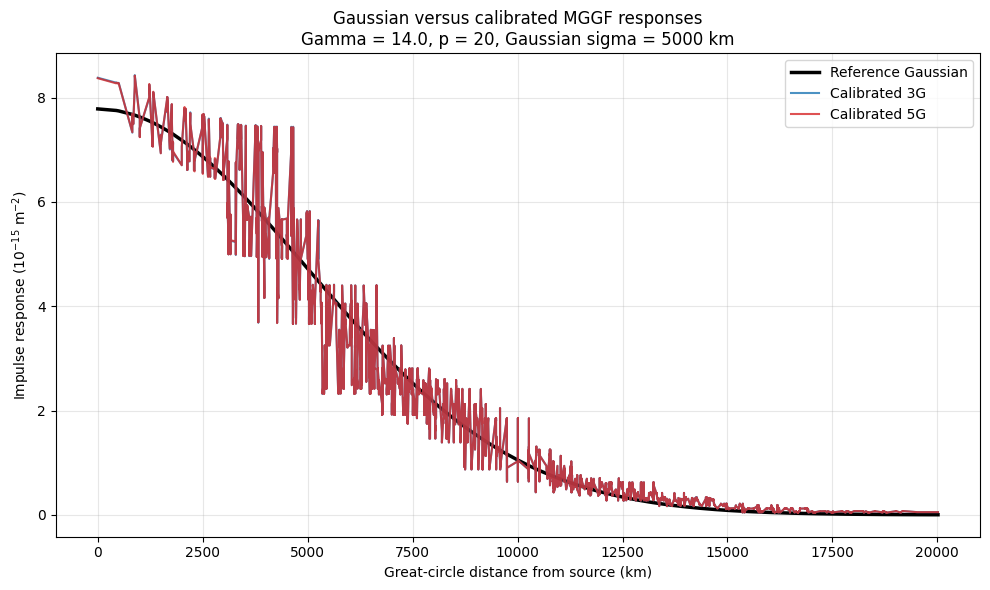

Saved: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/calibration_single_Gamma16_3G_vs_5G/Gaussian_vs_MGGF_Gamma14.png


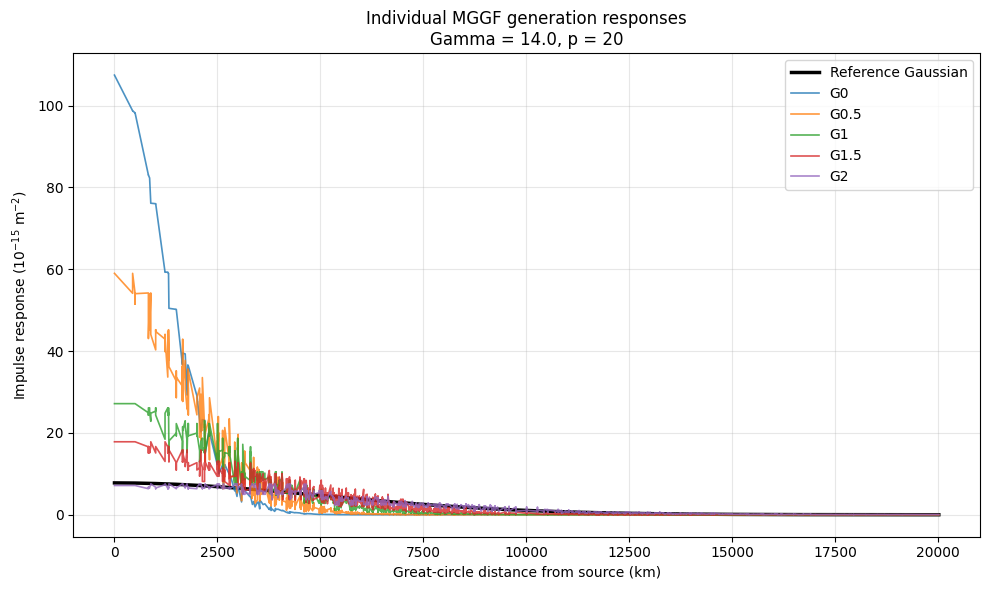

Saved: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/calibration_single_Gamma16_3G_vs_5G/Individual_generations_Gamma14.png


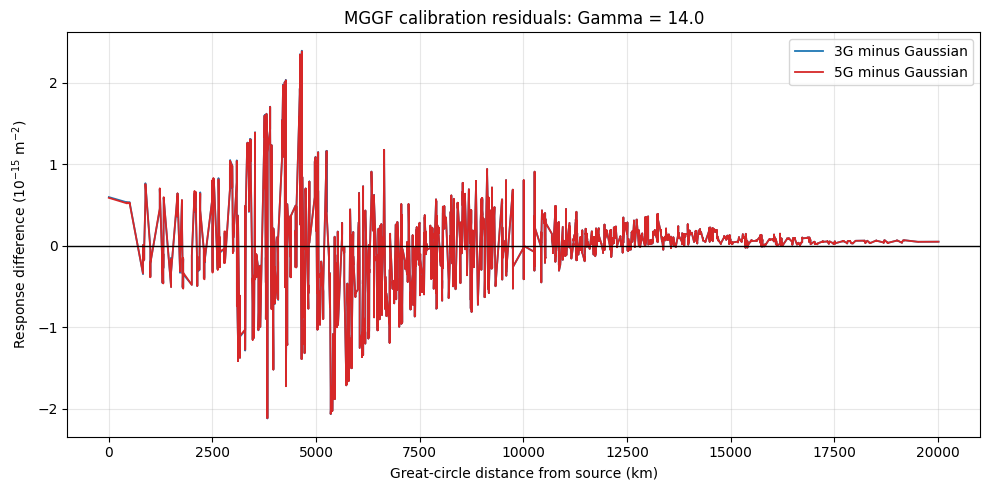

Saved: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/calibration_single_Gamma16_3G_vs_5G/Calibration_residuals_Gamma14.png

Part 4 completed.

PART 5: SPATIAL MOMENTS
Response            Mean r (km)    RMS r (km)         S3         S4
Gaussian               5631.054      6338.568    1.31874    1.95610
Calibrated 3G          5735.102      6531.829    1.36067    2.11259
Calibrated 5G          5735.241      6532.128    1.36072    2.11270
G0                     1595.529      1825.974    1.37509    2.17786
G0.5                   2233.856      2564.350    1.38586    2.21793
G1                     3176.443      3623.372    1.36663    2.14503
G1.5                   4154.255      4758.011    1.38170    2.21148
G2                     5799.533      6581.380    1.35256    2.08566

RELATIVE DIFFERENCES FROM THE REFERENCE GAUSSIAN
(Percent; moments are calculated using distance in km.)
Response                   M1          M2          M3          M4
Calibrated 3G         +1.848%     

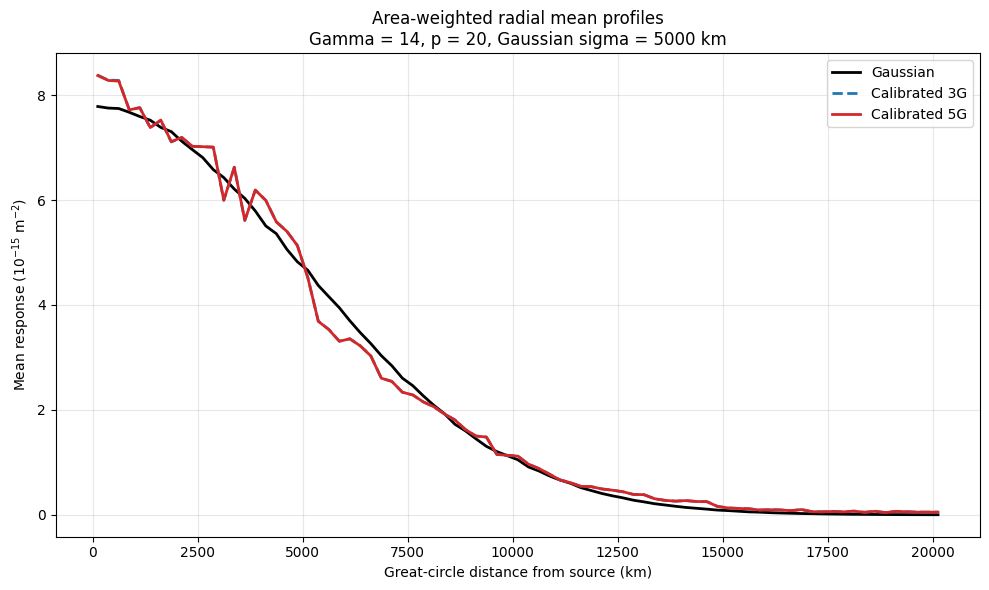

Saved: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/calibration_single_Gamma16_3G_vs_5G/Radial_mean_Gamma14_p20.png


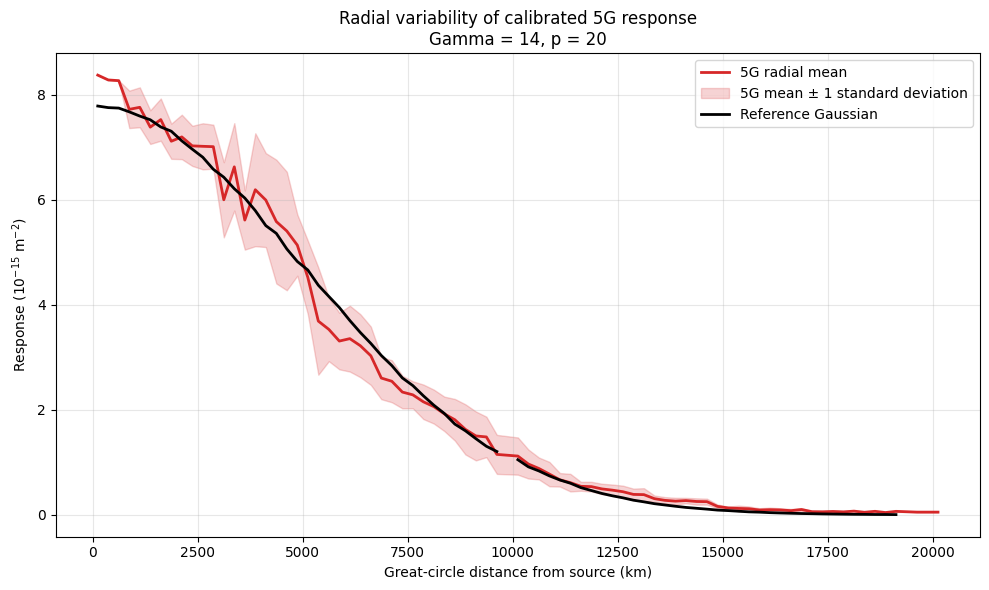

Saved: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/calibration_single_Gamma16_3G_vs_5G/Radial_variability_Gamma14_p20.png

Saved diagnostics: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/calibration_single_Gamma16_3G_vs_5G/Moment_diagnostics_Gamma14_p20.npz

Part 5 completed.


In [ ]:

# mggf_calibration_part1_grid_and_operators.py

from pathlib import Path
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import minimize
from google.colab import drive

drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

OUTDIR = INT / "calibration_single_Gamma16_3G_vs_5G"
OUTDIR.mkdir(parents=True, exist_ok=True)

GAMMA = 14.0
P_ORDER = 5
SOURCE_G0 = 38
SIGMA_KM = 5000.0
EARTH_RADIUS_M = 6371000.0

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 20000

def load_npz(path):
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return np.load(path, allow_pickle=True)

def first_key(z, names):
    for name in names:
        if name in z.files:
            return name
    raise KeyError(
        f"None of {names} found. Available keys: {z.files}"
    )

def great_circle_distance_m(xyz, source_index):
    q = np.asarray(xyz, dtype=np.float64)
    q = q / np.linalg.norm(q, axis=1, keepdims=True)
    cosine = np.clip(q @ q[source_index], -1.0, 1.0)
    return EARTH_RADIUS_M * np.arccos(cosine)

def build_PR(parent, area_f, nc):
    parent = np.asarray(parent, dtype=np.int64).ravel()
    area_f = np.asarray(area_f, dtype=np.float64)
    nf = len(area_f)

    if len(parent) != nf:
        raise ValueError("Parent-map length mismatch.")
    if np.min(parent) < 0 or np.max(parent) >= nc:
        raise ValueError("Invalid parent indices.")

    P = sp.coo_matrix(
        (np.ones(nf), (np.arange(nf), parent)),
        shape=(nf, nc)
    ).tocsr()

    area_c = np.asarray(P.T @ area_f).ravel()
    if np.any(area_c <= 0.0):
        raise ValueError("Nonpositive coarse-cell area.")

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R, area_c

def adjacency_from_edges(n, edges):
    edges = np.asarray(edges, dtype=np.int64)

    if edges.ndim != 2:
        raise ValueError("Invalid edge array.")
    if edges.shape[0] == 2 and edges.shape[1] != 2:
        edges = edges.T

    edges = edges[:, :2]
    edges = edges[edges[:, 0] != edges[:, 1]]

    if np.any(edges < 0) or np.any(edges >= n):
        raise ValueError("Invalid graph edge indices.")

    edges = np.unique(np.sort(edges, axis=1), axis=0)
    ii = np.concatenate([edges[:, 0], edges[:, 1]])
    jj = np.concatenate([edges[:, 1], edges[:, 0]])

    adjacency = sp.coo_matrix(
        (np.ones(len(ii)), (ii, jj)),
        shape=(n, n)
    ).tocsr()

    adjacency.setdiag(0.0)
    adjacency.eliminate_zeros()
    adjacency = 0.5 * (adjacency + adjacency.T)
    adjacency.eliminate_zeros()

    return adjacency.tocsr()

def adjacency_from_dual_cells(dual_cells):
    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, dtype=np.int64).ravel()

        for k in range(len(poly)):
            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])
            edge = tuple(sorted((a, b)))
            edge_to_cells.setdefault(edge, []).append(ci)

    neighbors = [set() for _ in range(len(dual_cells))]

    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                neighbors[i].add(j)
                neighbors[j].add(i)

    edges = [
        (i, j)
        for i, nbrs in enumerate(neighbors)
        for j in nbrs
        if i < j
    ]

    return adjacency_from_edges(
        len(dual_cells),
        np.asarray(edges, dtype=np.int64)
    )

def build_area_compatible_laplacian(adjacency, area, name):
    adjacency = adjacency.tocsr().astype(np.float64)
    area = np.asarray(area, dtype=np.float64)
    n = len(area)

    if adjacency.shape != (n, n) or np.any(area <= 0.0):
        raise ValueError(f"{name}: invalid adjacency or areas.")

    ahat = area / np.mean(area)
    s = np.ones(n)
    converged = False

    for iteration in range(SINKHORN_MAXITER):
        adjacency_s = adjacency @ s

        if np.any(adjacency_s <= 0.0):
            raise RuntimeError(f"{name}: invalid adjacency.")

        s_new = np.sqrt(s * ahat / adjacency_s)
        row_sum_new = s_new * (adjacency @ s_new)

        rel_error = np.max(
            np.abs(row_sum_new - ahat)
            / np.maximum(ahat, 1.0e-300)
        )

        s = s_new

        if rel_error < SINKHORN_TOL:
            converged = True
            break

    if not converged:
        raise RuntimeError(
            f"{name}: balancing failed, error={rel_error:.3e}"
        )

    Wedge = (
        sp.diags(s) @ adjacency @ sp.diags(s)
    ).tocsr()
    Wedge = (0.5 * (Wedge + Wedge.T)).tocsr()
    Wedge.eliminate_zeros()

    row_sum = np.asarray(Wedge @ np.ones(n)).ravel()
    Q = (sp.diags(row_sum) - Wedge).tocsr()
    L_A = (sp.diags(1.0 / ahat) @ Q).tocsr()

    balance_error = np.max(
        np.abs(row_sum - ahat)
        / np.maximum(ahat, 1.0e-300)
    )
    constant_error = np.max(np.abs(L_A @ np.ones(n)))
    Ahat = sp.diags(ahat)

    adjoint_error = (
        spla.norm(Ahat @ L_A - L_A.T @ Ahat)
        / max(spla.norm(Ahat @ L_A), 1.0e-300)
    )

    print(
        f"{name:5s}: N={n:4d} "
        f"iterations={iteration + 1:5d} "
        f"balance={balance_error:.3e} "
        f"constant={constant_error:.3e} "
        f"adjoint={adjoint_error:.3e}"
    )

    return L_A

def repeated_resolvent(L_A, Gamma, x, p=P_ORDER):
    system = (
        sp.eye(L_A.shape[0], format="csc")
        + (Gamma / float(p)) * L_A.tocsc()
    )
    lu = spla.splu(system)
    y = np.asarray(x, dtype=np.float64).copy()

    for _ in range(p):
        y = lu.solve(y)

    return y

print("Part 1 completed.")
print("Output directory:", OUTDIR)


# mggf_calibration_part2_impulse_responses.py

# ============================================================
# Load original grids and conservative hierarchy
# ============================================================

g0 = load_npz(G0_FILE)
g1 = load_npz(G1_FILE)
g2 = load_npz(G2_FILE)

xyz0 = np.asarray(g0["cell_center_xyz"], dtype=np.float64)
area0 = np.asarray(g0["cell_area"], dtype=np.float64)

dual0 = g0["dual_cells"]
dual1 = g1["dual_cells"]
dual2 = g2["dual_cells"]

n0 = len(area0)
n1 = len(dual1)
n2 = len(dual2)

print("Original grids:", n0, n1, n2)

comm = load_npz(COMM_FILE)

parent01 = np.asarray(
    comm[first_key(comm, [
        "parent01", "parent_of_G0",
        "parent_G0_to_G1", "parent0_to_1",
        "parent_G0_G1"
    ])],
    dtype=np.int64
).ravel()

parent12 = np.asarray(
    comm[first_key(comm, [
        "parent12", "parent_of_G1",
        "parent_G1_to_G2", "parent1_to_2",
        "parent_G1_G2"
    ])],
    dtype=np.int64
).ravel()

P01, R10, area1 = build_PR(parent01, area0, n1)
P12, R21, area2 = build_PR(parent12, area1, n2)

P02 = (P01 @ P12).tocsr()
R20 = (R21 @ R10).tocsr()

# ============================================================
# Load intermediate generations
# ============================================================

z05 = load_npz(G05_FILE)

parent005 = np.asarray(
    z05["parent_of_G0"], dtype=np.int64
).ravel()

edges05 = np.asarray(
    z05["edges_G0p5"], dtype=np.int64
)

n05 = len(np.asarray(z05["cell_area_G0p5"]))

P005, R050, area05 = build_PR(
    parent005, area0, n05
)

z15 = load_npz(G15_FILE)

parent115 = np.asarray(
    z15[first_key(z15, [
        "parent_of_G1",
        "parent_G1_to_G1p5",
        "parent_G1_G1p5"
    ])],
    dtype=np.int64
).ravel()

edges15 = np.asarray(
    z15[first_key(z15, [
        "edges_G1p5", "edges_G1_5"
    ])],
    dtype=np.int64
)

n15 = len(np.asarray(
    z15[first_key(z15, [
        "cell_area_G1p5", "cell_area_G1_5"
    ])]
))

P115, R151, area15 = build_PR(
    parent115, area1, n15
)

P015 = (P01 @ P115).tocsr()
R150 = (R151 @ R10).tocsr()

# ============================================================
# Construct adjacency matrices and graph operators
# ============================================================

Adj0 = adjacency_from_dual_cells(dual0)
Adj05 = adjacency_from_edges(n05, edges05)
Adj1 = adjacency_from_dual_cells(dual1)
Adj15 = adjacency_from_edges(n15, edges15)
Adj2 = adjacency_from_dual_cells(dual2)

generation_data = [
    ("G0", area0, Adj0),
    ("G0.5", area05, Adj05),
    ("G1", area1, Adj1),
    ("G1.5", area15, Adj15),
    ("G2", area2, Adj2)
]

print("\nFIVE-GENERATION HIERARCHY")

for name, area, adjacency in generation_data:
    degree = np.asarray(adjacency.sum(axis=1)).ravel()
    print(
        f"{name:5s}: cells={len(area):4d} "
        f"edges={adjacency.nnz // 2:5d} "
        f"degree=[{degree.min():.0f}, {degree.max():.0f}] "
        f"total_area={np.sum(area):.12e}"
    )

def check_transfer(name, P, R, area_f, area_c):
    area_error = np.max(
        np.abs(np.asarray(P.T @ area_f).ravel() - area_c)
    ) / np.max(area_c)

    r_error = np.max(
        np.abs(R @ np.ones(len(area_f)) - 1.0)
    )

    p_error = np.max(
        np.abs(P @ np.ones(len(area_c)) - 1.0)
    )

    print(
        f"{name:12s}: area={area_error:.3e} "
        f"R1={r_error:.3e} P1={p_error:.3e}"
    )

    if max(area_error, r_error, p_error) > 1.0e-12:
        raise RuntimeError(f"{name}: transfer check failed.")

print("\nCONSERVATIVE TRANSFER CHECKS")

check_transfer("G0 -> G0.5", P005, R050, area0, area05)
check_transfer("G0 -> G1", P01, R10, area0, area1)
check_transfer("G1 -> G1.5", P115, R151, area1, area15)
check_transfer("G1 -> G2", P12, R21, area1, area2)

print("\nAREA-COMPATIBLE GRAPH OPERATORS")

L0 = build_area_compatible_laplacian(Adj0, area0, "G0")
L05 = build_area_compatible_laplacian(Adj05, area05, "G0.5")
L1 = build_area_compatible_laplacian(Adj1, area1, "G1")
L15 = build_area_compatible_laplacian(Adj15, area15, "G1.5")
L2 = build_area_compatible_laplacian(Adj2, area2, "G2")

# ============================================================
# Initial impulse: unit area integral
# ============================================================

delta0 = np.zeros(n0, dtype=np.float64)
delta0[SOURCE_G0] = 1.0 / area0[SOURCE_G0]

input_integral = float(area0 @ delta0)

# ============================================================
# Apply the same Gamma and p on every generation
# ============================================================

print("\nCONSTRUCTING FIVE IMPULSE RESPONSES")

b0 = repeated_resolvent(
    L0, GAMMA, delta0
)
print("G0 completed.")

b05 = P005 @ repeated_resolvent(
    L05, GAMMA, R050 @ delta0
)
print("G0.5 completed.")

b1 = P01 @ repeated_resolvent(
    L1, GAMMA, R10 @ delta0
)
print("G1 completed.")

b15 = P015 @ repeated_resolvent(
    L15, GAMMA, R150 @ delta0
)
print("G1.5 completed.")

b2 = P02 @ repeated_resolvent(
    L2, GAMMA, R20 @ delta0
)
print("G2 completed.")

# ============================================================
# Assemble original, unnormalized responses
# ============================================================

labels5 = ["G0", "G0.5", "G1", "G1.5", "G2"]
labels3 = ["G0", "G1", "G2"]

B5 = np.column_stack([b0, b05, b1, b15, b2])
B3 = B5[:, [0, 2, 4]]

# ============================================================
# Conservation diagnostics
# ============================================================

print("\nIMPULSE-RESPONSE CONSERVATION")
print(f"Input integral = {input_integral:.12e}")

for j, name in enumerate(labels5):
    response_integral = float(area0 @ B5[:, j])
    relative_error = abs(
        response_integral - input_integral
    ) / abs(input_integral)

    print(
        f"{name:5s}: integral={response_integral:.12e} "
        f"relative_error={relative_error:.3e} "
        f"source_amplitude={B5[SOURCE_G0, j]:.12e}"
    )

    if relative_error > 1.0e-10:
        raise RuntimeError(
            f"{name}: impulse conservation failed."
        )

print("\nPart 2 completed.")
print("B5 shape:", B5.shape)
print("B3 shape:", B3.shape)


# mggf_calibration_part3_gaussian_fit.py

# ============================================================
# Reference Gaussian with the same area integral as the impulse
# ============================================================

distance_m = great_circle_distance_m(
    xyz0, SOURCE_G0
)

sigma_m = SIGMA_KM * 1000.0

gaussian = np.exp(
    -0.5 * (distance_m / sigma_m) ** 2
)

reference = (
    input_integral
    * gaussian
    / float(area0 @ gaussian)
)

print("\nREFERENCE GAUSSIAN")
print("Gamma =", GAMMA)
print("p =", P_ORDER)
print("Sigma (km) =", SIGMA_KM)
print("Source cell =", SOURCE_G0)
print("Reference integral =", float(area0 @ reference))
print("Reference source amplitude =", reference[SOURCE_G0])

# ============================================================
# Fit original generation responses
#
# Minimize area-weighted squared mismatch subject to:
#
#     w_k >= 0
#     sum_k w_k = 1
#
# No individual source-amplitude normalization.
# ============================================================

def fit_generation_weights(B, labels, reference, area):
    B = np.asarray(B, dtype=np.float64)
    reference = np.asarray(reference, dtype=np.float64)
    area = np.asarray(area, dtype=np.float64)

    nweights = B.shape[1]

    # Scale the objective to improve numerical conditioning.
    scale = max(
        float(np.max(np.abs(reference))),
        1.0e-300
    )

    area_normalized = area / np.sum(area)

    H = B / scale
    target = reference / scale

    def objective(w):
        residual = H @ w - target
        return 0.5 * float(
            area_normalized @ (residual * residual)
        )

    def gradient(w):
        residual = H @ w - target
        return H.T @ (area_normalized * residual)

    constraints = [{
        "type": "eq",
        "fun": lambda w: float(np.sum(w) - 1.0),
        "jac": lambda w: np.ones_like(w)
    }]

    result = minimize(
        objective,
        np.full(nweights, 1.0 / nweights),
        jac=gradient,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * nweights,
        constraints=constraints,
        options={
            "ftol": 1.0e-12,
            "maxiter": 1000,
            "disp": False
        }
    )

    if not result.success:
        raise RuntimeError(
            f"{labels}: calibration failed: {result.message}"
        )

    weights = result.x

    if (
        np.min(weights) < -1.0e-10
        or abs(np.sum(weights) - 1.0) > 1.0e-8
    ):
        raise RuntimeError(
            f"{labels}: invalid calibrated weights."
        )

    response = B @ weights

    reference_norm2 = float(
        area @ (reference * reference)
    )

    relative_l2 = np.sqrt(
        float(
            area @ ((response - reference) ** 2)
        ) / reference_norm2
    )

    response_integral = float(area @ response)
    reference_integral = float(area @ reference)

    integral_error = abs(
        response_integral - reference_integral
    ) / abs(reference_integral)

    source_ratio = (
        response[SOURCE_G0]
        / reference[SOURCE_G0]
    )

    # Effective radius based on the second spatial moment.
    def effective_radius_km(field):
        mass = float(area @ field)

        radius_squared = float(
            area @ ((distance_m ** 2) * field)
        ) / mass

        return np.sqrt(max(radius_squared, 0.0)) / 1000.0

    print("\n" + "=" * 65)
    print("CALIBRATION:", ", ".join(labels))
    print("=" * 65)

    print("Solver:", result.message)

    print("\nGeneration weights:")
    for name, weight in zip(labels, weights):
        print(f"  {name:5s}: {weight:.10f}")

    print(f"\nSum of weights: {np.sum(weights):.12f}")

    print(f"Relative L2 mismatch: {relative_l2:.8f}")
    print(f"Integral error: {integral_error:.3e}")
    print(f"Source amplitude ratio: {source_ratio:.8f}")

    print(
        "Reference effective radius (km):",
        f"{effective_radius_km(reference):.3f}"
    )
    print(
        "Fitted effective radius (km):",
        f"{effective_radius_km(response):.3f}"
    )

    return {
        "weights": weights,
        "response": response,
        "relative_l2": relative_l2,
        "integral_error": integral_error,
        "source_ratio": source_ratio,
        "success": result.success
    }

# ============================================================
# Three-generation calibration
# ============================================================

result3 = fit_generation_weights(
    B3, labels3, reference, area0
)

# ============================================================
# Five-generation calibration
# ============================================================

result5 = fit_generation_weights(
    B5, labels5, reference, area0
)

# ============================================================
# Comparison
# ============================================================

print("\n" + "=" * 65)
print("FINAL COMPARISON: 3G versus 5G")
print("=" * 65)

print(f"Gamma = {GAMMA}")
print(f"p = {P_ORDER}")
print(f"Gaussian sigma = {SIGMA_KM:.0f} km")

print(
    f"3G relative L2 mismatch = "
    f"{result3['relative_l2']:.8f}"
)

print(
    f"5G relative L2 mismatch = "
    f"{result5['relative_l2']:.8f}"
)

if result3["relative_l2"] > 0.0:
    improvement = 100.0 * (
        result3["relative_l2"] - result5["relative_l2"]
    ) / result3["relative_l2"]

    print(
        f"5G mismatch reduction = {improvement:.3f}%"
    )

# ============================================================
# Save numerical results
# ============================================================

output_file = OUTDIR / (
    "calibration_Gamma16_sigma5000km_3G_vs_5G.npz"
)

np.savez(
    output_file,
    Gamma=GAMMA,
    p=P_ORDER,
    sigma_km=SIGMA_KM,
    source_index=SOURCE_G0,
    cell_area=area0,
    cell_center_xyz=xyz0,
    distance_m=distance_m,
    reference=reference,
    basis_3G=B3,
    basis_5G=B5,
    labels_3G=np.asarray(labels3),
    labels_5G=np.asarray(labels5),
    weights_3G=result3["weights"],
    weights_5G=result5["weights"],
    response_3G=result3["response"],
    response_5G=result5["response"],
    relative_l2_3G=result3["relative_l2"],
    relative_l2_5G=result5["relative_l2"]
)

print("\nResults saved to:")
print(output_file)

print("\nPart 3 completed.")


# ============================================================
# PART 4: PLOT GAUSSIAN AND MGGF IMPULSE RESPONSES
# ============================================================

import matplotlib.pyplot as plt

# Use the original response amplitudes, scaled only for
# readable plot-axis units (10^-15 m^-2).
PLOT_SCALE = 1.0e15

distance_km = distance_m / 1000.0

# ------------------------------------------------------------
# 1. Sort cells by distance from the source
# ------------------------------------------------------------

order = np.argsort(distance_km)

r = distance_km[order]

ref_plot = reference[order] * PLOT_SCALE
fit3_plot = result3["response"][order] * PLOT_SCALE
fit5_plot = result5["response"][order] * PLOT_SCALE

# ------------------------------------------------------------
# 2. Plot the reference and both calibrated responses
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    r, ref_plot,
    color="black",
    linewidth=2.5,
    label="Reference Gaussian"
)

ax.plot(
    r, fit3_plot,
    color="tab:blue",
    linewidth=1.5,
    alpha=0.8,
    label="Calibrated 3G"
)

ax.plot(
    r, fit5_plot,
    color="tab:red",
    linewidth=1.5,
    alpha=0.8,
    label="Calibrated 5G"
)

ax.set_xlabel("Great-circle distance from source (km)")
ax.set_ylabel(r"Impulse response ($10^{-15}\ \mathrm{m}^{-2}$)")

ax.set_title(
    f"Gaussian versus calibrated MGGF responses\n"
    f"Gamma = {GAMMA}, p = {P_ORDER}, "
    f"Gaussian sigma = {SIGMA_KM:.0f} km"
)

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

plot_file = OUTDIR / (
    f"Gaussian_vs_MGGF_Gamma{GAMMA:g}.png"
)

fig.savefig(plot_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_file)

# ------------------------------------------------------------
# 3. Plot the five individual generation responses
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    r, ref_plot,
    color="black",
    linewidth=2.5,
    label="Reference Gaussian"
)

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple"
]

for j, name in enumerate(labels5):

    ax.plot(
        r,
        B5[order, j] * PLOT_SCALE,
        color=colors[j],
        linewidth=1.2,
        alpha=0.8,
        label=name
    )

ax.set_xlabel("Great-circle distance from source (km)")
ax.set_ylabel(r"Impulse response ($10^{-15}\ \mathrm{m}^{-2}$)")

ax.set_title(
    f"Individual MGGF generation responses\n"
    f"Gamma = {GAMMA}, p = {P_ORDER}"
)

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

plot_file = OUTDIR / (
    f"Individual_generations_Gamma{GAMMA:g}.png"
)

fig.savefig(plot_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_file)

# ------------------------------------------------------------
# 4. Plot spatial residuals relative to the Gaussian
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    r,
    (result3["response"][order] - reference[order])
    * PLOT_SCALE,
    color="tab:blue",
    linewidth=1.3,
    label="3G minus Gaussian"
)

ax.plot(
    r,
    (result5["response"][order] - reference[order])
    * PLOT_SCALE,
    color="tab:red",
    linewidth=1.3,
    label="5G minus Gaussian"
)

ax.axhline(0.0, color="black", linewidth=1.0)

ax.set_xlabel("Great-circle distance from source (km)")
ax.set_ylabel(r"Response difference ($10^{-15}\ \mathrm{m}^{-2}$)")

ax.set_title(
    f"MGGF calibration residuals: Gamma = {GAMMA}"
)

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

plot_file = OUTDIR / (
    f"Calibration_residuals_Gamma{GAMMA:g}.png"
)

fig.savefig(plot_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_file)

print("\nPart 4 completed.")


# ============================================================
# PART 5: HIGHER MOMENTS AND RADIAL-PROFILE DIAGNOSTICS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Use the great-circle distances and original, unnormalized
# impulse responses already calculated in Parts 1-3.
#
# The factor 1e15 below changes only the plotted axis units.
# It does not normalize the physical response.

distance_km = np.asarray(distance_m, dtype=float) / 1000.0
areas = np.asarray(area0, dtype=float)

fields = {
    "Gaussian": np.asarray(reference, dtype=float),
    "Calibrated 3G": np.asarray(result3["response"], dtype=float),
    "Calibrated 5G": np.asarray(result5["response"], dtype=float),
}

for j, name in enumerate(labels5):
    fields[name] = np.asarray(B5[:, j], dtype=float)


# ------------------------------------------------------------
# 1. Area-weighted spatial moments
# ------------------------------------------------------------

def radial_moments(field, distance_km, areas):
    field = np.asarray(field, dtype=float)

    mass = float(np.sum(areas * field))

    if mass <= 0.0:
        raise ValueError("Response has nonpositive area integral.")

    moments = {}

    for n in range(1, 5):
        moments[n] = float(
            np.sum(areas * field * distance_km**n) / mass
        )

    rms_radius = np.sqrt(max(moments[2], 0.0))

    standardized_m3 = (
        moments[3] / moments[2]**1.5
        if moments[2] > 0.0 else np.nan
    )

    standardized_m4 = (
        moments[4] / moments[2]**2
        if moments[2] > 0.0 else np.nan
    )

    return {
        "mass": mass,
        "M1": moments[1],
        "M2": moments[2],
        "M3": moments[3],
        "M4": moments[4],
        "RMS": rms_radius,
        "S3": standardized_m3,
        "S4": standardized_m4,
    }


diagnostics = {
    name: radial_moments(field, distance_km, areas)
    for name, field in fields.items()
}

ref_diag = diagnostics["Gaussian"]

print("\n" + "=" * 78)
print("PART 5: SPATIAL MOMENTS")
print("=" * 78)

print(
    f"{'Response':17s} "
    f"{'Mean r (km)':>13s} "
    f"{'RMS r (km)':>13s} "
    f"{'S3':>10s} "
    f"{'S4':>10s}"
)

for name, d in diagnostics.items():
    print(
        f"{name:17s} "
        f"{d['M1']:13.3f} "
        f"{d['RMS']:13.3f} "
        f"{d['S3']:10.5f} "
        f"{d['S4']:10.5f}"
    )

print("\nRELATIVE DIFFERENCES FROM THE REFERENCE GAUSSIAN")
print("(Percent; moments are calculated using distance in km.)")

print(
    f"{'Response':17s} "
    f"{'M1':>11s} "
    f"{'M2':>11s} "
    f"{'M3':>11s} "
    f"{'M4':>11s}"
)

for name, d in diagnostics.items():
    if name == "Gaussian":
        continue

    differences = [
        100.0 * (d[f"M{n}"] / ref_diag[f"M{n}"] - 1.0)
        for n in range(1, 5)
    ]

    print(
        f"{name:17s} "
        + " ".join(f"{value:+10.3f}%" for value in differences)
    )


# ------------------------------------------------------------
# 2. Area-weighted radial profiles
#
# For each distance bin:
#   mean = sum(A_i h_i) / sum(A_i)
#
#   std = sqrt[sum(A_i (h_i - mean)^2) / sum(A_i)]
#
# These measure the average radial shape and the variation
# among cells at comparable distances.
# ------------------------------------------------------------

BIN_WIDTH_KM = 250.0

bin_edges = np.arange(
    0.0,
    np.max(distance_km) + BIN_WIDTH_KM * 1.001,
    BIN_WIDTH_KM
)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_index = np.digitize(distance_km, bin_edges) - 1

nbins = len(bin_centers)

radial_profiles = {}

for name, field in fields.items():

    mean = np.full(nbins, np.nan)
    std = np.full(nbins, np.nan)
    counts = np.zeros(nbins, dtype=int)

    for k in range(nbins):

        selected = bin_index == k
        counts[k] = np.count_nonzero(selected)

        if counts[k] == 0:
            continue

        a = areas[selected]
        h = field[selected]

        total_area = float(np.sum(a))

        mean[k] = float(np.sum(a * h) / total_area)

        variance = float(
            np.sum(a * (h - mean[k])**2) / total_area
        )

        std[k] = np.sqrt(max(variance, 0.0))

    radial_profiles[name] = {
        "mean": mean,
        "std": std,
        "counts": counts,
    }


# ------------------------------------------------------------
# 3. Plot the radial mean profiles
# ------------------------------------------------------------

PLOT_SCALE = 1.0e15

fig, ax = plt.subplots(figsize=(10, 6))

for name, color, style in [
    ("Gaussian", "black", "-"),
    ("Calibrated 3G", "tab:blue", "--"),
    ("Calibrated 5G", "tab:red", "-"),
]:

    profile = radial_profiles[name]
    valid = np.isfinite(profile["mean"])

    ax.plot(
        bin_centers[valid],
        profile["mean"][valid] * PLOT_SCALE,
        linestyle=style,
        color=color,
        linewidth=2.0,
        label=name,
    )

ax.set_xlabel("Great-circle distance from source (km)")
ax.set_ylabel(r"Mean response ($10^{-15}\ \mathrm{m}^{-2}$)")

ax.set_title(
    f"Area-weighted radial mean profiles\n"
    f"Gamma = {GAMMA:g}, p = {P_ORDER}, "
    f"Gaussian sigma = {SIGMA_KM:.0f} km"
)

ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

plot_file = OUTDIR / (
    f"Radial_mean_Gamma{GAMMA:g}_p{P_ORDER}.png"
)

fig.savefig(plot_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_file)


# ------------------------------------------------------------
# 4. Plot radial variability for the calibrated 5G response
# ------------------------------------------------------------

profile = radial_profiles["Calibrated 5G"]
valid = np.isfinite(profile["mean"])

x = bin_centers[valid]
y = profile["mean"][valid] * PLOT_SCALE
s = profile["std"][valid] * PLOT_SCALE

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    x,
    y,
    color="tab:red",
    linewidth=2.0,
    label="5G radial mean",
)

ax.fill_between(
    x,
    y - s,
    y + s,
    color="tab:red",
    alpha=0.2,
    label="5G mean ± 1 standard deviation",
)

gaussian_profile = radial_profiles["Gaussian"]

ax.plot(
    bin_centers,
    gaussian_profile["mean"] * PLOT_SCALE,
    color="black",
    linewidth=2.0,
    label="Reference Gaussian",
)

ax.set_xlabel("Great-circle distance from source (km)")
ax.set_ylabel(r"Response ($10^{-15}\ \mathrm{m}^{-2}$)")

ax.set_title(
    f"Radial variability of calibrated 5G response\n"
    f"Gamma = {GAMMA:g}, p = {P_ORDER}"
)

ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

plot_file = OUTDIR / (
    f"Radial_variability_Gamma{GAMMA:g}_p{P_ORDER}.png"
)

fig.savefig(plot_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_file)


# ------------------------------------------------------------
# 5. Save numerical diagnostics
# ------------------------------------------------------------

moment_names = list(diagnostics.keys())

moment_table = np.array([
    [
        diagnostics[name]["mass"],
        diagnostics[name]["M1"],
        diagnostics[name]["M2"],
        diagnostics[name]["M3"],
        diagnostics[name]["M4"],
        diagnostics[name]["RMS"],
        diagnostics[name]["S3"],
        diagnostics[name]["S4"],
    ]
    for name in moment_names
])

diagnostic_file = OUTDIR / (
    f"Moment_diagnostics_Gamma{GAMMA:g}_p{P_ORDER}.npz"
)

np.savez(
    diagnostic_file,
    Gamma=GAMMA,
    p=P_ORDER,
    sigma_km=SIGMA_KM,
    moment_names=np.asarray(moment_names),
    moment_columns=np.asarray([
        "mass", "M1", "M2", "M3", "M4",
        "RMS", "S3", "S4"
    ]),
    moment_table=moment_table,
    bin_centers_km=bin_centers,
    radial_mean_3G=radial_profiles["Calibrated 3G"]["mean"],
    radial_std_3G=radial_profiles["Calibrated 3G"]["std"],
    radial_mean_5G=radial_profiles["Calibrated 5G"]["mean"],
    radial_std_5G=radial_profiles["Calibrated 5G"]["std"],
    radial_mean_reference=radial_profiles["Gaussian"]["mean"],
)

print("\nSaved diagnostics:", diagnostic_file)
print("\nPart 5 completed.")


# mggf_calibration_test_5G.py

In [ ]:

# ============================================================
# MGGF CALIBRATION: FIVE-GENERATION TEST
# ============================================================

import numpy as np

# Original conservative generation responses
# from the existing MGGF implementation.

responses = B5.T.copy()

cell_area = area0.copy()

source = SOURCE_G0

distance = great_circle_distance_m(
    xyz0,
    source
)

# Prescribed Gaussian correlation length (km)

L_km = 5000.0

# Run calibration using original generation amplitudes.

results = calibrate_mggf(
    responses=responses,
    cell_area=cell_area,
    distance=distance,
    source=source,
    L=L_km * 1000.0,
    lambda_sum=1.0,
)

print("\nFive-generation calibration completed.")

NameError: name 'B5' is not defined

# Small diagonstics

In [ ]:
# check_G3_inputs.py

from pathlib import Path
import numpy as np

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT  = ROOT / "intermediate_generations"

print("=== Possible G3 grid files ===")
for f in sorted(GRID.glob("*nsub1*.npz")):
    print(f)

print("\n=== All global hex/ico grid files ===")
for f in sorted(GRID.glob("global_hex_ico_grid*.npz")):
    print(f.name)

print("\n=== Communication / hierarchy files ===")
for f in sorted(GRID.glob("*communication*.npz")):
    print(f.name)

for f in sorted(INT.glob("*hierarchy*.npz")):
    print(f.name)

=== Possible G3 grid files ===

=== All global hex/ico grid files ===
global_hex_ico_grid_nsub2.npz
global_hex_ico_grid_nsub3.npz
global_hex_ico_grid_nsub4.npz
global_hex_ico_grid_v0.npz

=== Communication / hierarchy files ===
global_hex_ico_geometric_communication_v0.npz
global_irregular_voronoi_graph_communication_v0.npz
mggf_G0p5_pair_hierarchy_v0.npz
mggf_G1p5_pair_hierarchy_v1.npz
voronoi_mggf_G0p5_pair_hierarchy_v0.npz
voronoi_mggf_G1p5_pair_hierarchy_v0.npz


# Small diagnostics 2

In [ ]:
from pathlib import Path
import numpy as np

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

files = [
    "global_hex_ico_grid_v0.npz",
    "global_hex_ico_grid_nsub2.npz",
    "global_hex_ico_grid_nsub3.npz",
    "global_hex_ico_grid_nsub4.npz",
]

for name in files:
    path = GRID / name
    print("\n" + "=" * 72)
    print(name)
    print("=" * 72)

    z = np.load(path, allow_pickle=True)

    print("Keys:")
    for key in z.files:
        a = z[key]
        print(f"  {key:25s} shape={str(a.shape):18s} dtype={a.dtype}")

    # Report likely grid sizes
    for key in ["cell_center_xyz", "cell_center_lon", "cell_center_lat",
                "dual_vertex_xyz", "primal_faces", "dual_cells", "cell_area"]:
        if key in z:
            print(f"  -> {key}: {z[key].shape}")


global_hex_ico_grid_v0.npz
Keys:
  cell_center_xyz           shape=(2562, 3)          dtype=float64
  cell_center_lon           shape=(2562,)            dtype=float64
  cell_center_lat           shape=(2562,)            dtype=float64
  dual_vertex_xyz           shape=(5120, 3)          dtype=float64
  dual_vertex_lon           shape=(5120,)            dtype=float64
  dual_vertex_lat           shape=(5120,)            dtype=float64
  cell_area                 shape=(2562,)            dtype=float64
  primal_faces              shape=(5120, 3)          dtype=int64
  dual_cells                shape=(2562,)            dtype=object
  -> cell_center_xyz: (2562, 3)
  -> cell_center_lon: (2562,)
  -> cell_center_lat: (2562,)
  -> dual_vertex_xyz: (5120, 3)
  -> primal_faces: (5120, 3)
  -> dual_cells: (2562,)
  -> cell_area: (2562,)

global_hex_ico_grid_nsub2.npz
Keys:
  cell_center_xyz           shape=(162, 3)           dtype=float64
  cell_center_lon           shape=(162,)             dtype=f

# Small diagnostics 3

In [ ]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")

print("Searching for likely icosahedral grid-generation scripts...\n")

patterns = [
    "*ico*.py",
    "*grid*.py",
    "*mesh*.py",
]

found = set()

for pattern in patterns:
    for f in ROOT.rglob(pattern):
        if f.is_file():
            found.add(f)

for f in sorted(found):
    print(f.relative_to(ROOT))

Searching for likely icosahedral grid-generation scripts...



# Small diagnostics 4

In [ ]:
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

g0 = np.load(GRID / "global_hex_ico_grid_nsub4.npz", allow_pickle=True)
g1 = np.load(GRID / "global_hex_ico_grid_nsub3.npz", allow_pickle=True)
g2 = np.load(GRID / "global_hex_ico_grid_nsub2.npz", allow_pickle=True)

X0 = np.asarray(g0["cell_center_xyz"], dtype=float)
X1 = np.asarray(g1["cell_center_xyz"], dtype=float)
X2 = np.asarray(g2["cell_center_xyz"], dtype=float)

# Normalize in case xyz contains Earth-radius rather than unit vectors
X0 /= np.linalg.norm(X0, axis=1)[:, None]
X1 /= np.linalg.norm(X1, axis=1)[:, None]
X2 /= np.linalg.norm(X2, axis=1)[:, None]


def nesting_test(Xfine, Xcoarse, fine_name, coarse_name):
    tree = cKDTree(Xfine)
    dist, idx = tree.query(Xcoarse, k=1)

    print(f"\n{coarse_name} -> {fine_name}")
    print(f"  fine cells       = {len(Xfine)}")
    print(f"  coarse cells     = {len(Xcoarse)}")
    print(f"  max xyz mismatch = {dist.max():.16e}")
    print(f"  mean mismatch    = {dist.mean():.16e}")
    print(f"  unique matches   = {len(np.unique(idx))} / {len(Xcoarse)}")

    # Convert chord distance to angular difference
    ang = 2.0 * np.arcsin(np.clip(dist / 2.0, 0.0, 1.0))
    print(f"  max angle (deg)  = {np.degrees(ang).max():.16e}")

    return idx, dist


idx10, d10 = nesting_test(X0, X1, "G0 (2562)", "G1 (642)")
idx21, d21 = nesting_test(X1, X2, "G1 (642)", "G2 (162)")

print("\nExpected for an exactly nested hierarchy:")
print("  mismatches should be approximately machine precision")
print("  unique matches should equal the number of coarse cells")


G1 (642) -> G0 (2562)
  fine cells       = 2562
  coarse cells     = 642
  max xyz mismatch = 0.0000000000000000e+00
  mean mismatch    = 0.0000000000000000e+00
  unique matches   = 642 / 642
  max angle (deg)  = 0.0000000000000000e+00

G2 (162) -> G1 (642)
  fine cells       = 642
  coarse cells     = 162
  max xyz mismatch = 0.0000000000000000e+00
  mean mismatch    = 0.0000000000000000e+00
  unique matches   = 162 / 162
  max angle (deg)  = 0.0000000000000000e+00

Expected for an exactly nested hierarchy:
  mismatches should be approximately machine precision
  unique matches should equal the number of coarse cells


# New diagnostics

In [ ]:
import numpy as np
from pathlib import Path
from collections import defaultdict

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

g2 = np.load(GRID / "global_hex_ico_grid_nsub2.npz", allow_pickle=True)

X = np.asarray(g2["cell_center_xyz"], dtype=float)
F = np.asarray(g2["primal_faces"], dtype=np.int64)

# Normalize to unit sphere for geometry tests
Xn = X / np.linalg.norm(X, axis=1)[:, None]

print("G2 vertices:", len(Xn))
print("G2 triangles:", len(F))

# ------------------------------------------------------------
# 1. Build vertex adjacency from triangular faces
# ------------------------------------------------------------
nbr = [set() for _ in range(len(Xn))]

for a, b, c in F:
    nbr[a].update((b, c))
    nbr[b].update((a, c))
    nbr[c].update((a, b))

degree = np.array([len(s) for s in nbr])

print("\nG2 vertex degree distribution:")
for d in sorted(np.unique(degree)):
    print(f"  degree {d}: {np.sum(degree == d)} vertices")

# ------------------------------------------------------------
# 2. Find candidate "old" vertices.
#
# A direct topology-only inversion of arbitrary 1-to-4 refinement is
# nontrivial. Here we exploit the exact standard nested icosphere
# geometry: old vertices are separated by approximately twice the
# fine-grid edge angle.
# ------------------------------------------------------------

# Collect all unique fine-grid edges
edges = set()

for a, b, c in F:
    edges.add(tuple(sorted((a, b))))
    edges.add(tuple(sorted((b, c))))
    edges.add(tuple(sorted((c, a))))

edges = np.asarray(sorted(edges), dtype=np.int64)

dots = np.sum(Xn[edges[:, 0]] * Xn[edges[:, 1]], axis=1)
fine_edge_angles = np.arccos(np.clip(dots, -1.0, 1.0))

print("\nFine-edge angular lengths (deg):")
print("  min :", np.degrees(fine_edge_angles.min()))
print("  mean:", np.degrees(fine_edge_angles.mean()))
print("  max :", np.degrees(fine_edge_angles.max()))

# ------------------------------------------------------------
# 3. Use the known nested structure from G1 -> G2.
#
# G2 vertices are an exact subset of G1. In G1, the 162 G2 vertices
# consist of the 42 vertices inherited from the previous level plus
# 120 edge-midpoint vertices.
#
# The 42 inherited vertices can be identified because they correspond
# to the vertices of a valid coarser triangulation whose edges span
# two G2 fine-edge steps.
# ------------------------------------------------------------

# Compute graph distance-2 relationships
dist2 = [set() for _ in range(len(Xn))]

for i in range(len(Xn)):
    for j in nbr[i]:
        dist2[i].update(nbr[j])
    dist2[i].discard(i)
    dist2[i].difference_update(nbr[i])

# Candidate coarse edges should connect vertices two fine edges apart.
# Their spherical distances form a small number of geometric groups.
pairs2 = set()

for i in range(len(Xn)):
    for j in dist2[i]:
        if i < j:
            pairs2.add((i, j))

pairs2 = np.asarray(sorted(pairs2), dtype=np.int64)

dots2 = np.sum(Xn[pairs2[:, 0]] * Xn[pairs2[:, 1]], axis=1)
ang2 = np.arccos(np.clip(dots2, -1.0, 1.0))

print("\nGraph-distance-2 angular separations (deg):")
q = np.percentile(np.degrees(ang2), [0, 10, 25, 50, 75, 90, 100])
print("  percentiles:", q)

print("\nSTOP HERE.")
print("No G3 file has been written.")

G2 vertices: 162
G2 triangles: 320

G2 vertex degree distribution:
  degree 5: 12 vertices
  degree 6: 150 vertices

Fine-edge angular lengths (deg):
  min : 15.858737205730431
  mean: 17.215974442051813
  max : 18.699407085149154

Graph-distance-2 angular separations (deg):
  percentiles: [26.56505118 29.48752336 30.12729749 31.71747441 35.08764981 36.
 36.        ]

STOP HERE.
No G3 file has been written.


# Small diagonstics 5

In [ ]:
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree, ConvexHull

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

g2 = np.load(GRID / "global_hex_ico_grid_nsub2.npz", allow_pickle=True)

X = np.asarray(g2["cell_center_xyz"], dtype=float)
F = np.asarray(g2["primal_faces"], dtype=np.int64)

# Preserve original radius convention, but use unit vectors for geometry
radius = np.linalg.norm(X, axis=1)
Xn = X / radius[:, None]

# ------------------------------------------------------------
# 1. Vertex adjacency and degree on G2
# ------------------------------------------------------------
nbr = [set() for _ in range(len(Xn))]

for a, b, c in F:
    nbr[a].update((b, c))
    nbr[b].update((a, c))
    nbr[c].update((a, b))

degree = np.array([len(s) for s in nbr])

ico_idx = np.where(degree == 5)[0]

print("Original icosahedron vertices:", len(ico_idx))
print("Indices:", ico_idx)

assert len(ico_idx) == 12

Xico = Xn[ico_idx]

# ------------------------------------------------------------
# 2. Recover the 30 original icosahedron edges
#
# Each icosahedron vertex has 5 nearest original vertices.
# ------------------------------------------------------------
dot = Xico @ Xico.T
np.fill_diagonal(dot, -np.inf)

edge_set = set()

for i in range(12):
    # largest dot product = smallest spherical distance
    js = np.argsort(dot[i])[-5:]

    for j in js:
        edge_set.add(tuple(sorted((i, int(j)))))

ico_edges = sorted(edge_set)

print("\nRecovered original icosahedron edges:", len(ico_edges))
assert len(ico_edges) == 30

# Check degree = 5 on recovered icosahedron
deg_ico = np.zeros(12, dtype=int)

for i, j in ico_edges:
    deg_ico[i] += 1
    deg_ico[j] += 1

print("Icosahedron edge-degree distribution:",
      np.unique(deg_ico, return_counts=True))

assert np.all(deg_ico == 5)

# ------------------------------------------------------------
# 3. Construct normalized midpoint of each original edge and
#    locate that point EXACTLY among the existing 162 G2 vertices.
# ------------------------------------------------------------
tree = cKDTree(Xn)

mid_idx = []
mid_err = []

for i, j in ico_edges:

    m = Xico[i] + Xico[j]
    m /= np.linalg.norm(m)

    dist, idx = tree.query(m, k=1)

    mid_idx.append(int(idx))
    mid_err.append(float(dist))

mid_idx = np.asarray(mid_idx, dtype=np.int64)
mid_err = np.asarray(mid_err)

print("\nRecovered edge-midpoint vertices:", len(np.unique(mid_idx)))
print("Maximum midpoint mismatch:", mid_err.max())
print("Mean midpoint mismatch   :", mid_err.mean())

assert len(np.unique(mid_idx)) == 30

# ------------------------------------------------------------
# 4. G3 vertex set = 12 original + 30 original-edge midpoints
# ------------------------------------------------------------
g3_idx_in_g2 = np.unique(
    np.concatenate((ico_idx, mid_idx))
)

print("\nNumber of recovered G3 vertices:", len(g3_idx_in_g2))
assert len(g3_idx_in_g2) == 42

X3n = Xn[g3_idx_in_g2]

# ------------------------------------------------------------
# 5. Reconstruct the coarse triangulation
#
# Convex hull of points on the sphere gives the spherical
# triangular connectivity.
# ------------------------------------------------------------
hull = ConvexHull(X3n)
F3 = np.asarray(hull.simplices, dtype=np.int64)

print("Number of recovered G3 triangular faces:", len(F3))
assert len(F3) == 80

# ------------------------------------------------------------
# 6. Check topology of reconstructed 42-vertex mesh
# ------------------------------------------------------------
nbr3 = [set() for _ in range(42)]

for a, b, c in F3:
    nbr3[a].update((b, c))
    nbr3[b].update((a, c))
    nbr3[c].update((a, b))

degree3 = np.array([len(s) for s in nbr3])

print("\nG3 degree distribution:")
for d in sorted(np.unique(degree3)):
    print(f"  degree {d}: {np.sum(degree3 == d)} vertices")

# Unique edges
edges3 = set()

for a, b, c in F3:
    edges3.add(tuple(sorted((a, b))))
    edges3.add(tuple(sorted((b, c))))
    edges3.add(tuple(sorted((c, a))))

print("\nG3 topology:")
print("  vertices V =", 42)
print("  edges    E =", len(edges3))
print("  faces    F =", len(F3))
print("  Euler V-E+F =", 42 - len(edges3) + len(F3))

# ------------------------------------------------------------
# 7. Verify every reconstructed G3 point is literally a G2 point
# ------------------------------------------------------------
dist_check, idx_check = tree.query(X3n, k=1)

print("\nExact nesting check:")
print("  max mismatch =", dist_check.max())
print("  unique G2 matches =", len(np.unique(idx_check)), "/ 42")

print("\nExpected:")
print("  G3 vertices       = 42")
print("  G3 faces          = 80")
print("  G3 edges          = 120")
print("  degree 5 vertices = 12")
print("  degree 6 vertices = 30")
print("  Euler V-E+F       = 2")
print("  nesting mismatch  = 0 or machine precision")

print("\nNo file has been written yet.")

Original icosahedron vertices: 12
Indices: [ 0  1  2  3  4  5  6  7  8  9 10 11]

Recovered original icosahedron edges: 30
Icosahedron edge-degree distribution: (array([5]), array([12]))

Recovered edge-midpoint vertices: 30
Maximum midpoint mismatch: 1.6653345369377348e-16
Mean midpoint mismatch   : 4.4408920985006264e-17

Number of recovered G3 vertices: 42
Number of recovered G3 triangular faces: 80

G3 degree distribution:
  degree 5: 12 vertices
  degree 6: 30 vertices

G3 topology:
  vertices V = 42
  edges    E = 120
  faces    F = 80
  Euler V-E+F = 2

Exact nesting check:
  max mismatch = 0.0
  unique G2 matches = 42 / 42

Expected:
  G3 vertices       = 42
  G3 faces          = 80
  G3 edges          = 120
  degree 5 vertices = 12
  degree 6 vertices = 30
  Euler V-E+F       = 2
  nesting mismatch  = 0 or machine precision

No file has been written yet.


# Build G3 file

In [ ]:
# ============================================================
# Construct complete G3 = 42-cell spherical Voronoi grid
# and save global_hex_ico_grid_nsub1.npz
# ============================================================

import numpy as np
from pathlib import Path
from scipy.spatial import SphericalVoronoi

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

OUT = GRID / "global_hex_ico_grid_nsub1.npz"

# ------------------------------------------------------------
# 1. Determine radius convention from existing G2 grid
# ------------------------------------------------------------

g2 = np.load(
    GRID / "global_hex_ico_grid_nsub2.npz",
    allow_pickle=True
)

X2_original = np.asarray(g2["cell_center_xyz"], dtype=float)

r2 = np.linalg.norm(X2_original, axis=1)

print("Existing G2 xyz radius:")
print("  min :", r2.min())
print("  mean:", r2.mean())
print("  max :", r2.max())

# Use exactly the same radius convention
Rxyz = r2.mean()

cell_center_xyz = X3n * Rxyz

# ------------------------------------------------------------
# 2. Construct spherical Voronoi tessellation
# ------------------------------------------------------------

sv = SphericalVoronoi(
    cell_center_xyz,
    radius=Rxyz,
    center=np.zeros(3)
)

sv.sort_vertices_of_regions()

dual_vertex_xyz = np.asarray(sv.vertices, dtype=float)

# ------------------------------------------------------------
# 3. Longitude / latitude helper
# ------------------------------------------------------------

def xyz_to_lonlat(X):
    R = np.linalg.norm(X, axis=1)

    lon = np.arctan2(X[:, 1], X[:, 0])
    lat = np.arcsin(
        np.clip(X[:, 2] / R, -1.0, 1.0)
    )

    return lon, lat


cell_center_lon, cell_center_lat = xyz_to_lonlat(
    cell_center_xyz
)

dual_vertex_lon, dual_vertex_lat = xyz_to_lonlat(
    dual_vertex_xyz
)

# ------------------------------------------------------------
# 4. Ordered Voronoi cells
# ------------------------------------------------------------

dual_cells = np.empty(len(sv.regions), dtype=object)

for i, region in enumerate(sv.regions):
    dual_cells[i] = np.asarray(region, dtype=np.int64)

sizes = np.array([len(c) for c in dual_cells])

print("\nVoronoi cell-size distribution:")
for n in sorted(np.unique(sizes)):
    print(f"  {n} sides: {np.sum(sizes == n)} cells")

# ------------------------------------------------------------
# 5. Spherical Voronoi areas
#
# scipy returns physical area for the radius supplied above.
# ------------------------------------------------------------

cell_area = np.asarray(
    sv.calculate_areas(),
    dtype=float
)

print("\nG3 area diagnostics:")
print("  min area  =", cell_area.min())
print("  mean area =", cell_area.mean())
print("  max area  =", cell_area.max())
print("  sum area  =", cell_area.sum())
print("  4*pi*R^2 =", 4.0 * np.pi * Rxyz**2)

area_relerr = abs(
    cell_area.sum() - 4.0*np.pi*Rxyz**2
) / (4.0*np.pi*Rxyz**2)

print("  relative total-area error =", area_relerr)

# ------------------------------------------------------------
# 6. Verify dual vertices / primal triangles
# ------------------------------------------------------------

print("\nGeometry counts:")
print("  cell centers       =", len(cell_center_xyz))
print("  dual vertices      =", len(dual_vertex_xyz))
print("  primal faces       =", len(F3))

# Each Voronoi vertex should correspond to one triangular face.
assert len(dual_vertex_xyz) == 80
assert len(F3) == 80

# ------------------------------------------------------------
# 7. Orientation-independent face consistency check
#
# For each Voronoi vertex, find the 3 closest cell centers.
# Those triples must equal the ConvexHull triangular faces.
# ------------------------------------------------------------

face_set = {
    tuple(sorted(map(int, f)))
    for f in F3
}

vor_face_set = set()

Vn = dual_vertex_xyz / np.linalg.norm(
    dual_vertex_xyz, axis=1
)[:, None]

for v in Vn:

    # largest dot products = nearest centers
    dots = X3n @ v
    ids = np.argsort(dots)[-3:]

    vor_face_set.add(
        tuple(sorted(map(int, ids)))
    )

print("\nFace consistency:")
print("  hull faces    =", len(face_set))
print("  Voronoi faces =", len(vor_face_set))
print("  common faces  =", len(face_set & vor_face_set))

assert face_set == vor_face_set

# ------------------------------------------------------------
# 8. Exact nesting check against G2
# ------------------------------------------------------------

from scipy.spatial import cKDTree

X2n = X2_original / np.linalg.norm(
    X2_original, axis=1
)[:, None]

tree2 = cKDTree(X2n)

dist, idx = tree2.query(X3n, k=1)

print("\nG3 -> G2 nesting:")
print("  max mismatch =", dist.max())
print("  unique matches =", len(np.unique(idx)), "/ 42")

assert len(np.unique(idx)) == 42
assert dist.max() < 1.0e-12

# ------------------------------------------------------------
# 9. Compare total area against existing grids
# ------------------------------------------------------------

A2 = np.asarray(g2["cell_area"], dtype=float)

print("\nArea comparison:")
print("  G2 total area =", A2.sum())
print("  G3 total area =", cell_area.sum())
print(
    "  relative difference =",
    abs(cell_area.sum() - A2.sum()) / A2.sum()
)

# ------------------------------------------------------------
# 10. Save
# ------------------------------------------------------------

np.savez(
    OUT,

    cell_center_xyz=cell_center_xyz,
    cell_center_lon=cell_center_lon,
    cell_center_lat=cell_center_lat,

    dual_vertex_xyz=dual_vertex_xyz,
    dual_vertex_lon=dual_vertex_lon,
    dual_vertex_lat=dual_vertex_lat,

    cell_area=cell_area,

    primal_faces=np.asarray(F3, dtype=np.int64),

    dual_cells=dual_cells
)

print("\n================================================")
print("SAVED G3 GRID")
print("================================================")
print(OUT)

# ------------------------------------------------------------
# 11. Reload and final structural check
# ------------------------------------------------------------

z = np.load(OUT, allow_pickle=True)

print("\nSaved keys:")
for key in z.files:
    a = z[key]
    print(
        f"  {key:25s} "
        f"shape={str(a.shape):15s} "
        f"dtype={a.dtype}"
    )

print("\nG3 construction complete.")

Existing G2 xyz radius:
  min : 0.9999999999999999
  mean: 1.0
  max : 1.0

Voronoi cell-size distribution:
  5 sides: 12 cells
  6 sides: 30 cells

G3 area diagnostics:
  min area  = 0.27384421774825807
  mean area = 0.2991993003418849
  max area  = 0.30934133337933645
  sum area  = 12.566370614359167
  4*pi*R^2 = 12.566370614359172
  relative total-area error = 4.240739575284689e-16

Geometry counts:
  cell centers       = 42
  dual vertices      = 80
  primal faces       = 80

Face consistency:
  hull faces    = 80
  Voronoi faces = 80
  common faces  = 80

G3 -> G2 nesting:
  max mismatch = 0.0
  unique matches = 42 / 42

Area comparison:
  G2 total area = 510099699070761.7
  G3 total area = 12.566370614359167
  relative difference = 0.9999999999999754

SAVED G3 GRID
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub1.npz

Saved keys:
  cell_center_xyz           shape=(42, 3)         dtype=float64
  cell_center_lon           shape=(42,)           dtype=float64
  cell

# Correct G3 cell_area

In [ ]:
import numpy as np
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

G3FILE = GRID / "global_hex_ico_grid_nsub1.npz"
G2FILE = GRID / "global_hex_ico_grid_nsub2.npz"

RE = 6_371_000.0  # m

# ------------------------------------------------------------
# Load G3 and G2
# ------------------------------------------------------------

g3 = np.load(G3FILE, allow_pickle=True)
g2 = np.load(G2FILE, allow_pickle=True)

# Unit-sphere Voronoi areas currently stored in G3
area3_unit = np.asarray(g3["cell_area"], dtype=float)

# Convert to physical m^2
area3_phys = area3_unit * RE**2

area2 = np.asarray(g2["cell_area"], dtype=float)

print("Before replacement:")
print("  G3 unit-sphere total =", area3_unit.sum())

print("\nAfter conversion:")
print("  G3 physical total    =", area3_phys.sum())
print("  G2 physical total    =", area2.sum())
print("  4*pi*RE^2            =", 4.0*np.pi*RE**2)

rel_g2 = abs(area3_phys.sum() - area2.sum()) / area2.sum()

print("  G3/G2 total-area relative difference =", rel_g2)

# ------------------------------------------------------------
# Rewrite G3 with corrected cell_area
# ------------------------------------------------------------

np.savez(
    G3FILE,

    cell_center_xyz=np.asarray(g3["cell_center_xyz"]),
    cell_center_lon=np.asarray(g3["cell_center_lon"]),
    cell_center_lat=np.asarray(g3["cell_center_lat"]),

    dual_vertex_xyz=np.asarray(g3["dual_vertex_xyz"]),
    dual_vertex_lon=np.asarray(g3["dual_vertex_lon"]),
    dual_vertex_lat=np.asarray(g3["dual_vertex_lat"]),

    cell_area=area3_phys,

    primal_faces=np.asarray(g3["primal_faces"], dtype=np.int64),

    dual_cells=np.asarray(g3["dual_cells"], dtype=object)
)

# ------------------------------------------------------------
# Reload and verify
# ------------------------------------------------------------

z = np.load(G3FILE, allow_pickle=True)

A3 = np.asarray(z["cell_area"], dtype=float)

print("\nReloaded corrected G3:")
print("  number of cells =", len(A3))
print("  min area        =", A3.min())
print("  mean area       =", A3.mean())
print("  max area        =", A3.max())
print("  total area      =", A3.sum())

print("\nRelative total-area differences:")
print("  G3 vs G2 =",
      abs(A3.sum() - area2.sum()) / area2.sum())

print("  G3 vs 4*pi*RE^2 =",
      abs(A3.sum() - 4*np.pi*RE**2) /
      (4*np.pi*RE**2))

print("\nCorrected file:")
print(G3FILE)

Before replacement:
  G3 unit-sphere total = 12.566370614359167

After conversion:
  G3 physical total    = 510064471909788.06
  G2 physical total    = 510099699070761.7
  4*pi*RE^2            = 510064471909788.25
  G3/G2 total-area relative difference = 6.905936435131721e-05

Reloaded corrected G3:
  number of cells = 42
  min area        = 11115238488327.623
  mean area       = 12144392188328.287
  max area        = 12556053668328.584
  total area      = 510064471909788.06

Relative total-area differences:
  G3 vs G2 = 6.905936435131721e-05
  G3 vs 4*pi*RE^2 = 3.6760058840789424e-16

Corrected file:
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub1.npz


# Fixing area

In [ ]:
import numpy as np
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

names = [
    "global_hex_ico_grid_nsub4.npz",
    "global_hex_ico_grid_nsub3.npz",
    "global_hex_ico_grid_nsub2.npz",
]

print("Existing grid area convention\n")

totals = []

for name in names:
    z = np.load(GRID / name, allow_pickle=True)

    A = np.asarray(z["cell_area"], dtype=float)
    Atot = A.sum()

    Reff = np.sqrt(Atot / (4.0*np.pi))

    totals.append(Atot)

    print(name)
    print(f"  cells             = {len(A)}")
    print(f"  total area        = {Atot:.12e}")
    print(f"  effective radius  = {Reff:.12f} m")
    print()

print("Pairwise relative total-area differences:")

for i in range(len(totals)-1):
    print(
        f"  level {i} vs {i+1}:",
        abs(totals[i]-totals[i+1])/totals[i]
    )

# Radius implied by G2
A2tot = totals[-1]
R_GRID = np.sqrt(A2tot/(4.0*np.pi))

print("\nRadius implied by G2:")
print(f"  R_GRID = {R_GRID:.12f} m")
print(f"  R_GRID = {R_GRID/1000:.12f} km")

Existing grid area convention

global_hex_ico_grid_nsub4.npz
  cells             = 2562
  total area        = 5.100996990708e+14
  effective radius  = 6371220.000000000000 m

global_hex_ico_grid_nsub3.npz
  cells             = 642
  total area        = 5.100996990708e+14
  effective radius  = 6371220.000000000000 m

global_hex_ico_grid_nsub2.npz
  cells             = 162
  total area        = 5.100996990708e+14
  effective radius  = 6371220.000000000931 m

Pairwise relative total-area differences:
  level 0 vs 1: 0.0
  level 1 vs 2: 1.2252506738164127e-16

Radius implied by G2:
  R_GRID = 6371220.000000000931 m
  R_GRID = 6371.220000000001 km


# G3 final corrections

In [ ]:
import numpy as np
from pathlib import Path
from scipy.spatial import SphericalVoronoi

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

G2FILE = GRID / "global_hex_ico_grid_nsub2.npz"
G3FILE = GRID / "global_hex_ico_grid_nsub1.npz"

# ------------------------------------------------------------
# 1. Load grids
# ------------------------------------------------------------

g2 = np.load(G2FILE, allow_pickle=True)
g3 = np.load(G3FILE, allow_pickle=True)

A2 = np.asarray(g2["cell_area"], dtype=float)
X3 = np.asarray(g3["cell_center_xyz"], dtype=float)

# ------------------------------------------------------------
# 2. Infer exact physical-radius convention from G2
# ------------------------------------------------------------

A2_total = A2.sum()
R_GRID = np.sqrt(A2_total / (4.0 * np.pi))

print(f"R_GRID = {R_GRID:.12f} m")

# ------------------------------------------------------------
# 3. Reconstruct UNIT-SPHERE Voronoi areas from G3 geometry
# ------------------------------------------------------------

X3n = X3 / np.linalg.norm(X3, axis=1)[:, None]

sv = SphericalVoronoi(
    X3n,
    radius=1.0,
    center=np.zeros(3)
)

sv.sort_vertices_of_regions()

A3_unit = np.asarray(sv.calculate_areas(), dtype=float)

print("\nUnit-sphere check:")
print("  sum A3_unit =", A3_unit.sum())
print("  4*pi        =", 4.0*np.pi)

# ------------------------------------------------------------
# 4. Convert using EXACT existing-grid radius convention
# ------------------------------------------------------------

A3 = A3_unit * R_GRID**2

print("\nPhysical-area check:")
print(f"  G2 total = {A2_total:.12e}")
print(f"  G3 total = {A3.sum():.12e}")

rel = abs(A3.sum() - A2_total) / A2_total

print(f"  relative difference = {rel:.16e}")

# ------------------------------------------------------------
# 5. Rewrite G3, changing ONLY cell_area
# ------------------------------------------------------------

np.savez(
    G3FILE,

    cell_center_xyz=np.asarray(g3["cell_center_xyz"]),
    cell_center_lon=np.asarray(g3["cell_center_lon"]),
    cell_center_lat=np.asarray(g3["cell_center_lat"]),

    dual_vertex_xyz=np.asarray(g3["dual_vertex_xyz"]),
    dual_vertex_lon=np.asarray(g3["dual_vertex_lon"]),
    dual_vertex_lat=np.asarray(g3["dual_vertex_lat"]),

    cell_area=A3,

    primal_faces=np.asarray(g3["primal_faces"], dtype=np.int64),
    dual_cells=np.asarray(g3["dual_cells"], dtype=object)
)

# ------------------------------------------------------------
# 6. Final reload check
# ------------------------------------------------------------

z = np.load(G3FILE, allow_pickle=True)
A3_check = np.asarray(z["cell_area"], dtype=float)

print("\nFinal G3:")
print("  cells     =", len(A3_check))
print(f"  min area  = {A3_check.min():.12e}")
print(f"  mean area = {A3_check.mean():.12e}")
print(f"  max area  = {A3_check.max():.12e}")
print(f"  total     = {A3_check.sum():.12e}")

print(
    "  relative G3/G2 total-area error =",
    abs(A3_check.sum() - A2_total) / A2_total
)

print("\nCorrected:")
print(G3FILE)

R_GRID = 6371220.000000000931 m

Unit-sphere check:
  sum A3_unit = 12.566370614359167
  4*pi        = 12.566370614359172

Physical-area check:
  G2 total = 5.100996990708e+14
  G3 total = 5.100996990708e+14
  relative difference = 1.2252506738164125e-16

Final G3:
  cells     = 42
  min area  = 1.111600615265e+13
  mean area = 1.214523093026e+13
  max area  = 1.255692084130e+13
  total     = 5.100996990708e+14
  relative G3/G2 total-area error = 1.2252506738164125e-16

Corrected:
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_nsub1.npz


# Inspect existing G1-> G2 communication

In [ ]:
import numpy as np
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
INT = ROOT / "intermediate_generations"
GRID = ROOT / "grid"

files = [
    GRID / "global_hex_ico_geometric_communication_v0.npz",
    INT / "mggf_G0p5_pair_hierarchy_v0.npz",
    INT / "mggf_G1p5_pair_hierarchy_v1.npz",
]

for path in files:
    print("\n" + "=" * 65)
    print(path.name)
    print("=" * 65)

    z = np.load(path, allow_pickle=True)

    for key in z.files:
        a = z[key]
        print(
            f"{key:35s} "
            f"shape={str(a.shape):18s} "
            f"dtype={a.dtype}"
        )

    z.close()


global_hex_ico_geometric_communication_v0.npz
parent01                            shape=(2562,)            dtype=int64
parent12                            shape=(642,)             dtype=int64
parent02                            shape=(2562,)            dtype=int64
count01                             shape=(642,)             dtype=int64
count12                             shape=(162,)             dtype=int64
count02                             shape=(162,)             dtype=int64
area0                               shape=(2562,)            dtype=float64
area1                               shape=(642,)             dtype=float64
area2                               shape=(162,)             dtype=float64
xyz0                                shape=(2562, 3)          dtype=float64
xyz1                                shape=(642, 3)           dtype=float64
xyz2                                shape=(162, 3)           dtype=float64
lon0                                shape=(2562,)            dtyp

# How parent12 was defined

In [ ]:
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

COMM = GRID / "global_hex_ico_geometric_communication_v0.npz"

c = np.load(COMM, allow_pickle=True)

parent01 = np.asarray(c["parent01"], dtype=np.int64)
parent12 = np.asarray(c["parent12"], dtype=np.int64)

count01 = np.asarray(c["count01"], dtype=np.int64)
count12 = np.asarray(c["count12"], dtype=np.int64)

X0 = np.asarray(c["xyz0"], dtype=float)
X1 = np.asarray(c["xyz1"], dtype=float)
X2 = np.asarray(c["xyz2"], dtype=float)

A0 = np.asarray(c["area0"], dtype=float)
A1 = np.asarray(c["area1"], dtype=float)
A2 = np.asarray(c["area2"], dtype=float)

# Unit vectors
X0n = X0 / np.linalg.norm(X0, axis=1)[:, None]
X1n = X1 / np.linalg.norm(X1, axis=1)[:, None]
X2n = X2 / np.linalg.norm(X2, axis=1)[:, None]

# ============================================================
# 1. Compare stored parent maps with nearest-center maps
# ============================================================

tree1 = cKDTree(X1n)
d01, nearest01 = tree1.query(X0n)

tree2 = cKDTree(X2n)
d12, nearest12 = tree2.query(X1n)

print("=== STORED VS NEAREST-CENTER PARENT MAPS ===")

print("\nG0 -> G1:")
print("  identical assignments =",
      np.sum(parent01 == nearest01), "/", len(parent01))
print("  different assignments =",
      np.sum(parent01 != nearest01))

print("\nG1 -> G2:")
print("  identical assignments =",
      np.sum(parent12 == nearest12), "/", len(parent12))
print("  different assignments =",
      np.sum(parent12 != nearest12))

# ============================================================
# 2. Stored child-count distributions
# ============================================================

print("\n=== STORED CHILD COUNTS ===")

print("\nG0 -> G1:")
for n in np.unique(count01):
    print(f"  {n} children: {np.sum(count01 == n)} parents")

print("\nG1 -> G2:")
for n in np.unique(count12):
    print(f"  {n} children: {np.sum(count12 == n)} parents")

# Verify counts directly
count01_check = np.bincount(parent01, minlength=len(X1))
count12_check = np.bincount(parent12, minlength=len(X2))

print("\nCount-array consistency:")
print("  G0->G1:", np.array_equal(count01, count01_check))
print("  G1->G2:", np.array_equal(count12, count12_check))

# ============================================================
# 3. Compare child-area sums with geometric coarse areas
# ============================================================

A1_childsum = np.bincount(
    parent01,
    weights=A0,
    minlength=len(A1)
)

A2_childsum = np.bincount(
    parent12,
    weights=A1,
    minlength=len(A2)
)

rel1 = (A1_childsum - A1) / A1
rel2 = (A2_childsum - A2) / A2

print("\n=== CHILD-AREA SUM VS GEOMETRIC COARSE AREA ===")

print("\nG0 -> G1:")
print(f"  min rel diff = {rel1.min():+.8e}")
print(f"  max rel diff = {rel1.max():+.8e}")
print(f"  RMS rel diff = {np.sqrt(np.mean(rel1**2)):.8e}")

print("\nG1 -> G2:")
print(f"  min rel diff = {rel2.min():+.8e}")
print(f"  max rel diff = {rel2.max():+.8e}")
print(f"  RMS rel diff = {np.sqrt(np.mean(rel2**2)):.8e}")

# ============================================================
# 4. Existing stored diagnostics
# ============================================================

print("\n=== STORED COMMUNICATION DIAGNOSTICS ===")

for key in [
    "err_adj_01", "err_adj_12",
    "mass_err_01", "mass_err_12"
]:
    print(f"{key:15s} = {float(c[key]):.16e}")

=== STORED VS NEAREST-CENTER PARENT MAPS ===

G0 -> G1:
  identical assignments = 1588 / 2562
  different assignments = 974

G1 -> G2:
  identical assignments = 398 / 642
  different assignments = 244

=== STORED CHILD COUNTS ===

G0 -> G1:
  1 children: 63 parents
  2 children: 106 parents
  3 children: 114 parents
  4 children: 101 parents
  5 children: 101 parents
  6 children: 63 parents
  7 children: 94 parents

G1 -> G2:
  1 children: 17 parents
  2 children: 23 parents
  3 children: 31 parents
  4 children: 25 parents
  5 children: 26 parents
  6 children: 24 parents
  7 children: 16 parents

Count-array consistency:
  G0->G1: True
  G1->G2: True

=== CHILD-AREA SUM VS GEOMETRIC COARSE AREA ===

G0 -> G1:
  min rel diff = -7.50616539e-01
  max rel diff = +7.48175632e-01
  RMS rel diff = 4.71989617e-01

G1 -> G2:
  min rel diff = -7.52243050e-01
  max rel diff = +7.41508346e-01
  RMS rel diff = 4.82095363e-01

=== STORED COMMUNICATION DIAGNOSTICS ===
err_adj_01      = 1.360914433

# Inspect structure of parent12

In [ ]:
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

COMM = GRID / "global_hex_ico_geometric_communication_v0.npz"

c = np.load(COMM, allow_pickle=True)

parent12 = np.asarray(c["parent12"], dtype=np.int64)

X1 = np.asarray(c["xyz1"], dtype=float)
X2 = np.asarray(c["xyz2"], dtype=float)

X1 /= np.linalg.norm(X1, axis=1)[:, None]
X2 /= np.linalg.norm(X2, axis=1)[:, None]

# ------------------------------------------------------------
# 1. Identify G2 vertices inherited exactly in G1
# ------------------------------------------------------------

tree1 = cKDTree(X1)
dist, idx_G2_in_G1 = tree1.query(X2)

assert dist.max() < 1.e-12

inherited = np.zeros(len(X1), dtype=bool)
inherited[idx_G2_in_G1] = True

new_vertices = np.where(~inherited)[0]

print("=== G1 composition ===")
print("G1 total vertices :", len(X1))
print("Inherited from G2 :", inherited.sum())
print("New at G1 level   :", len(new_vertices))

# ------------------------------------------------------------
# 2. What happens to inherited vertices?
# ------------------------------------------------------------

expected_parent = np.arange(len(X2))

stored_for_inherited = parent12[idx_G2_in_G1]

correct = stored_for_inherited == expected_parent

print("\n=== INHERITED G2 VERTICES ===")
print("Assigned to themselves:",
      np.sum(correct), "/", len(X2))

print("Assigned elsewhere:",
      np.sum(~correct))

if np.any(~correct):
    bad = np.where(~correct)[0]

    print("\nFirst few non-self assignments:")
    for j in bad[:20]:
        i1 = idx_G2_in_G1[j]
        print(
            f"G2 {j:3d} occurs at G1 {i1:3d}"
            f" -> stored parent G2 {parent12[i1]:3d}"
        )

# ------------------------------------------------------------
# 3. For NEW G1 vertices, determine the two nearest G2 vertices
#
# In standard 1-to-4 icosphere refinement, these should be
# edge-midpoint vertices between two coarse G2 vertices.
# ------------------------------------------------------------

tree2 = cKDTree(X2)

d2, near2 = tree2.query(
    X1[new_vertices],
    k=2
)

stored_new = parent12[new_vertices]

is_one_of_two = (
    (stored_new == near2[:, 0]) |
    (stored_new == near2[:, 1])
)

print("\n=== NEW G1 VERTICES ===")
print("Number new:", len(new_vertices))

print(
    "Stored parent is one of two nearest G2 endpoints:",
    np.sum(is_one_of_two), "/", len(new_vertices)
)

# Which endpoint was selected?
first = stored_new == near2[:, 0]
second = stored_new == near2[:, 1]

print("Selected nearest endpoint :", np.sum(first))
print("Selected second endpoint  :", np.sum(second))
print("Selected neither          :", np.sum(~is_one_of_two))

# ------------------------------------------------------------
# 4. Distance symmetry of the new midpoint vertices
# ------------------------------------------------------------

delta = np.abs(d2[:, 0] - d2[:, 1])

print("\nMidpoint endpoint-distance symmetry:")
print("  max |d1-d2|  =", delta.max())
print("  mean |d1-d2| =", delta.mean())

# ------------------------------------------------------------
# 5. Show first 30 assignments
# ------------------------------------------------------------

print("\n=== FIRST 30 NEW-VERTEX ASSIGNMENTS ===")

for q in range(min(30, len(new_vertices))):
    i = new_vertices[q]

    print(
        f"G1 {i:3d}: "
        f"endpoints=({near2[q,0]:3d},{near2[q,1]:3d}) "
        f"stored parent={stored_new[q]:3d}"
    )

print("\nNo files modified.")

=== G1 composition ===
G1 total vertices : 642
Inherited from G2 : 162
New at G1 level   : 480

=== INHERITED G2 VERTICES ===
Assigned to themselves: 162 / 162
Assigned elsewhere: 0

=== NEW G1 VERTICES ===
Number new: 480
Stored parent is one of two nearest G2 endpoints: 480 / 480
Selected nearest endpoint : 226
Selected second endpoint  : 254
Selected neither          : 0

Midpoint endpoint-distance symmetry:
  max |d1-d2|  = 1.942890293094024e-16
  mean |d1-d2| = 5.181040781584064e-17

=== FIRST 30 NEW-VERTEX ASSIGNMENTS ===
G1 162: endpoints=(  6, 42) stored parent=  6
G1 163: endpoints=( 44, 42) stored parent= 42
G1 164: endpoints=( 44,  6) stored parent=  6
G1 165: endpoints=( 12, 43) stored parent= 12
G1 166: endpoints=( 43, 42) stored parent= 43
G1 167: endpoints=( 12, 42) stored parent= 12
G1 168: endpoints=( 14, 44) stored parent= 14
G1 169: endpoints=( 43, 44) stored parent= 43
G1 170: endpoints=( 43, 14) stored parent= 14
G1 171: endpoints=(  2, 45) stored parent=  2
G1 172

# New diagnostics

In [ ]:
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

COMM = GRID / "global_hex_ico_geometric_communication_v0.npz"
c = np.load(COMM, allow_pickle=True)


def analyze_midpoint_parent_rule(Xfine, Xcoarse, parent, name):

    Xfine = np.asarray(Xfine, dtype=float)
    Xcoarse = np.asarray(Xcoarse, dtype=float)
    parent = np.asarray(parent, dtype=np.int64)

    Xfine /= np.linalg.norm(Xfine, axis=1)[:, None]
    Xcoarse /= np.linalg.norm(Xcoarse, axis=1)[:, None]

    # Find exact inherited coarse vertices
    tf = cKDTree(Xfine)
    d, coarse_in_fine = tf.query(Xcoarse)

    assert d.max() < 1.e-12

    inherited = np.zeros(len(Xfine), dtype=bool)
    inherited[coarse_in_fine] = True

    new = np.where(~inherited)[0]

    # Two nearest coarse endpoints
    tc = cKDTree(Xcoarse)
    d2, ep = tc.query(Xfine[new], k=2)

    stored = parent[new]

    a = ep[:, 0]
    b = ep[:, 1]

    lo = np.minimum(a, b)
    hi = np.maximum(a, b)

    print("\n" + "="*65)
    print(name)
    print("="*65)

    print("Fine vertices      :", len(Xfine))
    print("Coarse vertices    :", len(Xcoarse))
    print("Inherited vertices :", inherited.sum())
    print("New midpoints      :", len(new))

    print("\nEndpoint membership:")
    print("  endpoint 1:",
          np.sum(stored == a))
    print("  endpoint 2:",
          np.sum(stored == b))
    print("  neither   :",
          np.sum((stored != a) & (stored != b)))

    print("\nSimple index rules:")
    print("  choose smaller index:",
          np.sum(stored == lo), "/", len(new))
    print("  choose larger index :",
          np.sum(stored == hi), "/", len(new))

    # --------------------------------------------------------
    # Examine parity relationships
    # --------------------------------------------------------

    rules = {
        "smaller endpoint": lo,
        "larger endpoint": hi,

        "endpoint with even index":
            np.where(a % 2 == 0, a,
                     np.where(b % 2 == 0, b, -1)),

        "endpoint with odd index":
            np.where(a % 2 == 1, a,
                     np.where(b % 2 == 1, b, -1)),
    }

    print("\nCandidate-rule matches:")

    for label, prediction in rules.items():
        valid = prediction >= 0

        if np.any(valid):
            nm = np.sum(stored[valid] == prediction[valid])
            nv = np.sum(valid)

            print(
                f"  {label:28s}: "
                f"{nm:4d}/{nv:4d}"
            )

    # --------------------------------------------------------
    # Does fine-vertex index ordering encode the choice?
    # --------------------------------------------------------

    # In many subdivision generators, new midpoint vertices are
    # created while traversing triangular faces/edges. The ordering
    # may therefore reveal the endpoint-selection convention.

    offset = new - new.min()

    choose_a = stored == a

    print("\nFine-index parity:")
    print(
        "  even new-index offset -> endpoint 1:",
        np.sum(choose_a[offset % 2 == 0]),
        "/",
        np.sum(offset % 2 == 0)
    )

    print(
        "  odd new-index offset  -> endpoint 1:",
        np.sum(choose_a[offset % 2 == 1]),
        "/",
        np.sum(offset % 2 == 1)
    )

    # --------------------------------------------------------
    # Child-count statistics
    # --------------------------------------------------------

    counts = np.bincount(
        parent,
        minlength=len(Xcoarse)
    )

    print("\nChild-count distribution:")

    for n in np.unique(counts):
        print(
            f"  {n} children: "
            f"{np.sum(counts == n)} parents"
        )

    # --------------------------------------------------------
    # First 40 canonical endpoint pairs
    # --------------------------------------------------------

    print("\nFirst 40 midpoint assignments:")
    for q in range(min(40, len(new))):

        print(
            f"fine {new[q]:4d}: "
            f"edge=({lo[q]:3d},{hi[q]:3d}) "
            f"stored={stored[q]:3d}"
        )


# ============================================================
# Analyze BOTH existing standard-grid transitions
# ============================================================

analyze_midpoint_parent_rule(
    c["xyz0"],
    c["xyz1"],
    c["parent01"],
    "G0 -> G1"
)

analyze_midpoint_parent_rule(
    c["xyz1"],
    c["xyz2"],
    c["parent12"],
    "G1 -> G2"
)

print("\nNo files modified.")


G0 -> G1
Fine vertices      : 2562
Coarse vertices    : 642
Inherited vertices : 642
New midpoints      : 1920

Endpoint membership:
  endpoint 1: 946
  endpoint 2: 974
  neither   : 0

Simple index rules:
  choose smaller index: 1530 / 1920
  choose larger index : 390 / 1920

Candidate-rule matches:
  smaller endpoint            : 1530/1920
  larger endpoint             :  390/1920
  endpoint with even index    :  780/1471
  endpoint with odd index     :  691/1471

Fine-index parity:
  even new-index offset -> endpoint 1: 470 / 960
  odd new-index offset  -> endpoint 1: 476 / 960

Child-count distribution:
  1 children: 63 parents
  2 children: 106 parents
  3 children: 114 parents
  4 children: 101 parents
  5 children: 101 parents
  6 children: 63 parents
  7 children: 94 parents

First 40 midpoint assignments:
fine  642: edge=(  6,162) stored=  6
fine  643: edge=(162,164) stored=164
fine  644: edge=(  6,164) stored=164
fine  645: edge=( 42,163) stored= 42
fine  646: edge=(162,163)

# Diagnostics/construction

In [ ]:
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

g2 = np.load(
    GRID / "global_hex_ico_grid_nsub2.npz",
    allow_pickle=True
)
g3 = np.load(
    GRID / "global_hex_ico_grid_nsub1.npz",
    allow_pickle=True
)

X2 = np.asarray(g2["cell_center_xyz"], dtype=float)
X3 = np.asarray(g3["cell_center_xyz"], dtype=float)

A2 = np.asarray(g2["cell_area"], dtype=float)
A3 = np.asarray(g3["cell_area"], dtype=float)

X2 /= np.linalg.norm(X2, axis=1)[:, None]
X3 /= np.linalg.norm(X3, axis=1)[:, None]

N2 = len(X2)
N3 = len(X3)

# ============================================================
# 1. Identify the 42 inherited G3 vertices inside G2
# ============================================================

tree2 = cKDTree(X2)
d, g3_in_g2 = tree2.query(X3)

assert d.max() < 1.e-12
assert len(np.unique(g3_in_g2)) == N3

inherited = np.zeros(N2, dtype=bool)
inherited[g3_in_g2] = True

midpoints = np.where(~inherited)[0]

print("G2 cells              :", N2)
print("G3 cells              :", N3)
print("Inherited G3 vertices :", inherited.sum())
print("G2 midpoint vertices  :", len(midpoints))

assert len(midpoints) == 120

# ============================================================
# 2. Identify the two G3 endpoints of every G2 midpoint
# ============================================================

tree3 = cKDTree(X3)

d2, endpoints = tree3.query(
    X2[midpoints],
    k=2
)

# Verify midpoint symmetry.
symerr = np.abs(d2[:,0] - d2[:,1])

print("\nMidpoint symmetry:")
print("  max |d1-d2| =", symerr.max())

assert symerr.max() < 1.e-12

# Canonicalize endpoint pairs.
edges = np.sort(endpoints, axis=1)

# Every midpoint must correspond to a unique G3 edge.
unique_edges = np.unique(edges, axis=0)

print("\nG3 edge reconstruction:")
print("  midpoint edges =", len(edges))
print("  unique edges   =", len(unique_edges))

assert len(unique_edges) == 120

# ============================================================
# 3. Balanced edge orientation
#
# Start each G3 vertex with load=1 because its inherited
# fine-grid vertex maps to itself.
#
# For each edge, assign its midpoint to whichever endpoint
# currently has smaller load. Ties are broken deterministically
# using the endpoint index.
#
# To reduce dependence on edge ordering, process higher-degree
# vertices/edges first.
# ============================================================

degree = np.zeros(N3, dtype=int)

for a, b in edges:
    degree[a] += 1
    degree[b] += 1

print("\nG3 degree distribution:")
for q in np.unique(degree):
    print(f"  degree {q}: {np.sum(degree == q)} vertices")

# Parent array
parent23 = np.full(N2, -1, dtype=np.int64)

# Exact inherited vertices map to themselves.
for j, i2 in enumerate(g3_in_g2):
    parent23[i2] = j

# Current number of children.
load = np.ones(N3, dtype=int)

# Process edges with high combined degree first.
order = np.argsort(
    -(degree[edges[:,0]] + degree[edges[:,1]]),
    kind="stable"
)

for qq in order:

    a, b = edges[qq]
    i2 = midpoints[qq]

    if load[a] < load[b]:
        p = a

    elif load[b] < load[a]:
        p = b

    else:
        # deterministic tie-break
        p = min(a, b)

    parent23[i2] = p
    load[p] += 1

assert np.all(parent23 >= 0)

count23 = np.bincount(
    parent23,
    minlength=N3
)

# ============================================================
# 4. Diagnostics
# ============================================================

print("\n=== BALANCED G2 -> G3 ASSIGNMENT ===")

print("\nChildren per G3 parent:")
for q in np.unique(count23):
    print(
        f"  {q} children: "
        f"{np.sum(count23 == q)} parents"
    )

print("\nMinimum children:", count23.min())
print("Maximum children:", count23.max())
print("Mean children   :", count23.mean())
print("Std children    :", count23.std())

# Verify inherited vertices still map to themselves.
self_ok = np.all(
    parent23[g3_in_g2] == np.arange(N3)
)

print("\nInherited vertices map to themselves:", self_ok)

# Verify every midpoint maps to one of its two endpoints.
chosen = parent23[midpoints]

endpoint_ok = (
    (chosen == endpoints[:,0]) |
    (chosen == endpoints[:,1])
)

print(
    "Midpoints mapped to an edge endpoint:",
    np.sum(endpoint_ok), "/", len(midpoints)
)

# ============================================================
# 5. Area comparison -- diagnostic only
# ============================================================

A3_childsum = np.bincount(
    parent23,
    weights=A2,
    minlength=N3
)

rel = (A3_childsum - A3) / A3

print("\nChild-area sums vs geometric G3 areas:")
print(f"  min rel diff = {rel.min():+.8e}")
print(f"  max rel diff = {rel.max():+.8e}")
print(f"  RMS rel diff = {np.sqrt(np.mean(rel**2)):.8e}")

print("\nTotal areas:")
print(f"  G2           = {A2.sum():.12e}")
print(f"  G3 geometric = {A3.sum():.12e}")
print(f"  child sums   = {A3_childsum.sum():.12e}")

print("\nNo files written yet.")

G2 cells              : 162
G3 cells              : 42
Inherited G3 vertices : 42
G2 midpoint vertices  : 120

Midpoint symmetry:
  max |d1-d2| = 2.220446049250313e-16

G3 edge reconstruction:
  midpoint edges = 120
  unique edges   = 120

G3 degree distribution:
  degree 5: 12 vertices
  degree 6: 30 vertices

=== BALANCED G2 -> G3 ASSIGNMENT ===

Children per G3 parent:
  3 children: 9 parents
  4 children: 30 parents
  5 children: 3 parents

Minimum children: 3
Maximum children: 5
Mean children   : 3.857142857142857
Std children    : 0.5150787536377128

Inherited vertices map to themselves: True
Midpoints mapped to an edge endpoint: 120 / 120

Child-area sums vs geometric G3 areas:
  min rel diff = -2.28926632e-01
  max rel diff = +2.98197597e-01
  RMS rel diff = 1.31002245e-01

Total areas:
  G2           = 5.100996990708e+14
  G3 geometric = 5.100996990708e+14
  child sums   = 5.100996990708e+14

No files written yet.


# Search files

In [ ]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")

terms = [
    "err_adj_12",
    "mass_err_12",
    "parent12",
    "global_hex_ico_geometric_communication_v0",
    "Sinkhorn",
    "sinkhorn",
]

extensions = {".py", ".ipynb", ".txt"}

print("Searching for communication-construction code...\n")

for path in ROOT.rglob("*"):

    if not path.is_file():
        continue

    if path.suffix.lower() not in extensions:
        continue

    try:
        text = path.read_text(
            encoding="utf-8",
            errors="ignore"
        )
    except Exception:
        continue

    hits = [term for term in terms if term in text]

    if hits:
        print("=" * 70)
        print(path)
        print("hits:", hits)

Searching for communication-construction code...



# Construction/Diangnostics

In [ ]:
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

g2 = np.load(GRID / "global_hex_ico_grid_nsub2.npz",
             allow_pickle=True)
g3 = np.load(GRID / "global_hex_ico_grid_nsub1.npz",
             allow_pickle=True)

X2 = np.asarray(g2["cell_center_xyz"], dtype=float)
X3 = np.asarray(g3["cell_center_xyz"], dtype=float)

A2 = np.asarray(g2["cell_area"], dtype=float)
A3 = np.asarray(g3["cell_area"], dtype=float)

X2 /= np.linalg.norm(X2, axis=1)[:, None]
X3 /= np.linalg.norm(X3, axis=1)[:, None]

N2 = len(X2)
N3 = len(X3)

# ============================================================
# 1. Identify inherited G3 vertices in G2
# ============================================================

tree2 = cKDTree(X2)
d, g3_in_g2 = tree2.query(X3)

assert d.max() < 1.e-12
assert len(np.unique(g3_in_g2)) == N3

inherited = np.zeros(N2, dtype=bool)
inherited[g3_in_g2] = True

midpoints = np.where(~inherited)[0]

# ============================================================
# 2. Build allowed G2 <-> G3 communication mask
#
# inherited vertex: communicates with itself
# midpoint: communicates with its two G3 edge endpoints
# ============================================================

mask = np.zeros((N2, N3), dtype=bool)

# inherited vertices
for j, i2 in enumerate(g3_in_g2):
    mask[i2, j] = True

# midpoint vertices
tree3 = cKDTree(X3)
d2, endpoints = tree3.query(X2[midpoints], k=2)

assert np.max(np.abs(d2[:,0] - d2[:,1])) < 1.e-12

for q, i2 in enumerate(midpoints):
    a, b = endpoints[q]
    mask[i2, a] = True
    mask[i2, b] = True

print("Allowed communication links:", mask.sum())
print("Expected:", N3 + 2*len(midpoints))

# ============================================================
# 3. Initial positive geometric coupling
# ============================================================

W = np.zeros((N2, N3), dtype=float)

# Start uniformly over allowed links.
W[mask] = 1.0

# ============================================================
# 4. Sinkhorn / iterative proportional fitting
#
# Target row sums    = A2
# Target column sums = A3
# ============================================================

maxiter = 100000
tol = 1.e-14

for it in range(maxiter):

    # Row scaling
    rows = W.sum(axis=1)

    if np.any(rows <= 0):
        raise RuntimeError("Zero row encountered.")

    W *= (A2 / rows)[:, None]

    # Column scaling
    cols = W.sum(axis=0)

    if np.any(cols <= 0):
        raise RuntimeError("Zero column encountered.")

    W *= (A3 / cols)[None, :]

    if it % 100 == 0 or it == maxiter - 1:

        rowerr = np.max(
            np.abs(W.sum(axis=1) - A2) / A2
        )

        colerr = np.max(
            np.abs(W.sum(axis=0) - A3) / A3
        )

        if max(rowerr, colerr) < tol:
            break

print("\nSinkhorn iterations:", it + 1)

rowerr = np.max(
    np.abs(W.sum(axis=1) - A2) / A2
)

colerr = np.max(
    np.abs(W.sum(axis=0) - A3) / A3
)

print(f"Max row marginal error = {rowerr:.16e}")
print(f"Max col marginal error = {colerr:.16e}")

# ============================================================
# 5. Construct R23 and P32
#
# R23 : G2 -> G3
# P32 : G3 -> G2
# ============================================================

R23 = W.T / A3[:, None]
P32 = W / A2[:, None]

print("\nShapes:")
print("R23:", R23.shape)
print("P32:", P32.shape)

# ============================================================
# 6. Constant-preservation tests
# ============================================================

one2 = np.ones(N2)
one3 = np.ones(N3)

const_R = np.max(np.abs(R23 @ one2 - one3))
const_P = np.max(np.abs(P32 @ one3 - one2))

print("\nConstant preservation:")
print(f"  ||R 1 - 1||inf = {const_R:.16e}")
print(f"  ||P 1 - 1||inf = {const_P:.16e}")

# ============================================================
# 7. Weighted adjointness
#
# D3 R = P^T D2
# ============================================================

left  = A3[:, None] * R23
right = P32.T * A2[None, :]

adj_err = (
    np.linalg.norm(left - right) /
    np.linalg.norm(left)
)

print("\nWeighted adjointness:")
print(f"  relative error = {adj_err:.16e}")

# ============================================================
# 8. Mass-conservation tests with random fields
# ============================================================

rng = np.random.default_rng(12345)

x2 = rng.standard_normal(N2)
x3 = rng.standard_normal(N3)

mass2_before = np.dot(A2, x2)
mass2_after  = np.dot(A3, R23 @ x2)

mass3_before = np.dot(A3, x3)
mass3_after  = np.dot(A2, P32 @ x3)

err_mass_R = abs(mass2_after - mass2_before) / max(
    abs(mass2_before), 1.0
)

err_mass_P = abs(mass3_after - mass3_before) / max(
    abs(mass3_before), 1.0
)

print("\nMass conservation:")
print(f"  restriction G2->G3 = {err_mass_R:.16e}")
print(f"  prolongation G3->G2 = {err_mass_P:.16e}")

# ============================================================
# 9. Coupling statistics
# ============================================================

positive = W[W > 0]

print("\nCoupling statistics:")
print("  nonzero W =", len(positive))
print(f"  min W     = {positive.min():.12e}")
print(f"  max W     = {positive.max():.12e}")

print("\nNo files written.")

Allowed communication links: 282
Expected: 282

Sinkhorn iterations: 101
Max row marginal error = 3.3622153211873908e-16
Max col marginal error = 3.1108342955800502e-16

Shapes:
R23: (42, 162)
P32: (162, 42)

Constant preservation:
  ||R 1 - 1||inf = 2.2204460492503131e-16
  ||P 1 - 1||inf = 4.4408920985006262e-16

Weighted adjointness:
  relative error = 7.9707239956731641e-17

Mass conservation:
  restriction G2->G3 = 5.2400721636344788e-16
  prolongation G3->G2 = 0.0000000000000000e+00

Coupling statistics:
  nonzero W = 282
  min W     = 1.275572350726e+12
  max W     = 3.232647495841e+12

No files written.


# Let us save G2 -> G3 communication

In [ ]:
from pathlib import Path
import numpy as np

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

OUT = GRID / "global_hex_ico_geometric_communication_G2_G3_v0.npz"

# ------------------------------------------------------------
# Reconstruct a useful balanced single-parent diagnostic map.
# This is NOT the actual communication operator.
# ------------------------------------------------------------

parent23_diag = np.full(N2, -1, dtype=np.int64)

# inherited vertices -> themselves
for j, i2 in enumerate(g3_in_g2):
    parent23_diag[i2] = j

# midpoint -> endpoint receiving larger W contribution
for q, i2 in enumerate(midpoints):
    a, b = endpoints[q]

    if W[i2, a] >= W[i2, b]:
        parent23_diag[i2] = a
    else:
        parent23_diag[i2] = b

count23_diag = np.bincount(
    parent23_diag,
    minlength=N3
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

np.savez(
    OUT,

    # geometry
    xyz2=X2,
    xyz3=X3,

    lon2=np.asarray(g2["cell_center_lon"]),
    lat2=np.asarray(g2["cell_center_lat"]),
    lon3=np.asarray(g3["cell_center_lon"]),
    lat3=np.asarray(g3["cell_center_lat"]),

    area2=A2,
    area3=A3,

    # exact nesting / midpoint geometry
    g3_in_g2=g3_in_g2,
    midpoints2=midpoints,
    midpoint_endpoints3=endpoints,

    # ACTUAL balanced communication
    W23=W,
    R23=R23,
    P32=P32,

    # optional diagnostic single-parent representation
    parent23_diag=parent23_diag,
    count23_diag=count23_diag,

    # diagnostics
    sinkhorn_iterations=np.int64(it + 1),
    row_marginal_error=np.float64(rowerr),
    col_marginal_error=np.float64(colerr),

    const_error_R23=np.float64(const_R),
    const_error_P32=np.float64(const_P),

    adjoint_error_23=np.float64(adj_err),

    mass_error_R23=np.float64(err_mass_R),
    mass_error_P32=np.float64(err_mass_P),
)

print("Saved:")
print(OUT)

# ------------------------------------------------------------
# Reload and verify
# ------------------------------------------------------------

z = np.load(OUT, allow_pickle=True)

print("\nSaved arrays:")
for key in z.files:
    print(
        f"{key:28s}",
        f"shape={np.asarray(z[key]).shape}",
        f"dtype={np.asarray(z[key]).dtype}"
    )

print("\nFinal saved diagnostics:")
for key in [
    "row_marginal_error",
    "col_marginal_error",
    "const_error_R23",
    "const_error_P32",
    "adjoint_error_23",
    "mass_error_R23",
    "mass_error_P32",
]:
    print(f"{key:24s} = {float(z[key]):.16e}")

Saved:
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_geometric_communication_G2_G3_v0.npz

Saved arrays:
xyz2                         shape=(162, 3) dtype=float64
xyz3                         shape=(42, 3) dtype=float64
lon2                         shape=(162,) dtype=float64
lat2                         shape=(162,) dtype=float64
lon3                         shape=(42,) dtype=float64
lat3                         shape=(42,) dtype=float64
area2                        shape=(162,) dtype=float64
area3                        shape=(42,) dtype=float64
g3_in_g2                     shape=(42,) dtype=int64
midpoints2                   shape=(120,) dtype=int64
midpoint_endpoints3          shape=(120, 2) dtype=int64
W23                          shape=(162, 42) dtype=float64
R23                          shape=(42, 162) dtype=float64
P32                          shape=(162, 42) dtype=float64
parent23_diag                shape=(162,) dtype=int64
count23_diag                 shape=(42,) dt

# Small diangostics to find Laplacians

In [ ]:
# ------------------------------------------------------------
# Find existing Laplacian/operator objects in notebook memory
# ------------------------------------------------------------

names = [
    "L0", "L05", "L1", "L15", "L2",
    "LA0", "LA05", "LA1", "LA15", "LA2",
    "edges0", "edges1", "edges2",
    "build_laplacian",
    "build_area_laplacian",
    "graph_laplacian",
]

print("Existing operator-related objects:\n")

for name in names:
    if name in globals():

        obj = globals()[name]

        try:
            shape = obj.shape
        except Exception:
            shape = None

        print(
            f"{name:24s}",
            f"type={type(obj).__name__:20s}",
            f"shape={shape}"
        )

Existing operator-related objects:



# Look for the code that generated b0, b1, b2

In [ ]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")

terms = [
    "B5",
    "b0",
    "b05",
    "b1",
    "b15",
    "b2",
    "P_ORDER",
    "SIGMA_KM",
    "Gamma",
    "GAMMA",
    "spsolve",
    "factorized",
    "Laplacian",
]

extensions = {".py", ".ipynb", ".txt"}

print("Searching for MGGF calibration/filter code...\n")

found = 0

for path in ROOT.rglob("*"):

    if not path.is_file():
        continue

    if path.suffix.lower() not in extensions:
        continue

    try:
        text = path.read_text(
            encoding="utf-8",
            errors="ignore"
        )
    except Exception:
        continue

    hits = [term for term in terms if term in text]

    # Require several matches to avoid irrelevant files
    if len(hits) >= 3:
        found += 1
        print("=" * 75)
        print(path)
        print("hits:", hits)

print("\nNumber of candidate files:", found)

Searching for MGGF calibration/filter code...


Number of candidate files: 0


# One diagnostics

In [ ]:
import numpy as np
import scipy.sparse as sp
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

# ------------------------------------------------------------
# Load grids and original communication
# ------------------------------------------------------------

g0 = np.load(
    GRID / "global_hex_ico_grid_nsub4.npz",
    allow_pickle=True
)

g1 = np.load(
    GRID / "global_hex_ico_grid_nsub3.npz",
    allow_pickle=True
)

g2 = np.load(
    GRID / "global_hex_ico_grid_nsub2.npz",
    allow_pickle=True
)

comm = np.load(
    GRID / "global_hex_ico_geometric_communication_v0.npz",
    allow_pickle=True
)

A0_geom = np.asarray(g0["cell_area"], dtype=float)
A1_geom = np.asarray(g1["cell_area"], dtype=float)
A2_geom = np.asarray(g2["cell_area"], dtype=float)

parent01 = np.asarray(comm["parent01"], dtype=np.int64)
parent12 = np.asarray(comm["parent12"], dtype=np.int64)

# ------------------------------------------------------------
# Reproduce EXACTLY the hierarchy areas used by calibration
# ------------------------------------------------------------

P01 = sp.coo_matrix(
    (
        np.ones(len(parent01)),
        (np.arange(len(parent01)), parent01)
    ),
    shape=(len(parent01), len(A1_geom))
).tocsr()

A1_hier = np.asarray(
    P01.T @ A0_geom
).ravel()

P12 = sp.coo_matrix(
    (
        np.ones(len(parent12)),
        (np.arange(len(parent12)), parent12)
    ),
    shape=(len(parent12), len(A2_geom))
).tocsr()

A2_hier = np.asarray(
    P12.T @ A1_hier
).ravel()

# ------------------------------------------------------------
# Compare geometric and hierarchy-compatible areas
# ------------------------------------------------------------

def compare(name, Ageom, Ahier):

    rel = (Ahier - Ageom) / Ageom

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"Geometric total = {Ageom.sum():.12e}")
    print(f"Hierarchy total = {Ahier.sum():.12e}")

    print(
        "Relative total difference =",
        abs(Ahier.sum() - Ageom.sum()) / Ageom.sum()
    )

    print("\nCellwise hierarchy/geometric difference:")
    print(f"  min = {rel.min():+.8e}")
    print(f"  max = {rel.max():+.8e}")
    print(
        f"  RMS = "
        f"{np.sqrt(np.mean(rel**2)):.8e}"
    )

    print("\nArea-ratio range Ahier/Ageom:")
    ratio = Ahier / Ageom

    print(f"  min  = {ratio.min():.8f}")
    print(f"  mean = {ratio.mean():.8f}")
    print(f"  max  = {ratio.max():.8f}")


compare("G1", A1_geom, A1_hier)
compare("G2", A2_geom, A2_hier)

# ------------------------------------------------------------
# Also compare against the area arrays stored in COMM
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("COMM FILE AREA ARRAYS")
print("=" * 60)

for label, stored, hier in [
    ("G1", np.asarray(comm["area1"]), A1_hier),
    ("G2", np.asarray(comm["area2"]), A2_hier),
]:

    rel = np.max(
        np.abs(stored - hier)
        / np.maximum(np.abs(hier), 1.e-300)
    )

    print(
        f"{label}: max relative stored-vs-reconstructed "
        f"difference = {rel:.16e}"
    )


G1
Geometric total = 5.100996990708e+14
Hierarchy total = 5.100996990708e+14
Relative total difference = 0.0

Cellwise hierarchy/geometric difference:
  min = -7.50616539e-01
  max = +7.48175632e-01
  RMS = 4.71989617e-01

Area-ratio range Ahier/Ageom:
  min  = 0.24938346
  mean = 1.00404434
  max  = 1.74817563

G2
Geometric total = 5.100996990708e+14
Hierarchy total = 5.100996990708e+14
Relative total difference = 2.450501347632825e-16

Cellwise hierarchy/geometric difference:
  min = -8.75823424e-01
  max = +1.28445840e+00
  RMS = 5.44856013e-01

Area-ratio range Ahier/Ageom:
  min  = 0.12417658
  mean = 1.02034753
  max  = 2.28445840

COMM FILE AREA ARRAYS
G1: max relative stored-vs-reconstructed difference = 3.0098890189292664e+00
G2: max relative stored-vs-reconstructed difference = 7.0530485804235195e+00


# Reconstruct balanced parent23

In [ ]:
import numpy as np
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

# Assumes the diagnostic cell just run is still in memory:
#   A2_hier
#
# Load G2/G3 geometry and our saved midpoint topology.

g2 = np.load(
    GRID / "global_hex_ico_grid_nsub2.npz",
    allow_pickle=True
)

g3 = np.load(
    GRID / "global_hex_ico_grid_nsub1.npz",
    allow_pickle=True
)

c23 = np.load(
    GRID / "global_hex_ico_geometric_communication_G2_G3_v0.npz",
    allow_pickle=True
)

A2 = np.asarray(A2_hier, dtype=float)

A3_geom = np.asarray(g3["cell_area"], dtype=float)

g3_in_g2 = np.asarray(
    c23["g3_in_g2"], dtype=np.int64
)

midpoints = np.asarray(
    c23["midpoints2"], dtype=np.int64
)

endpoints = np.asarray(
    c23["midpoint_endpoints3"], dtype=np.int64
)

n2 = len(A2)
n3 = len(A3_geom)

# ------------------------------------------------------------
# Balanced hard-parent assignment
#
# Inherited G3 vertices map to themselves.
# Each midpoint must map to one of its two G3 endpoints.
#
# Greedy criterion:
# assign the midpoint to the endpoint with the currently
# smaller accumulated hierarchical area.
# Process larger G2 areas first.
# ------------------------------------------------------------

parent23 = np.full(n2, -1, dtype=np.int64)

load = np.zeros(n3, dtype=float)

# inherited cells
for j, i2 in enumerate(g3_in_g2):
    parent23[i2] = j
    load[j] += A2[i2]

# largest midpoint areas first
order = np.argsort(A2[midpoints])[::-1]

for q in order:

    i2 = midpoints[q]
    a, b = endpoints[q]

    # Compare current load relative to geometric G3 area.
    # Geometric area is used ONLY as a balancing target,
    # not as the hierarchy area.
    ra = load[a] / A3_geom[a]
    rb = load[b] / A3_geom[b]

    if ra < rb:
        j = a
    elif rb < ra:
        j = b
    else:
        # deterministic tie-break
        j = min(a, b)

    parent23[i2] = j
    load[j] += A2[i2]

assert np.all(parent23 >= 0)

# ------------------------------------------------------------
# The hierarchy-compatible G3 area
# ------------------------------------------------------------

A3_hier = np.bincount(
    parent23,
    weights=A2,
    minlength=n3
)

count23 = np.bincount(
    parent23,
    minlength=n3
)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("G2 cells:", n2)
print("G3 cells:", n3)

print("\nChild counts:")
print("  min  =", count23.min())
print("  mean =", count23.mean())
print("  max  =", count23.max())
print("  std  =", count23.std())

print("\nArea totals:")
print(f"  G2 hierarchy = {A2.sum():.12e}")
print(f"  G3 hierarchy = {A3_hier.sum():.12e}")
print(f"  G3 geometric = {A3_geom.sum():.12e}")

rel = (A3_hier - A3_geom) / A3_geom

print("\nG3 hierarchy versus geometric area:")
print(f"  min rel = {rel.min():+.8e}")
print(f"  max rel = {rel.max():+.8e}")
print(f"  RMS rel = {np.sqrt(np.mean(rel**2)):.8e}")

ratio = A3_hier / A3_geom

print("\nA3_hier / A3_geom:")
print(f"  min  = {ratio.min():.8f}")
print(f"  mean = {ratio.mean():.8f}")
print(f"  max  = {ratio.max():.8f}")

print("\nInherited cells map to themselves:",
      np.all(parent23[g3_in_g2] == np.arange(n3)))

print(
    "All midpoint parents are valid endpoints:",
    all(
        parent23[i2] in endpoints[q]
        for q, i2 in enumerate(midpoints)
    )
)

G2 cells: 162
G3 cells: 42

Child counts:
  min  = 2
  mean = 3.857142857142857
  max  = 5
  std  = 0.7095078297976829

Area totals:
  G2 hierarchy = 5.100996990708e+14
  G3 hierarchy = 5.100996990708e+14
  G3 geometric = 5.100996990708e+14

G3 hierarchy versus geometric area:
  min rel = -4.70511259e-01
  max rel = +2.92600422e-01
  RMS rel = 1.40996229e-01

A3_hier / A3_geom:
  min  = 0.52948874
  mean = 1.00232743
  max  = 1.29260042

Inherited cells map to themselves: True
All midpoint parents are valid endpoints: True


# Constuct G3 and b3

In [ ]:
# ============================================================
# G3 EXTENSION: hierarchy-compatible transfer, operator,
# and impulse response b3
#
# Assumes Parts 1-2 of the original calibration have been run,
# plus the cell that constructed parent23.
# ============================================================

import numpy as np
import scipy.sparse as sp

# ------------------------------------------------------------
# 1. G3 topology
# ------------------------------------------------------------

dual3 = g3["dual_cells"]
n3 = len(dual3)

Adj3 = adjacency_from_dual_cells(dual3)

degree3 = np.asarray(
    Adj3.sum(axis=1)
).ravel()

print("\nG3 GRAPH")
print("cells =", n3)
print("edges =", Adj3.nnz // 2)
print(
    "degree range =",
    degree3.min(),
    degree3.max()
)

unique_degree, degree_count = np.unique(
    degree3.astype(int),
    return_counts=True
)

print(
    "degree distribution =",
    dict(zip(unique_degree, degree_count))
)

# ------------------------------------------------------------
# 2. Build G2 -> G3 transfer EXACTLY as in old hierarchy
#
# IMPORTANT:
# area2 here must be the hierarchy area produced by:
#
#   P12, R21, area2 = build_PR(parent12, area1, n2)
#
# in original Part 2.
# ------------------------------------------------------------

P23, R32, area3 = build_PR(
    parent23,
    area2,
    n3
)

print("\nG2 -> G3 TRANSFER")

check_transfer(
    "G2 -> G3",
    P23,
    R32,
    area2,
    area3
)

# Weighted adjointness:
#
# D2 P23 = R32^T D3
#
D2 = sp.diags(area2)
D3 = sp.diags(area3)

lhs = D2 @ P23
rhs = R32.T @ D3

adj23 = (
    spla.norm(lhs - rhs)
    / max(spla.norm(lhs), 1.0e-300)
)

print(
    f"Weighted adjoint error = {adj23:.16e}"
)

# ------------------------------------------------------------
# 3. Compare resulting hierarchy area with what we calculated
# ------------------------------------------------------------

area3_check = np.asarray(
    P23.T @ area2
).ravel()

print(
    "Max area3 reconstruction error =",
    np.max(np.abs(area3 - area3_check))
    / np.max(area3)
)

print(
    f"Total area G2 = {np.sum(area2):.12e}"
)
print(
    f"Total area G3 = {np.sum(area3):.12e}"
)

# ------------------------------------------------------------
# 4. Construct G3 area-compatible graph Laplacian
# ------------------------------------------------------------

print("\nG3 AREA-COMPATIBLE GRAPH OPERATOR")

L3 = build_area_compatible_laplacian(
    Adj3,
    area3,
    "G3"
)

# ------------------------------------------------------------
# 5. Composite G0 <-> G3 transfer
#
# Existing:
#   P02 : G2 -> G0 prolongation
#   R20 : G0 -> G2 restriction
#
# New:
#   P23 : G3 -> G2 prolongation
#   R32 : G2 -> G3 restriction
# ------------------------------------------------------------

P03 = (P02 @ P23).tocsr()
R30 = (R32 @ R20).tocsr()

print("\nCOMPOSITE TRANSFER")
print("P03 shape:", P03.shape)
print("R30 shape:", R30.shape)

print(
    "R30 constant error =",
    np.max(
        np.abs(
            R30 @ np.ones(n0) - 1.0
        )
    )
)

print(
    "P03 constant error =",
    np.max(
        np.abs(
            P03 @ np.ones(n3) - 1.0
        )
    )
)

# ------------------------------------------------------------
# 6. Compute G3 impulse response
# ------------------------------------------------------------

print("\nCOMPUTING G3 IMPULSE RESPONSE")

delta3 = R30 @ delta0

filtered3 = repeated_resolvent(
    L3,
    GAMMA,
    delta3
)

b3 = np.asarray(
    P03 @ filtered3
).ravel()

print("G3 completed.")

# ------------------------------------------------------------
# 7. Conservation
# ------------------------------------------------------------

integral3 = float(area0 @ b3)

relative_conservation_error = (
    abs(integral3 - input_integral)
    / abs(input_integral)
)

print("\nG3 IMPULSE CONSERVATION")
print(
    f"Input integral  = {input_integral:.12e}"
)
print(
    f"G3 integral     = {integral3:.12e}"
)
print(
    f"Relative error  = "
    f"{relative_conservation_error:.16e}"
)

print(
    f"Source amplitude = "
    f"{b3[SOURCE_G0]:.12e}"
)

# ------------------------------------------------------------
# 8. Effective radius
# ------------------------------------------------------------

mass3 = float(area0 @ b3)

M2_3 = float(
    area0 @ ((distance_m ** 2) * b3)
) / mass3

rms3_km = np.sqrt(
    max(M2_3, 0.0)
) / 1000.0

print("\nG3 SPREAD")
print(
    f"G3 effective radius = {rms3_km:.3f} km"
)

# Compare directly with G2
mass2 = float(area0 @ b2)

M2_2 = float(
    area0 @ ((distance_m ** 2) * b2)
) / mass2

rms2_km = np.sqrt(
    max(M2_2, 0.0)
) / 1000.0

print(
    f"G2 effective radius = {rms2_km:.3f} km"
)

print(
    f"G3/G2 RMS-radius ratio = "
    f"{rms3_km / rms2_km:.6f}"
)

# ------------------------------------------------------------
# 9. Basic positivity diagnostic
# ------------------------------------------------------------

print("\nG3 RESPONSE RANGE")
print(f"min(b3) = {np.min(b3):.12e}")
print(f"max(b3) = {np.max(b3):.12e}")
print(
    "negative cells =",
    np.count_nonzero(b3 < -1.0e-18)
)

NameError: name 'adjacency_from_dual_cells' is not defined

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# ============================================================
# PARAMETERS NEEDED BY ORIGINAL CALIBRATION FUNCTIONS
# ============================================================

P_ORDER = 5

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 20000


# ============================================================
# ORIGINAL HIERARCHY TRANSFER
# ============================================================

def build_PR(parent, area_f, nc):

    parent = np.asarray(parent, dtype=np.int64).ravel()
    area_f = np.asarray(area_f, dtype=np.float64)

    nf = len(area_f)

    if len(parent) != nf:
        raise ValueError("Parent-map length mismatch.")

    if np.min(parent) < 0 or np.max(parent) >= nc:
        raise ValueError("Invalid parent indices.")

    P = sp.coo_matrix(
        (
            np.ones(nf),
            (np.arange(nf), parent)
        ),
        shape=(nf, nc)
    ).tocsr()

    area_c = np.asarray(
        P.T @ area_f
    ).ravel()

    if np.any(area_c <= 0.0):
        raise ValueError("Nonpositive coarse-cell area.")

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R, area_c


# ============================================================
# GRAPH ADJACENCY
# ============================================================

def adjacency_from_edges(n, edges):

    edges = np.asarray(edges, dtype=np.int64)

    if edges.ndim != 2:
        raise ValueError("Invalid edge array.")

    if edges.shape[0] == 2 and edges.shape[1] != 2:
        edges = edges.T

    edges = edges[:, :2]

    edges = edges[
        edges[:, 0] != edges[:, 1]
    ]

    if np.any(edges < 0) or np.any(edges >= n):
        raise ValueError("Invalid graph edge indices.")

    edges = np.unique(
        np.sort(edges, axis=1),
        axis=0
    )

    ii = np.concatenate([
        edges[:, 0],
        edges[:, 1]
    ])

    jj = np.concatenate([
        edges[:, 1],
        edges[:, 0]
    ])

    adjacency = sp.coo_matrix(
        (
            np.ones(len(ii)),
            (ii, jj)
        ),
        shape=(n, n)
    ).tocsr()

    adjacency.setdiag(0.0)
    adjacency.eliminate_zeros()

    adjacency = 0.5 * (
        adjacency + adjacency.T
    )

    adjacency.eliminate_zeros()

    return adjacency.tocsr()


def adjacency_from_dual_cells(dual_cells):

    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):

        poly = np.asarray(
            poly,
            dtype=np.int64
        ).ravel()

        for k in range(len(poly)):

            a = int(poly[k])
            b = int(
                poly[(k + 1) % len(poly)]
            )

            edge = tuple(
                sorted((a, b))
            )

            edge_to_cells.setdefault(
                edge, []
            ).append(ci)

    neighbors = [
        set()
        for _ in range(len(dual_cells))
    ]

    for cells in edge_to_cells.values():

        if len(cells) == 2:

            i, j = cells

            if i != j:
                neighbors[i].add(j)
                neighbors[j].add(i)

    edges = [
        (i, j)
        for i, nbrs in enumerate(neighbors)
        for j in nbrs
        if i < j
    ]

    return adjacency_from_edges(
        len(dual_cells),
        np.asarray(edges, dtype=np.int64)
    )


# ============================================================
# ORIGINAL AREA-COMPATIBLE GRAPH LAPLACIAN
# ============================================================

def build_area_compatible_laplacian(
    adjacency,
    area,
    name
):

    adjacency = adjacency.tocsr().astype(
        np.float64
    )

    area = np.asarray(
        area,
        dtype=np.float64
    )

    n = len(area)

    if (
        adjacency.shape != (n, n)
        or np.any(area <= 0.0)
    ):
        raise ValueError(
            f"{name}: invalid adjacency or areas."
        )

    ahat = area / np.mean(area)

    s = np.ones(n)

    converged = False

    for iteration in range(SINKHORN_MAXITER):

        adjacency_s = adjacency @ s

        if np.any(adjacency_s <= 0.0):
            raise RuntimeError(
                f"{name}: invalid adjacency."
            )

        s_new = np.sqrt(
            s * ahat / adjacency_s
        )

        row_sum_new = (
            s_new * (adjacency @ s_new)
        )

        rel_error = np.max(
            np.abs(
                row_sum_new - ahat
            )
            / np.maximum(
                ahat,
                1.0e-300
            )
        )

        s = s_new

        if rel_error < SINKHORN_TOL:
            converged = True
            break

    if not converged:
        raise RuntimeError(
            f"{name}: balancing failed, "
            f"error={rel_error:.3e}"
        )

    Wedge = (
        sp.diags(s)
        @ adjacency
        @ sp.diags(s)
    ).tocsr()

    Wedge = (
        0.5 * (Wedge + Wedge.T)
    ).tocsr()

    Wedge.eliminate_zeros()

    row_sum = np.asarray(
        Wedge @ np.ones(n)
    ).ravel()

    Q = (
        sp.diags(row_sum) - Wedge
    ).tocsr()

    L_A = (
        sp.diags(1.0 / ahat) @ Q
    ).tocsr()

    balance_error = np.max(
        np.abs(row_sum - ahat)
        / np.maximum(
            ahat,
            1.0e-300
        )
    )

    constant_error = np.max(
        np.abs(
            L_A @ np.ones(n)
        )
    )

    Ahat = sp.diags(ahat)

    adjoint_error = (
        spla.norm(
            Ahat @ L_A
            - L_A.T @ Ahat
        )
        / max(
            spla.norm(Ahat @ L_A),
            1.0e-300
        )
    )

    print(
        f"{name:5s}: N={n:4d} "
        f"iterations={iteration + 1:5d} "
        f"balance={balance_error:.3e} "
        f"constant={constant_error:.3e} "
        f"adjoint={adjoint_error:.3e}"
    )

    return L_A


# ============================================================
# ORIGINAL REPEATED RESOLVENT
# ============================================================

def repeated_resolvent(
    L_A,
    Gamma,
    x,
    p=P_ORDER
):

    system = (
        sp.eye(
            L_A.shape[0],
            format="csc"
        )
        + (Gamma / float(p))
        * L_A.tocsc()
    )

    lu = spla.splu(system)

    y = np.asarray(
        x,
        dtype=np.float64
    ).copy()

    for _ in range(p):
        y = lu.solve(y)

    return y


# ============================================================
# ORIGINAL TRANSFER CHECK
# ============================================================

def check_transfer(
    name,
    P,
    R,
    area_f,
    area_c
):

    area_error = np.max(
        np.abs(
            np.asarray(
                P.T @ area_f
            ).ravel()
            - area_c
        )
    ) / np.max(area_c)

    r_error = np.max(
        np.abs(
            R @ np.ones(len(area_f))
            - 1.0
        )
    )

    p_error = np.max(
        np.abs(
            P @ np.ones(len(area_c))
            - 1.0
        )
    )

    print(
        f"{name:12s}: "
        f"area={area_error:.3e} "
        f"R1={r_error:.3e} "
        f"P1={p_error:.3e}"
    )

    if max(
        area_error,
        r_error,
        p_error
    ) > 1.0e-12:

        raise RuntimeError(
            f"{name}: transfer check failed."
        )


print("Original calibration helper functions restored.")

Original calibration helper functions restored.


# Self contained G3 MGGF test

In [ ]:
# ============================================================
# SELF-CONTAINED G3 MGGF TEST
#
# Purpose:
#   1. Reconstruct original G0 -> G1 -> G2 hierarchy
#   2. Construct balanced hard G2 -> G3 parent map
#   3. Build hierarchy-compatible G3 areas
#   4. Build G3 graph Laplacian using ORIGINAL formulation
#   5. Compute G2 and G3 impulse responses
#   6. Compare conservation and physical spread
#
# No files are written.
# ============================================================

from pathlib import Path

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla


# ============================================================
# 0. PARAMETERS
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"
G3_FILE = GRID / "global_hex_ico_grid_nsub1.npz"

COMM_FILE = (
    GRID / "global_hex_ico_geometric_communication_v0.npz"
)

COMM23_FILE = (
    GRID /
    "global_hex_ico_geometric_communication_G2_G3_v0.npz"
)

GAMMA = 14.0
P_ORDER = 5

SOURCE_G0 = 38

# Use the same value as the original calibration for direct comparison.
EARTH_RADIUS_M = 6371000.0

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 20000


# ============================================================
# 1. BASIC UTILITIES
# ============================================================

def load_npz(path):

    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )

    return np.load(
        path,
        allow_pickle=True
    )


def great_circle_distance_m(
    xyz,
    source_index
):

    q = np.asarray(
        xyz,
        dtype=np.float64
    )

    q = q / np.linalg.norm(
        q,
        axis=1,
        keepdims=True
    )

    cosine = np.clip(
        q @ q[source_index],
        -1.0,
        1.0
    )

    return (
        EARTH_RADIUS_M
        * np.arccos(cosine)
    )


# ============================================================
# 2. ORIGINAL HIERARCHY TRANSFER
# ============================================================

def build_PR(
    parent,
    area_f,
    nc
):

    parent = np.asarray(
        parent,
        dtype=np.int64
    ).ravel()

    area_f = np.asarray(
        area_f,
        dtype=np.float64
    )

    nf = len(area_f)

    if len(parent) != nf:
        raise ValueError(
            "Parent-map length mismatch."
        )

    if (
        np.min(parent) < 0
        or np.max(parent) >= nc
    ):
        raise ValueError(
            "Invalid parent indices."
        )

    P = sp.coo_matrix(
        (
            np.ones(nf),
            (
                np.arange(nf),
                parent
            )
        ),
        shape=(nf, nc)
    ).tocsr()

    area_c = np.asarray(
        P.T @ area_f
    ).ravel()

    if np.any(area_c <= 0.0):
        raise ValueError(
            "Nonpositive coarse-cell area."
        )

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R, area_c


# ============================================================
# 3. GRAPH CONSTRUCTION
# ============================================================

def adjacency_from_edges(
    n,
    edges
):

    edges = np.asarray(
        edges,
        dtype=np.int64
    )

    if edges.ndim != 2:
        raise ValueError(
            "Invalid edge array."
        )

    if (
        edges.shape[0] == 2
        and edges.shape[1] != 2
    ):
        edges = edges.T

    edges = edges[:, :2]

    edges = edges[
        edges[:, 0]
        != edges[:, 1]
    ]

    if (
        np.any(edges < 0)
        or np.any(edges >= n)
    ):
        raise ValueError(
            "Invalid graph edge indices."
        )

    edges = np.unique(
        np.sort(
            edges,
            axis=1
        ),
        axis=0
    )

    ii = np.concatenate([
        edges[:, 0],
        edges[:, 1]
    ])

    jj = np.concatenate([
        edges[:, 1],
        edges[:, 0]
    ])

    adjacency = sp.coo_matrix(
        (
            np.ones(len(ii)),
            (ii, jj)
        ),
        shape=(n, n)
    ).tocsr()

    adjacency.setdiag(0.0)
    adjacency.eliminate_zeros()

    adjacency = 0.5 * (
        adjacency
        + adjacency.T
    )

    adjacency.eliminate_zeros()

    return adjacency.tocsr()


def adjacency_from_dual_cells(
    dual_cells
):

    edge_to_cells = {}

    for ci, poly in enumerate(
        dual_cells
    ):

        poly = np.asarray(
            poly,
            dtype=np.int64
        ).ravel()

        for k in range(len(poly)):

            a = int(poly[k])

            b = int(
                poly[
                    (k + 1)
                    % len(poly)
                ]
            )

            edge = tuple(
                sorted((a, b))
            )

            edge_to_cells.setdefault(
                edge,
                []
            ).append(ci)

    neighbors = [
        set()
        for _ in range(
            len(dual_cells)
        )
    ]

    for cells in (
        edge_to_cells.values()
    ):

        if len(cells) == 2:

            i, j = cells

            if i != j:
                neighbors[i].add(j)
                neighbors[j].add(i)

    edges = [
        (i, j)
        for i, nbrs
        in enumerate(neighbors)
        for j in nbrs
        if i < j
    ]

    return adjacency_from_edges(
        len(dual_cells),
        np.asarray(
            edges,
            dtype=np.int64
        )
    )


# ============================================================
# 4. ORIGINAL AREA-COMPATIBLE GRAPH LAPLACIAN
# ============================================================

def build_area_compatible_laplacian(
    adjacency,
    area,
    name
):

    adjacency = (
        adjacency
        .tocsr()
        .astype(np.float64)
    )

    area = np.asarray(
        area,
        dtype=np.float64
    )

    n = len(area)

    if (
        adjacency.shape != (n, n)
        or np.any(area <= 0.0)
    ):
        raise ValueError(
            f"{name}: invalid adjacency or areas."
        )

    ahat = (
        area
        / np.mean(area)
    )

    s = np.ones(n)

    converged = False

    for iteration in range(
        SINKHORN_MAXITER
    ):

        adjacency_s = (
            adjacency @ s
        )

        if np.any(
            adjacency_s <= 0.0
        ):
            raise RuntimeError(
                f"{name}: invalid adjacency."
            )

        s_new = np.sqrt(
            s
            * ahat
            / adjacency_s
        )

        row_sum_new = (
            s_new
            * (adjacency @ s_new)
        )

        rel_error = np.max(
            np.abs(
                row_sum_new
                - ahat
            )
            / np.maximum(
                ahat,
                1.0e-300
            )
        )

        s = s_new

        if (
            rel_error
            < SINKHORN_TOL
        ):
            converged = True
            break

    if not converged:

        raise RuntimeError(
            f"{name}: balancing failed, "
            f"error={rel_error:.3e}"
        )

    Wedge = (
        sp.diags(s)
        @ adjacency
        @ sp.diags(s)
    ).tocsr()

    Wedge = (
        0.5
        * (
            Wedge
            + Wedge.T
        )
    ).tocsr()

    Wedge.eliminate_zeros()

    row_sum = np.asarray(
        Wedge
        @ np.ones(n)
    ).ravel()

    Q = (
        sp.diags(row_sum)
        - Wedge
    ).tocsr()

    L_A = (
        sp.diags(
            1.0 / ahat
        )
        @ Q
    ).tocsr()

    balance_error = np.max(
        np.abs(
            row_sum
            - ahat
        )
        / np.maximum(
            ahat,
            1.0e-300
        )
    )

    constant_error = np.max(
        np.abs(
            L_A
            @ np.ones(n)
        )
    )

    Ahat = sp.diags(ahat)

    adjoint_error = (
        spla.norm(
            Ahat @ L_A
            - L_A.T @ Ahat
        )
        / max(
            spla.norm(
                Ahat @ L_A
            ),
            1.0e-300
        )
    )

    print(
        f"{name:5s}: "
        f"N={n:4d} "
        f"iterations="
        f"{iteration + 1:5d} "
        f"balance="
        f"{balance_error:.3e} "
        f"constant="
        f"{constant_error:.3e} "
        f"adjoint="
        f"{adjoint_error:.3e}"
    )

    return L_A


# ============================================================
# 5. ORIGINAL REPEATED RESOLVENT
# ============================================================

def repeated_resolvent(
    L_A,
    Gamma,
    x,
    p=P_ORDER
):

    system = (
        sp.eye(
            L_A.shape[0],
            format="csc"
        )
        + (
            Gamma
            / float(p)
        )
        * L_A.tocsc()
    )

    lu = spla.splu(system)

    y = np.asarray(
        x,
        dtype=np.float64
    ).copy()

    for _ in range(p):
        y = lu.solve(y)

    return y


# ============================================================
# 6. TRANSFER DIAGNOSTICS
# ============================================================

def check_transfer(
    name,
    P,
    R,
    area_f,
    area_c
):

    area_error = np.max(
        np.abs(
            np.asarray(
                P.T @ area_f
            ).ravel()
            - area_c
        )
    ) / np.max(area_c)

    r_error = np.max(
        np.abs(
            R
            @ np.ones(
                len(area_f)
            )
            - 1.0
        )
    )

    p_error = np.max(
        np.abs(
            P
            @ np.ones(
                len(area_c)
            )
            - 1.0
        )
    )

    print(
        f"{name:12s}: "
        f"area={area_error:.3e} "
        f"R1={r_error:.3e} "
        f"P1={p_error:.3e}"
    )


# ============================================================
# 7. LOAD ALL GRIDS
# ============================================================

print("=" * 70)
print("LOADING GRIDS")
print("=" * 70)

g0 = load_npz(G0_FILE)
g1 = load_npz(G1_FILE)
g2 = load_npz(G2_FILE)
g3 = load_npz(G3_FILE)

comm = load_npz(COMM_FILE)
comm23 = load_npz(COMM23_FILE)

xyz0 = np.asarray(
    g0["cell_center_xyz"],
    dtype=np.float64
)

area0 = np.asarray(
    g0["cell_area"],
    dtype=np.float64
)

dual0 = g0["dual_cells"]
dual1 = g1["dual_cells"]
dual2 = g2["dual_cells"]
dual3 = g3["dual_cells"]

n0 = len(area0)
n1 = len(dual1)
n2 = len(dual2)
n3 = len(dual3)

print(
    "Grid sizes:",
    n0,
    n1,
    n2,
    n3
)


# ============================================================
# 8. RECONSTRUCT ORIGINAL G0 -> G1 -> G2 HIERARCHY
# ============================================================

parent01 = np.asarray(
    comm["parent01"],
    dtype=np.int64
).ravel()

parent12 = np.asarray(
    comm["parent12"],
    dtype=np.int64
).ravel()

P01, R10, area1 = build_PR(
    parent01,
    area0,
    n1
)

P12, R21, area2 = build_PR(
    parent12,
    area1,
    n2
)

P02 = (
    P01 @ P12
).tocsr()

R20 = (
    R21 @ R10
).tocsr()

print("\nORIGINAL HIERARCHY")

check_transfer(
    "G0 -> G1",
    P01,
    R10,
    area0,
    area1
)

check_transfer(
    "G1 -> G2",
    P12,
    R21,
    area1,
    area2
)

print(
    f"G0 total area = "
    f"{area0.sum():.12e}"
)

print(
    f"G1 total area = "
    f"{area1.sum():.12e}"
)

print(
    f"G2 total area = "
    f"{area2.sum():.12e}"
)


# ============================================================
# 9. LOAD G2 -> G3 GEOMETRIC TOPOLOGY
# ============================================================

g3_in_g2 = np.asarray(
    comm23["g3_in_g2"],
    dtype=np.int64
)

midpoints = np.asarray(
    comm23["midpoints2"],
    dtype=np.int64
)

endpoints = np.asarray(
    comm23["midpoint_endpoints3"],
    dtype=np.int64
)

area3_geom = np.asarray(
    g3["cell_area"],
    dtype=np.float64
)


# ============================================================
# 10. CONSTRUCT BALANCED HARD PARENT23
# ============================================================

print("\n" + "=" * 70)
print("CONSTRUCTING HARD G2 -> G3 PARENT MAP")
print("=" * 70)

parent23 = np.full(
    n2,
    -1,
    dtype=np.int64
)

load = np.zeros(
    n3,
    dtype=np.float64
)

# Inherited vertices map to themselves.
for j, i2 in enumerate(
    g3_in_g2
):
    parent23[i2] = j
    load[j] += area2[i2]

# Process larger hierarchy-area midpoints first.
order_mid = np.argsort(
    area2[midpoints]
)[::-1]

for q in order_mid:

    i2 = midpoints[q]

    a, b = endpoints[q]

    # Geometric G3 areas are used only
    # as balancing targets.
    ra = (
        load[a]
        / area3_geom[a]
    )

    rb = (
        load[b]
        / area3_geom[b]
    )

    if ra < rb:
        j = a

    elif rb < ra:
        j = b

    else:
        j = min(a, b)

    parent23[i2] = j
    load[j] += area2[i2]


if np.any(parent23 < 0):
    raise RuntimeError(
        "Incomplete parent23 map."
    )

# Verify locality.
for q, i2 in enumerate(midpoints):

    if parent23[i2] not in endpoints[q]:

        raise RuntimeError(
            "Nonlocal midpoint parent."
        )


# ============================================================
# 11. BUILD HIERARCHY-COMPATIBLE G3 TRANSFER
# ============================================================

P23, R32, area3 = build_PR(
    parent23,
    area2,
    n3
)

print("\nG2 -> G3 TRANSFER")

check_transfer(
    "G2 -> G3",
    P23,
    R32,
    area2,
    area3
)

count23 = np.bincount(
    parent23,
    minlength=n3
)

print("\nChild counts:")
print(
    "  min  =",
    count23.min()
)
print(
    "  mean =",
    count23.mean()
)
print(
    "  max  =",
    count23.max()
)
print(
    "  std  =",
    count23.std()
)

print("\nG3 hierarchy area:")

ratio3 = (
    area3
    / area3_geom
)

rel3 = (
    ratio3 - 1.0
)

print(
    f"  min ratio  = "
    f"{ratio3.min():.8f}"
)

print(
    f"  mean ratio = "
    f"{ratio3.mean():.8f}"
)

print(
    f"  max ratio  = "
    f"{ratio3.max():.8f}"
)

print(
    f"  RMS rel    = "
    f"{np.sqrt(np.mean(rel3**2)):.8e}"
)

print(
    f"  total      = "
    f"{area3.sum():.12e}"
)


# ============================================================
# 12. WEIGHTED ADJOINTNESS OF G2 <-> G3
# ============================================================

D2 = sp.diags(area2)
D3 = sp.diags(area3)

lhs = D2 @ P23
rhs = R32.T @ D3

adj23 = (
    spla.norm(lhs - rhs)
    / max(
        spla.norm(lhs),
        1.0e-300
    )
)

print(
    "\nG2/G3 weighted adjoint error = "
    f"{adj23:.16e}"
)


# ============================================================
# 13. BUILD G2 AND G3 GRAPH ADJACENCIES
# ============================================================

Adj2 = adjacency_from_dual_cells(
    dual2
)

Adj3 = adjacency_from_dual_cells(
    dual3
)

degree2 = np.asarray(
    Adj2.sum(axis=1)
).ravel()

degree3 = np.asarray(
    Adj3.sum(axis=1)
).ravel()

print("\n" + "=" * 70)
print("GRAPH TOPOLOGY")
print("=" * 70)

print(
    f"G2: cells={n2}, "
    f"edges={Adj2.nnz // 2}, "
    f"degree=["
    f"{degree2.min():.0f}, "
    f"{degree2.max():.0f}]"
)

print(
    f"G3: cells={n3}, "
    f"edges={Adj3.nnz // 2}, "
    f"degree=["
    f"{degree3.min():.0f}, "
    f"{degree3.max():.0f}]"
)

u3, c3 = np.unique(
    degree3.astype(int),
    return_counts=True
)

print(
    "G3 degree distribution:",
    dict(zip(u3, c3))
)


# ============================================================
# 14. BUILD G2 AND G3 GRAPH OPERATORS
# ============================================================

print("\n" + "=" * 70)
print("AREA-COMPATIBLE GRAPH OPERATORS")
print("=" * 70)

L2 = build_area_compatible_laplacian(
    Adj2,
    area2,
    "G2"
)

L3 = build_area_compatible_laplacian(
    Adj3,
    area3,
    "G3"
)


# ============================================================
# 15. INITIAL UNIT-INTEGRAL IMPULSE
# ============================================================

delta0 = np.zeros(
    n0,
    dtype=np.float64
)

delta0[SOURCE_G0] = (
    1.0
    / area0[SOURCE_G0]
)

input_integral = float(
    area0 @ delta0
)

distance_m = great_circle_distance_m(
    xyz0,
    SOURCE_G0
)

print("\nInput integral =", input_integral)


# ============================================================
# 16. G2 IMPULSE RESPONSE
# ============================================================

print("\n" + "=" * 70)
print("COMPUTING G2 RESPONSE")
print("=" * 70)

b2 = (
    P02
    @ repeated_resolvent(
        L2,
        GAMMA,
        R20 @ delta0
    )
)

b2 = np.asarray(
    b2
).ravel()

print("G2 completed.")


# ============================================================
# 17. COMPOSITE G0 <-> G3 TRANSFER
# ============================================================

P03 = (
    P02 @ P23
).tocsr()

R30 = (
    R32 @ R20
).tocsr()

print("\nComposite transfer shapes:")
print(
    "  P03:",
    P03.shape
)
print(
    "  R30:",
    R30.shape
)

R30_const_error = np.max(
    np.abs(
        R30 @ np.ones(n0)
        - 1.0
    )
)

P03_const_error = np.max(
    np.abs(
        P03 @ np.ones(n3)
        - 1.0
    )
)

print(
    "R30 constant error =",
    R30_const_error
)

print(
    "P03 constant error =",
    P03_const_error
)


# ============================================================
# 18. G3 IMPULSE RESPONSE
# ============================================================

print("\n" + "=" * 70)
print("COMPUTING G3 RESPONSE")
print("=" * 70)

delta3 = (
    R30 @ delta0
)

filtered3 = repeated_resolvent(
    L3,
    GAMMA,
    delta3
)

b3 = (
    P03 @ filtered3
)

b3 = np.asarray(
    b3
).ravel()

print("G3 completed.")


# ============================================================
# 19. CONSERVATION DIAGNOSTICS
# ============================================================

integral2 = float(
    area0 @ b2
)

integral3 = float(
    area0 @ b3
)

err2 = (
    abs(
        integral2
        - input_integral
    )
    / abs(input_integral)
)

err3 = (
    abs(
        integral3
        - input_integral
    )
    / abs(input_integral)
)

print("\n" + "=" * 70)
print("IMPULSE CONSERVATION")
print("=" * 70)

print(
    f"Input = "
    f"{input_integral:.12e}"
)

print(
    f"G2    = "
    f"{integral2:.12e} "
    f"error={err2:.3e}"
)

print(
    f"G3    = "
    f"{integral3:.12e} "
    f"error={err3:.3e}"
)


# ============================================================
# 20. EFFECTIVE RADII
# ============================================================

def effective_radius_km(
    field
):

    field = np.asarray(
        field,
        dtype=np.float64
    )

    mass = float(
        area0 @ field
    )

    m2 = float(
        area0
        @ (
            (distance_m ** 2)
            * field
        )
    ) / mass

    return (
        np.sqrt(
            max(m2, 0.0)
        )
        / 1000.0
    )


rms2 = effective_radius_km(b2)
rms3 = effective_radius_km(b3)

print("\n" + "=" * 70)
print("PHYSICAL SPREAD")
print("=" * 70)

print(
    f"G2 effective radius = "
    f"{rms2:.3f} km"
)

print(
    f"G3 effective radius = "
    f"{rms3:.3f} km"
)

print(
    f"G3/G2 radius ratio  = "
    f"{rms3 / rms2:.6f}"
)


# ============================================================
# 21. SOURCE AMPLITUDES AND POSITIVITY
# ============================================================

print("\n" + "=" * 70)
print("RESPONSE DIAGNOSTICS")
print("=" * 70)

print(
    f"G2 source amplitude = "
    f"{b2[SOURCE_G0]:.12e}"
)

print(
    f"G3 source amplitude = "
    f"{b3[SOURCE_G0]:.12e}"
)

print(
    f"G2 min/max = "
    f"{np.min(b2):.12e} / "
    f"{np.max(b2):.12e}"
)

print(
    f"G3 min/max = "
    f"{np.min(b3):.12e} / "
    f"{np.max(b3):.12e}"
)

print(
    "G2 negative cells =",
    np.count_nonzero(
        b2 < -1.0e-18
    )
)

print(
    "G3 negative cells =",
    np.count_nonzero(
        b3 < -1.0e-18
    )
)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL G3 TEST SUMMARY")
print("=" * 70)

print(f"Gamma = {GAMMA}")
print(f"p     = {P_ORDER}")

print(
    f"G2 RMS radius = "
    f"{rms2:.3f} km"
)

print(
    f"G3 RMS radius = "
    f"{rms3:.3f} km"
)

print(
    f"Radius increase = "
    f"{100.0 * (rms3/rms2 - 1.0):+.3f}%"
)

print(
    f"G3 conservation error = "
    f"{err3:.3e}"
)

print(
    f"G2/G3 adjoint error = "
    f"{adj23:.3e}"
)

print("\nNo files written.")

LOADING GRIDS
Grid sizes: 2562 642 162 42

ORIGINAL HIERARCHY
G0 -> G1    : area=0.000e+00 R1=3.331e-16 P1=0.000e+00
G1 -> G2    : area=0.000e+00 R1=3.331e-16 P1=0.000e+00
G0 total area = 5.100996990708e+14
G1 total area = 5.100996990708e+14
G2 total area = 5.100996990708e+14

CONSTRUCTING HARD G2 -> G3 PARENT MAP

G2 -> G3 TRANSFER
G2 -> G3    : area=0.000e+00 R1=2.220e-16 P1=0.000e+00

Child counts:
  min  = 2
  mean = 3.857142857142857
  max  = 5
  std  = 0.7095078297976829

G3 hierarchy area:
  min ratio  = 0.52948874
  mean ratio = 1.00232743
  max ratio  = 1.29260042
  RMS rel    = 1.40996229e-01
  total      = 5.100996990708e+14

G2/G3 weighted adjoint error = 6.1922557632418314e-17

GRAPH TOPOLOGY
G2: cells=162, edges=480, degree=[5, 6]
G3: cells=42, edges=120, degree=[5, 6]
G3 degree distribution: {np.int64(5): np.int64(12), np.int64(6): np.int64(30)}

AREA-COMPATIBLE GRAPH OPERATORS
G2   : N= 162 iterations=  260 balance=9.947e-14 constant=2.776e-16 adjoint=4.972e-17
G3   : N

# Decissive 6G Calibration

In [ ]:
# ============================================================
# SIX-GENERATION CALIBRATION
#
# Compare:
#   5G = G0, G0.5, G1, G1.5, G2
#   6G = G0, G0.5, G1, G1.5, G2, G3
#
# Gamma = 14
# p     = 5
# sigma = 5000 km
#
# Assumes the complete G3 test cell has just been run.
# ============================================================

from scipy.optimize import minimize

INT = ROOT / "intermediate_generations"

G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

SIGMA_KM = 5000.0


# ============================================================
# 1. LOAD INTERMEDIATE GENERATIONS
# ============================================================

z05 = load_npz(G05_FILE)
z15 = load_npz(G15_FILE)

parent005 = np.asarray(
    z05["parent_of_G0"],
    dtype=np.int64
).ravel()

edges05 = np.asarray(
    z05["edges_G0p5"],
    dtype=np.int64
)

n05 = len(
    np.asarray(
        z05["cell_area_G0p5"]
    )
)

P005, R050, area05 = build_PR(
    parent005,
    area0,
    n05
)


# G1 -> G1.5 keys
if "parent_of_G1" in z15.files:
    parent115 = np.asarray(
        z15["parent_of_G1"],
        dtype=np.int64
    ).ravel()
elif "parent_G1_to_G1p5" in z15.files:
    parent115 = np.asarray(
        z15["parent_G1_to_G1p5"],
        dtype=np.int64
    ).ravel()
else:
    parent115 = np.asarray(
        z15["parent_G1_G1p5"],
        dtype=np.int64
    ).ravel()


if "edges_G1p5" in z15.files:
    edges15 = np.asarray(
        z15["edges_G1p5"],
        dtype=np.int64
    )
else:
    edges15 = np.asarray(
        z15["edges_G1_5"],
        dtype=np.int64
    )


if "cell_area_G1p5" in z15.files:
    n15 = len(
        np.asarray(
            z15["cell_area_G1p5"]
        )
    )
else:
    n15 = len(
        np.asarray(
            z15["cell_area_G1_5"]
        )
    )


P115, R151, area15 = build_PR(
    parent115,
    area1,
    n15
)

P015 = (
    P01 @ P115
).tocsr()

R150 = (
    R151 @ R10
).tocsr()


# ============================================================
# 2. GRAPH OPERATORS FOR G0, G0.5, G1, G1.5
#
# L2 and L3 already exist from previous cell.
# ============================================================

Adj0 = adjacency_from_dual_cells(
    dual0
)

Adj05 = adjacency_from_edges(
    n05,
    edges05
)

Adj1 = adjacency_from_dual_cells(
    dual1
)

Adj15 = adjacency_from_edges(
    n15,
    edges15
)

print("\nBUILDING REMAINING GRAPH OPERATORS")

L0 = build_area_compatible_laplacian(
    Adj0,
    area0,
    "G0"
)

L05 = build_area_compatible_laplacian(
    Adj05,
    area05,
    "G0.5"
)

L1 = build_area_compatible_laplacian(
    Adj1,
    area1,
    "G1"
)

L15 = build_area_compatible_laplacian(
    Adj15,
    area15,
    "G1.5"
)


# ============================================================
# 3. CONSTRUCT REMAINING IMPULSE RESPONSES
# ============================================================

print("\nCONSTRUCTING RESPONSES")

b0 = repeated_resolvent(
    L0,
    GAMMA,
    delta0
)

print("G0 completed.")

b05 = (
    P005
    @ repeated_resolvent(
        L05,
        GAMMA,
        R050 @ delta0
    )
)

b05 = np.asarray(b05).ravel()

print("G0.5 completed.")

b1 = (
    P01
    @ repeated_resolvent(
        L1,
        GAMMA,
        R10 @ delta0
    )
)

b1 = np.asarray(b1).ravel()

print("G1 completed.")

b15 = (
    P015
    @ repeated_resolvent(
        L15,
        GAMMA,
        R150 @ delta0
    )
)

b15 = np.asarray(b15).ravel()

print("G1.5 completed.")


# ============================================================
# 4. ASSEMBLE 5G AND 6G BASES
# ============================================================

labels5 = [
    "G0",
    "G0.5",
    "G1",
    "G1.5",
    "G2"
]

labels6 = [
    "G0",
    "G0.5",
    "G1",
    "G1.5",
    "G2",
    "G3"
]

B5 = np.column_stack([
    b0,
    b05,
    b1,
    b15,
    b2
])

B6 = np.column_stack([
    b0,
    b05,
    b1,
    b15,
    b2,
    b3
])


# ============================================================
# 5. CONSERVATION OF ALL SIX BASIS RESPONSES
# ============================================================

print("\n" + "=" * 70)
print("SIX-GENERATION CONSERVATION")
print("=" * 70)

for j, name in enumerate(labels6):

    integral = float(
        area0 @ B6[:, j]
    )

    error = abs(
        integral - input_integral
    ) / abs(input_integral)

    print(
        f"{name:5s}: "
        f"integral={integral:.12e} "
        f"error={error:.3e} "
        f"source="
        f"{B6[SOURCE_G0,j]:.12e}"
    )


# ============================================================
# 6. REFERENCE GAUSSIAN
# ============================================================

sigma_m = (
    SIGMA_KM * 1000.0
)

gaussian = np.exp(
    -0.5
    * (
        distance_m / sigma_m
    ) ** 2
)

reference = (
    input_integral
    * gaussian
    / float(
        area0 @ gaussian
    )
)


# ============================================================
# 7. FITTING FUNCTION
# ============================================================

def fit_generation_weights(
    B,
    labels,
    reference,
    area
):

    B = np.asarray(
        B,
        dtype=np.float64
    )

    reference = np.asarray(
        reference,
        dtype=np.float64
    )

    area = np.asarray(
        area,
        dtype=np.float64
    )

    nweights = B.shape[1]

    scale = max(
        float(
            np.max(
                np.abs(reference)
            )
        ),
        1.0e-300
    )

    area_normalized = (
        area / np.sum(area)
    )

    H = B / scale

    target = (
        reference / scale
    )

    def objective(w):

        residual = (
            H @ w - target
        )

        return 0.5 * float(
            area_normalized
            @ (
                residual
                * residual
            )
        )

    def gradient(w):

        residual = (
            H @ w - target
        )

        return (
            H.T
            @ (
                area_normalized
                * residual
            )
        )

    constraints = [{
        "type": "eq",
        "fun":
            lambda w:
            float(
                np.sum(w) - 1.0
            ),
        "jac":
            lambda w:
            np.ones_like(w)
    }]

    result = minimize(
        objective,
        np.full(
            nweights,
            1.0 / nweights
        ),
        jac=gradient,
        method="SLSQP",
        bounds=[
            (0.0, 1.0)
        ] * nweights,
        constraints=constraints,
        options={
            "ftol": 1.0e-12,
            "maxiter": 1000,
            "disp": False
        }
    )

    if not result.success:

        raise RuntimeError(
            "Calibration failed: "
            + result.message
        )

    weights = result.x

    response = (
        B @ weights
    )

    reference_norm2 = float(
        area
        @ (
            reference
            * reference
        )
    )

    relative_l2 = np.sqrt(
        float(
            area
            @ (
                (
                    response
                    - reference
                ) ** 2
            )
        )
        / reference_norm2
    )

    integral = float(
        area @ response
    )

    integral_error = abs(
        integral
        - float(area @ reference)
    ) / abs(
        float(area @ reference)
    )

    source_ratio = (
        response[SOURCE_G0]
        / reference[SOURCE_G0]
    )

    def rms_radius(field):

        mass = float(
            area @ field
        )

        m2 = float(
            area
            @ (
                distance_m**2
                * field
            )
        ) / mass

        return (
            np.sqrt(
                max(m2, 0.0)
            )
            / 1000.0
        )

    print("\n" + "=" * 70)
    print(
        "CALIBRATION:",
        ", ".join(labels)
    )
    print("=" * 70)

    print(
        "Solver:",
        result.message
    )

    print("\nWeights:")

    for name, weight in zip(
        labels,
        weights
    ):

        print(
            f"  {name:5s}: "
            f"{weight:.10f}"
        )

    print(
        f"\nSum weights = "
        f"{weights.sum():.12f}"
    )

    print(
        f"Relative L2 mismatch = "
        f"{relative_l2:.8f}"
    )

    print(
        f"Integral error = "
        f"{integral_error:.3e}"
    )

    print(
        f"Source amplitude ratio = "
        f"{source_ratio:.8f}"
    )

    print(
        f"Reference RMS radius = "
        f"{rms_radius(reference):.3f} km"
    )

    print(
        f"Fitted RMS radius = "
        f"{rms_radius(response):.3f} km"
    )

    return {
        "weights": weights,
        "response": response,
        "relative_l2":
            relative_l2,
        "integral_error":
            integral_error,
        "source_ratio":
            source_ratio,
        "rms_radius":
            rms_radius(response)
    }


# ============================================================
# 8. FIT 5G
# ============================================================

result5 = fit_generation_weights(
    B5,
    labels5,
    reference,
    area0
)


# ============================================================
# 9. FIT 6G
# ============================================================

result6 = fit_generation_weights(
    B6,
    labels6,
    reference,
    area0
)


# ============================================================
# 10. FINAL COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("FINAL COMPARISON: 5G versus 6G")
print("=" * 70)

print(
    f"Gamma = {GAMMA}"
)

print(
    f"p = {P_ORDER}"
)

print(
    f"Gaussian sigma = "
    f"{SIGMA_KM:.0f} km"
)

print(
    f"\n5G relative L2 = "
    f"{result5['relative_l2']:.8f}"
)

print(
    f"6G relative L2 = "
    f"{result6['relative_l2']:.8f}"
)

improvement = (
    100.0
    * (
        result5["relative_l2"]
        - result6["relative_l2"]
    )
    / result5["relative_l2"]
)

print(
    f"6G mismatch reduction = "
    f"{improvement:.3f}%"
)

print(
    f"\n5G fitted RMS = "
    f"{result5['rms_radius']:.3f} km"
)

print(
    f"6G fitted RMS = "
    f"{result6['rms_radius']:.3f} km"
)

print(
    "\nG3 optimized weight = "
    f"{result6['weights'][-1]:.10f}"
)

print("\nNo files written.")


BUILDING REMAINING GRAPH OPERATORS
G0   : N=2562 iterations=   82 balance=8.462e-14 constant=4.441e-16 adjoint=4.753e-17
G0.5 : N=1281 iterations=  111 balance=8.812e-14 constant=3.608e-16 adjoint=4.629e-17
G1   : N= 642 iterations=  223 balance=9.128e-14 constant=4.441e-16 adjoint=5.407e-17
G1.5 : N= 321 iterations=  170 balance=9.691e-14 constant=3.886e-16 adjoint=4.290e-17

CONSTRUCTING RESPONSES
G0 completed.
G0.5 completed.
G1 completed.
G1.5 completed.

SIX-GENERATION CONSERVATION
G0   : integral=1.000000000000e+00 error=6.661e-16 source=1.317882317016e-13
G0.5 : integral=1.000000000000e+00 error=9.992e-16 source=7.328578407779e-14
G1   : integral=1.000000000000e+00 error=0.000e+00 source=3.229569912093e-14
G1.5 : integral=1.000000000000e+00 error=6.661e-16 source=2.218395150309e-14
G2   : integral=1.000000000000e+00 error=6.661e-16 source=8.705092558037e-15
G3   : integral=1.000000000000e+00 error=0.000e+00 source=3.013490828484e-15

CALIBRATION: G0, G0.5, G1, G1.5, G2
Solver: 

# MGGF SCALE-WEIGHT CALIBRATION SWEEP

In [ ]:
# ============================================================
# MGGF SCALE-WEIGHT CALIBRATION SWEEP
#
# Fixed:
#   Gamma = 14
#   p     = 5
#   generations G0 ... G3
#
# Variable:
#   target Gaussian sigma only
#
# Calibration:
#   target Gaussian has PEAK = 1
#
#   Solve nonnegative weighted least squares:
#
#       min || B c - G_sigma ||_A
#       c_k >= 0
#
#   Then decompose
#
#       amplitude a = sum(c_k)
#       weights w_k = c_k / a
#
#   The amplitude is CALIBRATION ONLY.
#
#   In application:
#       discard a
#       retain w_k
#       sum(w_k) = 1
#
# No files are written.
# ============================================================

import numpy as np
from scipy.optimize import nnls


# ------------------------------------------------------------
# 1. Scale range
# ------------------------------------------------------------

SIGMA_LIST_KM = np.array([
     250.,
     500.,
     750.,
    1000.,
    1500.,
    2000.,
    2500.,
    3000.,
    4000.,
    5000.,
    6000.,
    7500.,
   10000.
])


# ------------------------------------------------------------
# 2. Six-generation basis
# ------------------------------------------------------------

labels6 = [
    "G0",
    "G0.5",
    "G1",
    "G1.5",
    "G2",
    "G3"
]

B6 = np.column_stack([
    b0,
    b05,
    b1,
    b15,
    b2,
    b3
])

ng = B6.shape[1]


# ------------------------------------------------------------
# 3. Area-weighted least-squares matrix
#
# We minimize:
#
# sum_i A_i (B c - target)^2
#
# which is ordinary LS after multiplication by sqrt(A_i).
#
# A common normalization of area does not change the solution.
# ------------------------------------------------------------

sqrt_area = np.sqrt(
    area0 / np.mean(area0)
)

Aw = (
    sqrt_area[:, None]
    * B6
)


# ------------------------------------------------------------
# 4. Storage
# ------------------------------------------------------------

weights_all = np.zeros(
    (len(SIGMA_LIST_KM), ng)
)

coeff_all = np.zeros_like(
    weights_all
)

amplitude_all = np.zeros(
    len(SIGMA_LIST_KM)
)

rel_l2_all = np.zeros(
    len(SIGMA_LIST_KM)
)

rms_ref_all = np.zeros(
    len(SIGMA_LIST_KM)
)

rms_cal_all = np.zeros(
    len(SIGMA_LIST_KM)
)

source_ratio_all = np.zeros(
    len(SIGMA_LIST_KM)
)


# ------------------------------------------------------------
# 5. Utility: area-weighted RMS radius
#
# Note:
# amplitude cancels in this diagnostic.
# ------------------------------------------------------------

def rms_radius_km(field):

    field = np.asarray(
        field,
        dtype=np.float64
    )

    mass = float(
        area0 @ field
    )

    if mass <= 0.0:
        return np.nan

    m2 = float(
        area0
        @ (
            distance_m**2
            * field
        )
    ) / mass

    return (
        np.sqrt(max(m2, 0.0))
        / 1000.0
    )


# ------------------------------------------------------------
# 6. Sweep target Gaussian scales
# ------------------------------------------------------------

print("=" * 100)
print("MGGF SCALE-WEIGHT CALIBRATION SWEEP")
print("=" * 100)

print(
    f"Gamma = {GAMMA}, "
    f"p = {P_ORDER}"
)

print(
    "Generations:",
    ", ".join(labels6)
)

print()

for iscale, sigma_km in enumerate(
    SIGMA_LIST_KM
):

    sigma_m = (
        sigma_km * 1000.0
    )

    # --------------------------------------------------------
    # Unit-peak reference Gaussian
    # --------------------------------------------------------

    target = np.exp(
        -0.5
        * (
            distance_m
            / sigma_m
        )**2
    )

    # Explicitly verify source amplitude.
    target_source = target[
        SOURCE_G0
    ]

    # --------------------------------------------------------
    # Area-weighted nonnegative least squares
    # --------------------------------------------------------

    yw = (
        sqrt_area
        * target
    )

    coeff, residual_norm = nnls(
        Aw,
        yw
    )

    # --------------------------------------------------------
    # Separate calibration amplitude from operational weights
    # --------------------------------------------------------

    amplitude = np.sum(coeff)

    if amplitude <= 0.0:
        raise RuntimeError(
            f"Nonpositive calibration amplitude "
            f"at sigma={sigma_km} km."
        )

    weights = (
        coeff / amplitude
    )

    # Conservative operational response:
    #
    # This is the response produced by the normalized weights.
    #
    operational_response = (
        B6 @ weights
    )

    # Calibration response:
    #
    # Temporary amplitude adjustment for comparison
    # with unit-peak Gaussian.
    #
    calibration_response = (
        amplitude
        * operational_response
    )

    # --------------------------------------------------------
    # Relative area-weighted L2 mismatch
    # --------------------------------------------------------

    residual = (
        calibration_response
        - target
    )

    rel_l2 = np.sqrt(
        float(
            area0
            @ (
                residual**2
            )
        )
        /
        float(
            area0
            @ (
                target**2
            )
        )
    )

    # --------------------------------------------------------
    # RMS spread diagnostics
    # --------------------------------------------------------

    rms_ref = rms_radius_km(
        target
    )

    rms_cal = rms_radius_km(
        calibration_response
    )

    # --------------------------------------------------------
    # Source amplitude after calibration scaling
    # --------------------------------------------------------

    source_ratio = (
        calibration_response[
            SOURCE_G0
        ]
        / target_source
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    coeff_all[
        iscale, :
    ] = coeff

    weights_all[
        iscale, :
    ] = weights

    amplitude_all[
        iscale
    ] = amplitude

    rel_l2_all[
        iscale
    ] = rel_l2

    rms_ref_all[
        iscale
    ] = rms_ref

    rms_cal_all[
        iscale
    ] = rms_cal

    source_ratio_all[
        iscale
    ] = source_ratio

    # --------------------------------------------------------
    # Print one line per scale
    # --------------------------------------------------------

    weight_string = " ".join(
        [
            f"{w:7.4f}"
            for w in weights
        ]
    )

    print(
        f"sigma={sigma_km:7.0f} km  "
        f"w=[{weight_string}]  "
        f"L2={rel_l2:8.5f}  "
        f"RMSref={rms_ref:8.1f}  "
        f"RMSfit={rms_cal:8.1f}"
    )


# ------------------------------------------------------------
# 7. Detailed table
# ------------------------------------------------------------

print("\n")
print("=" * 132)
print("DETAILED SCALE-WEIGHT TABLE")
print("=" * 132)

header = (
    f"{'sigma':>7s} "
    f"{'G0':>9s} "
    f"{'G0.5':>9s} "
    f"{'G1':>9s} "
    f"{'G1.5':>9s} "
    f"{'G2':>9s} "
    f"{'G3':>9s} "
    f"{'L2err':>10s} "
    f"{'RMSref':>10s} "
    f"{'RMSfit':>10s} "
    f"{'srcRatio':>10s}"
)

print(header)
print("-" * len(header))

for i, sigma_km in enumerate(
    SIGMA_LIST_KM
):

    w = weights_all[i]

    print(
        f"{sigma_km:7.0f} "
        f"{w[0]:9.5f} "
        f"{w[1]:9.5f} "
        f"{w[2]:9.5f} "
        f"{w[3]:9.5f} "
        f"{w[4]:9.5f} "
        f"{w[5]:9.5f} "
        f"{rel_l2_all[i]:10.6f} "
        f"{rms_ref_all[i]:10.1f} "
        f"{rms_cal_all[i]:10.1f} "
        f"{source_ratio_all[i]:10.5f}"
    )


# ------------------------------------------------------------
# 8. Calibration amplitudes separately
#
# These are NOT operational filter parameters.
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("CALIBRATION-ONLY AMPLITUDES")
print("=" * 70)

for sigma_km, amp in zip(
    SIGMA_LIST_KM,
    amplitude_all
):

    print(
        f"sigma={sigma_km:7.0f} km : "
        f"a={amp:.12e}"
    )


# ------------------------------------------------------------
# 9. Verify operational conservation
#
# Since sum(weights)=1 and each generation response
# has unit integral, each operational response should
# retain unit integral.
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("OPERATIONAL CONSERVATION CHECK")
print("=" * 70)

max_integral_error = 0.0
max_weight_sum_error = 0.0

for i, sigma_km in enumerate(
    SIGMA_LIST_KM
):

    weights = weights_all[i]

    operational_response = (
        B6 @ weights
    )

    integral = float(
        area0 @ operational_response
    )

    integral_error = abs(
        integral - 1.0
    )

    weight_sum_error = abs(
        np.sum(weights) - 1.0
    )

    max_integral_error = max(
        max_integral_error,
        integral_error
    )

    max_weight_sum_error = max(
        max_weight_sum_error,
        weight_sum_error
    )

print(
    "Maximum |sum(weights)-1| = "
    f"{max_weight_sum_error:.3e}"
)

print(
    "Maximum operational integral error = "
    f"{max_integral_error:.3e}"
)


# ------------------------------------------------------------
# 10. Final diagnostic
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("SWEEP COMPLETE")
print("=" * 70)

best_i = np.argmin(
    rel_l2_all
)

worst_i = np.argmax(
    rel_l2_all
)

print(
    "Lowest mismatch:"
)

print(
    f"  sigma = "
    f"{SIGMA_LIST_KM[best_i]:.0f} km"
)

print(
    f"  relative L2 = "
    f"{rel_l2_all[best_i]:.6f}"
)

print(
    "Highest mismatch:"
)

print(
    f"  sigma = "
    f"{SIGMA_LIST_KM[worst_i]:.0f} km"
)

print(
    f"  relative L2 = "
    f"{rel_l2_all[worst_i]:.6f}"
)

print("\nNo files written.")

MGGF SCALE-WEIGHT CALIBRATION SWEEP
Gamma = 14.0, p = 5
Generations: G0, G0.5, G1, G1.5, G2, G3

sigma=    250 km  w=[ 1.0000  0.0000  0.0000  0.0000  0.0000  0.0000]  L2= 0.90364  RMSref=   345.8  RMSfit=  1823.8
sigma=    500 km  w=[ 1.0000  0.0000  0.0000  0.0000  0.0000  0.0000]  L2= 0.63899  RMSref=   706.3  RMSfit=  1823.8
sigma=    750 km  w=[ 1.0000  0.0000  0.0000  0.0000  0.0000  0.0000]  L2= 0.36700  RMSref=  1058.2  RMSfit=  1823.8
sigma=   1000 km  w=[ 1.0000  0.0000  0.0000  0.0000  0.0000  0.0000]  L2= 0.14261  RMSref=  1407.8  RMSfit=  1823.8
sigma=   1500 km  w=[ 0.2846  0.4878  0.2275  0.0000  0.0000  0.0000]  L2= 0.15748  RMSref=  2100.5  RMSfit=  2665.4
sigma=   2000 km  w=[ 0.0000  0.3352  0.6257  0.0391  0.0000  0.0000]  L2= 0.17264  RMSref=  2781.3  RMSfit=  3350.5
sigma=   2500 km  w=[ 0.0000  0.0677  0.5662  0.2063  0.1598  0.0000]  L2= 0.18283  RMSref=  3444.3  RMSfit=  4387.4
sigma=   3000 km  w=[ 0.0000  0.0000  0.3846  0.2007  0.4147  0.0000]  L2= 0.17994  

# Install Cartopy of needed

In [ ]:
# Install Cartopy in Colab if needed
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    print("Cartopy already installed.")
except ImportError:
    !pip -q install cartopy
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    print("Cartopy installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 47.1 MB/s eta 0:00:00
Cartopy installed successfully.


# Plotting cells

Figures will be written to:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures
Saved:
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_generation_weights_vs_scale.pdf
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_generation_weights_vs_scale.png


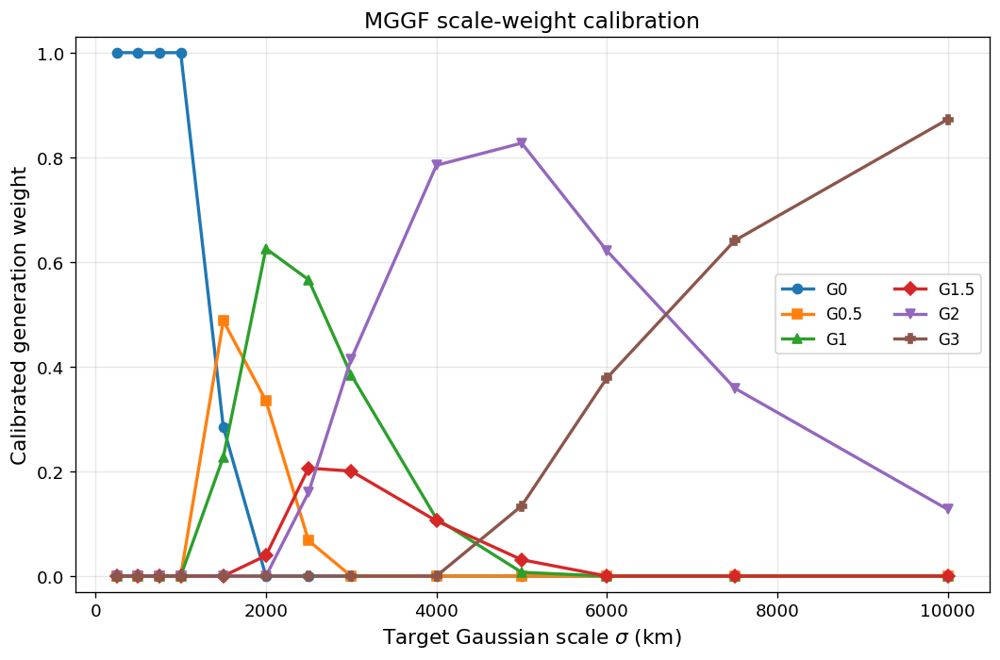

Saved:
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_calibration_error_vs_scale.pdf
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_calibration_error_vs_scale.png


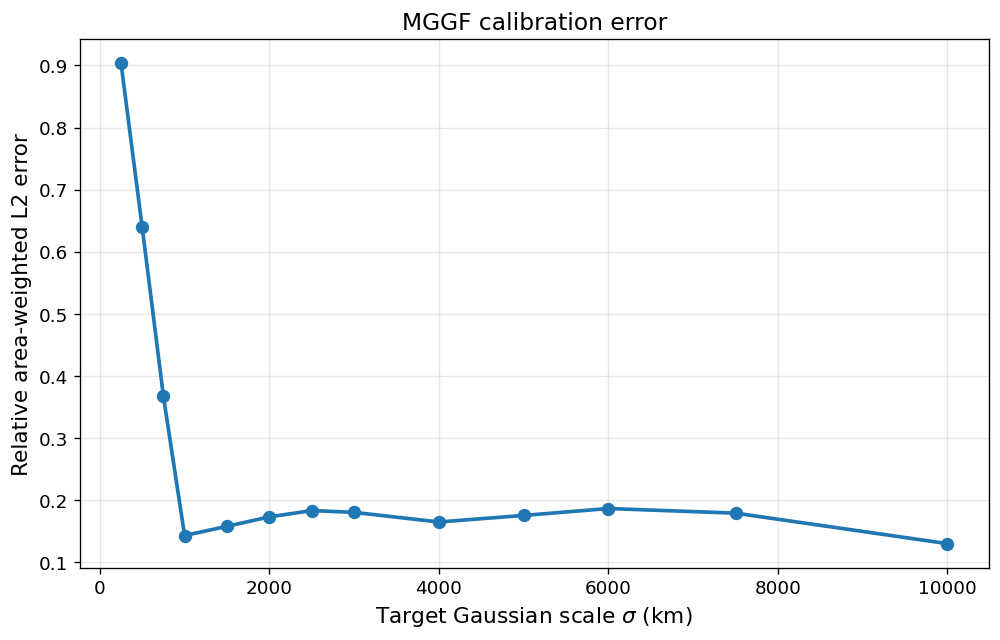

Saved:
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_rms_spread_vs_scale.pdf
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_rms_spread_vs_scale.png


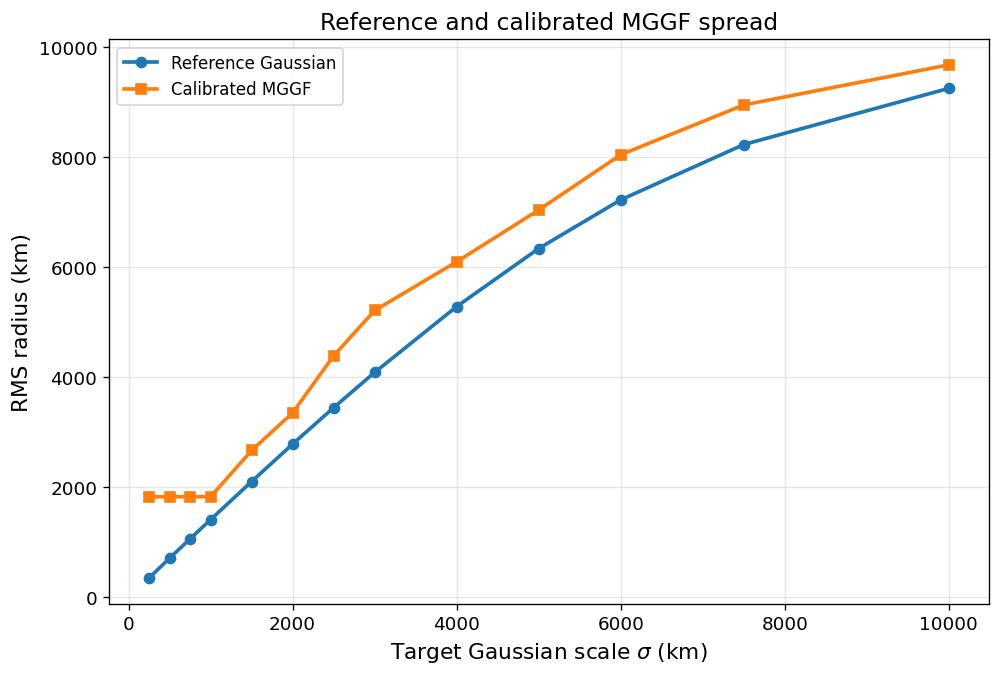

Saved:
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_radial_response_sigma_01000km.pdf
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_radial_response_sigma_01000km.png


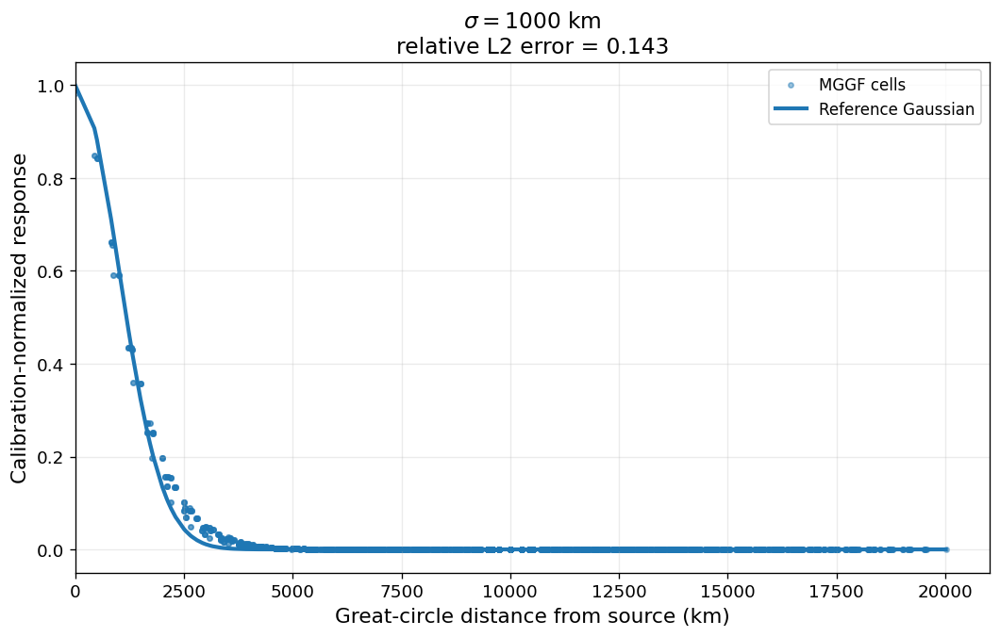

Saved:
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_radial_response_sigma_02000km.pdf
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_radial_response_sigma_02000km.png


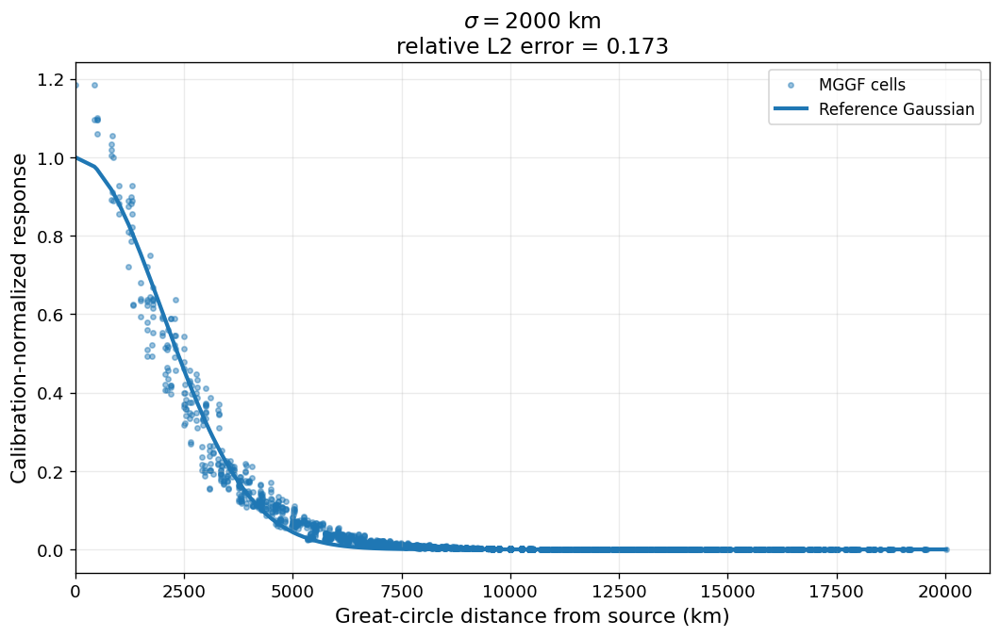

Saved:
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_radial_response_sigma_05000km.pdf
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_radial_response_sigma_05000km.png


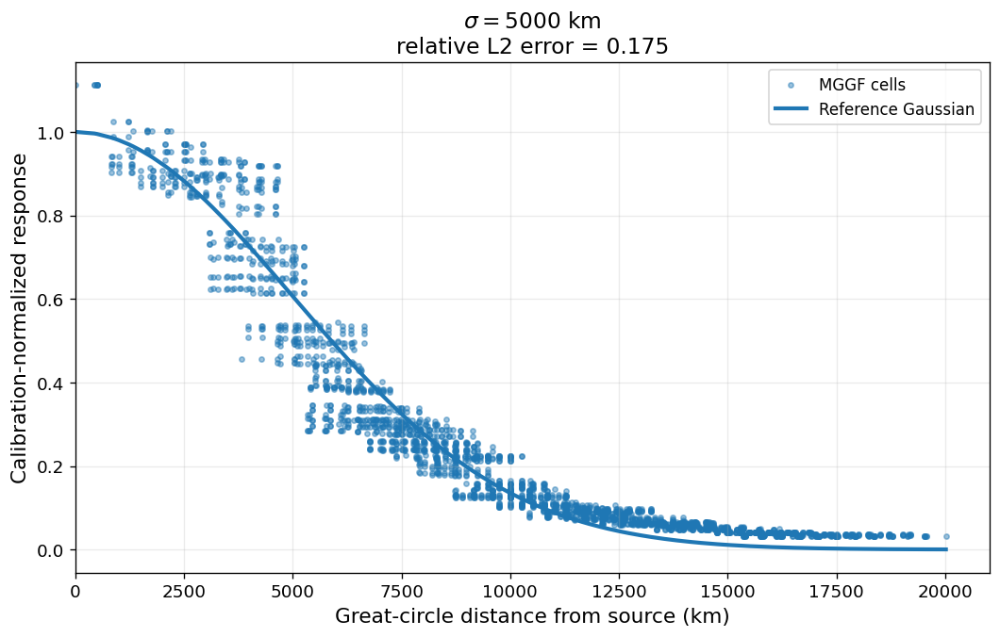

Saved:
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_radial_response_sigma_10000km.pdf
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_radial_response_sigma_10000km.png


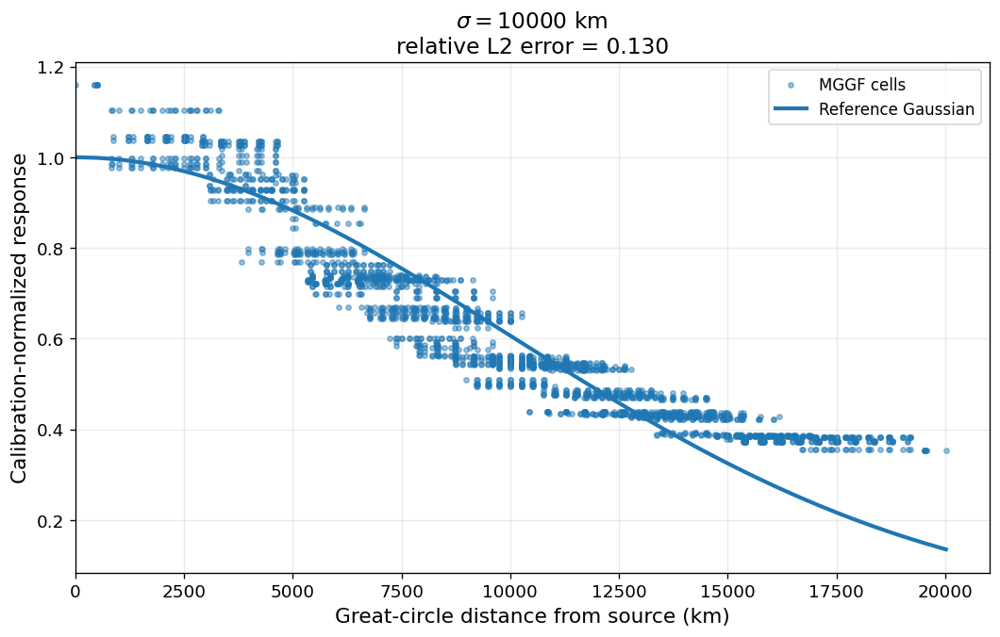


Checking Cartopy...
Cartopy already installed.


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved:
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_global_response_sigma_01000km.pdf
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_global_response_sigma_01000km.png


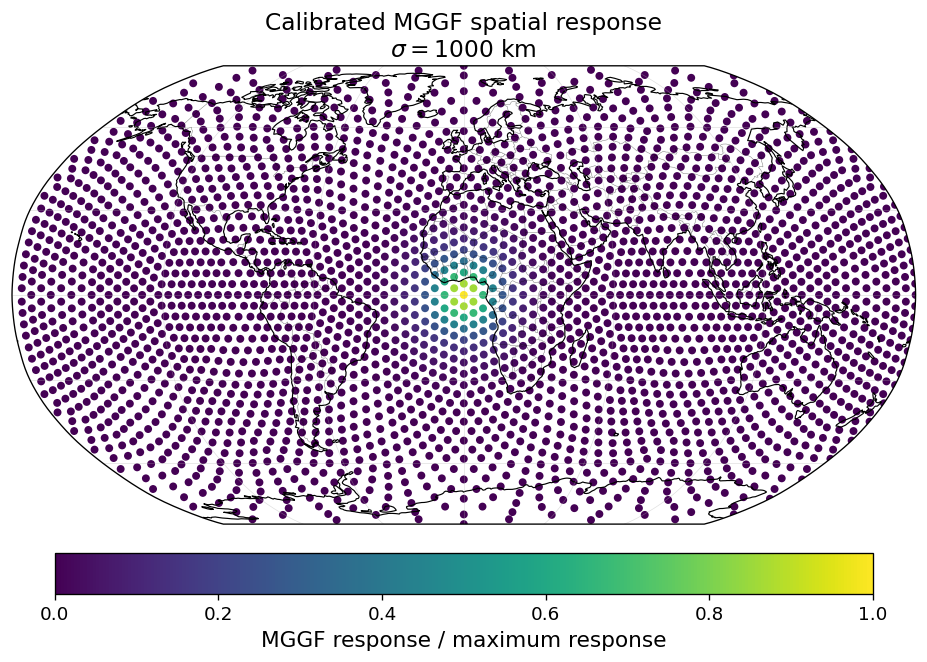

Saved:
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_global_response_sigma_05000km.pdf
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_global_response_sigma_05000km.png


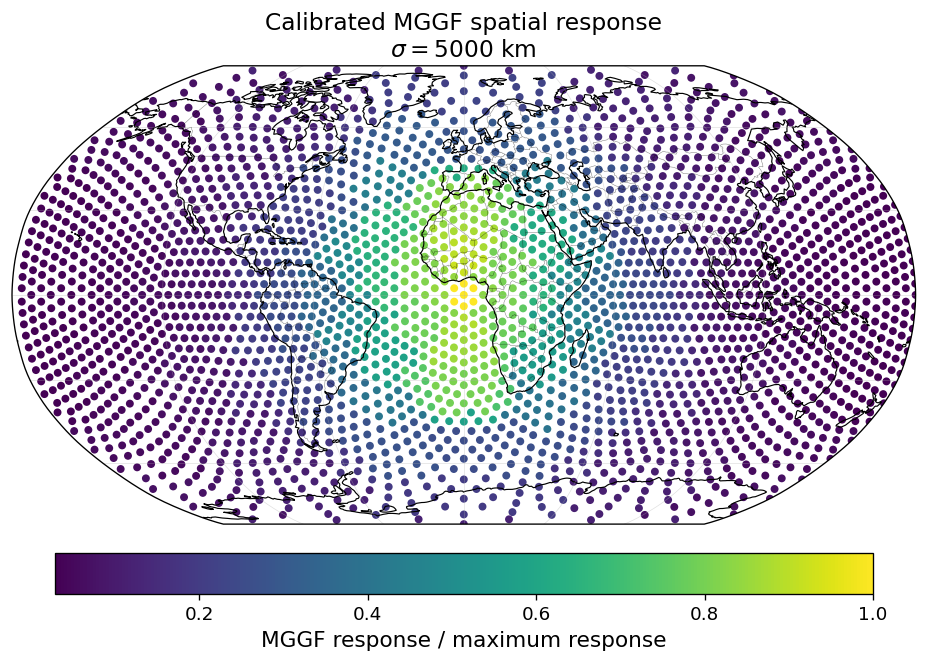

Saved:
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_global_response_sigma_10000km.pdf
  /content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures/mggf_global_response_sigma_10000km.png


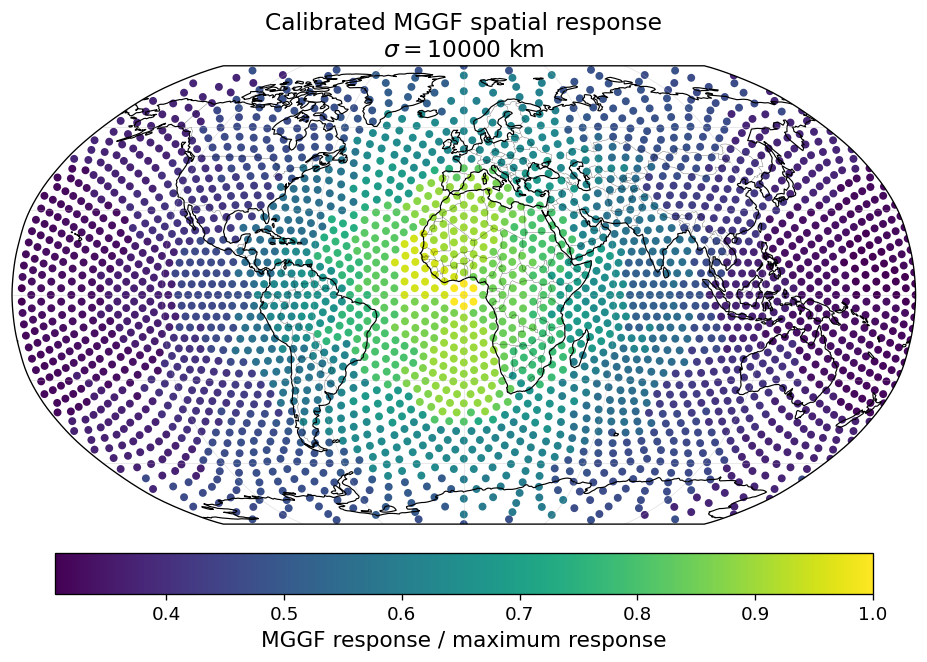



ALL CALIBRATION FIGURES COMPLETE

Output directory:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_figures

Main candidate paper figure:
  mggf_generation_weights_vs_scale.pdf

Supporting calibration figures:
  mggf_calibration_error_vs_scale.pdf
  mggf_rms_spread_vs_scale.pdf

Representative radial-response and global-map figures were also saved.


In [ ]:
# ============================================================
# MGGF CALIBRATION — PUBLICATION-QUALITY FIGURES
#
# Run AFTER the scale-weight calibration sweep.
#
# Produces:
#   Fig. 1  Generation weights versus Gaussian sigma
#   Fig. 2  Calibration relative L2 error versus sigma
#   Fig. 3  Reference RMS versus calibrated MGGF RMS
#   Fig. 4  Radial Gaussian/MGGF comparisons
#   Fig. 5  Global Cartopy maps for selected scales
#
# Files are saved as both PDF and PNG.
# ============================================================

import os
import sys
import subprocess
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 0. Output directory
# ------------------------------------------------------------

FIG_DIR = (
    "/content/drive/MyDrive/GLOBAL_SW_FV/"
    "mggf_calibration_figures"
)

os.makedirs(FIG_DIR, exist_ok=True)

print("Figures will be written to:")
print(FIG_DIR)


# ------------------------------------------------------------
# 1. General plotting settings
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})


# ------------------------------------------------------------
# Utility for saving PDF + PNG
# ------------------------------------------------------------

def save_figure(fig, basename):

    pdf_file = os.path.join(
        FIG_DIR,
        basename + ".pdf"
    )

    png_file = os.path.join(
        FIG_DIR,
        basename + ".png"
    )

    fig.savefig(
        pdf_file,
        bbox_inches="tight"
    )

    fig.savefig(
        png_file,
        dpi=300,
        bbox_inches="tight"
    )

    print("Saved:")
    print(" ", pdf_file)
    print(" ", png_file)


# ============================================================
# FIGURE 1
# GENERATION WEIGHTS VERSUS TARGET GAUSSIAN SCALE
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.0, 6.0)
)

markers = [
    "o",
    "s",
    "^",
    "D",
    "v",
    "P"
]

for k, label in enumerate(labels6):

    ax.plot(
        SIGMA_LIST_KM,
        weights_all[:, k],
        marker=markers[k],
        linewidth=2.0,
        markersize=6,
        label=label
    )

ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "Calibrated generation weight"
)

ax.set_ylim(
    -0.03,
    1.03
)

ax.grid(
    True,
    alpha=0.30
)

ax.legend(
    ncol=2,
    frameon=True
)

ax.set_title(
    "MGGF scale-weight calibration"
)

fig.tight_layout()

save_figure(
    fig,
    "mggf_generation_weights_vs_scale"
)

plt.show()


# ============================================================
# FIGURE 2
# RELATIVE L2 CALIBRATION ERROR
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)

ax.plot(
    SIGMA_LIST_KM,
    rel_l2_all,
    marker="o",
    linewidth=2.2,
    markersize=7
)

ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "Relative area-weighted L2 error"
)

ax.grid(
    True,
    alpha=0.30
)

ax.set_title(
    "MGGF calibration error"
)

fig.tight_layout()

save_figure(
    fig,
    "mggf_calibration_error_vs_scale"
)

plt.show()


# ============================================================
# FIGURE 3
# RMS SPREAD COMPARISON
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.8)
)

ax.plot(
    SIGMA_LIST_KM,
    rms_ref_all,
    marker="o",
    linewidth=2.2,
    markersize=6,
    label="Reference Gaussian"
)

ax.plot(
    SIGMA_LIST_KM,
    rms_cal_all,
    marker="s",
    linewidth=2.2,
    markersize=6,
    label="Calibrated MGGF"
)

ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "RMS radius (km)"
)

ax.grid(
    True,
    alpha=0.30
)

ax.legend(
    frameon=True
)

ax.set_title(
    "Reference and calibrated MGGF spread"
)

fig.tight_layout()

save_figure(
    fig,
    "mggf_rms_spread_vs_scale"
)

plt.show()


# ============================================================
# FIGURE 4
# REPRESENTATIVE RADIAL RESPONSES
#
# We use:
#   sigma = 1000 km
#   sigma = 2000 km
#   sigma = 5000 km
#   sigma = 10000 km
#
# IMPORTANT:
# MGGF response is multiplied by calibration amplitude here
# ONLY so it can be compared with the unit-peak Gaussian.
# ============================================================

REPRESENTATIVE_SIGMA = [
    1000.,
    2000.,
    5000.,
    10000.
]

distance_km = (
    distance_m / 1000.0
)

sort_index = np.argsort(
    distance_km
)

r_sorted = distance_km[
    sort_index
]


for sigma_km in REPRESENTATIVE_SIGMA:

    idx = int(
        np.argmin(
            np.abs(
                SIGMA_LIST_KM
                - sigma_km
            )
        )
    )

    sigma_actual = (
        SIGMA_LIST_KM[idx]
    )

    weights = (
        weights_all[idx]
    )

    amplitude = (
        amplitude_all[idx]
    )

    # Unit-peak reference Gaussian
    target = np.exp(
        -0.5
        * (
            distance_m
            / (
                sigma_actual
                * 1000.0
            )
        )**2
    )

    # Operational MGGF response
    operational_response = (
        B6 @ weights
    )

    # Calibration-only amplitude adjustment
    calibration_response = (
        amplitude
        * operational_response
    )

    target_sorted = target[
        sort_index
    ]

    response_sorted = (
        calibration_response[
            sort_index
        ]
    )

    fig, ax = plt.subplots(
        figsize=(9.0, 5.8)
    )

    # Scatter is preferable for the icosahedral grid:
    # connecting every cell in radial order can exaggerate
    # grid-scale oscillations.

    ax.scatter(
        r_sorted,
        response_sorted,
        s=10,
        alpha=0.45,
        label="MGGF cells"
    )

    ax.plot(
        r_sorted,
        target_sorted,
        linewidth=2.5,
        label="Reference Gaussian"
    )

    ax.set_xlabel(
        "Great-circle distance from source (km)"
    )

    ax.set_ylabel(
        "Calibration-normalized response"
    )

    ax.set_xlim(
        left=0.0
    )

    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend(
        frameon=True
    )

    ax.set_title(
        rf"$\sigma={sigma_actual:.0f}$ km"
        + "\n"
        + rf"relative L2 error = "
        + rf"{rel_l2_all[idx]:.3f}"
    )

    fig.tight_layout()

    basename = (
        "mggf_radial_response_"
        + f"sigma_{int(sigma_actual):05d}km"
    )

    save_figure(
        fig,
        basename
    )

    plt.show()


# ============================================================
# FIGURE 5
# CARTOPY GLOBAL MAPS
#
# Selected scales:
#   1000 km
#   5000 km
#   10000 km
#
# Each map shows the calibration-normalized MGGF response.
# ============================================================

print("\nChecking Cartopy...")

try:

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    print("Cartopy already installed.")

except ImportError:

    print(
        "Cartopy not found. "
        "Installing Cartopy..."
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "cartopy"
        ]
    )

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    print(
        "Cartopy installed successfully."
    )


# ------------------------------------------------------------
# Obtain longitude / latitude from the G0 grid.
#
# Prefer variables already loaded in notebook.
# Otherwise recover from xyz0.
# ------------------------------------------------------------

if "lon0" in globals() and "lat0" in globals():

    plot_lon = np.asarray(lon0)
    plot_lat = np.asarray(lat0)

elif (
    "xyz0" in globals()
):

    xyz_plot = np.asarray(xyz0)

    plot_lon = np.degrees(
        np.arctan2(
            xyz_plot[:, 1],
            xyz_plot[:, 0]
        )
    )

    plot_lat = np.degrees(
        np.arcsin(
            np.clip(
                xyz_plot[:, 2],
                -1.0,
                1.0
            )
        )
    )

else:

    raise RuntimeError(
        "Could not find lon0/lat0 or xyz0 "
        "for Cartopy plotting."
    )


# ------------------------------------------------------------
# Check whether stored lon/lat appear to be radians.
# ------------------------------------------------------------

if (
    np.nanmax(np.abs(plot_lon))
    <= 2.0 * np.pi + 0.1
):

    plot_lon = np.degrees(
        plot_lon
    )

if (
    np.nanmax(np.abs(plot_lat))
    <= np.pi / 2.0 + 0.1
):

    plot_lat = np.degrees(
        plot_lat
    )


MAP_SIGMA = [
    1000.,
    5000.,
    10000.
]


for sigma_km in MAP_SIGMA:

    idx = int(
        np.argmin(
            np.abs(
                SIGMA_LIST_KM
                - sigma_km
            )
        )
    )

    sigma_actual = (
        SIGMA_LIST_KM[idx]
    )

    weights = (
        weights_all[idx]
    )

    amplitude = (
        amplitude_all[idx]
    )

    operational_response = (
        B6 @ weights
    )

    calibration_response = (
        amplitude
        * operational_response
    )

    # Normalize by maximum for map display only.
    #
    # This gives a dimensionless 0--1 spatial shape.
    # It does NOT alter calibration or operational weights.

    map_response = (
        calibration_response
        / np.max(calibration_response)
    )

    fig = plt.figure(
        figsize=(11.0, 6.2)
    )

    ax = plt.axes(
        projection=ccrs.Robinson()
    )

    ax.set_global()

    ax.coastlines(
        linewidth=0.7
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.3,
        alpha=0.5
    )

    ax.gridlines(
        linewidth=0.4,
        alpha=0.4
    )

    sc = ax.scatter(
        plot_lon,
        plot_lat,
        c=map_response,
        s=14,
        transform=ccrs.PlateCarree()
    )

    cb = plt.colorbar(
        sc,
        ax=ax,
        orientation="horizontal",
        pad=0.05,
        shrink=0.80
    )

    cb.set_label(
        "MGGF response / maximum response"
    )

    ax.set_title(
        "Calibrated MGGF spatial response"
        + "\n"
        + rf"$\sigma={sigma_actual:.0f}$ km"
    )

    basename = (
        "mggf_global_response_"
        + f"sigma_{int(sigma_actual):05d}km"
    )

    save_figure(
        fig,
        basename
    )

    plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 72)
print("ALL CALIBRATION FIGURES COMPLETE")
print("=" * 72)

print(
    "\nOutput directory:"
)

print(
    FIG_DIR
)

print(
    "\nMain candidate paper figure:"
)

print(
    "  mggf_generation_weights_vs_scale.pdf"
)

print(
    "\nSupporting calibration figures:"
)

print(
    "  mggf_calibration_error_vs_scale.pdf"
)

print(
    "  mggf_rms_spread_vs_scale.pdf"
)

print(
    "\nRepresentative radial-response "
    "and global-map figures were also saved."
)

# Improved calibration

INDIVIDUAL GENERATION INTEGRALS
G0    : 9.9999999999999978e-01
G0.5  : 9.9999999999999822e-01
G1    : 9.9999999999999978e-01
G1.5  : 9.9999999999999944e-01
G2    : 9.9999999999999933e-01
G3    : 9.9999999999999900e-01

Maximum |integral - 1| = 1.776e-15


GENERATION RADIAL MOMENTS
G0    : M1 =  1563.370 km   RMS =  1823.786 km
G0.5  : M1 =  2186.893 km   RMS =  2558.172 km
G1    : M1 =  3114.166 km   RMS =  3610.107 km
G1.5  : M1 =  4060.899 km   RMS =  4737.235 km
G2    : M1 =  5693.976 km   RMS =  6522.172 km
G3    : M1 =  9085.908 km   RMS = 10056.917 km

Representable RMS interval using nonnegative normalized weights:
    1823.786 km  <= RMS <=  10056.917 km


IMPROVED MGGF CALIBRATION SWEEP
Gamma = 14.0, p = 5
Generations: G0, G0.5, G1, G1.5, G2, G3

sigma=    250 km  RMSref=   345.8  LSE_RMS=  1823.8  LSEerr= 0.9036  M2 constraint NOT REPRESENTABLE
sigma=    500 km  RMSref=   706.3  LSE_RMS=  1823.8  LSEerr= 0.6390  M2 constraint NOT REPRESENTABLE
sigma=    750 km  RMSref=  1058.

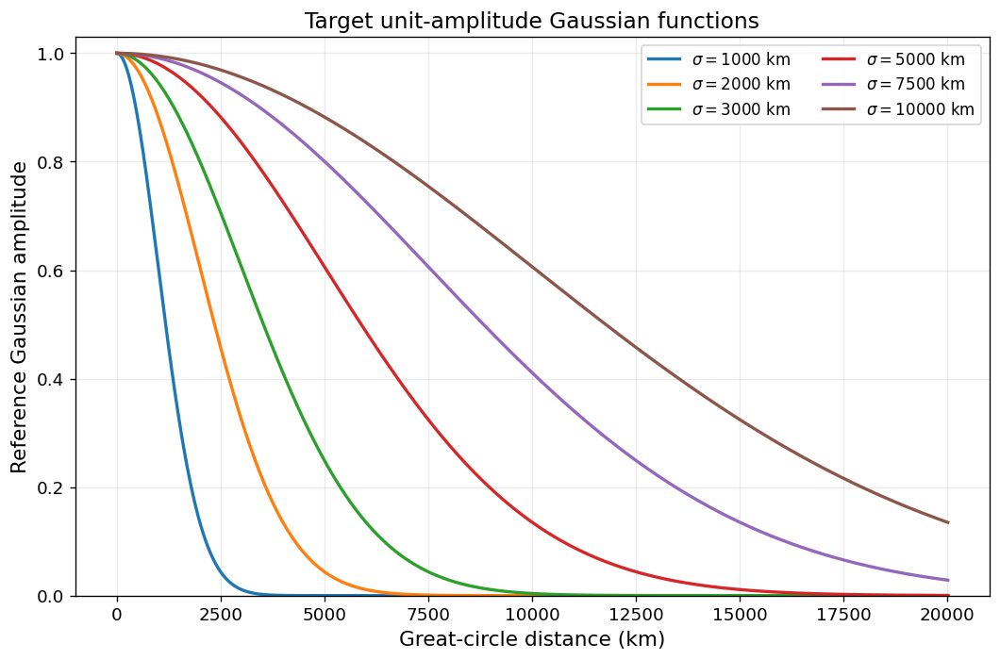

Saved: rms_reference_lse_m2


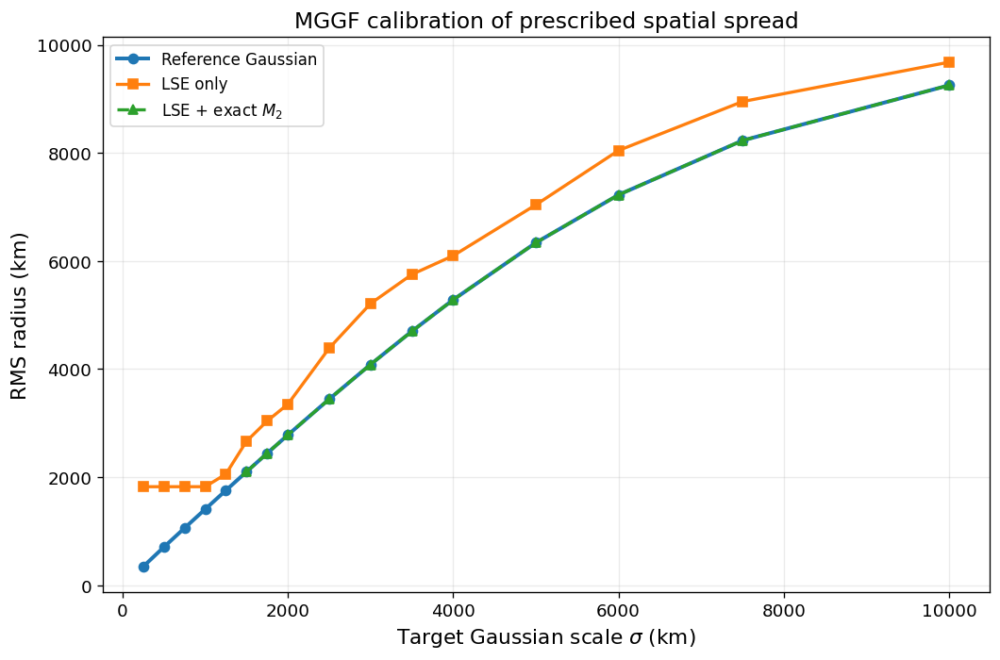

Saved: calibration_error_lse_vs_m2


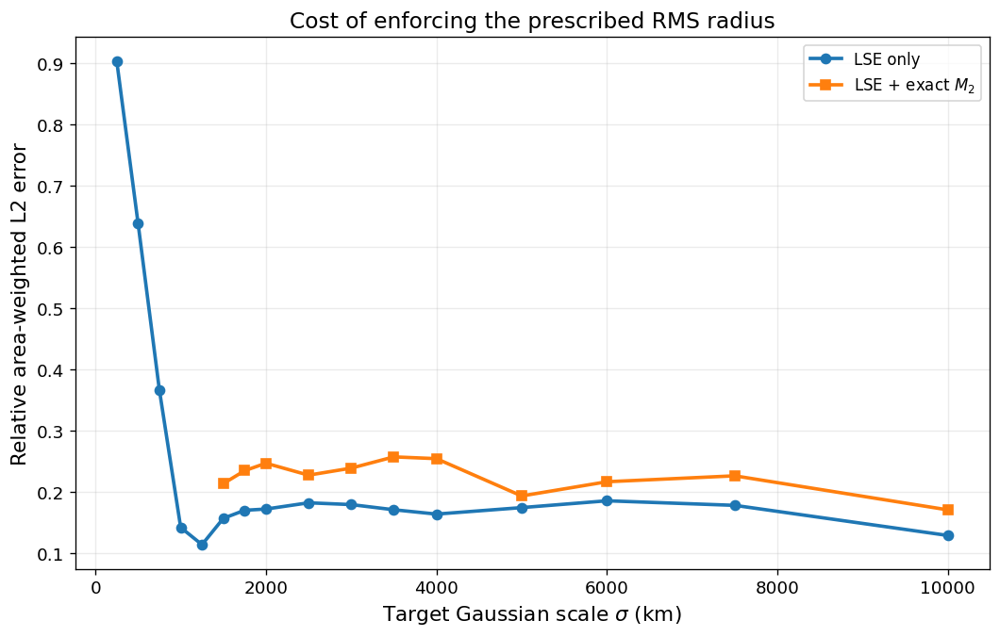

Saved: generation_weights_exact_m2


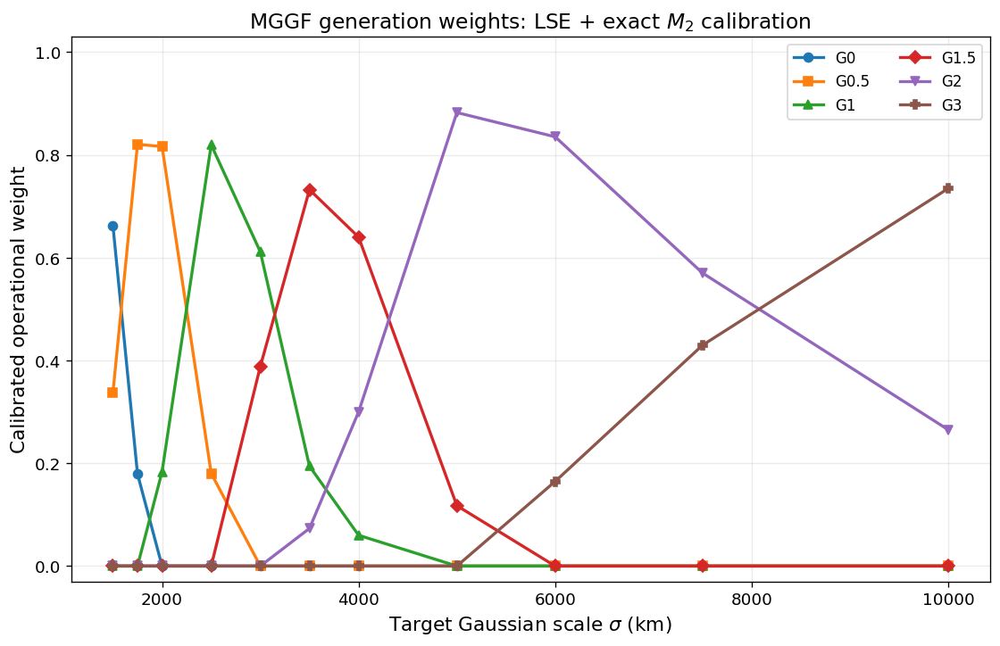

Saved: radial_comparison_sigma_01000km


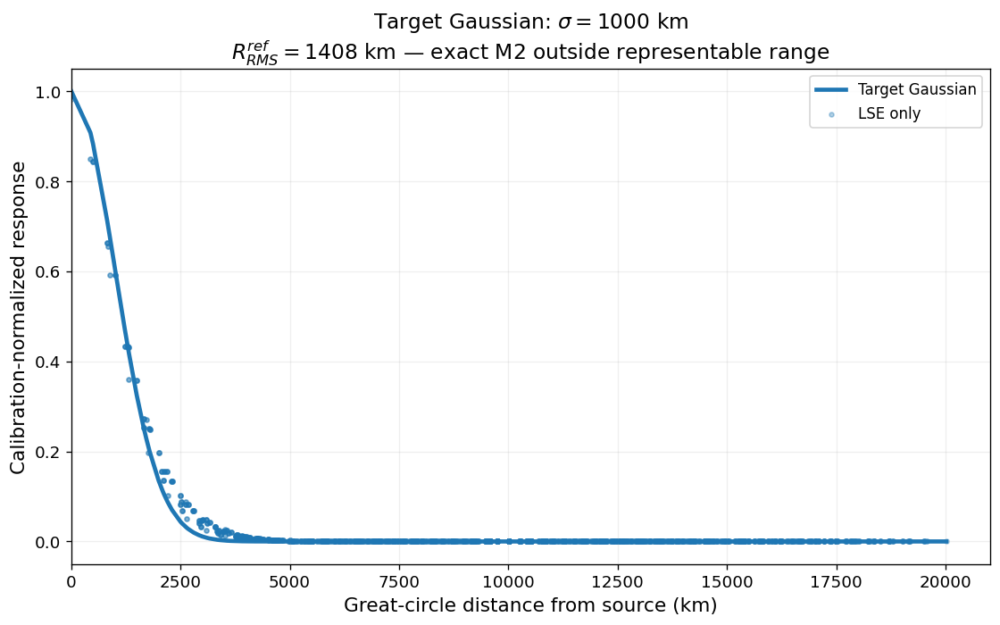

Saved: radial_comparison_sigma_02000km


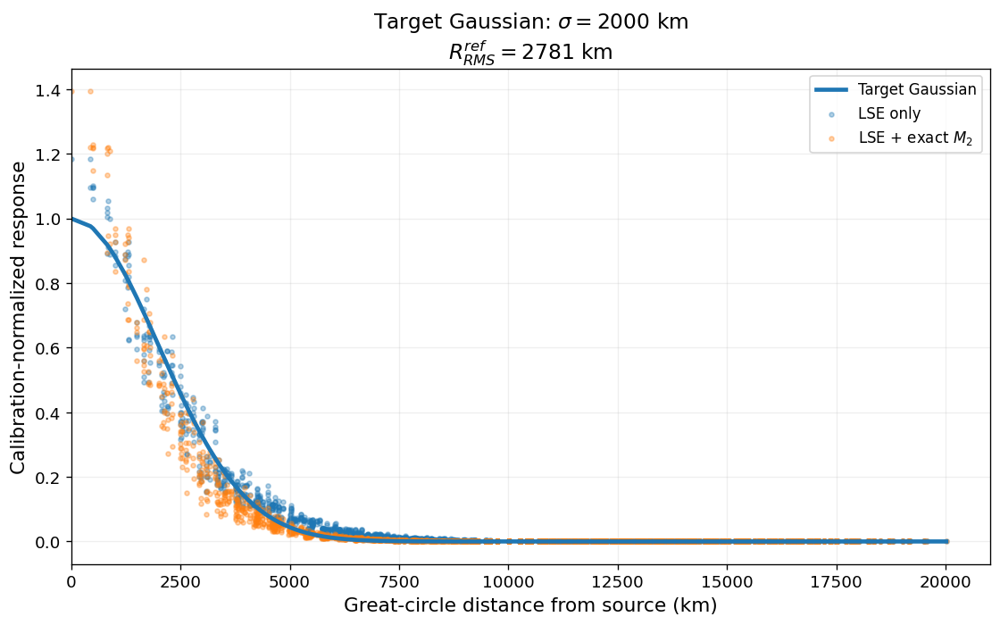

Saved: radial_comparison_sigma_05000km


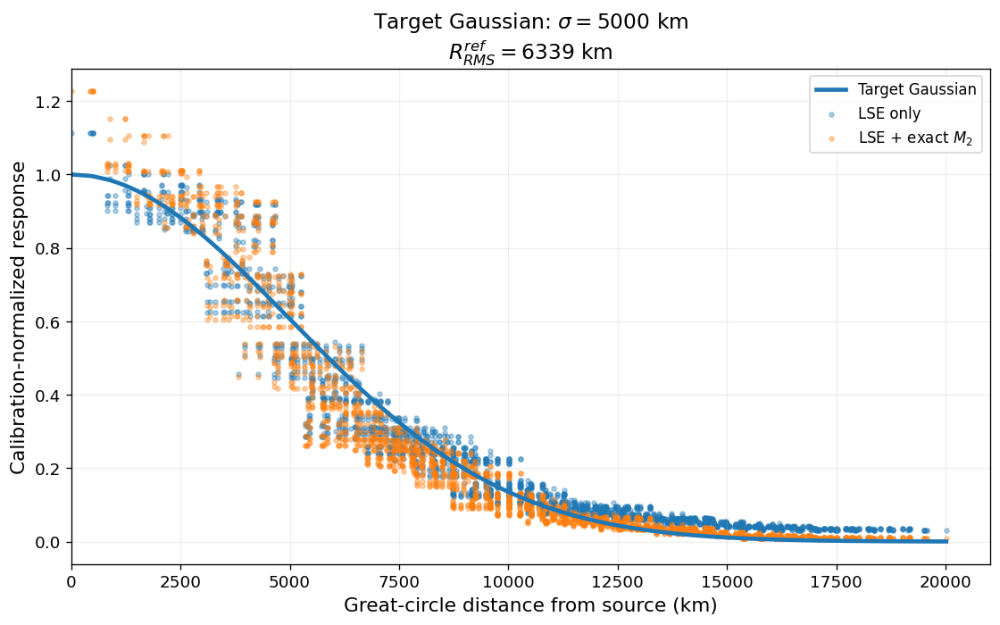

Saved: radial_comparison_sigma_10000km


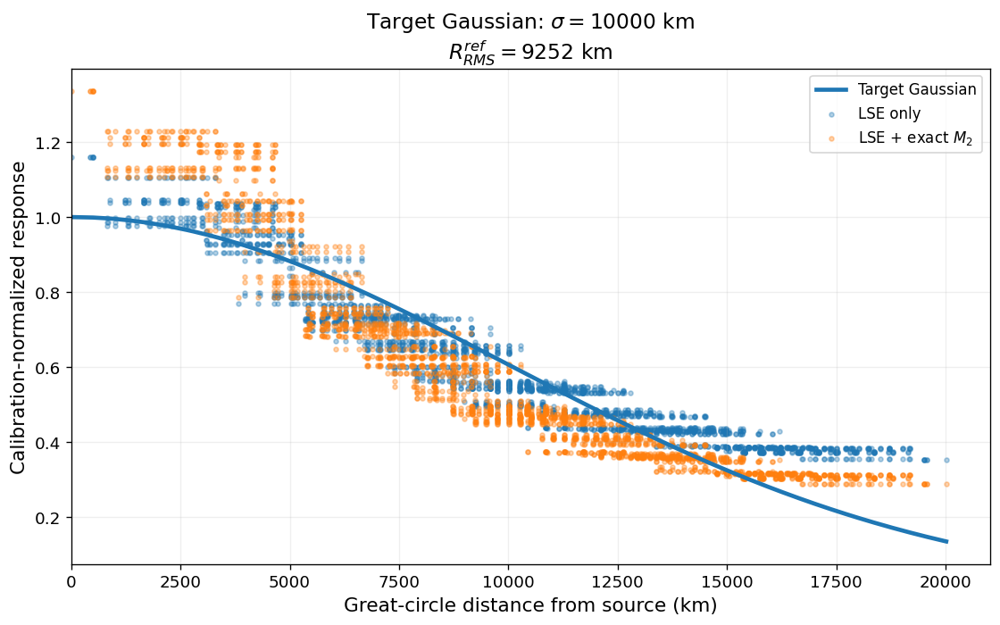



OFFLINE MGGF CALIBRATION COMPLETE

Fixed filter:
    Gamma = 14.0
    p     = 5
    generations = G0, G0.5, G1, G1.5, G2, G3

Representable RMS interval:
    1823.786 -- 10056.917 km

Number of requested scales:
    16

Number with exact-M2 solution:
    11

Operational product:
    sigma --> calibrated normalized generation weights

Calibration-only quantities:
    Gaussian fitting amplitudes
    LSE optimization

Operational application:
    NO optimization
    NO amplitude adjustment
    retrieve/interpolate weights
    apply conservative MGGF repeatedly

Results saved in:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_improved_calibration


In [ ]:
# ============================================================
# IMPROVED MGGF OFFLINE SCALE CALIBRATION
#
# Icosahedral MGGF
#
# Fixed filter parameters:
#     Gamma = 14
#     p     = 5
#     generations G0, G0.5, G1, G1.5, G2, G3
#
# For each target Gaussian scale sigma:
#
#   A) Unconstrained area-weighted nonnegative LSE
#
#   B) Area-weighted LSE with:
#
#          w_k >= 0
#          sum_k w_k = 1
#          sum_k w_k M2_k = M2_reference
#
#      i.e. exact matching of the second radial moment
#      (equivalently exact RMS radius).
#
# IMPORTANT:
#
# Calibration only:
#     Reference Gaussian has peak amplitude = 1.
#     MGGF amplitude is allowed to adjust for fair shape fitting.
#
# Application:
#     Calibration amplitude is DISCARDED.
#     Only normalized weights w_k(sigma) are retained.
#     Since sum(w_k)=1, operational MGGF remains conservative.
#
# The calibration is OFFLINE and performed once.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import nnls, minimize


# ============================================================
# 0. SETTINGS
# ============================================================

SIGMA_LIST_KM = np.array([
     250.,
     500.,
     750.,
    1000.,
    1250.,
    1500.,
    1750.,
    2000.,
    2500.,
    3000.,
    3500.,
    4000.,
    5000.,
    6000.,
    7500.,
   10000.
], dtype=float)


# Representative scales for profile plots.
REPRESENTATIVE_SIGMA_KM = [
    1000.,
    2000.,
    5000.,
    10000.
]


FIG_DIR = (
    "/content/drive/MyDrive/GLOBAL_SW_FV/"
    "mggf_improved_calibration"
)

os.makedirs(
    FIG_DIR,
    exist_ok=True
)


# ============================================================
# 1. SIX-GENERATION BASIS
# ============================================================

labels6 = [
    "G0",
    "G0.5",
    "G1",
    "G1.5",
    "G2",
    "G3"
]


# Use existing B6 if already constructed.
# Otherwise construct it from the generation responses.

if "B6" not in globals():

    B6 = np.column_stack([
        b0,
        b05,
        b1,
        b15,
        b2,
        b3
    ])


B6 = np.asarray(
    B6,
    dtype=np.float64
)

ng = B6.shape[1]

assert ng == 6


# ============================================================
# 2. BASIC GRID ARRAYS
# ============================================================

area = np.asarray(
    area0,
    dtype=np.float64
)

r_m = np.asarray(
    distance_m,
    dtype=np.float64
)

r_km = r_m / 1000.0

ncell = len(area)

assert B6.shape[0] == ncell
assert len(r_m) == ncell


# ============================================================
# 3. VERIFY CONSERVATION OF INDIVIDUAL GENERATIONS
# ============================================================

generation_integrals = (
    area @ B6
)

print("=" * 78)
print("INDIVIDUAL GENERATION INTEGRALS")
print("=" * 78)

for label, integ in zip(
    labels6,
    generation_integrals
):

    print(
        f"{label:5s} : "
        f"{integ:.16e}"
    )


print(
    "\nMaximum |integral - 1| = "
    f"{np.max(np.abs(generation_integrals - 1.0)):.3e}"
)


# ============================================================
# 4. GENERATION MOMENTS
#
# Because each generation is conservative:
#
#       integral b_k dA = 1
#
# the moments are simply:
#
#       M1_k = integral r b_k dA
#       M2_k = integral r^2 b_k dA
#
# For normalized operational weights:
#
#       M2(sum w_k b_k)
#         = sum w_k M2_k
#
# This makes the exact M2 constraint LINEAR in the weights.
# ============================================================

M1_generation = np.zeros(ng)
M2_generation = np.zeros(ng)
RMS_generation_km = np.zeros(ng)


for k in range(ng):

    bk = B6[:, k]

    mass_k = float(
        area @ bk
    )

    M1_generation[k] = (
        float(
            area @ (r_m * bk)
        )
        / mass_k
    )

    M2_generation[k] = (
        float(
            area @ (
                r_m**2 * bk
            )
        )
        / mass_k
    )

    RMS_generation_km[k] = (
        np.sqrt(
            M2_generation[k]
        )
        / 1000.0
    )


print("\n")
print("=" * 78)
print("GENERATION RADIAL MOMENTS")
print("=" * 78)

for k, label in enumerate(labels6):

    print(
        f"{label:5s} : "
        f"M1 = "
        f"{M1_generation[k]/1000.0:9.3f} km   "
        f"RMS = "
        f"{RMS_generation_km[k]:9.3f} km"
    )


RMS_MIN_KM = np.min(
    RMS_generation_km
)

RMS_MAX_KM = np.max(
    RMS_generation_km
)

print(
    "\nRepresentable RMS interval using "
    "nonnegative normalized weights:"
)

print(
    f"    {RMS_MIN_KM:.3f} km"
    f"  <= RMS <=  "
    f"{RMS_MAX_KM:.3f} km"
)


# ============================================================
# 5. AREA-WEIGHTED LEAST-SQUARES MATRIX
#
# Multiplying by sqrt(area) converts:
#
#     sum_i A_i residual_i^2
#
# into ordinary Euclidean least squares.
#
# Dividing area by mean(area) changes only the common
# objective scale, not the solution.
# ============================================================

sqrt_area = np.sqrt(
    area / np.mean(area)
)

Aw = (
    sqrt_area[:, None]
    * B6
)


# ============================================================
# 6. UTILITY FUNCTIONS
# ============================================================

def radial_moments(field):

    """
    Return:
        mass
        M1 [m]
        M2 [m^2]
        RMS [km]
    """

    f = np.asarray(
        field,
        dtype=np.float64
    )

    mass = float(
        area @ f
    )

    if mass <= 0.0:

        return (
            mass,
            np.nan,
            np.nan,
            np.nan
        )

    M1 = (
        float(
            area @ (
                r_m * f
            )
        )
        / mass
    )

    M2 = (
        float(
            area @ (
                r_m**2 * f
            )
        )
        / mass
    )

    RMS = (
        np.sqrt(
            max(M2, 0.0)
        )
        / 1000.0
    )

    return (
        mass,
        M1,
        M2,
        RMS
    )


def weighted_relative_l2(
    model,
    reference
):

    diff = (
        model - reference
    )

    numerator = float(
        area @ (
            diff**2
        )
    )

    denominator = float(
        area @ (
            reference**2
        )
    )

    return np.sqrt(
        numerator / denominator
    )


def optimal_amplitude(
    shape,
    target
):

    """
    Optimal amplitude a minimizing

        sum A_i (a*shape_i - target_i)^2

    for fixed shape.
    """

    numerator = float(
        area @ (
            shape * target
        )
    )

    denominator = float(
        area @ (
            shape**2
        )
    )

    if denominator <= 0.0:

        return np.nan

    return (
        numerator / denominator
    )


# ============================================================
# 7. STORAGE
# ============================================================

nsigma = len(
    SIGMA_LIST_KM
)


# Reference diagnostics
ref_M1_km = np.zeros(nsigma)
ref_M2 = np.zeros(nsigma)
ref_RMS_km = np.zeros(nsigma)


# ------------------------------------------------------------
# A. Unconstrained LSE
# ------------------------------------------------------------

weights_lse = np.zeros(
    (nsigma, ng)
)

amplitude_lse = np.zeros(
    nsigma
)

error_lse = np.zeros(
    nsigma
)

RMS_lse_km = np.zeros(
    nsigma
)

source_ratio_lse = np.zeros(
    nsigma
)


# ------------------------------------------------------------
# B. Exact M2 constrained calibration
# ------------------------------------------------------------

weights_m2 = np.full(
    (nsigma, ng),
    np.nan
)

amplitude_m2 = np.full(
    nsigma,
    np.nan
)

error_m2 = np.full(
    nsigma,
    np.nan
)

RMS_m2_km = np.full(
    nsigma,
    np.nan
)

source_ratio_m2 = np.full(
    nsigma,
    np.nan
)

m2_feasible = np.zeros(
    nsigma,
    dtype=bool
)

m2_success = np.zeros(
    nsigma,
    dtype=bool
)


# ============================================================
# 8. CALIBRATION SWEEP
# ============================================================

print("\n")
print("=" * 110)
print("IMPROVED MGGF CALIBRATION SWEEP")
print("=" * 110)

print(
    f"Gamma = {GAMMA}, "
    f"p = {P_ORDER}"
)

print(
    "Generations: "
    + ", ".join(labels6)
)

print()


for j, sigma_km in enumerate(
    SIGMA_LIST_KM
):

    sigma_m = (
        sigma_km * 1000.0
    )


    # ========================================================
    # REFERENCE GAUSSIAN
    #
    # Unit peak:
    #
    #     G(0) = 1
    # ========================================================

    target = np.exp(
        -0.5
        * (
            r_m / sigma_m
        )**2
    )


    (
        target_mass,
        target_M1,
        target_M2,
        target_RMS
    ) = radial_moments(
        target
    )


    ref_M1_km[j] = (
        target_M1 / 1000.0
    )

    ref_M2[j] = (
        target_M2
    )

    ref_RMS_km[j] = (
        target_RMS
    )


    # ========================================================
    # A. UNCONSTRAINED NONNEGATIVE LSE
    #
    # Solve directly for coefficients:
    #
    #       c_k >= 0
    #
    # then:
    #
    #       a = sum c_k
    #       w_k = c_k / a
    #
    # so:
    #
    #       c_k = a w_k
    # ========================================================

    yw = (
        sqrt_area
        * target
    )

    coeff, residual_norm = nnls(
        Aw,
        yw
    )

    amp_A = float(
        np.sum(coeff)
    )

    if amp_A <= 0.0:

        raise RuntimeError(
            "Nonpositive unconstrained "
            f"amplitude at sigma={sigma_km}"
        )

    w_A = (
        coeff / amp_A
    )

    shape_A = (
        B6 @ w_A
    )

    fitted_A = (
        amp_A * shape_A
    )

    err_A = weighted_relative_l2(
        fitted_A,
        target
    )

    (
        _,
        _,
        _,
        rms_A
    ) = radial_moments(
        shape_A
    )

    weights_lse[j, :] = (
        w_A
    )

    amplitude_lse[j] = (
        amp_A
    )

    error_lse[j] = (
        err_A
    )

    RMS_lse_km[j] = (
        rms_A
    )

    source_ratio_lse[j] = (
        fitted_A[SOURCE_G0]
        / target[SOURCE_G0]
    )


    # ========================================================
    # B. EXACT SECOND-MOMENT CONSTRAINT
    #
    # Feasibility:
    #
    # Because weights are nonnegative and sum to one,
    # target M2 must lie between min and max generation M2.
    # ========================================================

    M2_min = np.min(
        M2_generation
    )

    M2_max = np.max(
        M2_generation
    )

    tol_M2 = (
        1.0e-10
        * max(
            abs(M2_min),
            abs(M2_max),
            1.0
        )
    )

    feasible = (
        target_M2 >= M2_min - tol_M2
        and
        target_M2 <= M2_max + tol_M2
    )

    m2_feasible[j] = (
        feasible
    )


    if feasible:

        # ----------------------------------------------------
        # Optimize only normalized weights w.
        #
        # For every candidate w, compute the analytically
        # optimal calibration-only amplitude a(w).
        #
        # This leaves:
        #
        #   w >= 0
        #   sum(w) = 1
        #   M2_generation . w = target_M2
        #
        # ----------------------------------------------------

        def objective_w(w):

            shape = (
                B6 @ w
            )

            amp = optimal_amplitude(
                shape,
                target
            )

            if (
                not np.isfinite(amp)
                or amp <= 0.0
            ):

                return 1.0e100

            fitted = (
                amp * shape
            )

            residual = (
                fitted - target
            )

            return float(
                (
                    area
                    @ (
                        residual**2
                    )
                )
                /
                (
                    area
                    @ (
                        target**2
                    )
                )
            )


        constraints = [

            {
                "type": "eq",
                "fun": lambda w:
                    np.sum(w) - 1.0
            },

            {
                "type": "eq",
                "fun": lambda w,
                target_M2=target_M2:
                    (
                        np.dot(
                            M2_generation,
                            w
                        )
                        - target_M2
                    )
                    / target_M2
            }
        ]


        bounds = [
            (0.0, 1.0)
            for _ in range(ng)
        ]


        # ----------------------------------------------------
        # Construct a guaranteed-feasible initial solution.
        #
        # Find two neighboring generations whose M2 values
        # bracket the target M2.
        # ----------------------------------------------------

        order = np.argsort(
            M2_generation
        )

        m2_sorted = (
            M2_generation[order]
        )

        w0 = np.zeros(
            ng
        )


        if (
            abs(
                target_M2
                - m2_sorted[0]
            )
            <= tol_M2
        ):

            w0[
                order[0]
            ] = 1.0


        elif (
            abs(
                target_M2
                - m2_sorted[-1]
            )
            <= tol_M2
        ):

            w0[
                order[-1]
            ] = 1.0


        else:

            bracket_found = False

            for q in range(
                ng - 1
            ):

                mlo = (
                    m2_sorted[q]
                )

                mhi = (
                    m2_sorted[q + 1]
                )

                if (
                    target_M2 >= mlo
                    and
                    target_M2 <= mhi
                ):

                    if (
                        abs(
                            mhi - mlo
                        )
                        < 1.0e-30
                    ):

                        alpha = 0.5

                    else:

                        alpha = (
                            target_M2
                            - mlo
                        ) / (
                            mhi
                            - mlo
                        )

                    w0[
                        order[q]
                    ] = (
                        1.0 - alpha
                    )

                    w0[
                        order[q + 1]
                    ] = (
                        alpha
                    )

                    bracket_found = True

                    break


            if not bracket_found:

                raise RuntimeError(
                    "Could not construct feasible "
                    "initial M2 weights."
                )


        result = minimize(
            objective_w,
            w0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={
                "ftol": 1.0e-12,
                "maxiter": 2000,
                "disp": False
            }
        )


        if result.success:

            w_B = np.asarray(
                result.x,
                dtype=np.float64
            )

            # Remove tiny numerical negative values.
            w_B[
                np.abs(w_B) < 1.0e-12
            ] = 0.0

            # Renormalization should be tiny.
            w_B = (
                w_B
                / np.sum(w_B)
            )

            shape_B = (
                B6 @ w_B
            )

            amp_B = optimal_amplitude(
                shape_B,
                target
            )

            fitted_B = (
                amp_B * shape_B
            )

            err_B = weighted_relative_l2(
                fitted_B,
                target
            )

            (
                _,
                _,
                _,
                rms_B
            ) = radial_moments(
                shape_B
            )

            weights_m2[j, :] = (
                w_B
            )

            amplitude_m2[j] = (
                amp_B
            )

            error_m2[j] = (
                err_B
            )

            RMS_m2_km[j] = (
                rms_B
            )

            source_ratio_m2[j] = (
                fitted_B[SOURCE_G0]
                / target[SOURCE_G0]
            )

            m2_success[j] = True


        else:

            print(
                "\nWARNING:"
            )

            print(
                f"Constrained optimization failed "
                f"at sigma={sigma_km:.0f} km"
            )

            print(
                result.message
            )


    # ========================================================
    # PRINT SCALE SUMMARY
    # ========================================================

    print(
        f"sigma={sigma_km:7.0f} km  "
        f"RMSref={target_RMS:8.1f}  "
        f"LSE_RMS={rms_A:8.1f}  "
        f"LSEerr={err_A:7.4f}",
        end=""
    )

    if m2_success[j]:

        print(
            f"  M2_RMS={RMS_m2_km[j]:8.1f}  "
            f"M2err={error_m2[j]:7.4f}"
        )

    elif feasible:

        print(
            "  M2 fit FAILED"
        )

    else:

        print(
            "  M2 constraint NOT REPRESENTABLE"
        )


# ============================================================
# 9. DETAILED WEIGHT TABLE
# ============================================================

print("\n")
print("=" * 120)
print("EXACT-M2 CALIBRATED OPERATIONAL WEIGHTS")
print("=" * 120)

print(
    f"{'sigma':>7s} "
    f"{'RMSref':>9s} "
    f"{'G0':>9s} "
    f"{'G0.5':>9s} "
    f"{'G1':>9s} "
    f"{'G1.5':>9s} "
    f"{'G2':>9s} "
    f"{'G3':>9s} "
    f"{'L2err':>9s} "
    f"{'RMSfit':>9s}"
)

print("-" * 120)


for j, sigma_km in enumerate(
    SIGMA_LIST_KM
):

    if m2_success[j]:

        w = (
            weights_m2[j]
        )

        print(
            f"{sigma_km:7.0f} "
            f"{ref_RMS_km[j]:9.1f} "
            f"{w[0]:9.5f} "
            f"{w[1]:9.5f} "
            f"{w[2]:9.5f} "
            f"{w[3]:9.5f} "
            f"{w[4]:9.5f} "
            f"{w[5]:9.5f} "
            f"{error_m2[j]:9.5f} "
            f"{RMS_m2_km[j]:9.1f}"
        )

    else:

        print(
            f"{sigma_km:7.0f} "
            f"{ref_RMS_km[j]:9.1f} "
            + "   NOT REPRESENTABLE"
        )


# ============================================================
# 10. VERIFY EXACT M2 MATCH
# ============================================================

print("\n")
print("=" * 78)
print("SECOND-MOMENT CONSTRAINT VERIFICATION")
print("=" * 78)

max_rms_error = 0.0
max_weight_sum_error = 0.0
max_integral_error = 0.0


for j, sigma_km in enumerate(
    SIGMA_LIST_KM
):

    if not m2_success[j]:
        continue

    w = (
        weights_m2[j]
    )

    operational_shape = (
        B6 @ w
    )

    operational_integral = float(
        area @ operational_shape
    )

    rms_error = abs(
        RMS_m2_km[j]
        - ref_RMS_km[j]
    )

    weight_error = abs(
        np.sum(w) - 1.0
    )

    integral_error = abs(
        operational_integral
        - 1.0
    )

    max_rms_error = max(
        max_rms_error,
        rms_error
    )

    max_weight_sum_error = max(
        max_weight_sum_error,
        weight_error
    )

    max_integral_error = max(
        max_integral_error,
        integral_error
    )


print(
    "Maximum RMS mismatch       = "
    f"{max_rms_error:.6e} km"
)

print(
    "Maximum |sum(weights)-1|   = "
    f"{max_weight_sum_error:.6e}"
)

print(
    "Maximum integral error     = "
    f"{max_integral_error:.6e}"
)


# ============================================================
# 11. SAVE NUMERICAL CALIBRATION TABLE
#
# This is the OFFLINE product that could eventually be
# interpolated and used operationally.
# ============================================================

output_npz = os.path.join(
    FIG_DIR,
    "mggf_scale_weight_calibration_G0_G3.npz"
)


np.savez(
    output_npz,

    sigma_km=SIGMA_LIST_KM,

    generation_labels=np.array(
        labels6
    ),

    generation_RMS_km=RMS_generation_km,

    reference_RMS_km=ref_RMS_km,

    weights_lse=weights_lse,

    amplitude_lse=amplitude_lse,

    relative_L2_lse=error_lse,

    RMS_lse_km=RMS_lse_km,

    weights_m2=weights_m2,

    amplitude_m2=amplitude_m2,

    relative_L2_m2=error_m2,

    RMS_m2_km=RMS_m2_km,

    m2_feasible=m2_feasible,

    m2_success=m2_success,

    Gamma=GAMMA,

    p=P_ORDER
)


print(
    "\nSaved calibration table:"
)

print(
    output_npz
)


# ============================================================
# 12. PLOTTING SETTINGS
# ============================================================

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300
})


def save_fig(
    fig,
    basename
):

    pdf = os.path.join(
        FIG_DIR,
        basename + ".pdf"
    )

    png = os.path.join(
        FIG_DIR,
        basename + ".png"
    )

    fig.savefig(
        pdf,
        bbox_inches="tight"
    )

    fig.savefig(
        png,
        dpi=300,
        bbox_inches="tight"
    )

    print(
        "Saved:",
        basename
    )


# ============================================================
# FIGURE 1
# FAMILY OF TARGET GAUSSIANS
# ============================================================

GAUSSIAN_PLOT_SIGMA = [
    1000.,
    2000.,
    3000.,
    5000.,
    7500.,
    10000.
]


r_plot_km = np.linspace(
    0.0,
    np.max(r_km),
    1000
)


fig, ax = plt.subplots(
    figsize=(9.0, 6.0)
)


for sigma_km in GAUSSIAN_PLOT_SIGMA:

    gaussian = np.exp(
        -0.5
        * (
            r_plot_km
            / sigma_km
        )**2
    )

    ax.plot(
        r_plot_km,
        gaussian,
        linewidth=2.0,
        label=rf"$\sigma={sigma_km:.0f}$ km"
    )


ax.set_xlabel(
    "Great-circle distance (km)"
)

ax.set_ylabel(
    "Reference Gaussian amplitude"
)

ax.set_ylim(
    0.0,
    1.03
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    ncol=2
)

ax.set_title(
    "Target unit-amplitude Gaussian functions"
)

fig.tight_layout()

save_fig(
    fig,
    "target_gaussian_family"
)

plt.show()


# ============================================================
# FIGURE 2
# RMS SPREAD:
# REFERENCE vs LSE vs EXACT-M2 CALIBRATION
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.0, 6.0)
)


ax.plot(
    SIGMA_LIST_KM,
    ref_RMS_km,
    marker="o",
    linewidth=2.4,
    label="Reference Gaussian"
)


ax.plot(
    SIGMA_LIST_KM,
    RMS_lse_km,
    marker="s",
    linewidth=2.0,
    label="LSE only"
)


valid = (
    m2_success
)


ax.plot(
    SIGMA_LIST_KM[valid],
    RMS_m2_km[valid],
    marker="^",
    linewidth=2.0,
    linestyle="--",
    label=r"LSE + exact $M_2$"
)


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "RMS radius (km)"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()

ax.set_title(
    "MGGF calibration of prescribed spatial spread"
)

fig.tight_layout()

save_fig(
    fig,
    "rms_reference_lse_m2"
)

plt.show()


# ============================================================
# FIGURE 3
# L2 ERROR COMPARISON
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.0, 5.8)
)


ax.plot(
    SIGMA_LIST_KM,
    error_lse,
    marker="o",
    linewidth=2.2,
    label="LSE only"
)


ax.plot(
    SIGMA_LIST_KM[valid],
    error_m2[valid],
    marker="s",
    linewidth=2.2,
    label=r"LSE + exact $M_2$"
)


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "Relative area-weighted L2 error"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()

ax.set_title(
    "Cost of enforcing the prescribed RMS radius"
)

fig.tight_layout()

save_fig(
    fig,
    "calibration_error_lse_vs_m2"
)

plt.show()


# ============================================================
# FIGURE 4
# EXACT-M2 OPERATIONAL WEIGHTS VERSUS SCALE
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.5, 6.2)
)


markers = [
    "o",
    "s",
    "^",
    "D",
    "v",
    "P"
]


for k, label in enumerate(
    labels6
):

    ax.plot(
        SIGMA_LIST_KM[valid],
        weights_m2[valid, k],
        marker=markers[k],
        linewidth=2.0,
        markersize=6,
        label=label
    )


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "Calibrated operational weight"
)

ax.set_ylim(
    -0.03,
    1.03
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    ncol=2
)

ax.set_title(
    r"MGGF generation weights: "
    r"LSE + exact $M_2$ calibration"
)

fig.tight_layout()

save_fig(
    fig,
    "generation_weights_exact_m2"
)

plt.show()


# ============================================================
# FIGURE 5
# REPRESENTATIVE RADIAL PROFILES
#
# Target Gaussian
# LSE-only MGGF
# Exact-M2 MGGF (where feasible)
#
# Calibration amplitude is used ONLY for these comparisons.
# ============================================================

sort_idx = np.argsort(
    r_km
)

r_sorted = (
    r_km[sort_idx]
)


for requested_sigma in REPRESENTATIVE_SIGMA_KM:

    j = int(
        np.argmin(
            np.abs(
                SIGMA_LIST_KM
                - requested_sigma
            )
        )
    )

    sigma_km = (
        SIGMA_LIST_KM[j]
    )

    sigma_m = (
        sigma_km * 1000.0
    )


    target = np.exp(
        -0.5
        * (
            r_m / sigma_m
        )**2
    )


    # --------------------------------------------------------
    # LSE-only response
    # --------------------------------------------------------

    shape_A = (
        B6 @ weights_lse[j]
    )

    fitted_A = (
        amplitude_lse[j]
        * shape_A
    )


    fig, ax = plt.subplots(
        figsize=(9.5, 6.0)
    )


    ax.plot(
        r_sorted,
        target[sort_idx],
        linewidth=2.8,
        label="Target Gaussian"
    )


    ax.scatter(
        r_sorted,
        fitted_A[sort_idx],
        s=9,
        alpha=0.35,
        label="LSE only"
    )


    # --------------------------------------------------------
    # Exact-M2 response if feasible
    # --------------------------------------------------------

    if m2_success[j]:

        shape_B = (
            B6 @ weights_m2[j]
        )

        fitted_B = (
            amplitude_m2[j]
            * shape_B
        )

        ax.scatter(
            r_sorted,
            fitted_B[sort_idx],
            s=9,
            alpha=0.35,
            label=r"LSE + exact $M_2$"
        )


    ax.set_xlabel(
        "Great-circle distance from source (km)"
    )

    ax.set_ylabel(
        "Calibration-normalized response"
    )

    ax.set_xlim(
        left=0.0
    )

    ax.grid(
        True,
        alpha=0.20
    )

    ax.legend()

    title = (
        rf"Target Gaussian: $\sigma={sigma_km:.0f}$ km"
        + "\n"
        + rf"$R_{{RMS}}^{{ref}}={ref_RMS_km[j]:.0f}$ km"
    )


    if not m2_feasible[j]:

        title += (
            " — exact M2 outside representable range"
        )


    ax.set_title(
        title
    )

    fig.tight_layout()


    save_fig(
        fig,
        "radial_comparison_"
        + f"sigma_{int(sigma_km):05d}km"
    )

    plt.show()


# ============================================================
# 13. FINAL OFFLINE-CALIBRATION SUMMARY
# ============================================================

print("\n")
print("=" * 78)
print("OFFLINE MGGF CALIBRATION COMPLETE")
print("=" * 78)

print(
    "\nFixed filter:"
)

print(
    f"    Gamma = {GAMMA}"
)

print(
    f"    p     = {P_ORDER}"
)

print(
    "    generations = "
    + ", ".join(labels6)
)


print(
    "\nRepresentable RMS interval:"
)

print(
    f"    {RMS_MIN_KM:.3f}"
    f" -- "
    f"{RMS_MAX_KM:.3f} km"
)


print(
    "\nNumber of requested scales:"
)

print(
    f"    {nsigma}"
)


print(
    "\nNumber with exact-M2 solution:"
)

print(
    f"    {np.sum(m2_success)}"
)


print(
    "\nOperational product:"
)

print(
    "    sigma --> calibrated normalized generation weights"
)


print(
    "\nCalibration-only quantities:"
)

print(
    "    Gaussian fitting amplitudes"
)

print(
    "    LSE optimization"
)


print(
    "\nOperational application:"
)

print(
    "    NO optimization"
)

print(
    "    NO amplitude adjustment"
)

print(
    "    retrieve/interpolate weights"
)

print(
    "    apply conservative MGGF repeatedly"
)


print(
    "\nResults saved in:"
)

print(
    FIG_DIR
)

# CALIBRATION plots for paper

AREA-INTEGRAL DIAGNOSTIC
  sigma            I_G    I_LSE/I_G     I_M2/I_G    M2 diff %
--------------------------------------------------------------------------------------------
    250   3.962441e+11     2.213524          ---          ---
    500   1.570341e+12     1.847739          ---          ---
    750   3.524702e+12     1.492155          ---          ---
   1000   6.242102e+12     1.194358          ---          ---
   1250   9.703458e+12     1.050719          ---          ---
   1500   1.388823e+13     1.084809     0.880199      -11.980
   1750   1.877277e+13     1.087730     0.880026      -11.997
   2000   2.432876e+13     1.065896     0.871782      -12.822
   2500   3.731917e+13     1.083151     0.894133      -10.587
   3000   5.255292e+13     1.096444     0.885010      -11.499
   3500   6.967875e+13     1.082663     0.875210      -12.479
   4000   8.831294e+13     1.048820     0.877480      -12.252
   5000   1.284874e+14     1.013734     0.928505       -7.149
   6000   1.69

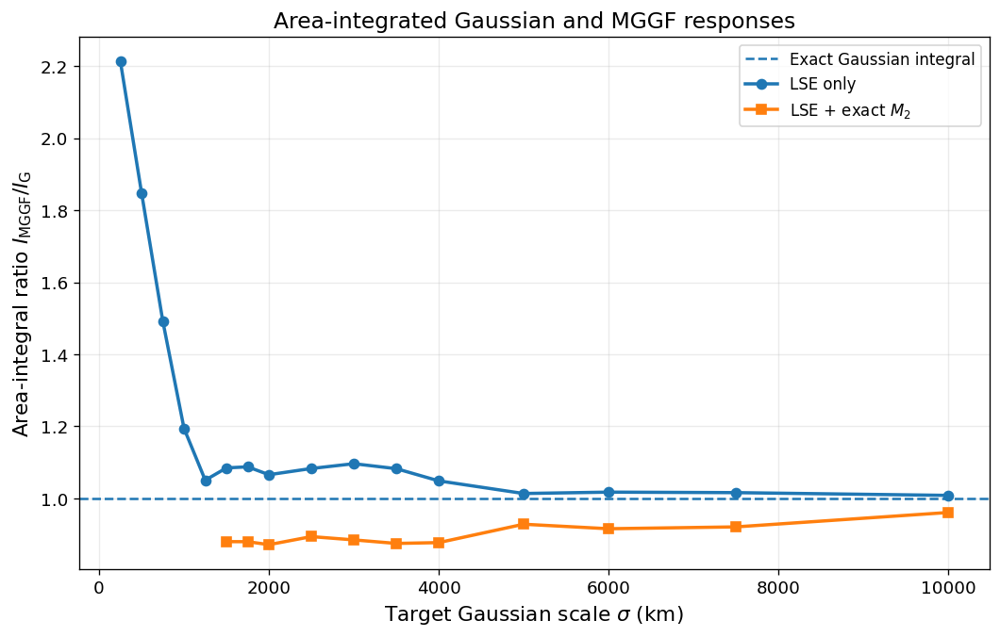

Saved:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_improved_calibration/integral_ratio_vs_scale.pdf
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_improved_calibration/integral_ratio_vs_scale.png


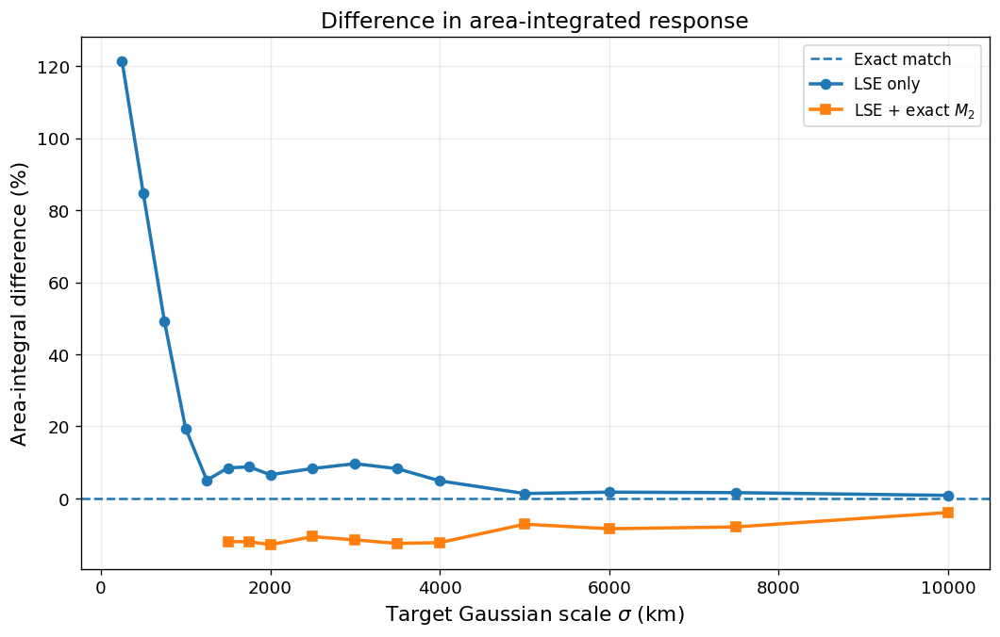


Checking Cartopy...
Cartopy already installed.

Source location:
longitude = 0.000 deg
latitude  = 0.000 deg


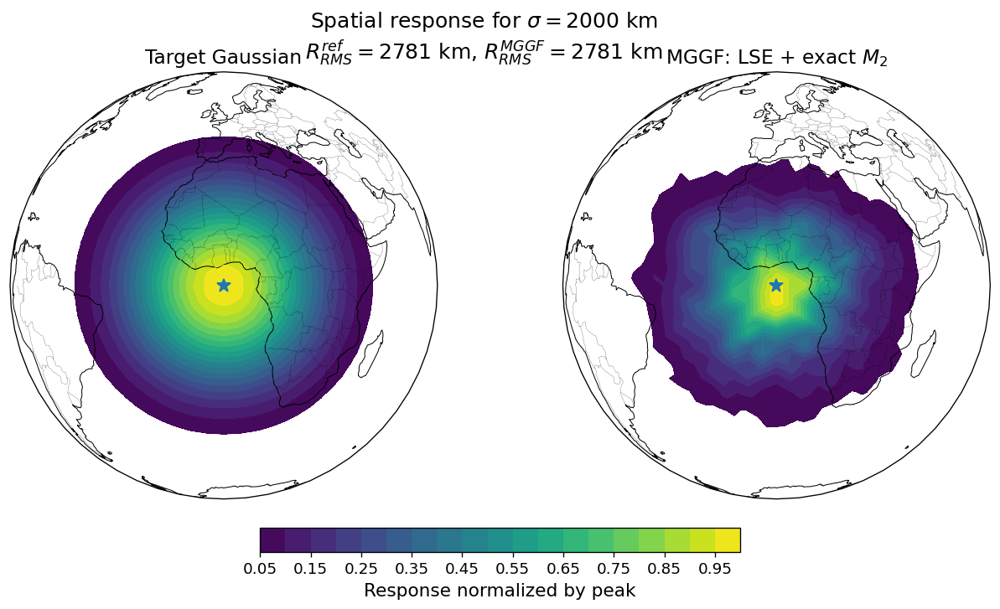

Saved: orthographic_gaussian_mggf_sigma_02000km


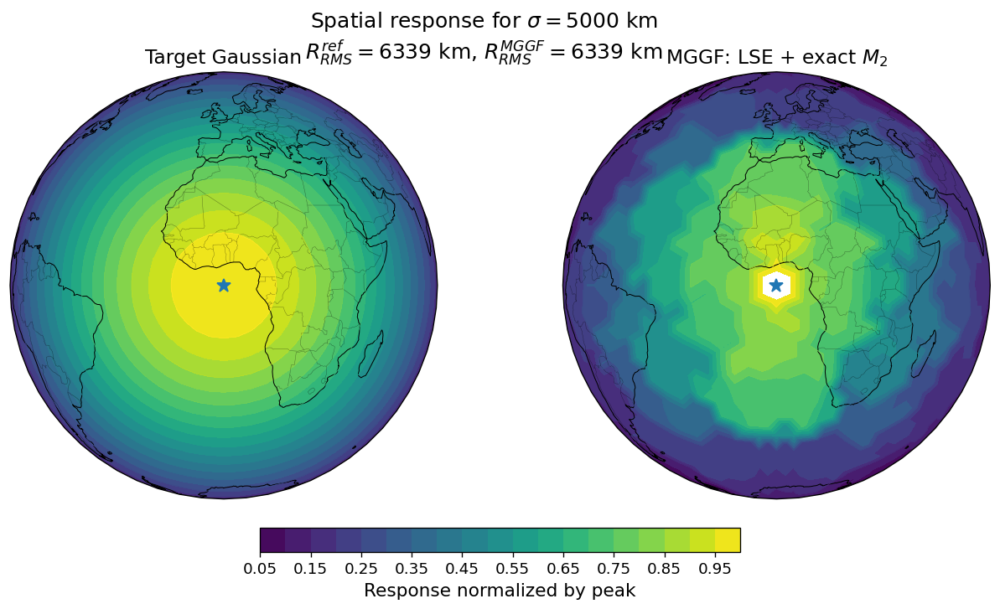

Saved: orthographic_gaussian_mggf_sigma_05000km


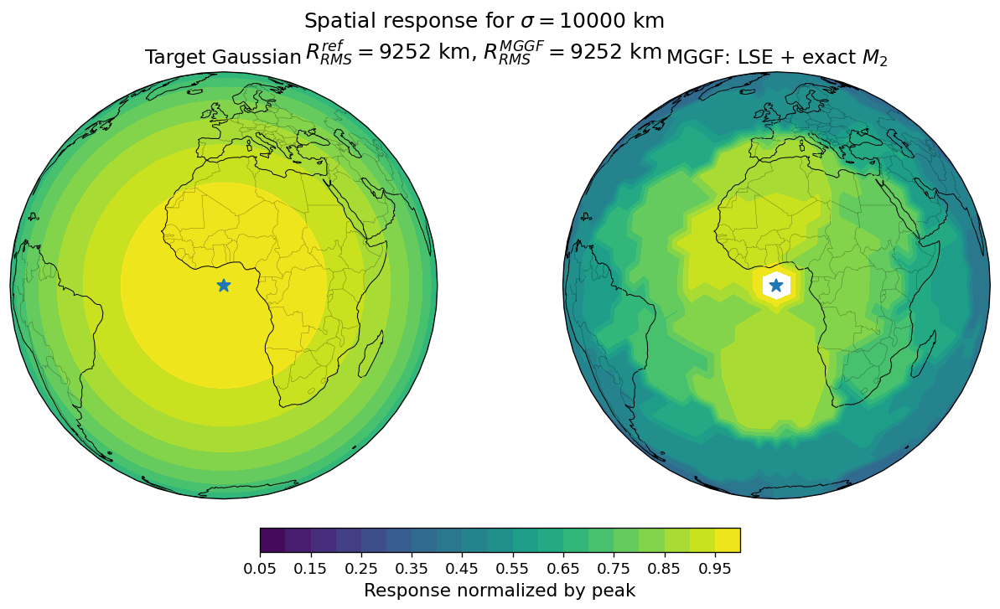

Saved: orthographic_gaussian_mggf_sigma_10000km


ADDITIONAL CALIBRATION DIAGNOSTICS COMPLETE

Added diagnostics:
  1. Gaussian/MGGF area-integral ratio
  2. Gaussian/MGGF integral percent difference
  3. Orthographic Gaussian/MGGF contour comparisons

Output directory:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_improved_calibration


In [ ]:
# ============================================================
# ADDITIONAL MGGF CALIBRATION DIAGNOSTICS
#
# Run AFTER:
#   - improved MGGF calibration script
#
# Adds:
#
#   1. Area-integral comparison:
#
#          I_MGGF / I_Gaussian
#
#      for:
#          LSE only
#          LSE + exact M2
#
#   2. Orthographic spherical contour maps:
#
#          Target Gaussian
#          LSE + exact-M2 MGGF
#
#      for selected Gaussian scales.
#
# No recalibration is performed.
# ============================================================

import os
import sys
import subprocess
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0. OUTPUT DIRECTORY
# ============================================================

if "FIG_DIR" not in globals():

    FIG_DIR = (
        "/content/drive/MyDrive/GLOBAL_SW_FV/"
        "mggf_improved_calibration"
    )

os.makedirs(
    FIG_DIR,
    exist_ok=True
)


# ============================================================
# 1. AREA-INTEGRAL DIAGNOSTICS
# ============================================================

nsigma = len(
    SIGMA_LIST_KM
)

integral_gaussian = np.zeros(
    nsigma
)

integral_lse = np.zeros(
    nsigma
)

integral_m2 = np.full(
    nsigma,
    np.nan
)

ratio_lse = np.zeros(
    nsigma
)

ratio_m2 = np.full(
    nsigma,
    np.nan
)

percent_lse = np.zeros(
    nsigma
)

percent_m2 = np.full(
    nsigma,
    np.nan
)


print("=" * 92)
print("AREA-INTEGRAL DIAGNOSTIC")
print("=" * 92)

print(
    f"{'sigma':>7s} "
    f"{'I_G':>14s} "
    f"{'I_LSE/I_G':>12s} "
    f"{'I_M2/I_G':>12s} "
    f"{'M2 diff %':>12s}"
)

print("-" * 92)


for j, sigma_km in enumerate(
    SIGMA_LIST_KM
):

    sigma_m = (
        sigma_km * 1000.0
    )

    # --------------------------------------------------------
    # Unit-peak target Gaussian
    # --------------------------------------------------------

    target = np.exp(
        -0.5
        * (
            r_m / sigma_m
        )**2
    )

    IG = float(
        area @ target
    )

    integral_gaussian[j] = (
        IG
    )


    # --------------------------------------------------------
    # LSE-only calibrated response
    # --------------------------------------------------------

    shape_A = (
        B6 @ weights_lse[j]
    )

    fitted_A = (
        amplitude_lse[j]
        * shape_A
    )

    IA = float(
        area @ fitted_A
    )

    integral_lse[j] = (
        IA
    )

    ratio_lse[j] = (
        IA / IG
    )

    percent_lse[j] = (
        100.0
        * (
            ratio_lse[j]
            - 1.0
        )
    )


    # --------------------------------------------------------
    # Exact-M2 calibrated response
    # --------------------------------------------------------

    if m2_success[j]:

        shape_B = (
            B6 @ weights_m2[j]
        )

        fitted_B = (
            amplitude_m2[j]
            * shape_B
        )

        IB = float(
            area @ fitted_B
        )

        integral_m2[j] = (
            IB
        )

        ratio_m2[j] = (
            IB / IG
        )

        percent_m2[j] = (
            100.0
            * (
                ratio_m2[j]
                - 1.0
            )
        )


    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    if m2_success[j]:

        m2_text = (
            f"{ratio_m2[j]:12.6f} "
            f"{percent_m2[j]:12.3f}"
        )

    else:

        m2_text = (
            f"{'---':>12s} "
            f"{'---':>12s}"
        )


    print(
        f"{sigma_km:7.0f} "
        f"{IG:14.6e} "
        f"{ratio_lse[j]:12.6f} "
        + m2_text
    )


# ============================================================
# 2. VERIFY THE EXPECTED IDENTITY
#
# Since the operational shape has integral one:
#
#     integral(a * shape) = a
#
# Therefore calibration amplitude should equal the
# integrated calibrated response.
# ============================================================

amp_identity_error_lse = np.max(
    np.abs(
        integral_lse
        - amplitude_lse
    )
    /
    np.maximum(
        np.abs(amplitude_lse),
        1.0
    )
)


if np.any(m2_success):

    amp_identity_error_m2 = np.nanmax(
        np.abs(
            integral_m2[m2_success]
            - amplitude_m2[m2_success]
        )
        /
        np.maximum(
            np.abs(
                amplitude_m2[m2_success]
            ),
            1.0
        )
    )

else:

    amp_identity_error_m2 = (
        np.nan
    )


print("\n")
print("=" * 72)
print("AMPLITUDE / INTEGRAL CONSISTENCY")
print("=" * 72)

print(
    "LSE maximum relative discrepancy = "
    f"{amp_identity_error_lse:.3e}"
)

print(
    "M2 maximum relative discrepancy  = "
    f"{amp_identity_error_m2:.3e}"
)


# ============================================================
# 3. PLOT INTEGRAL RATIOS
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.0, 5.8)
)


ax.axhline(
    1.0,
    linewidth=1.5,
    linestyle="--",
    label="Exact Gaussian integral"
)


ax.plot(
    SIGMA_LIST_KM,
    ratio_lse,
    marker="o",
    linewidth=2.1,
    markersize=6,
    label="LSE only"
)


valid = (
    m2_success
)


ax.plot(
    SIGMA_LIST_KM[valid],
    ratio_m2[valid],
    marker="s",
    linewidth=2.1,
    markersize=6,
    label=r"LSE + exact $M_2$"
)


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    r"Area-integral ratio $I_{\rm MGGF}/I_{\rm G}$"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()

ax.set_title(
    "Area-integrated Gaussian and MGGF responses"
)

fig.tight_layout()


pdf_file = os.path.join(
    FIG_DIR,
    "integral_ratio_vs_scale.pdf"
)

png_file = os.path.join(
    FIG_DIR,
    "integral_ratio_vs_scale.png"
)

fig.savefig(
    pdf_file,
    bbox_inches="tight"
)

fig.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(pdf_file)
print(png_file)


# ============================================================
# 4. PLOT PERCENT INTEGRAL DIFFERENCE
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.0, 5.8)
)


ax.axhline(
    0.0,
    linewidth=1.5,
    linestyle="--",
    label="Exact match"
)


ax.plot(
    SIGMA_LIST_KM,
    percent_lse,
    marker="o",
    linewidth=2.1,
    markersize=6,
    label="LSE only"
)


ax.plot(
    SIGMA_LIST_KM[valid],
    percent_m2[valid],
    marker="s",
    linewidth=2.1,
    markersize=6,
    label=r"LSE + exact $M_2$"
)


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "Area-integral difference (%)"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()

ax.set_title(
    "Difference in area-integrated response"
)

fig.tight_layout()


pdf_file = os.path.join(
    FIG_DIR,
    "integral_percent_difference_vs_scale.pdf"
)

png_file = os.path.join(
    FIG_DIR,
    "integral_percent_difference_vs_scale.png"
)

fig.savefig(
    pdf_file,
    bbox_inches="tight"
)

fig.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. CARTOPY INSTALLATION
# ============================================================

print("\nChecking Cartopy...")

try:

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    print("Cartopy already installed.")

except ImportError:

    print(
        "Cartopy not installed. Installing..."
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "cartopy"
        ]
    )

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    print(
        "Cartopy installed successfully."
    )


# ============================================================
# 6. GET G0 LONGITUDE / LATITUDE
# ============================================================

if (
    "lon0" in globals()
    and
    "lat0" in globals()
):

    plot_lon = np.asarray(
        lon0,
        dtype=float
    ).copy()

    plot_lat = np.asarray(
        lat0,
        dtype=float
    ).copy()


elif "xyz0" in globals():

    xyz_plot = np.asarray(
        xyz0,
        dtype=float
    )

    plot_lon = np.degrees(
        np.arctan2(
            xyz_plot[:, 1],
            xyz_plot[:, 0]
        )
    )

    plot_lat = np.degrees(
        np.arcsin(
            np.clip(
                xyz_plot[:, 2],
                -1.0,
                1.0
            )
        )
    )


else:

    raise RuntimeError(
        "Need lon0/lat0 or xyz0 "
        "for spherical plotting."
    )


# Convert radians to degrees if necessary.

if (
    np.nanmax(
        np.abs(plot_lon)
    )
    <= 2.0 * np.pi + 0.1
):

    plot_lon = np.degrees(
        plot_lon
    )


if (
    np.nanmax(
        np.abs(plot_lat)
    )
    <= np.pi / 2.0 + 0.1
):

    plot_lat = np.degrees(
        plot_lat
    )


# ============================================================
# 7. SOURCE LOCATION
# ============================================================

source_lon = float(
    plot_lon[SOURCE_G0]
)

source_lat = float(
    plot_lat[SOURCE_G0]
)


print("\nSource location:")

print(
    f"longitude = {source_lon:.3f} deg"
)

print(
    f"latitude  = {source_lat:.3f} deg"
)


# ============================================================
# 8. ORTHOGRAPHIC CONTOUR SETTINGS
#
# Use scales for which exact-M2 calibration exists.
# ============================================================

ORTHO_SIGMA_KM = [
    2000.,
    5000.,
    10000.
]


# Common normalized contour levels.
#
# Both Gaussian and MGGF are displayed relative to their
# own maximum so the figure emphasizes spatial shape.
#
# This normalization is FOR VISUALIZATION ONLY.

contour_levels = np.linspace(
    0.05,
    1.00,
    20
)


# ============================================================
# 9. ORTHOGRAPHIC TARGET GAUSSIAN + MGGF
#
# Each sigma gets one figure with two orthographic panels:
#
#     left  = target Gaussian
#     right = exact-M2 MGGF
#
# Projection is centered on the source point.
# ============================================================

for requested_sigma in ORTHO_SIGMA_KM:

    j = int(
        np.argmin(
            np.abs(
                SIGMA_LIST_KM
                - requested_sigma
            )
        )
    )

    sigma_km = float(
        SIGMA_LIST_KM[j]
    )


    if not m2_success[j]:

        print(
            f"Skipping sigma={sigma_km:.0f} km: "
            "exact-M2 solution unavailable."
        )

        continue


    # --------------------------------------------------------
    # Target Gaussian
    # --------------------------------------------------------

    sigma_m = (
        sigma_km * 1000.0
    )

    target = np.exp(
        -0.5
        * (
            r_m / sigma_m
        )**2
    )


    # --------------------------------------------------------
    # Exact-M2 MGGF
    # --------------------------------------------------------

    shape_m2 = (
        B6 @ weights_m2[j]
    )

    fitted_m2 = (
        amplitude_m2[j]
        * shape_m2
    )


    # --------------------------------------------------------
    # Normalize to peak = 1 for visual comparison only
    # --------------------------------------------------------

    target_display = (
        target
        / np.max(target)
    )

    mggf_display = (
        fitted_m2
        / np.max(fitted_m2)
    )


    # --------------------------------------------------------
    # Orthographic projection centered on source
    # --------------------------------------------------------

    projection = ccrs.Orthographic(
        central_longitude=source_lon,
        central_latitude=source_lat
    )


    fig = plt.figure(
        figsize=(13.0, 6.2)
    )


    # --------------------------------------------------------
    # LEFT PANEL — Gaussian
    # --------------------------------------------------------

    ax1 = fig.add_subplot(
        1,
        2,
        1,
        projection=projection
    )

    ax1.set_global()

    ax1.coastlines(
        linewidth=0.6
    )

    ax1.add_feature(
        cfeature.BORDERS,
        linewidth=0.25,
        alpha=0.5
    )


    cf1 = ax1.tricontourf(
        plot_lon,
        plot_lat,
        target_display,
        levels=contour_levels,
        transform=ccrs.PlateCarree()
    )


    ax1.tricontour(
        plot_lon,
        plot_lat,
        target_display,
        levels=contour_levels[::2],
        linewidths=0.45,
        transform=ccrs.PlateCarree()
    )


    ax1.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )


    ax1.set_title(
        "Target Gaussian"
    )


    # --------------------------------------------------------
    # RIGHT PANEL — constrained MGGF
    # --------------------------------------------------------

    ax2 = fig.add_subplot(
        1,
        2,
        2,
        projection=projection
    )

    ax2.set_global()

    ax2.coastlines(
        linewidth=0.6
    )

    ax2.add_feature(
        cfeature.BORDERS,
        linewidth=0.25,
        alpha=0.5
    )


    cf2 = ax2.tricontourf(
        plot_lon,
        plot_lat,
        mggf_display,
        levels=contour_levels,
        transform=ccrs.PlateCarree()
    )


    ax2.tricontour(
        plot_lon,
        plot_lat,
        mggf_display,
        levels=contour_levels[::2],
        linewidths=0.45,
        transform=ccrs.PlateCarree()
    )


    ax2.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )


    ax2.set_title(
        r"MGGF: LSE + exact $M_2$"
    )


    # --------------------------------------------------------
    # Shared colorbar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        cf2,
        ax=[ax1, ax2],
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        shrink=0.80
    )

    cbar.set_label(
        "Response normalized by peak"
    )


    fig.suptitle(
        rf"Spatial response for "
        rf"$\sigma={sigma_km:.0f}$ km"
        + "\n"
        + rf"$R_{{RMS}}^{{ref}}="
        + rf"{ref_RMS_km[j]:.0f}$ km, "
        + rf"$R_{{RMS}}^{{MGGF}}="
        + rf"{RMS_m2_km[j]:.0f}$ km",
        fontsize=15
    )


    basename = (
        "orthographic_gaussian_mggf_"
        + f"sigma_{int(sigma_km):05d}km"
    )


    pdf_file = os.path.join(
        FIG_DIR,
        basename + ".pdf"
    )

    png_file = os.path.join(
        FIG_DIR,
        basename + ".png"
    )


    fig.savefig(
        pdf_file,
        bbox_inches="tight"
    )

    fig.savefig(
        png_file,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    print(
        "Saved:",
        basename
    )


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 78)
print("ADDITIONAL CALIBRATION DIAGNOSTICS COMPLETE")
print("=" * 78)

print(
    "\nAdded diagnostics:"
)

print(
    "  1. Gaussian/MGGF area-integral ratio"
)

print(
    "  2. Gaussian/MGGF integral percent difference"
)

print(
    "  3. Orthographic Gaussian/MGGF contour comparisons"
)

print(
    "\nOutput directory:"
)

print(
    FIG_DIR
)

# Improved v1

Output directory:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_exact_integral_m2

Basis:
G0, G0.5, G1, G1.5, G2, G3
Number of cells: 2562
Number of generations: 6


GENERATION BASIS CHECK
G0     integral=9.999999999999998e-01  RMS= 1823.786 km
G0.5   integral=9.999999999999982e-01  RMS= 2558.172 km
G1     integral=9.999999999999998e-01  RMS= 3610.107 km
G1.5   integral=9.999999999999994e-01  RMS= 4737.235 km
G2     integral=9.999999999999993e-01  RMS= 6522.172 km
G3     integral=9.999999999999990e-01  RMS=10056.917 km

Maximum generation integral error = 1.776e-15

Representable RMS range:
  1823.786 -- 10056.917 km


LSE + EXACT INTEGRAL + EXACT M2 CALIBRATION
sigma=    250 km  RMSref=   345.8 km  NOT REPRESENTABLE
sigma=    500 km  RMSref=   706.3 km  NOT REPRESENTABLE
sigma=    750 km  RMSref=  1058.2 km  NOT REPRESENTABLE
sigma=   1000 km  RMSref=  1407.8 km  NOT REPRESENTABLE
sigma=   1250 km  RMSref=  1755.3 km  NOT REPRESENTABLE
sigma=   1500 km  RMSref=  2100.5  RMSfit=

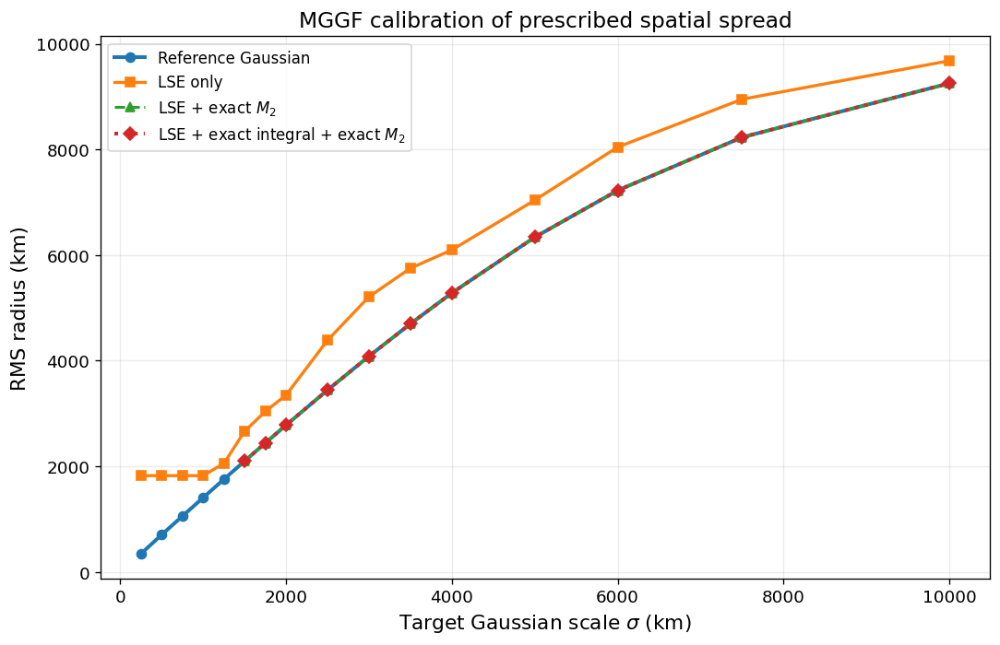

Saved: 02_L2_error_comparison


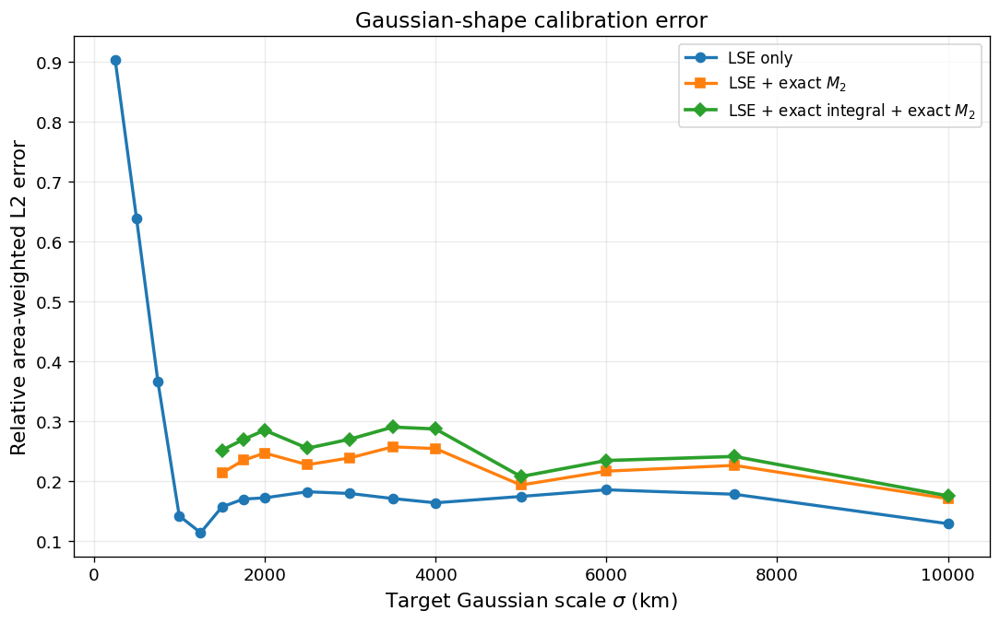

Saved: 03_integral_ratio


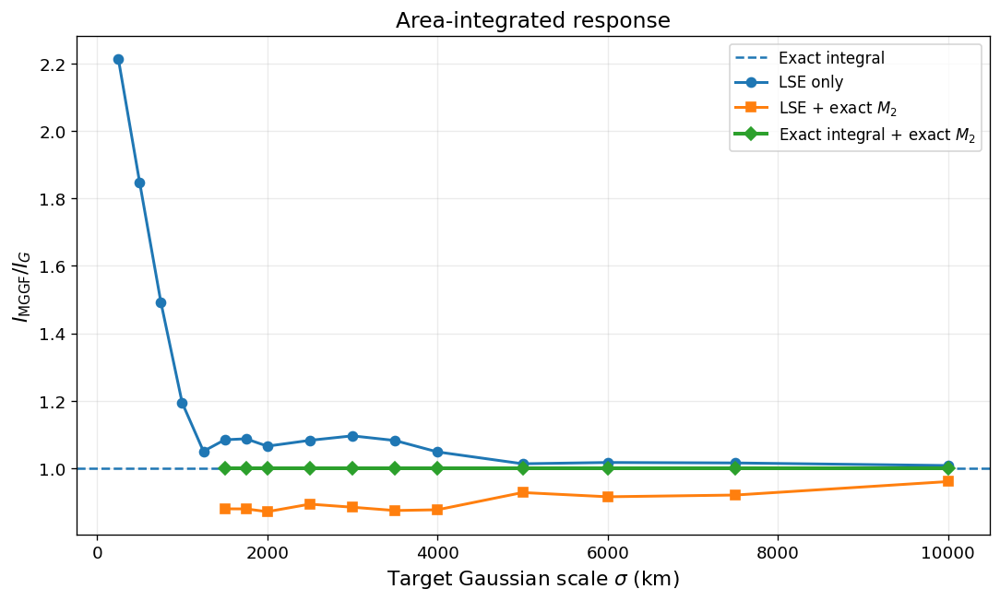

Saved: 04_generation_weights


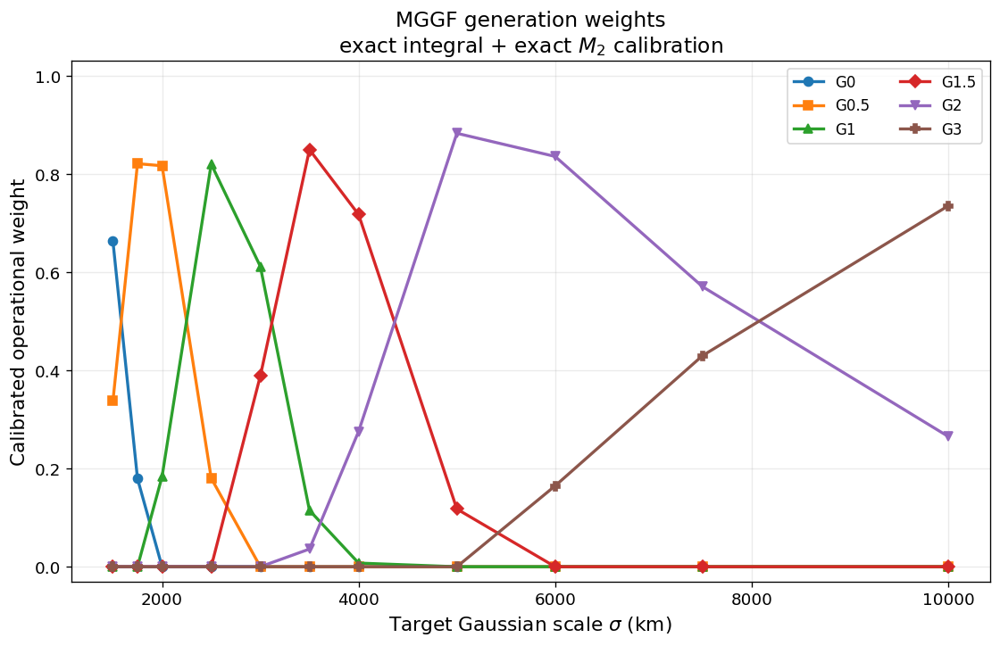

Saved: 05_radial_spread_sigma_01500km


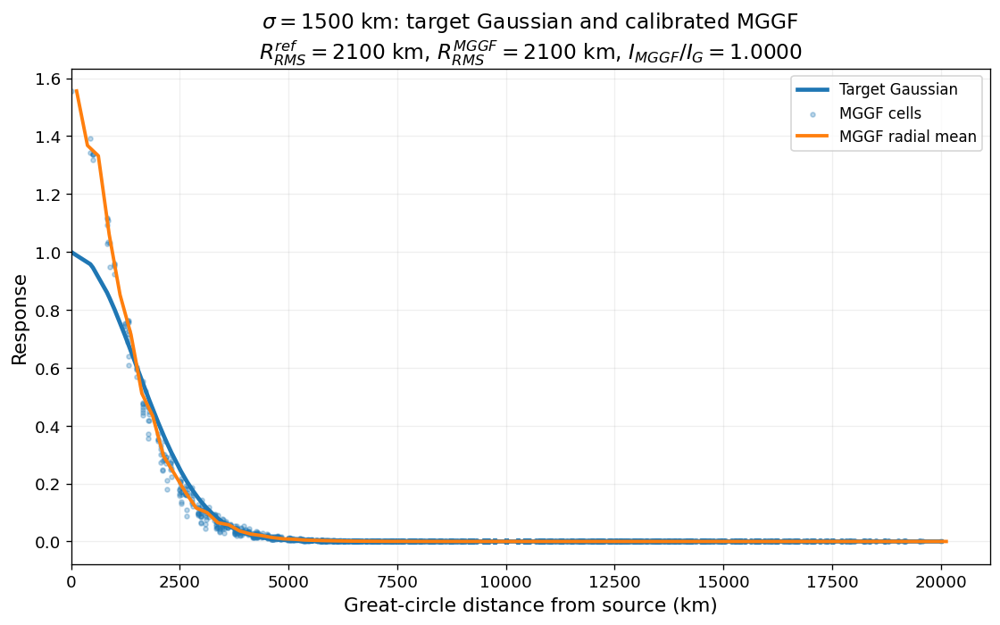

Saved: 05_radial_spread_sigma_02000km


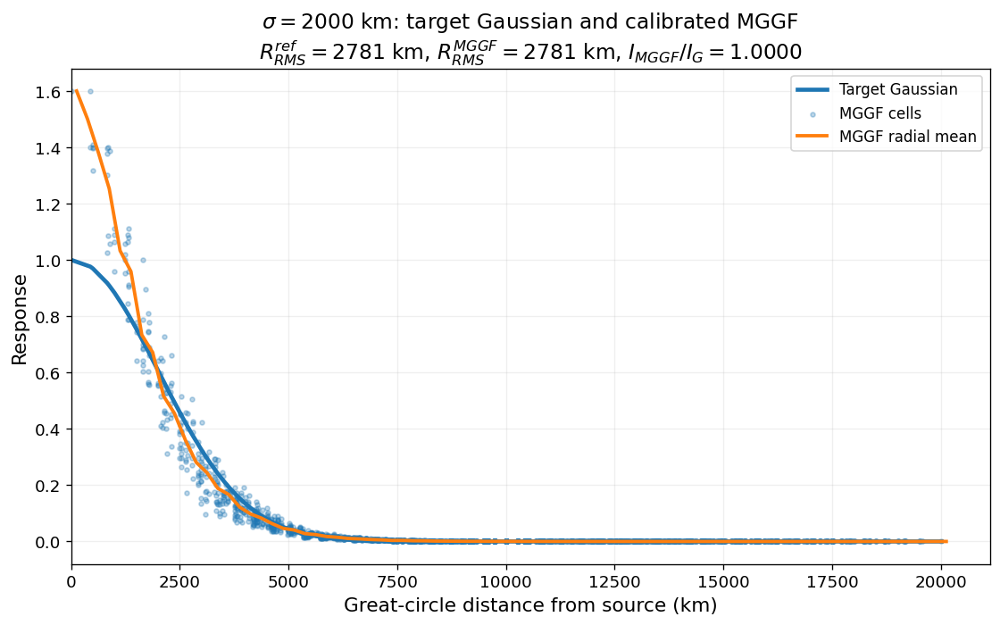

Saved: 05_radial_spread_sigma_03000km


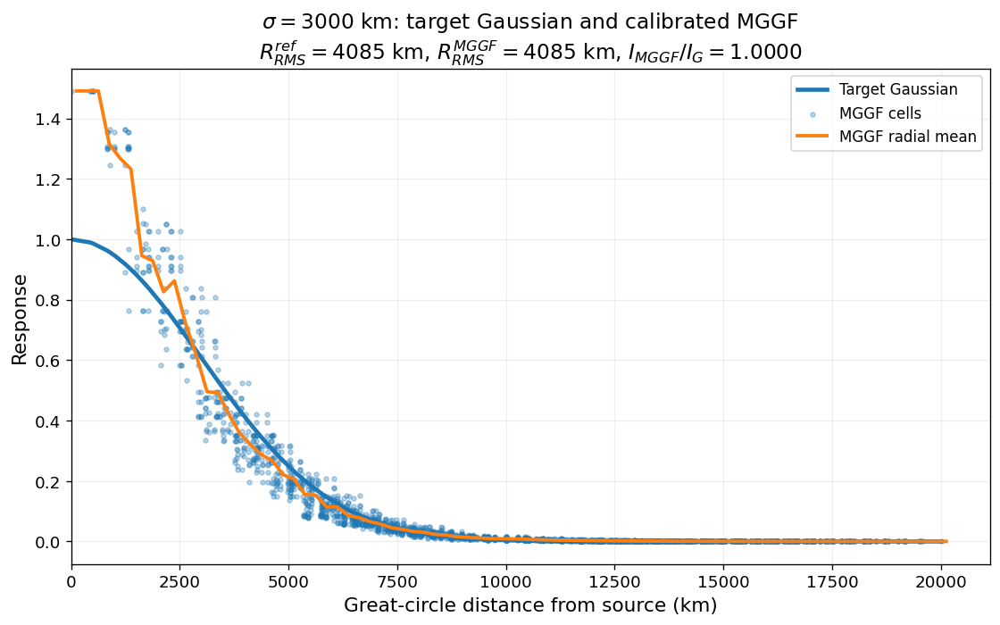

Saved: 05_radial_spread_sigma_05000km


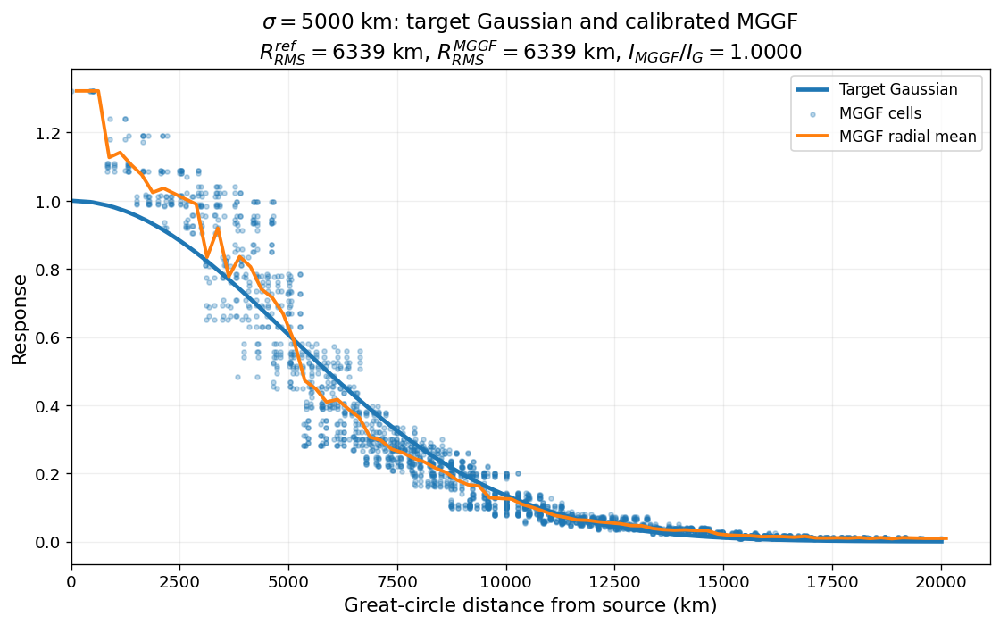

Saved: 05_radial_spread_sigma_07500km


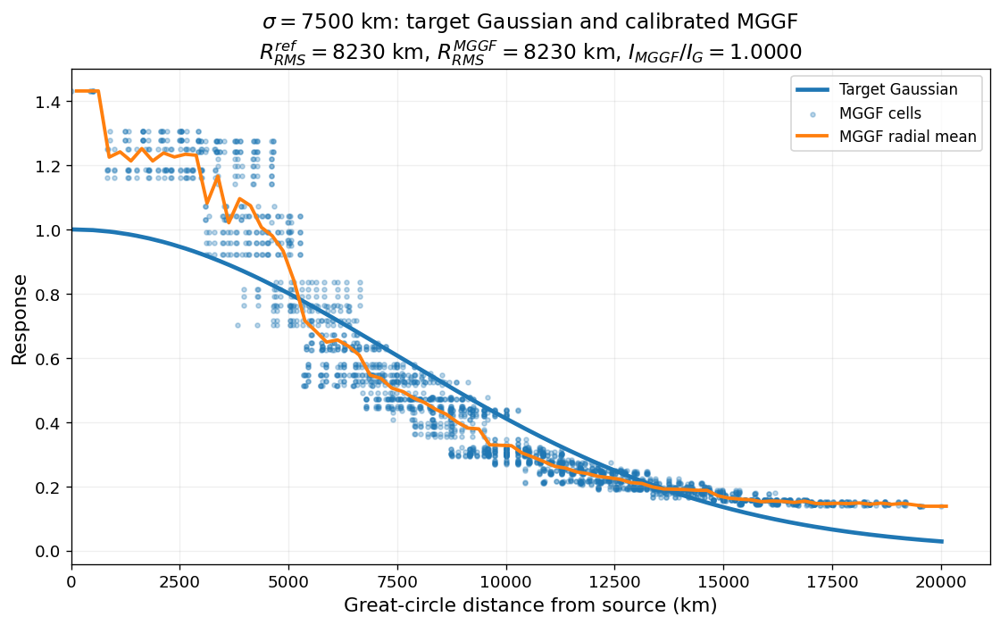

Saved: 05_radial_spread_sigma_10000km


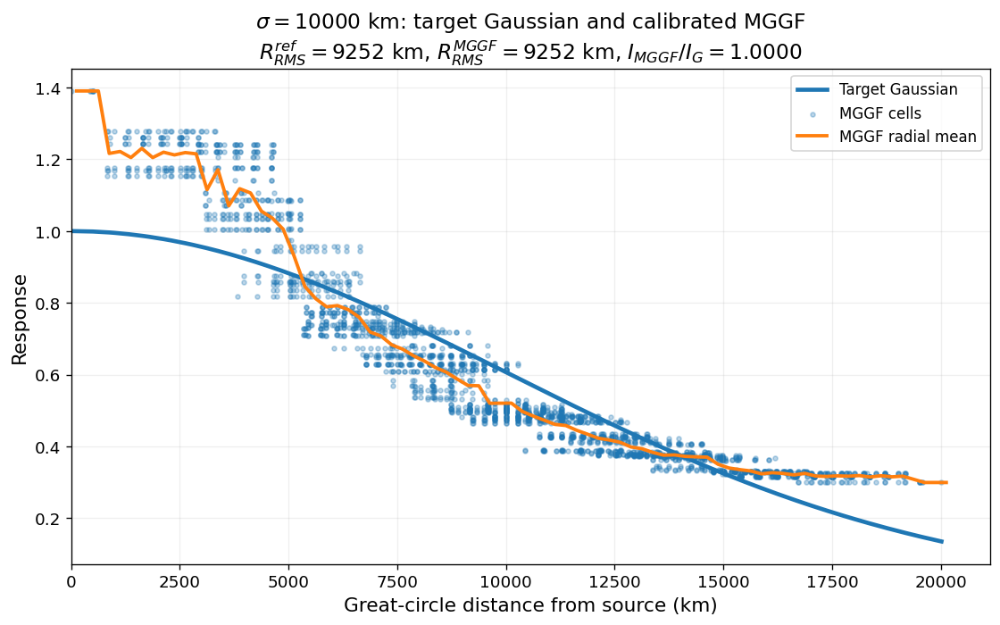


Checking Cartopy...
Cartopy already installed.
Source longitude = 0.000 deg
Source latitude  = 0.000 deg
Saved: 06_orthographic_sigma_02000km


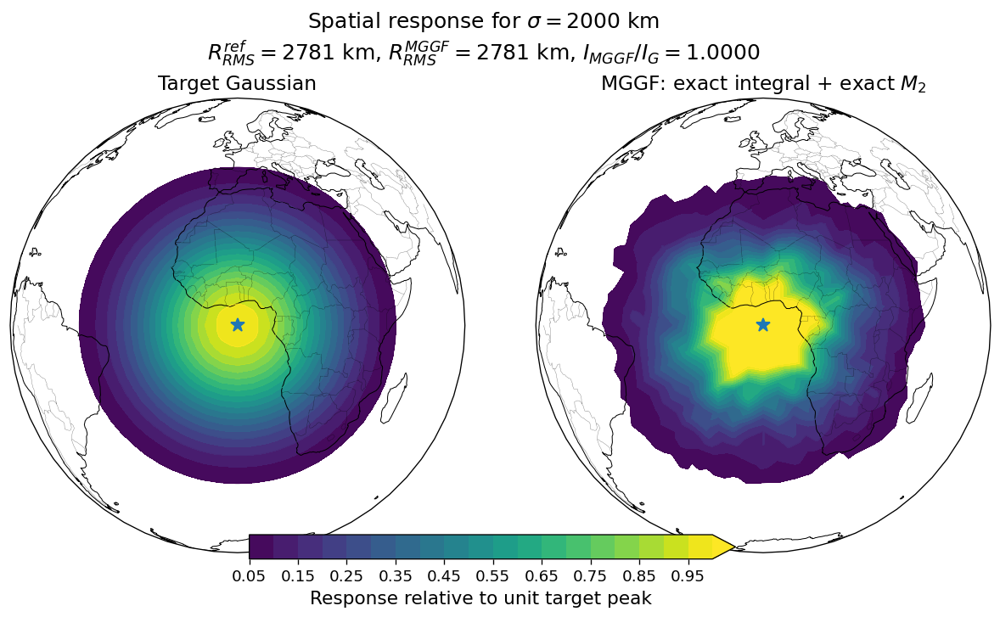

Saved: 06_orthographic_sigma_05000km


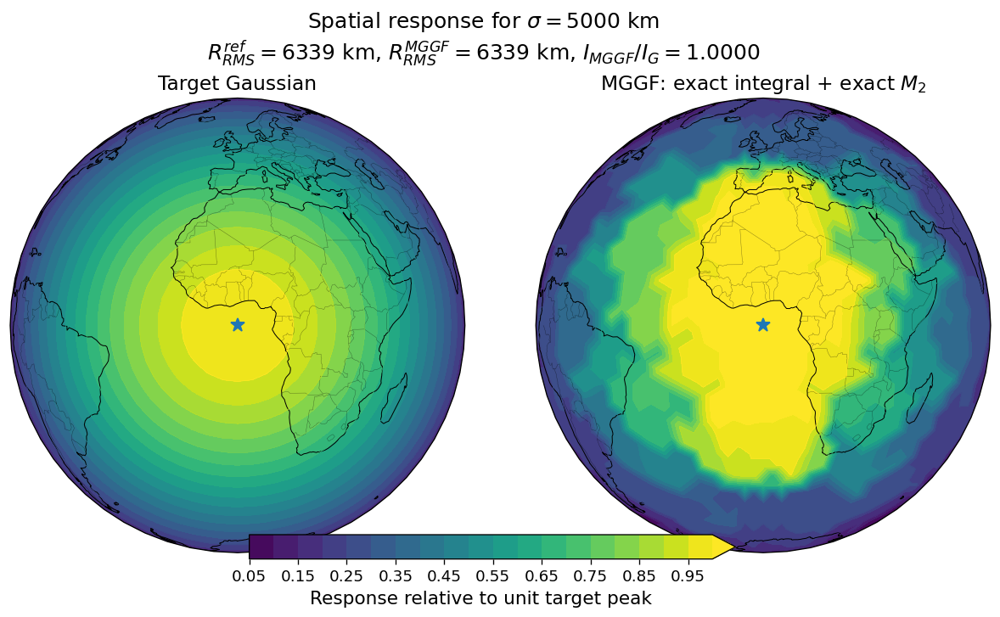

Saved: 06_orthographic_sigma_10000km


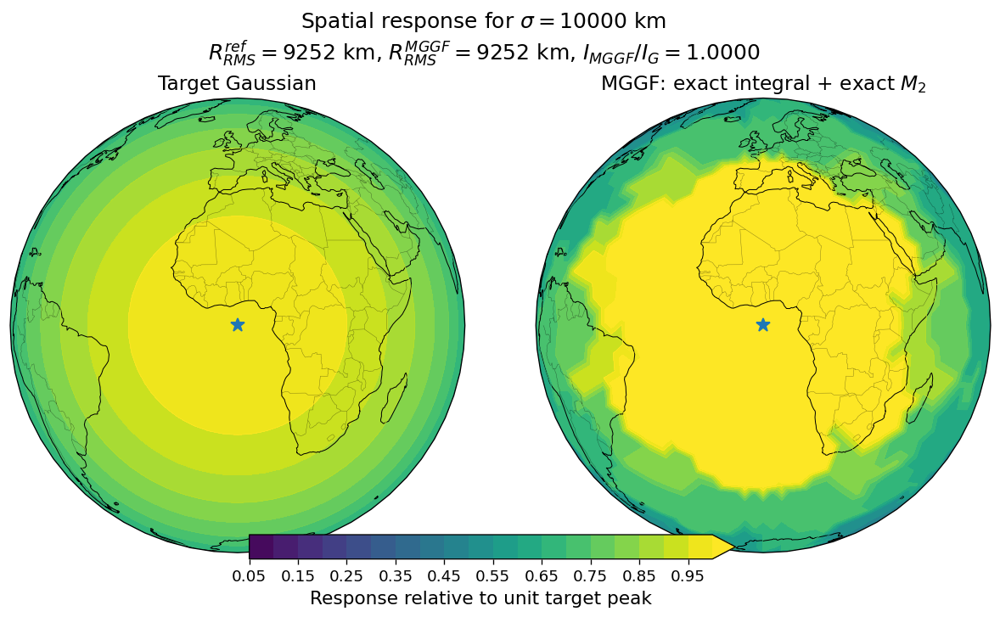



EXACT-INTEGRAL + EXACT-M2 CALIBRATION COMPLETE

This calibration enforces:
  1. nonnegative generation weights
  2. sum(weights) = 1
  3. exact Gaussian area integral during calibration
  4. exact Gaussian second radial moment / RMS radius
  5. minimum remaining area-weighted L2 shape error

Operationally retained:
  sigma --> generation weights

NOT retained operationally:
  Gaussian calibration amplitude/integral

Figures include:
  RMS spread comparison
  L2 error comparison
  integral-ratio comparison
  operational generation weights
  radial filter-spread plots
  orthographic Gaussian/MGGF contour plots

Results:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_calibration_exact_integral_m2


In [ ]:
# ============================================================
# MGGF OFFLINE CALIBRATION:
# EXACT INTEGRAL + EXACT M2 + LEAST-SQUARE SHAPE FIT
#
# IMPORTANT:
#   This cell does NOT rebuild grids, hierarchy, operators,
#   or generation responses.
#
# Required existing variables:
#   B6
#   area0 (or area)
#   distance_m (or r_m)
#   SOURCE_G0
#   SIGMA_LIST_KM
#   labels6
#   M2_generation
#
# Previous calibration arrays are used for comparison if present:
#   error_lse, RMS_lse_km
#   error_m2, RMS_m2_km
#   m2_success
#
# NEW calibration:
#
#   target G_sigma has peak = 1
#
#   I_G = sum_i A_i G_i
#
#   F(w) = sum_k w_k b_k
#
#   Since integral(F)=1 when sum(w)=1,
#
#       F_cal = I_G F
#
#   has EXACTLY the same area integral as the target Gaussian.
#
#   Determine w by minimizing:
#
#       sum_i A_i [ I_G F_i(w) - G_i ]^2
#
#   subject to:
#
#       w_k >= 0
#       sum_k w_k = 1
#       sum_k w_k M2_k = M2_G
#
# Therefore:
#
#   * Gaussian integral is exact
#   * RMS radius is exact
#   * LSE chooses the best remaining spatial shape
#
# Operational use:
#   discard I_G
#   retain ONLY w_k(sigma)
#   operational response remains conservative.
# ============================================================


import os
import sys
import subprocess
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize


# ============================================================
# 0. OUTPUT DIRECTORY
# ============================================================

OUT_DIR = (
    "/content/drive/MyDrive/GLOBAL_SW_FV/"
    "mggf_calibration_exact_integral_m2"
)

os.makedirs(
    OUT_DIR,
    exist_ok=True
)

print("Output directory:")
print(OUT_DIR)


# ============================================================
# 1. RECOVER / CHECK BASIC ARRAYS
# ============================================================

if "area" not in globals():

    area = np.asarray(
        area0,
        dtype=np.float64
    )

else:

    area = np.asarray(
        area,
        dtype=np.float64
    )


if "r_m" not in globals():

    r_m = np.asarray(
        distance_m,
        dtype=np.float64
    )

else:

    r_m = np.asarray(
        r_m,
        dtype=np.float64
    )


r_km = (
    r_m / 1000.0
)


B6 = np.asarray(
    B6,
    dtype=np.float64
)


labels6 = list(
    labels6
)


SIGMA_LIST_KM = np.asarray(
    SIGMA_LIST_KM,
    dtype=np.float64
)


ng = B6.shape[1]

nsigma = len(
    SIGMA_LIST_KM
)


print("\nBasis:")
print(
    ", ".join(labels6)
)

print(
    "Number of cells:",
    B6.shape[0]
)

print(
    "Number of generations:",
    ng
)


# ============================================================
# 2. VERIFY GENERATION INTEGRALS AND MOMENTS
# ============================================================

generation_integrals = (
    area @ B6
)


# Recompute M2 carefully here so this cell is self-checking.

M2_gen = np.zeros(
    ng
)

RMS_gen_km = np.zeros(
    ng
)


for k in range(ng):

    bk = (
        B6[:, k]
    )

    mass_k = float(
        area @ bk
    )

    M2_gen[k] = (
        float(
            area
            @ (
                r_m**2
                * bk
            )
        )
        / mass_k
    )

    RMS_gen_km[k] = (
        np.sqrt(
            M2_gen[k]
        )
        / 1000.0
    )


print("\n")
print("=" * 78)
print("GENERATION BASIS CHECK")
print("=" * 78)

for k, label in enumerate(
    labels6
):

    print(
        f"{label:5s}  "
        f"integral={generation_integrals[k]:.15e}  "
        f"RMS={RMS_gen_km[k]:9.3f} km"
    )


print(
    "\nMaximum generation integral error = "
    f"{np.max(np.abs(generation_integrals - 1.0)):.3e}"
)


M2_min = np.min(
    M2_gen
)

M2_max = np.max(
    M2_gen
)


print(
    "\nRepresentable RMS range:"
)

print(
    f"  {np.sqrt(M2_min)/1000.0:.3f}"
    f" -- "
    f"{np.sqrt(M2_max)/1000.0:.3f} km"
)


# ============================================================
# 3. UTILITY FUNCTIONS
# ============================================================

def radial_diagnostics(field):

    f = np.asarray(
        field,
        dtype=np.float64
    )

    mass = float(
        area @ f
    )

    if mass <= 0.0:

        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan
        )

    M1 = (
        float(
            area
            @ (
                r_m * f
            )
        )
        / mass
    )

    M2 = (
        float(
            area
            @ (
                r_m**2 * f
            )
        )
        / mass
    )

    rms_km = (
        np.sqrt(
            max(M2, 0.0)
        )
        / 1000.0
    )

    return (
        mass,
        M1,
        M2,
        rms_km
    )


def relative_l2(
    field,
    reference
):

    residual = (
        field
        - reference
    )

    numerator = float(
        area
        @ (
            residual**2
        )
    )

    denominator = float(
        area
        @ (
            reference**2
        )
    )

    return np.sqrt(
        numerator
        / denominator
    )


# ============================================================
# 4. STORAGE FOR NEW CALIBRATION
# ============================================================

weights_IM2 = np.full(
    (nsigma, ng),
    np.nan
)

error_IM2 = np.full(
    nsigma,
    np.nan
)

RMS_IM2_km = np.full(
    nsigma,
    np.nan
)

integral_IM2 = np.full(
    nsigma,
    np.nan
)

integral_gaussian_IM2 = np.full(
    nsigma,
    np.nan
)

integral_ratio_IM2 = np.full(
    nsigma,
    np.nan
)

source_ratio_IM2 = np.full(
    nsigma,
    np.nan
)

M1_IM2_km = np.full(
    nsigma,
    np.nan
)

M1_ref_km = np.full(
    nsigma,
    np.nan
)

RMS_ref_IM2_km = np.full(
    nsigma,
    np.nan
)

IM2_feasible = np.zeros(
    nsigma,
    dtype=bool
)

IM2_success = np.zeros(
    nsigma,
    dtype=bool
)


# ============================================================
# 5. NEW CALIBRATION SWEEP
# ============================================================

print("\n")
print("=" * 112)
print("LSE + EXACT INTEGRAL + EXACT M2 CALIBRATION")
print("=" * 112)


for j, sigma_km in enumerate(
    SIGMA_LIST_KM
):

    sigma_m = (
        sigma_km
        * 1000.0
    )


    # --------------------------------------------------------
    # Unit-peak target Gaussian
    # --------------------------------------------------------

    target = np.exp(
        -0.5
        * (
            r_m
            / sigma_m
        )**2
    )


    (
        IG,
        M1_target,
        M2_target,
        RMS_target
    ) = radial_diagnostics(
        target
    )


    integral_gaussian_IM2[j] = (
        IG
    )

    M1_ref_km[j] = (
        M1_target / 1000.0
    )

    RMS_ref_IM2_km[j] = (
        RMS_target
    )


    # --------------------------------------------------------
    # Feasibility of exact M2
    # --------------------------------------------------------

    tol_M2 = (
        1.0e-10
        * max(
            abs(M2_min),
            abs(M2_max),
            1.0
        )
    )


    feasible = (
        M2_target
        >= M2_min - tol_M2
        and
        M2_target
        <= M2_max + tol_M2
    )


    IM2_feasible[j] = (
        feasible
    )


    if not feasible:

        print(
            f"sigma={sigma_km:7.0f} km  "
            f"RMSref={RMS_target:8.1f} km  "
            "NOT REPRESENTABLE"
        )

        continue


    # ========================================================
    # Construct guaranteed-feasible initial weights.
    #
    # Two neighboring basis M2 values bracket target M2.
    # ========================================================

    order = np.argsort(
        M2_gen
    )

    m2_sorted = (
        M2_gen[order]
    )

    w0 = np.zeros(
        ng,
        dtype=np.float64
    )


    if abs(
        M2_target
        - m2_sorted[0]
    ) <= tol_M2:

        w0[
            order[0]
        ] = 1.0


    elif abs(
        M2_target
        - m2_sorted[-1]
    ) <= tol_M2:

        w0[
            order[-1]
        ] = 1.0


    else:

        found = False

        for q in range(
            ng - 1
        ):

            lo = (
                m2_sorted[q]
            )

            hi = (
                m2_sorted[q + 1]
            )


            if (
                M2_target >= lo
                and
                M2_target <= hi
            ):

                alpha = (
                    M2_target
                    - lo
                ) / (
                    hi
                    - lo
                )


                w0[
                    order[q]
                ] = (
                    1.0 - alpha
                )

                w0[
                    order[q + 1]
                ] = (
                    alpha
                )

                found = True

                break


        if not found:

            raise RuntimeError(
                "Could not construct feasible "
                f"initial weights for sigma={sigma_km}"
            )


    # ========================================================
    # Objective
    #
    # IMPORTANT:
    #
    # Calibration amplitude is NOT optimized.
    #
    # It is fixed to IG, because:
    #
    #     integral(B6 @ w) = 1
    #
    # therefore:
    #
    #     integral(IG * B6 @ w) = IG
    #
    # exactly.
    # ========================================================

    target_norm2 = float(
        area
        @ (
            target**2
        )
    )


    def objective(w):

        shape = (
            B6 @ w
        )

        calibrated = (
            IG * shape
        )

        residual = (
            calibrated
            - target
        )

        return float(
            (
                area
                @ (
                    residual**2
                )
            )
            / target_norm2
        )


    # ========================================================
    # Constraints
    # ========================================================

    constraints = [

        # Sum of operational weights = 1
        {
            "type": "eq",
            "fun": lambda w:
                np.sum(w)
                - 1.0
        },

        # Exact second radial moment
        {
            "type": "eq",
            "fun": lambda w,
            M2_target=M2_target:
                (
                    np.dot(
                        M2_gen,
                        w
                    )
                    - M2_target
                )
                / M2_target
        }
    ]


    bounds = [
        (0.0, 1.0)
        for _ in range(ng)
    ]


    # ========================================================
    # Optimize
    # ========================================================

    result = minimize(
        objective,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "ftol": 1.0e-13,
            "maxiter": 3000,
            "disp": False
        }
    )


    if not result.success:

        print(
            f"sigma={sigma_km:7.0f} km  "
            "OPTIMIZATION FAILED: "
            + result.message
        )

        continue


    # ========================================================
    # Final weights
    # ========================================================

    w = np.asarray(
        result.x,
        dtype=np.float64
    )


    # Clean tiny roundoff.
    w[
        np.abs(w)
        < 1.0e-12
    ] = 0.0


    # Renormalize only at roundoff level.
    w = (
        w
        / np.sum(w)
    )


    operational_shape = (
        B6 @ w
    )


    # Calibration comparison response.
    #
    # EXACT Gaussian integral by construction.
    calibrated = (
        IG
        * operational_shape
    )


    (
        IF,
        M1_fit,
        M2_fit,
        RMS_fit
    ) = radial_diagnostics(
        calibrated
    )


    err = relative_l2(
        calibrated,
        target
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    weights_IM2[
        j, :
    ] = w

    error_IM2[j] = (
        err
    )

    RMS_IM2_km[j] = (
        RMS_fit
    )

    integral_IM2[j] = (
        IF
    )

    integral_ratio_IM2[j] = (
        IF / IG
    )

    source_ratio_IM2[j] = (
        calibrated[SOURCE_G0]
        / target[SOURCE_G0]
    )

    M1_IM2_km[j] = (
        M1_fit / 1000.0
    )

    IM2_success[j] = (
        True
    )


    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(
        f"sigma={sigma_km:7.0f} km  "
        f"RMSref={RMS_target:8.1f}  "
        f"RMSfit={RMS_fit:8.1f}  "
        f"Iratio={IF/IG:10.7f}  "
        f"L2={err:8.5f}"
    )


# ============================================================
# 6. DETAILED OPERATIONAL WEIGHT TABLE
# ============================================================

print("\n")
print("=" * 132)
print("EXACT-INTEGRAL + EXACT-M2 OPERATIONAL WEIGHTS")
print("=" * 132)


header = (
    f"{'sigma':>7s} "
    f"{'RMSref':>9s} "
    f"{'G0':>9s} "
    f"{'G0.5':>9s} "
    f"{'G1':>9s} "
    f"{'G1.5':>9s} "
    f"{'G2':>9s} "
    f"{'G3':>9s} "
    f"{'L2err':>9s} "
    f"{'Iratio':>9s}"
)

print(header)

print(
    "-" * len(header)
)


for j, sigma_km in enumerate(
    SIGMA_LIST_KM
):

    if not IM2_success[j]:

        print(
            f"{sigma_km:7.0f} "
            f"{RMS_ref_IM2_km[j]:9.1f} "
            "   NOT REPRESENTABLE"
        )

        continue


    w = (
        weights_IM2[j]
    )


    print(
        f"{sigma_km:7.0f} "
        f"{RMS_ref_IM2_km[j]:9.1f} "
        f"{w[0]:9.5f} "
        f"{w[1]:9.5f} "
        f"{w[2]:9.5f} "
        f"{w[3]:9.5f} "
        f"{w[4]:9.5f} "
        f"{w[5]:9.5f} "
        f"{error_IM2[j]:9.5f} "
        f"{integral_ratio_IM2[j]:9.6f}"
    )


# ============================================================
# 7. STRICT CONSTRAINT VERIFICATION
# ============================================================

valid = (
    IM2_success
)


max_rms_error = np.nanmax(
    np.abs(
        RMS_IM2_km[valid]
        - RMS_ref_IM2_km[valid]
    )
)


max_integral_ratio_error = np.nanmax(
    np.abs(
        integral_ratio_IM2[valid]
        - 1.0
    )
)


max_weight_sum_error = 0.0

max_operational_integral_error = 0.0


for j in np.where(valid)[0]:

    w = (
        weights_IM2[j]
    )

    shape = (
        B6 @ w
    )

    max_weight_sum_error = max(
        max_weight_sum_error,
        abs(
            np.sum(w)
            - 1.0
        )
    )

    max_operational_integral_error = max(
        max_operational_integral_error,
        abs(
            float(
                area @ shape
            )
            - 1.0
        )
    )


print("\n")
print("=" * 78)
print("CONSTRAINT VERIFICATION")
print("=" * 78)

print(
    "Maximum RMS mismatch             = "
    f"{max_rms_error:.8e} km"
)

print(
    "Maximum |I_MGGF/I_G - 1|         = "
    f"{max_integral_ratio_error:.8e}"
)

print(
    "Maximum |sum(weights)-1|         = "
    f"{max_weight_sum_error:.8e}"
)

print(
    "Maximum operational integral err = "
    f"{max_operational_integral_error:.8e}"
)


# ============================================================
# 8. SAVE OFFLINE CALIBRATION TABLE
# ============================================================

npz_file = os.path.join(
    OUT_DIR,
    "mggf_weights_exact_integral_exact_m2.npz"
)


np.savez(
    npz_file,

    sigma_km=SIGMA_LIST_KM,

    labels=np.array(
        labels6
    ),

    weights=weights_IM2,

    success=IM2_success,

    reference_RMS_km=RMS_ref_IM2_km,

    fitted_RMS_km=RMS_IM2_km,

    reference_integral=integral_gaussian_IM2,

    fitted_integral=integral_IM2,

    integral_ratio=integral_ratio_IM2,

    relative_L2=error_IM2,

    source_ratio=source_ratio_IM2,

    reference_M1_km=M1_ref_km,

    fitted_M1_km=M1_IM2_km,

    generation_RMS_km=RMS_gen_km,

    Gamma=GAMMA,

    p=P_ORDER
)


print(
    "\nSaved operational calibration table:"
)

print(
    npz_file
)


# ============================================================
# 9. FIGURE UTILITY
# ============================================================

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300
})


def save_figure(
    fig,
    basename
):

    pdf = os.path.join(
        OUT_DIR,
        basename + ".pdf"
    )

    png = os.path.join(
        OUT_DIR,
        basename + ".png"
    )

    fig.savefig(
        pdf,
        bbox_inches="tight"
    )

    fig.savefig(
        png,
        dpi=300,
        bbox_inches="tight"
    )

    print(
        "Saved:",
        basename
    )


# ============================================================
# 10. FIGURE:
# PRESCRIBED RMS SPREAD
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.2, 6.0)
)


ax.plot(
    SIGMA_LIST_KM,
    RMS_ref_IM2_km,
    marker="o",
    linewidth=2.4,
    label="Reference Gaussian"
)


if (
    "RMS_lse_km"
    in globals()
):

    ax.plot(
        SIGMA_LIST_KM,
        RMS_lse_km,
        marker="s",
        linewidth=2.0,
        label="LSE only"
    )


if (
    "RMS_m2_km"
    in globals()
    and
    "m2_success"
    in globals()
):

    old_valid = (
        m2_success
    )

    ax.plot(
        SIGMA_LIST_KM[old_valid],
        RMS_m2_km[old_valid],
        marker="^",
        linestyle="--",
        linewidth=1.8,
        label=r"LSE + exact $M_2$"
    )


ax.plot(
    SIGMA_LIST_KM[valid],
    RMS_IM2_km[valid],
    marker="D",
    linestyle=":",
    linewidth=2.4,
    label=r"LSE + exact integral + exact $M_2$"
)


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "RMS radius (km)"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()

ax.set_title(
    "MGGF calibration of prescribed spatial spread"
)

fig.tight_layout()

save_figure(
    fig,
    "01_rms_spread_comparison"
)

plt.show()


# ============================================================
# 11. FIGURE:
# L2 ERROR COMPARISON
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.2, 5.8)
)


if (
    "error_lse"
    in globals()
):

    ax.plot(
        SIGMA_LIST_KM,
        error_lse,
        marker="o",
        linewidth=2.0,
        label="LSE only"
    )


if (
    "error_m2"
    in globals()
    and
    "m2_success"
    in globals()
):

    ax.plot(
        SIGMA_LIST_KM[m2_success],
        error_m2[m2_success],
        marker="s",
        linewidth=2.0,
        label=r"LSE + exact $M_2$"
    )


ax.plot(
    SIGMA_LIST_KM[valid],
    error_IM2[valid],
    marker="D",
    linewidth=2.2,
    label=r"LSE + exact integral + exact $M_2$"
)


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "Relative area-weighted L2 error"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()

ax.set_title(
    "Gaussian-shape calibration error"
)

fig.tight_layout()

save_figure(
    fig,
    "02_L2_error_comparison"
)

plt.show()


# ============================================================
# 12. FIGURE:
# INTEGRAL RATIO
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.2, 5.6)
)


ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Exact integral"
)


# Previous curves if available.

if (
    "ratio_lse"
    in globals()
):

    ax.plot(
        SIGMA_LIST_KM,
        ratio_lse,
        marker="o",
        linewidth=1.8,
        label="LSE only"
    )


if (
    "ratio_m2"
    in globals()
    and
    "m2_success"
    in globals()
):

    ax.plot(
        SIGMA_LIST_KM[m2_success],
        ratio_m2[m2_success],
        marker="s",
        linewidth=1.8,
        label=r"LSE + exact $M_2$"
    )


ax.plot(
    SIGMA_LIST_KM[valid],
    integral_ratio_IM2[valid],
    marker="D",
    linewidth=2.4,
    label=r"Exact integral + exact $M_2$"
)


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    r"$I_{\rm MGGF}/I_G$"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()

ax.set_title(
    "Area-integrated response"
)

fig.tight_layout()

save_figure(
    fig,
    "03_integral_ratio"
)

plt.show()


# ============================================================
# 13. FIGURE:
# NEW OPERATIONAL WEIGHTS
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.5, 6.2)
)


markers = [
    "o",
    "s",
    "^",
    "D",
    "v",
    "P"
]


for k, label in enumerate(
    labels6
):

    ax.plot(
        SIGMA_LIST_KM[valid],
        weights_IM2[valid, k],
        marker=markers[k],
        linewidth=2.0,
        markersize=6,
        label=label
    )


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "Calibrated operational weight"
)

ax.set_ylim(
    -0.03,
    1.03
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    ncol=2
)

ax.set_title(
    "MGGF generation weights"
    "\n"
    r"exact integral + exact $M_2$ calibration"
)

fig.tight_layout()

save_figure(
    fig,
    "04_generation_weights"
)

plt.show()


# ============================================================
# 14. RADIAL FILTER-SPREAD PLOTS
#
# These are the plots requested from the earlier script.
#
# IMPORTANT:
#   NO independent peak normalization here.
#
# Gaussian and MGGF already have the SAME integral.
# ============================================================

RADIAL_SIGMA_KM = [
    1500.,
    2000.,
    3000.,
    5000.,
    7500.,
    10000.
]


sort_idx = np.argsort(
    r_km
)

r_sorted = (
    r_km[sort_idx]
)


for requested_sigma in RADIAL_SIGMA_KM:

    j = int(
        np.argmin(
            np.abs(
                SIGMA_LIST_KM
                - requested_sigma
            )
        )
    )


    if not IM2_success[j]:

        print(
            f"Skipping radial plot at "
            f"sigma={SIGMA_LIST_KM[j]:.0f} km"
        )

        continue


    sigma_km = (
        SIGMA_LIST_KM[j]
    )

    sigma_m = (
        sigma_km
        * 1000.0
    )


    target = np.exp(
        -0.5
        * (
            r_m
            / sigma_m
        )**2
    )


    shape = (
        B6
        @ weights_IM2[j]
    )


    # Exact-integral calibration response.
    calibrated = (
        integral_gaussian_IM2[j]
        * shape
    )


    fig, ax = plt.subplots(
        figsize=(9.5, 6.0)
    )


    # Gaussian target.
    ax.plot(
        r_sorted,
        target[sort_idx],
        linewidth=2.8,
        label="Target Gaussian"
    )


    # Individual cell values of MGGF.
    ax.scatter(
        r_sorted,
        calibrated[sort_idx],
        s=9,
        alpha=0.30,
        label="MGGF cells"
    )


    # --------------------------------------------------------
    # Radial-bin mean of MGGF
    #
    # This makes the average spread visible without hiding
    # cell-to-cell anisotropy.
    # --------------------------------------------------------

    BIN_WIDTH_KM = 250.0

    bins = np.arange(
        0.0,
        np.max(r_km)
        + BIN_WIDTH_KM,
        BIN_WIDTH_KM
    )

    bin_center = (
        0.5
        * (
            bins[:-1]
            + bins[1:]
        )
    )

    radial_mean = np.full(
        len(bin_center),
        np.nan
    )

    radial_std = np.full(
        len(bin_center),
        np.nan
    )


    for ib in range(
        len(bin_center)
    ):

        mask = (
            (r_km >= bins[ib])
            &
            (r_km < bins[ib + 1])
        )


        if np.any(mask):

            # Area-weighted radial-bin mean.
            aa = (
                area[mask]
            )

            ff = (
                calibrated[mask]
            )

            mean_value = (
                np.sum(
                    aa * ff
                )
                / np.sum(aa)
            )

            radial_mean[ib] = (
                mean_value
            )

            radial_std[ib] = np.sqrt(
                np.sum(
                    aa
                    * (
                        ff
                        - mean_value
                    )**2
                )
                / np.sum(aa)
            )


    good = np.isfinite(
        radial_mean
    )


    ax.plot(
        bin_center[good],
        radial_mean[good],
        linewidth=2.3,
        label="MGGF radial mean"
    )


    ax.set_xlabel(
        "Great-circle distance from source (km)"
    )

    ax.set_ylabel(
        "Response"
    )

    ax.set_xlim(
        left=0.0
    )

    ax.grid(
        True,
        alpha=0.20
    )

    ax.legend()

    ax.set_title(
        rf"$\sigma={sigma_km:.0f}$ km: "
        "target Gaussian and calibrated MGGF"
        + "\n"
        + rf"$R_{{RMS}}^{{ref}}="
        + rf"{RMS_ref_IM2_km[j]:.0f}$ km, "
        + rf"$R_{{RMS}}^{{MGGF}}="
        + rf"{RMS_IM2_km[j]:.0f}$ km, "
        + rf"$I_{{MGGF}}/I_G="
        + rf"{integral_ratio_IM2[j]:.4f}$"
    )


    fig.tight_layout()


    save_figure(
        fig,
        "05_radial_spread_"
        + f"sigma_{int(sigma_km):05d}km"
    )

    plt.show()


# ============================================================
# 15. CARTOPY
# ============================================================

print("\nChecking Cartopy...")


try:

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    print(
        "Cartopy already installed."
    )


except ImportError:

    print(
        "Installing Cartopy..."
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "cartopy"
        ]
    )

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    print(
        "Cartopy installed."
    )


# ============================================================
# 16. LONGITUDE / LATITUDE
# ============================================================

if (
    "lon0" in globals()
    and
    "lat0" in globals()
):

    plot_lon = np.asarray(
        lon0,
        dtype=float
    ).copy()

    plot_lat = np.asarray(
        lat0,
        dtype=float
    ).copy()


elif (
    "xyz0" in globals()
):

    xyz_plot = np.asarray(
        xyz0,
        dtype=float
    )


    plot_lon = np.degrees(
        np.arctan2(
            xyz_plot[:, 1],
            xyz_plot[:, 0]
        )
    )


    plot_lat = np.degrees(
        np.arcsin(
            np.clip(
                xyz_plot[:, 2],
                -1.0,
                1.0
            )
        )
    )


else:

    raise RuntimeError(
        "Need lon0/lat0 or xyz0 "
        "for orthographic plots."
    )


# Convert radians if needed.

if (
    np.nanmax(
        np.abs(plot_lon)
    )
    <= 2.0 * np.pi + 0.1
):

    plot_lon = np.degrees(
        plot_lon
    )


if (
    np.nanmax(
        np.abs(plot_lat)
    )
    <= np.pi / 2.0 + 0.1
):

    plot_lat = np.degrees(
        plot_lat
    )


source_lon = float(
    plot_lon[SOURCE_G0]
)

source_lat = float(
    plot_lat[SOURCE_G0]
)


print(
    f"Source longitude = {source_lon:.3f} deg"
)

print(
    f"Source latitude  = {source_lat:.3f} deg"
)


# ============================================================
# 17. ORTHOGRAPHIC CONTOUR COMPARISONS
#
# IMPORTANT:
#
# Unlike our previous maps, these fields are NOT normalized
# independently before the comparison.
#
# They already have equal area integrals.
#
# To use common dimensionless contour levels, divide BOTH
# fields by the TARGET Gaussian peak (=1).
#
# Since target peak is already 1, this changes nothing.
# ============================================================

ORTHO_SIGMA_KM = [
    2000.,
    5000.,
    10000.
]


# Levels relative to the unit target peak.
contour_levels = np.linspace(
    0.05,
    1.00,
    20
)


for requested_sigma in ORTHO_SIGMA_KM:

    j = int(
        np.argmin(
            np.abs(
                SIGMA_LIST_KM
                - requested_sigma
            )
        )
    )


    if not IM2_success[j]:

        continue


    sigma_km = (
        SIGMA_LIST_KM[j]
    )

    sigma_m = (
        sigma_km
        * 1000.0
    )


    # --------------------------------------------------------
    # Target
    # --------------------------------------------------------

    target = np.exp(
        -0.5
        * (
            r_m
            / sigma_m
        )**2
    )


    # --------------------------------------------------------
    # MGGF with exact target integral
    # --------------------------------------------------------

    shape = (
        B6
        @ weights_IM2[j]
    )

    calibrated = (
        integral_gaussian_IM2[j]
        * shape
    )


    # --------------------------------------------------------
    # Common projection
    # --------------------------------------------------------

    projection = (
        ccrs.Orthographic(
            central_longitude=source_lon,
            central_latitude=source_lat
        )
    )


    fig = plt.figure(
        figsize=(13.0, 6.2)
    )


    # --------------------------------------------------------
    # TARGET GAUSSIAN
    # --------------------------------------------------------

    ax1 = fig.add_subplot(
        1,
        2,
        1,
        projection=projection
    )

    ax1.set_global()

    ax1.coastlines(
        linewidth=0.6
    )

    ax1.add_feature(
        cfeature.BORDERS,
        linewidth=0.25,
        alpha=0.5
    )


    cf1 = ax1.tricontourf(
        plot_lon,
        plot_lat,
        target,
        levels=contour_levels,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax1.tricontour(
        plot_lon,
        plot_lat,
        target,
        levels=contour_levels[::2],
        linewidths=0.45,
        transform=ccrs.PlateCarree()
    )


    ax1.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )


    ax1.set_title(
        "Target Gaussian"
    )


    # --------------------------------------------------------
    # MGGF
    # --------------------------------------------------------

    ax2 = fig.add_subplot(
        1,
        2,
        2,
        projection=projection
    )

    ax2.set_global()

    ax2.coastlines(
        linewidth=0.6
    )

    ax2.add_feature(
        cfeature.BORDERS,
        linewidth=0.25,
        alpha=0.5
    )


    cf2 = ax2.tricontourf(
        plot_lon,
        plot_lat,
        calibrated,
        levels=contour_levels,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax2.tricontour(
        plot_lon,
        plot_lat,
        calibrated,
        levels=contour_levels[::2],
        linewidths=0.45,
        transform=ccrs.PlateCarree()
    )


    ax2.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )


    ax2.set_title(
        r"MGGF: exact integral + exact $M_2$"
    )


    # --------------------------------------------------------
    # Shared colorbar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        cf2,
        ax=[ax1, ax2],
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        shrink=0.80
    )


    cbar.set_label(
        "Response relative to unit target peak"
    )


    fig.suptitle(
        rf"Spatial response for "
        rf"$\sigma={sigma_km:.0f}$ km"
        + "\n"
        + rf"$R_{{RMS}}^{{ref}}="
        + rf"{RMS_ref_IM2_km[j]:.0f}$ km, "
        + rf"$R_{{RMS}}^{{MGGF}}="
        + rf"{RMS_IM2_km[j]:.0f}$ km, "
        + rf"$I_{{MGGF}}/I_G="
        + rf"{integral_ratio_IM2[j]:.4f}$",
        fontsize=15
    )


    fig.subplots_adjust(
        top=0.84,
        bottom=0.12,
        wspace=0.05
    )


    save_figure(
        fig,
        "06_orthographic_"
        + f"sigma_{int(sigma_km):05d}km"
    )

    plt.show()


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 82)
print("EXACT-INTEGRAL + EXACT-M2 CALIBRATION COMPLETE")
print("=" * 82)


print(
    "\nThis calibration enforces:"
)

print(
    "  1. nonnegative generation weights"
)

print(
    "  2. sum(weights) = 1"
)

print(
    "  3. exact Gaussian area integral during calibration"
)

print(
    "  4. exact Gaussian second radial moment / RMS radius"
)

print(
    "  5. minimum remaining area-weighted L2 shape error"
)


print(
    "\nOperationally retained:"
)

print(
    "  sigma --> generation weights"
)


print(
    "\nNOT retained operationally:"
)

print(
    "  Gaussian calibration amplitude/integral"
)


print(
    "\nFigures include:"
)

print(
    "  RMS spread comparison"
)

print(
    "  L2 error comparison"
)

print(
    "  integral-ratio comparison"
)

print(
    "  operational generation weights"
)

print(
    "  radial filter-spread plots"
)

print(
    "  orthographic Gaussian/MGGF contour plots"
)


print(
    "\nResults:"
)

print(
    OUT_DIR
)

# Self-conatined version

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cartopy already installed.

Output directory:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_selfcontained_calibration


LOADING STANDARD GRIDS
Grid sizes: 2562 642 162 42


RECONSTRUCTING ORIGINAL HARD-PARENT HIERARCHY
G1 hierarchy/geometric area RMS rel difference = 0.4719896174952472
G2 hierarchy/geometric area RMS rel difference = 0.5448560129329939


CONSTRUCTING DETERMINISTIC G2 -> G3 HARD-PARENT MAP
Inherited G3 vertices found: 42
G3 edges: 120
Maximum midpoint matching angle = 1.4901161193847656e-08
G2 -> G3 child counts:
  min  = 2
  mean = 3.857142857142857
  max  = 5
G3 hierarchy/geometric area RMS rel difference = 0.14099622900525044


CONSTRUCTING GRAPH ADJACENCIES
G0   : N=2562 edges= 7680 degree=[5,6] area=5.100996990708e+14
G0.5 : N=1281 edges= 3837 degree=[4,8] area=5.100996990708e+14
G1   : N= 642 edges= 1920 degree=[5,6] area=5.100996990708e+14
G

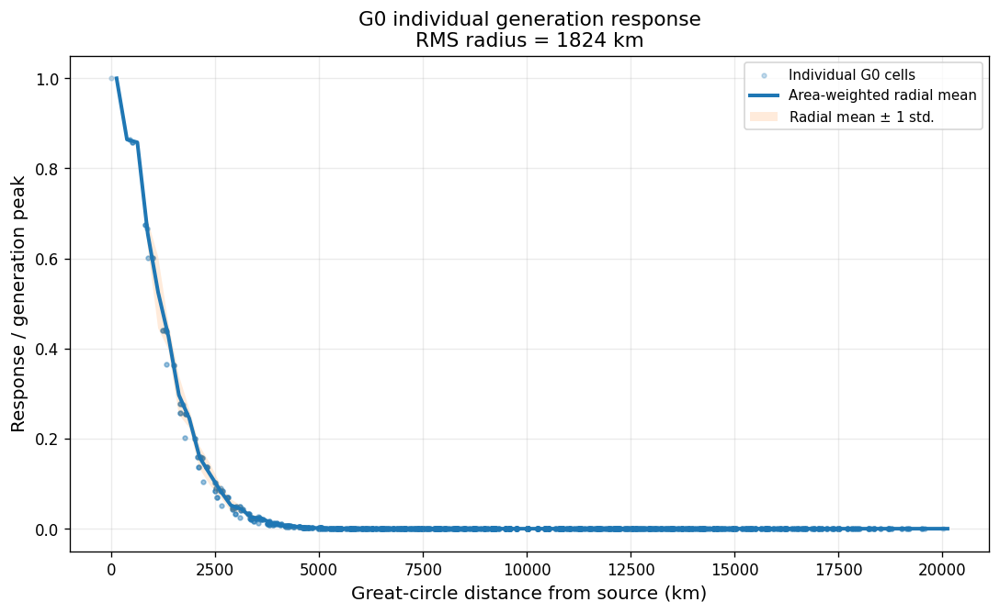

Saved: generation_radial_G0p5


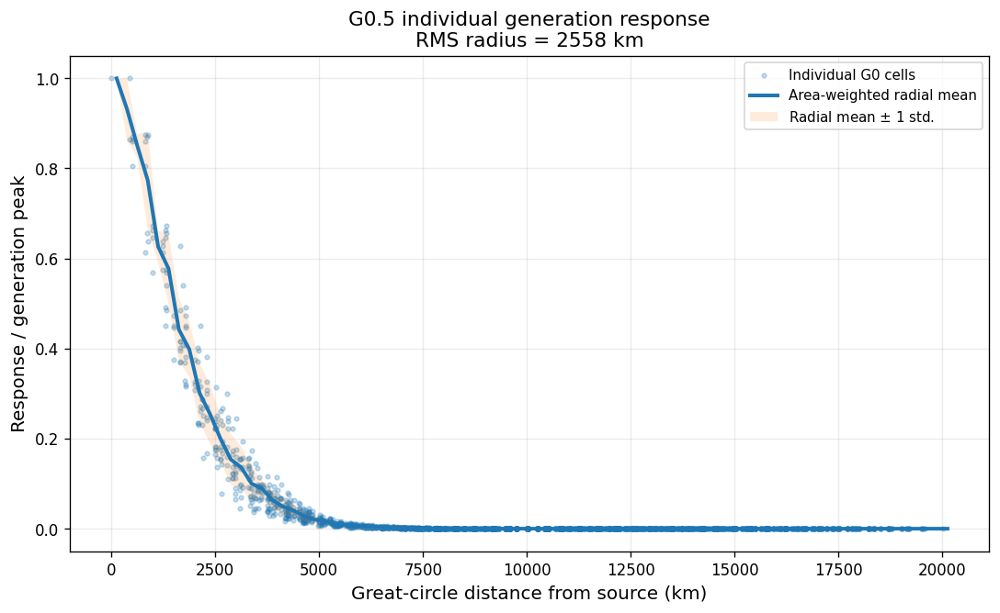

Saved: generation_radial_G1


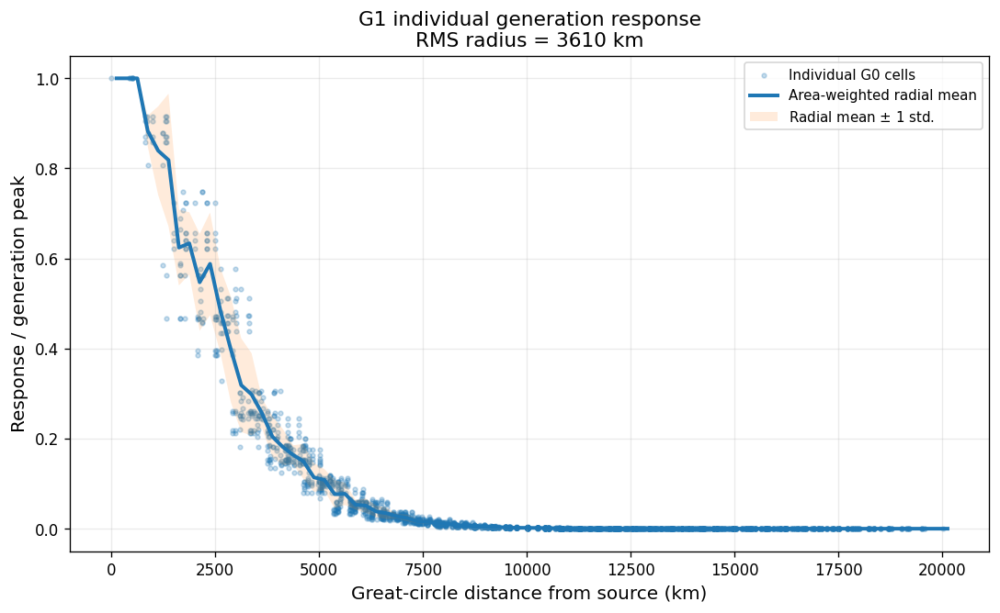

Saved: generation_radial_G1p5


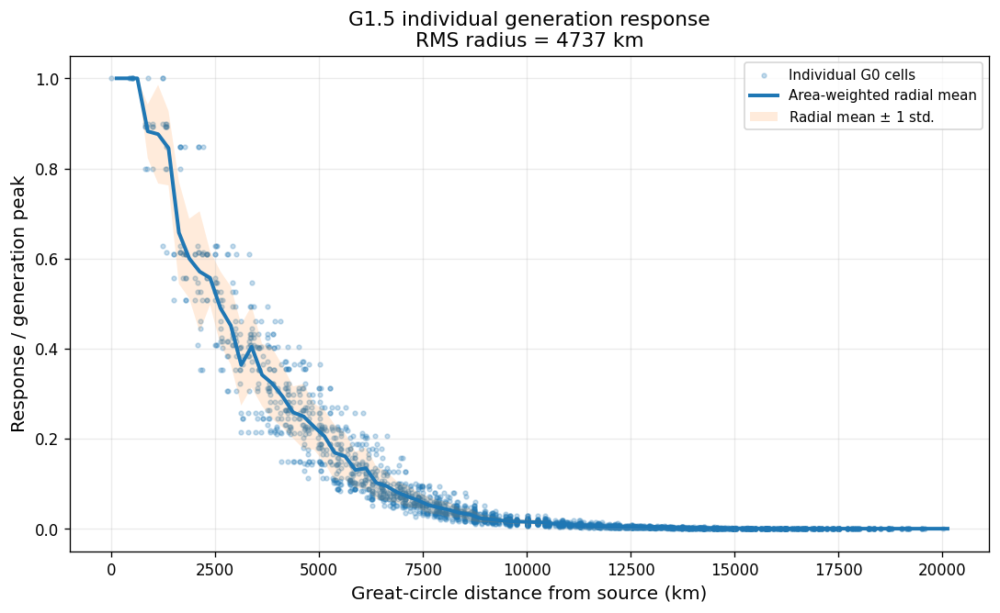

Saved: generation_radial_G2


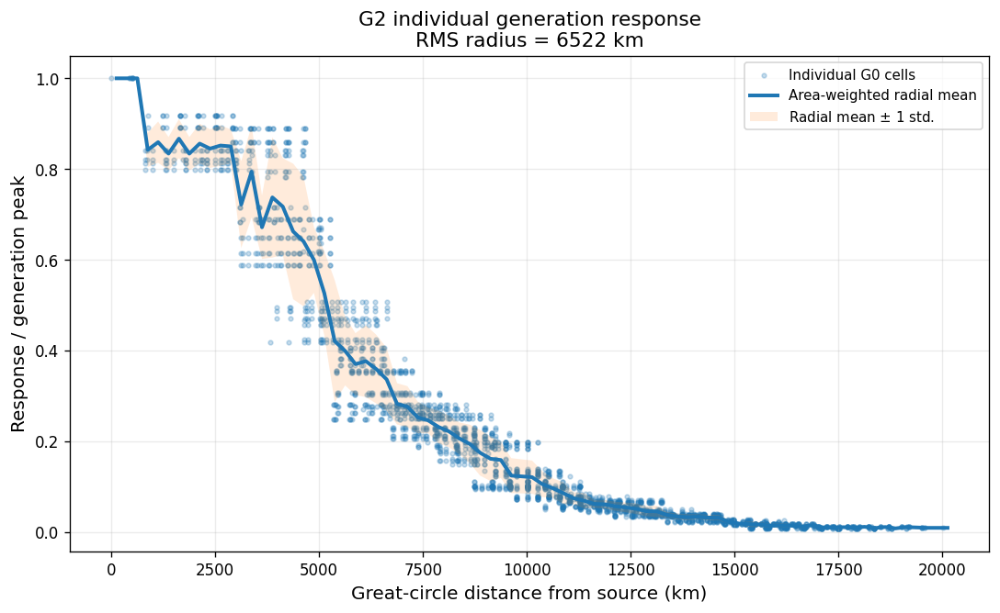

Saved: generation_radial_G3


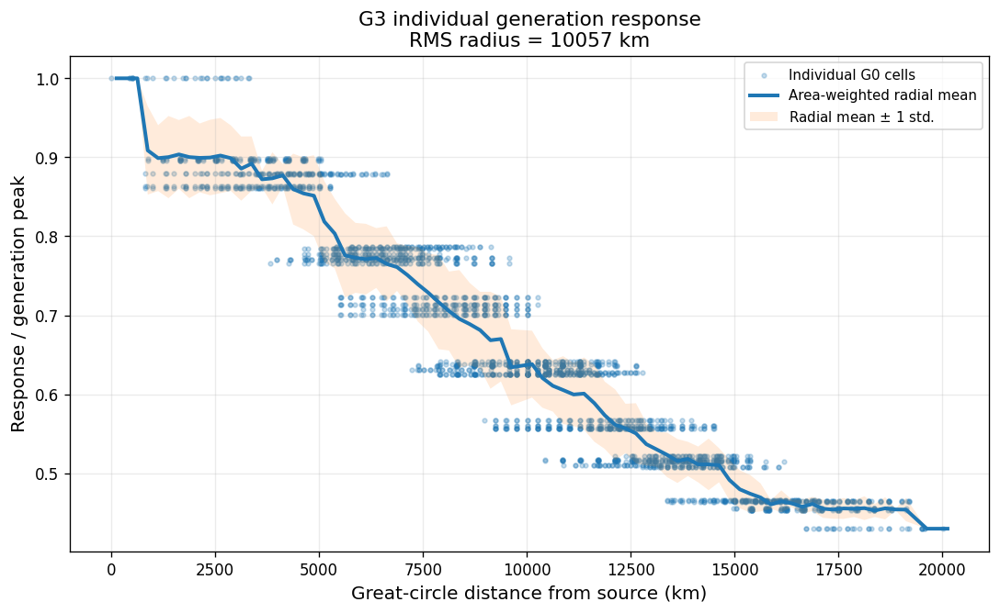



PLOTTING INDIVIDUAL GENERATION ORTHOGRAPHIC RESPONSES
Saved: generation_orthographic_G0


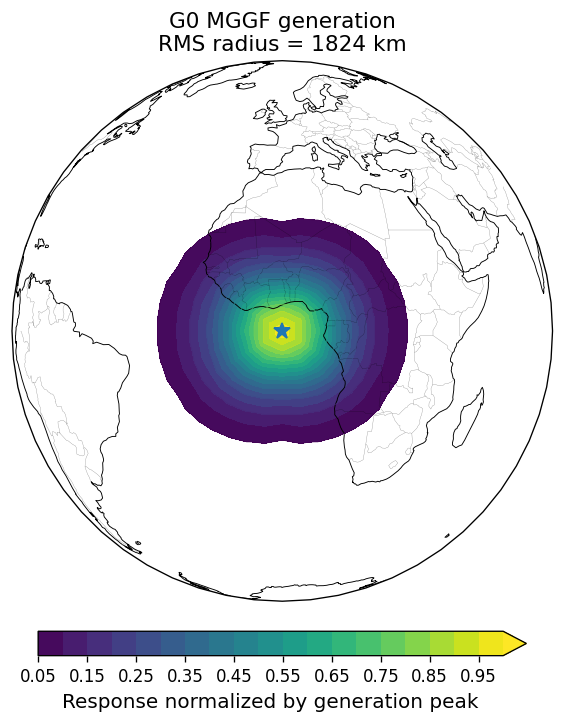

Saved: generation_orthographic_G0p5


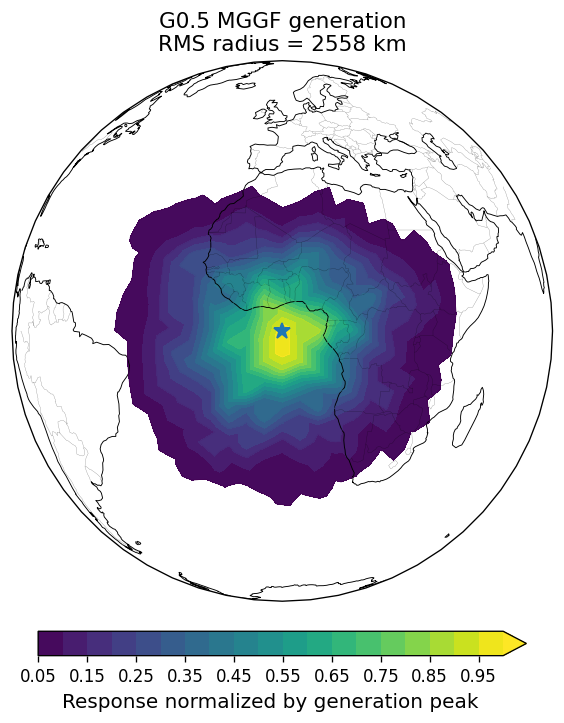

Saved: generation_orthographic_G1


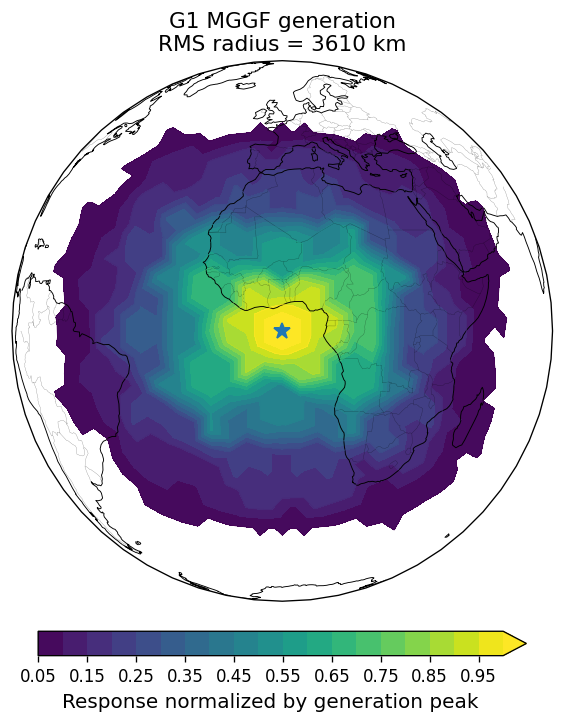

Saved: generation_orthographic_G1p5


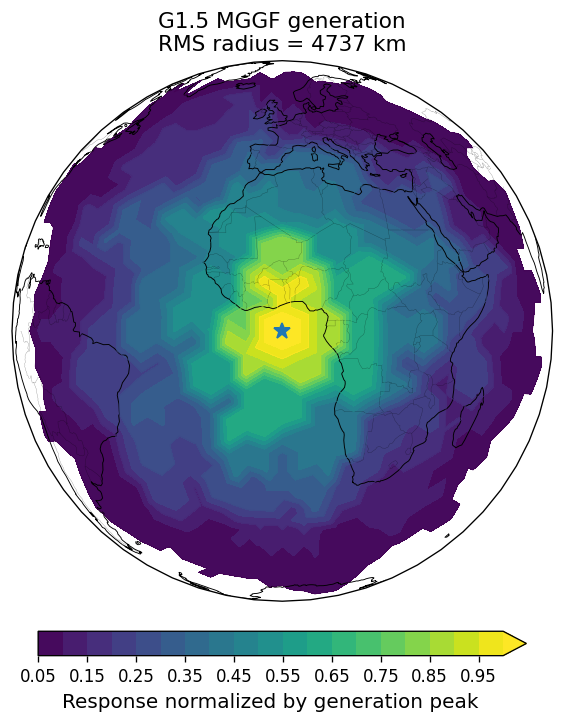

Saved: generation_orthographic_G2


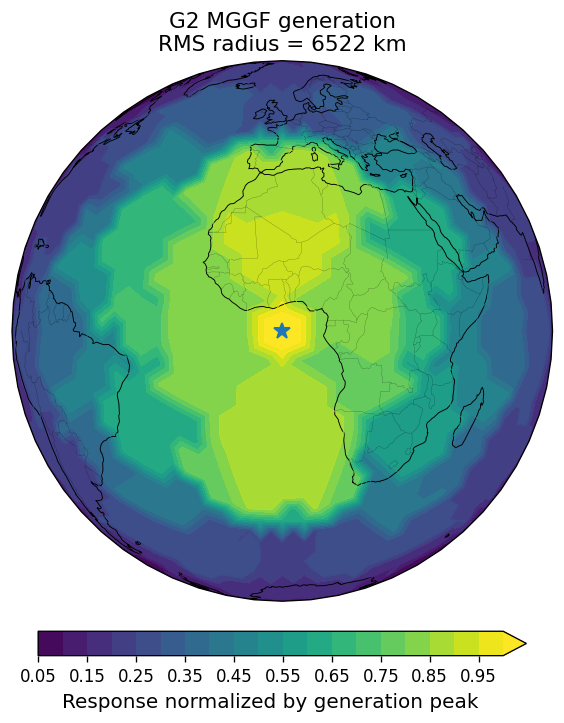

Saved: generation_orthographic_G3


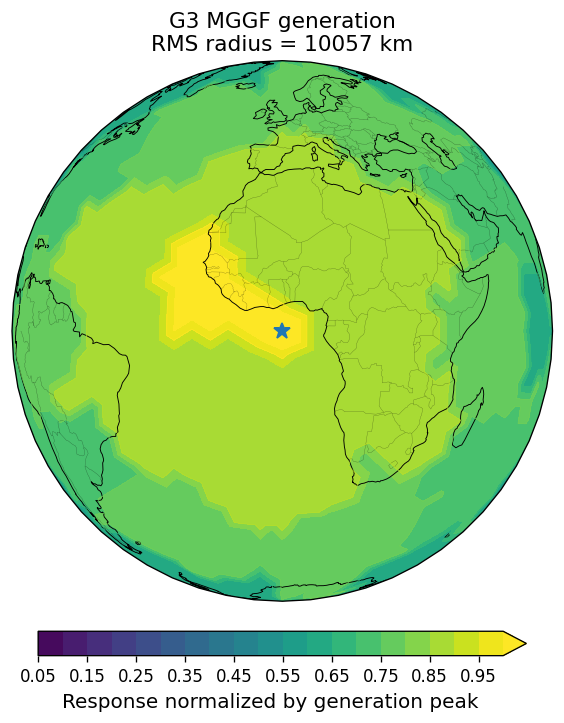

Saved: generation_six_panel_orthographic


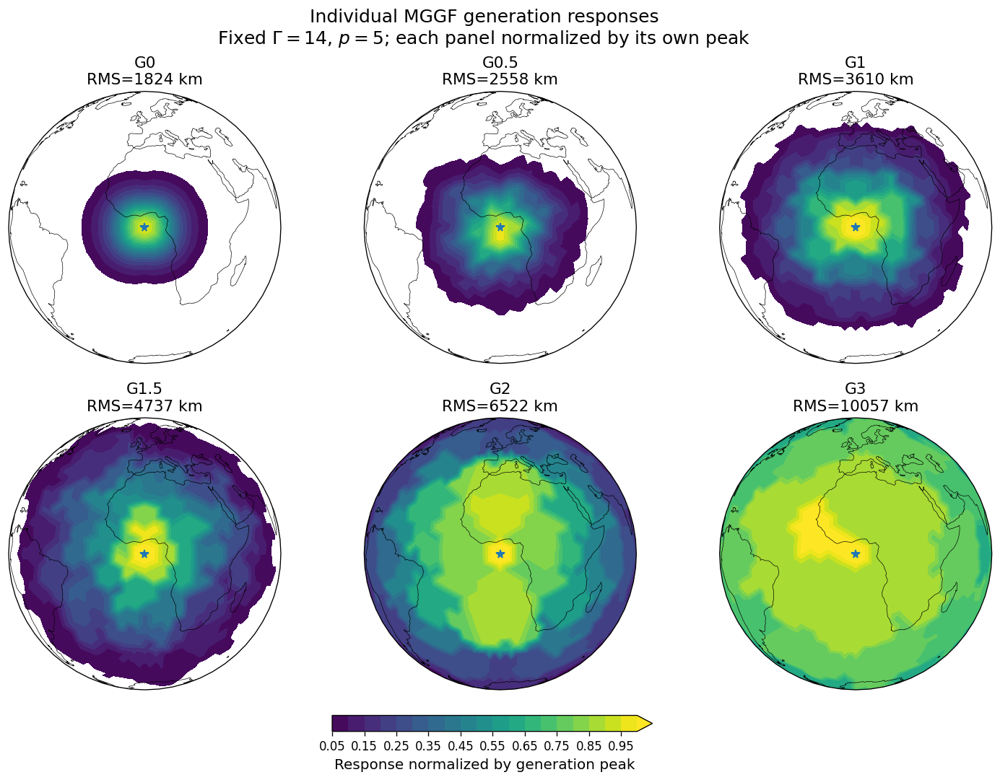

Saved: generation_annular_anisotropy


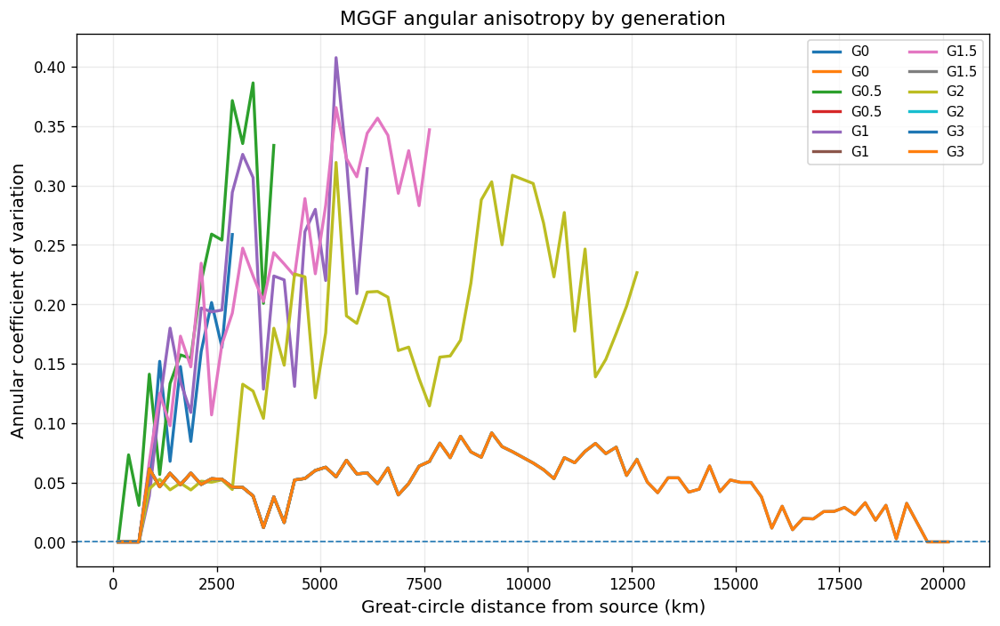

Saved: native_vs_prolongated_G0


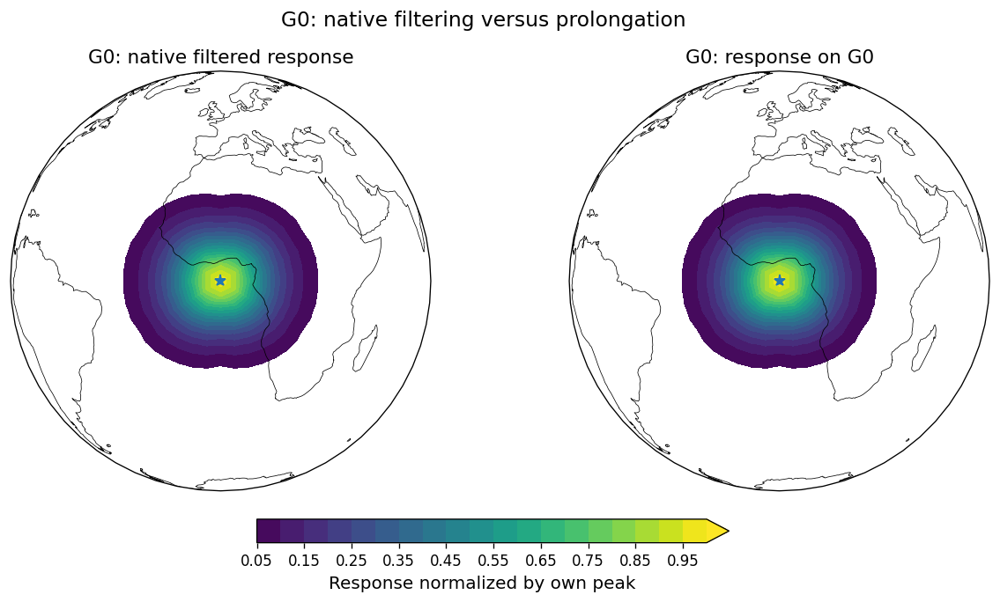

Saved: native_vs_prolongated_G1


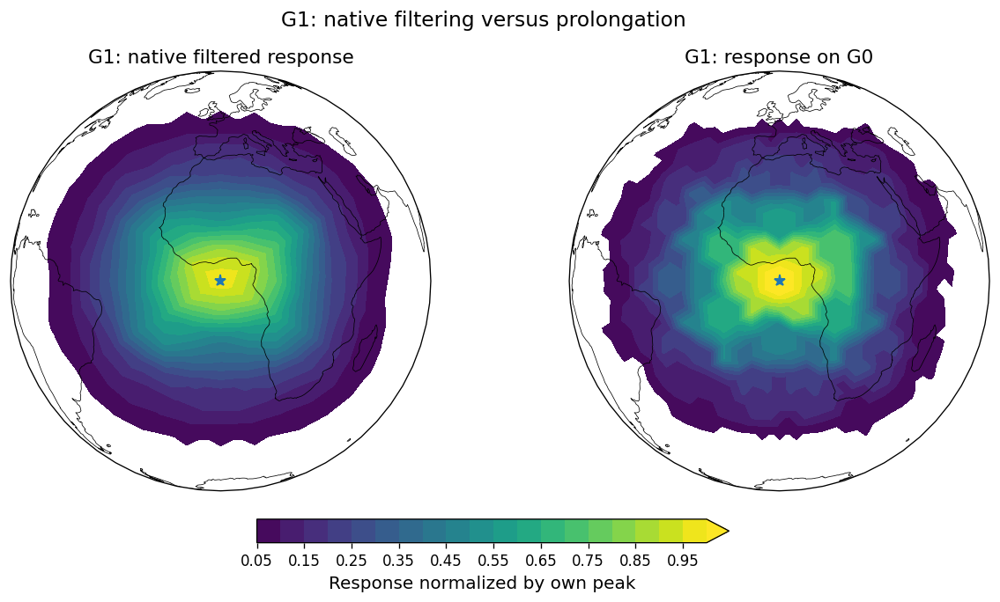

Saved: native_vs_prolongated_G2


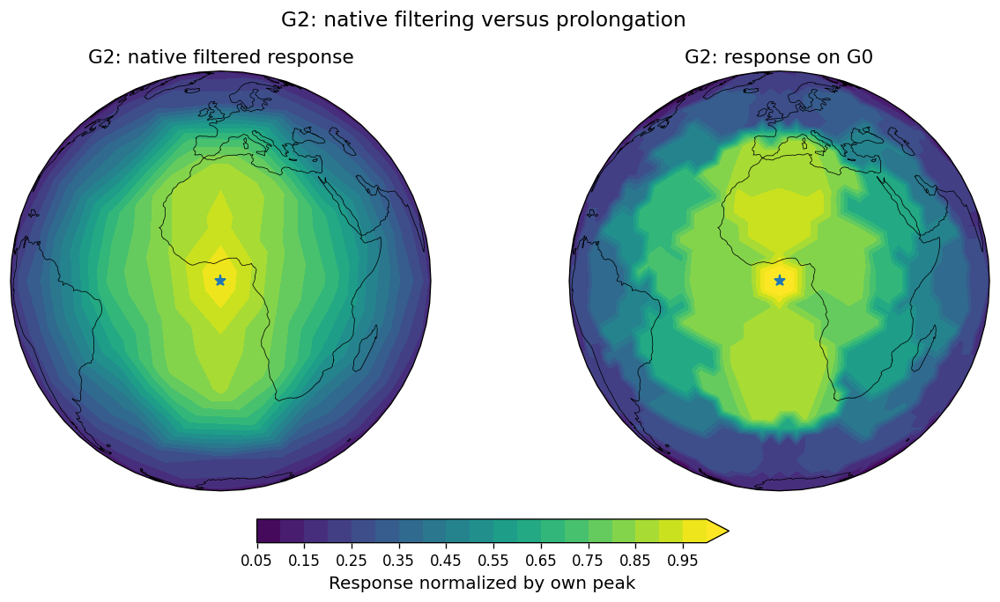

Saved: native_vs_prolongated_G3


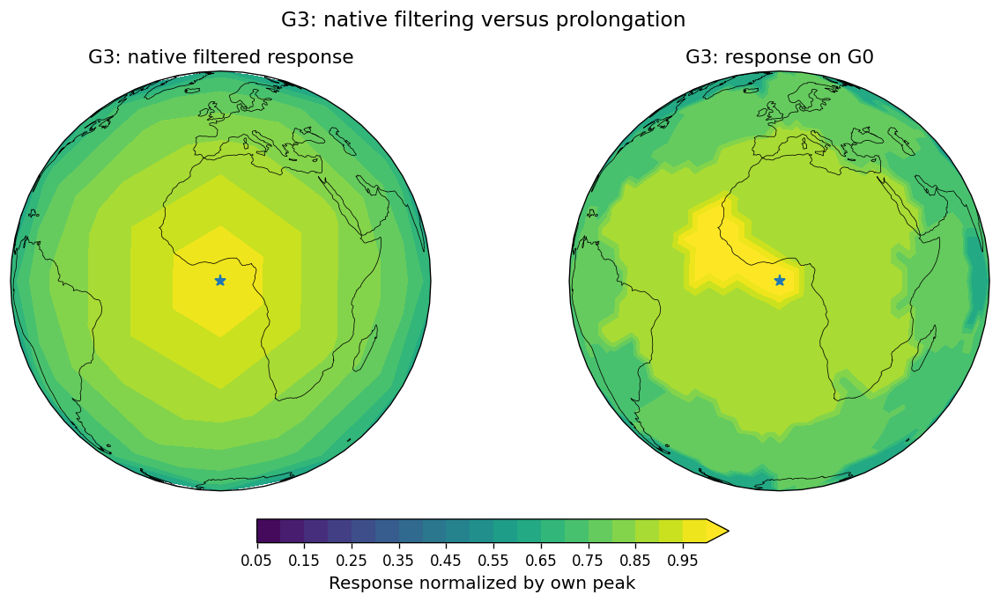



OFFLINE GAUSSIAN-SCALE CALIBRATION
sigma=    250 km : M2 NOT REPRESENTABLE
sigma=    500 km : M2 NOT REPRESENTABLE
sigma=    750 km : M2 NOT REPRESENTABLE
sigma=   1000 km : M2 NOT REPRESENTABLE
sigma=   1250 km : M2 NOT REPRESENTABLE
sigma=   1500 km  w=[ 0.663  0.337  0.000  0.000  0.000  0.000]  L2= 0.2520  RMS=  2100.5/  2100.5  Iratio=1.00000000
sigma=   1750 km  w=[ 0.179  0.821  0.000  0.000  0.000  0.000]  L2= 0.2700  RMS=  2442.8/  2442.8  Iratio=1.00000000
sigma=   2000 km  w=[ 0.000  0.816  0.184  0.000  0.000  0.000]  L2= 0.2855  RMS=  2781.3/  2781.3  Iratio=1.00000000
sigma=   2500 km  w=[ 0.000  0.180  0.820  0.000  0.000  0.000]  L2= 0.2555  RMS=  3444.3/  3444.3  Iratio=1.00000000
sigma=   3000 km  w=[ 0.000  0.000  0.611  0.389  0.000  0.000]  L2= 0.2706  RMS=  4085.2/  4085.2  Iratio=1.00000000
sigma=   3500 km  w=[ 0.000  0.000  0.115  0.849  0.036  0.000]  L2= 0.2908  RMS=  4699.5/  4699.5  Iratio=1.00000000
sigma=   4000 km  w=[ 0.000  0.000  0.007  0.717  0.275

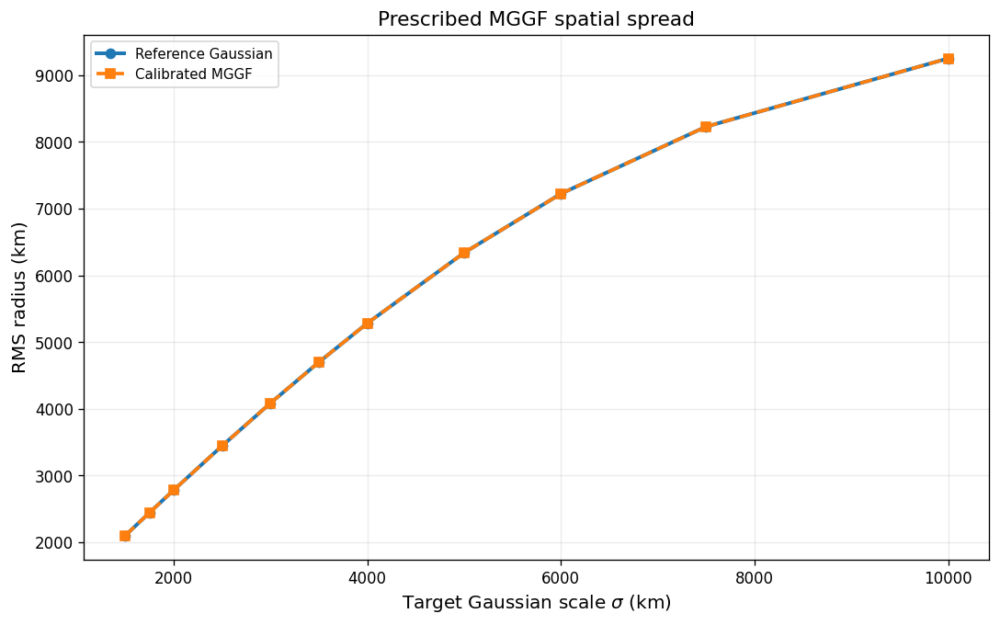

Saved: calibration_L2_error


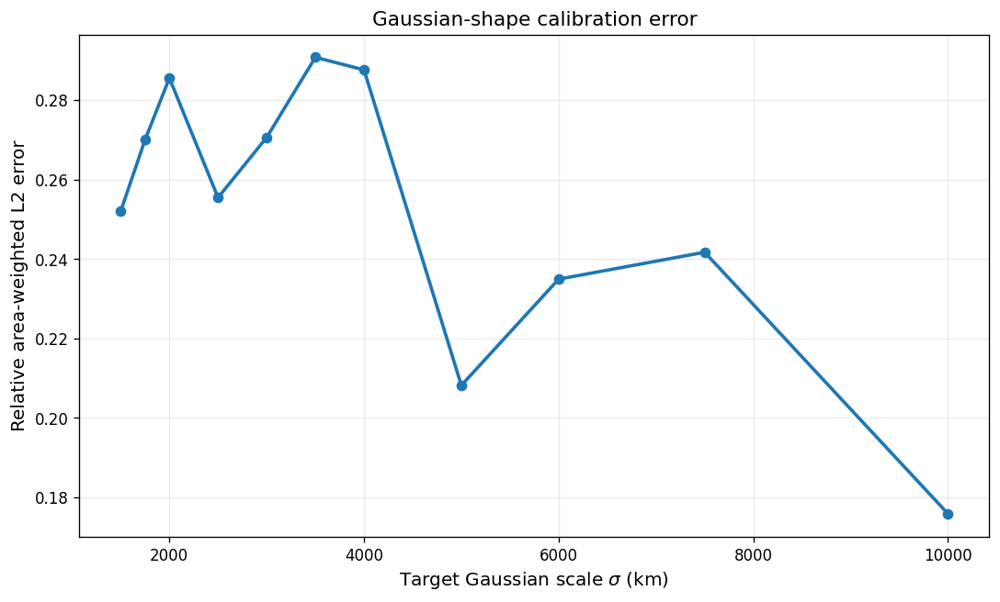

Saved: calibration_generation_weights


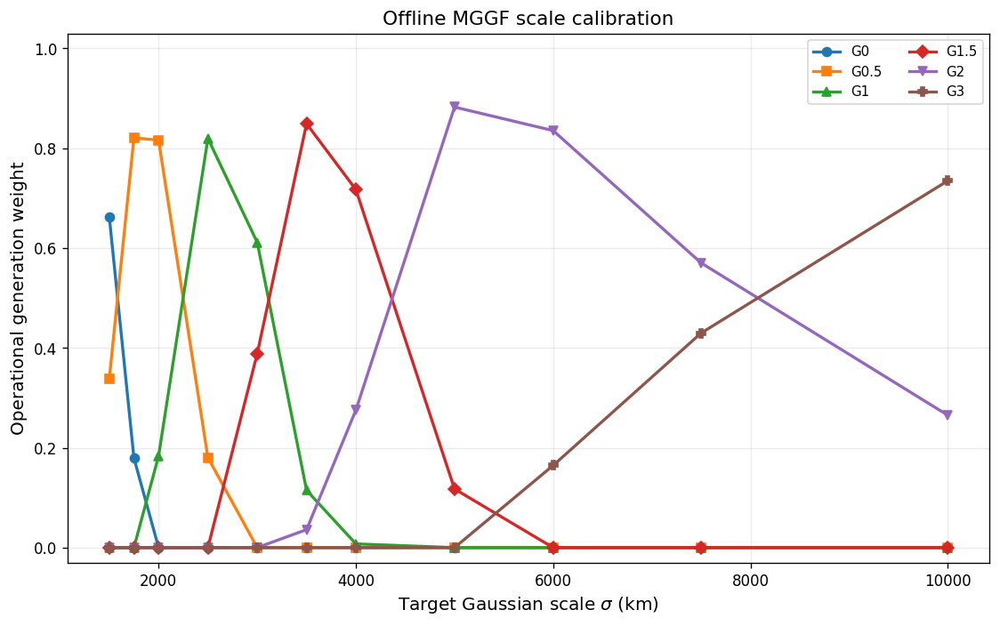

Saved: calibration_radial_sigma_01500km


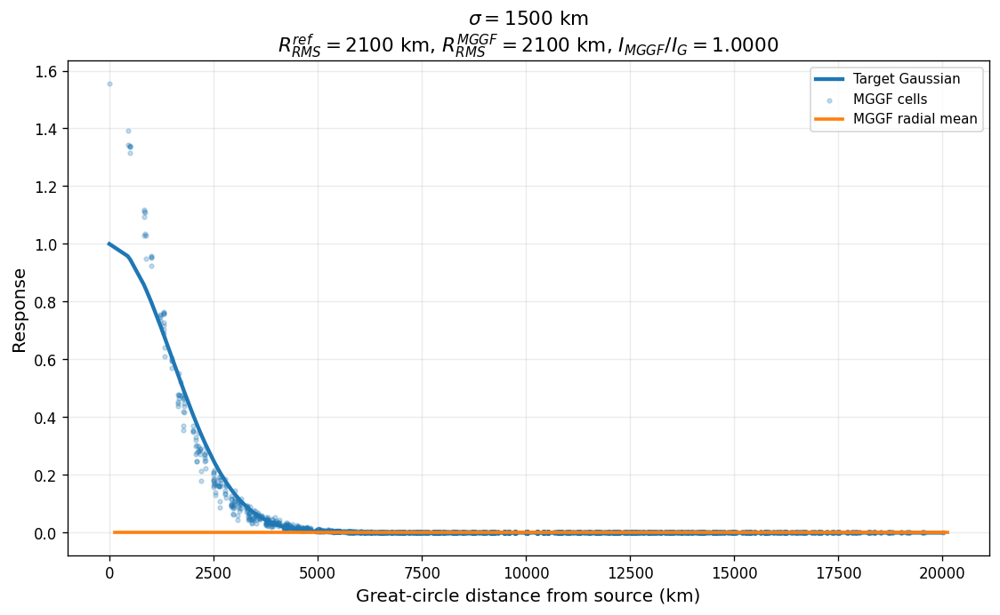

Saved: calibration_radial_sigma_02000km


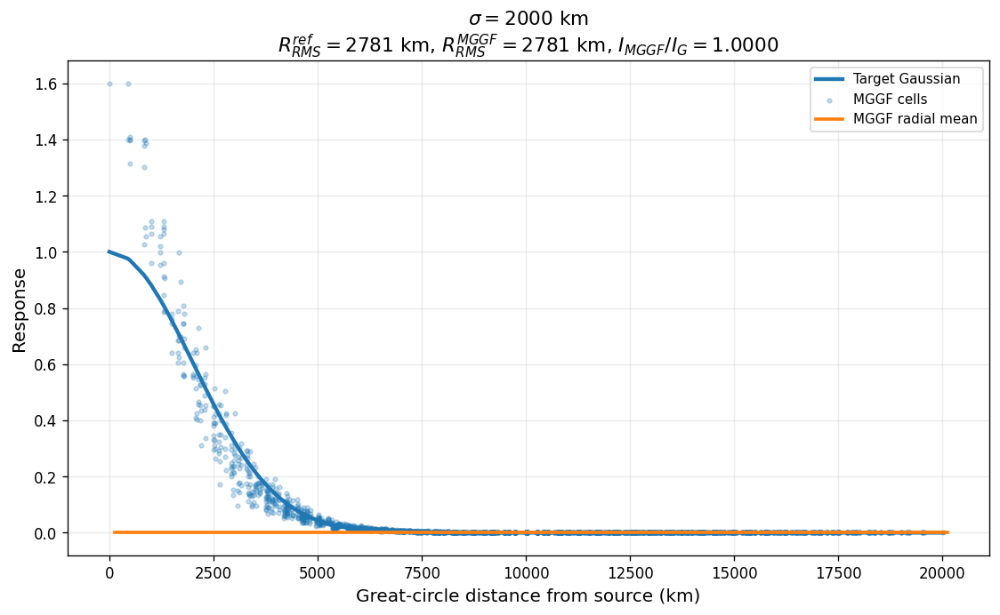

Saved: calibration_radial_sigma_03000km


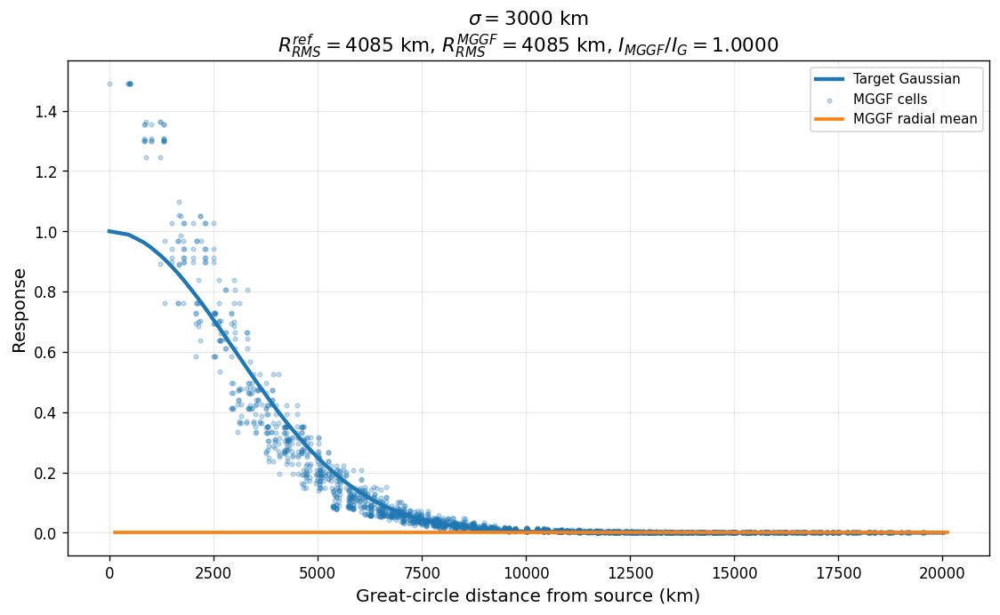

Saved: calibration_radial_sigma_05000km


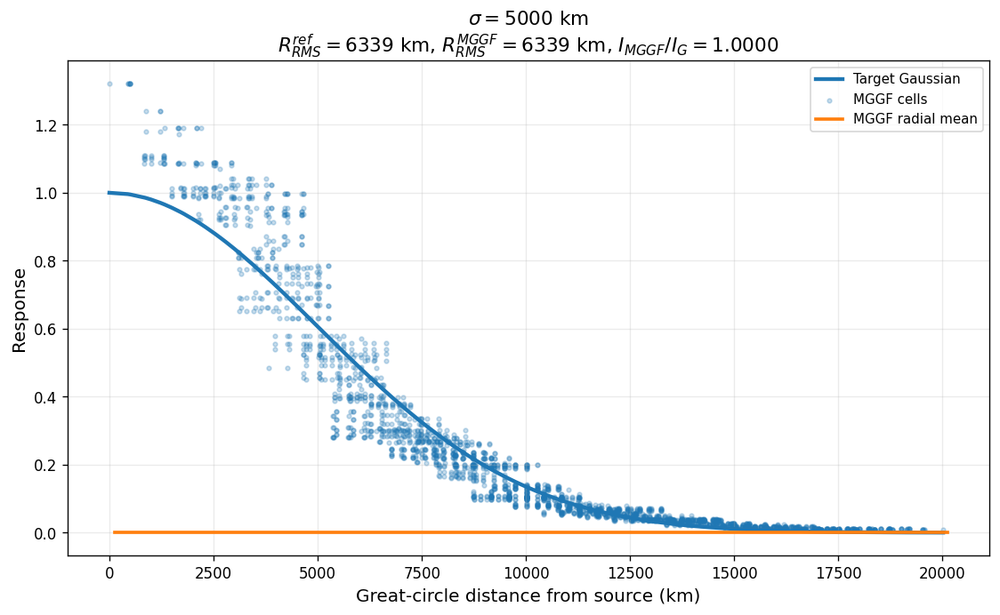

Saved: calibration_radial_sigma_07500km


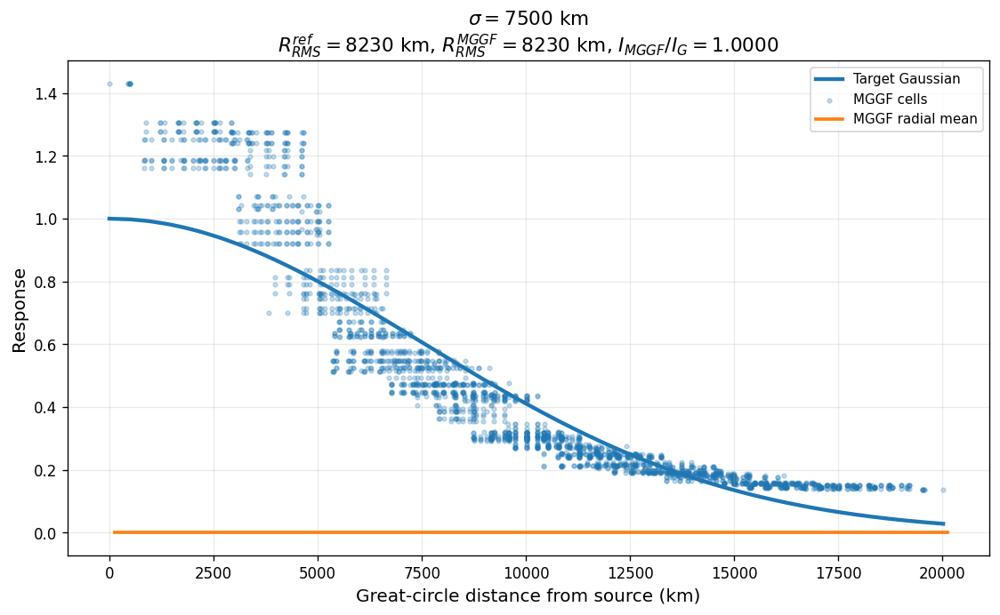

Saved: calibration_radial_sigma_10000km


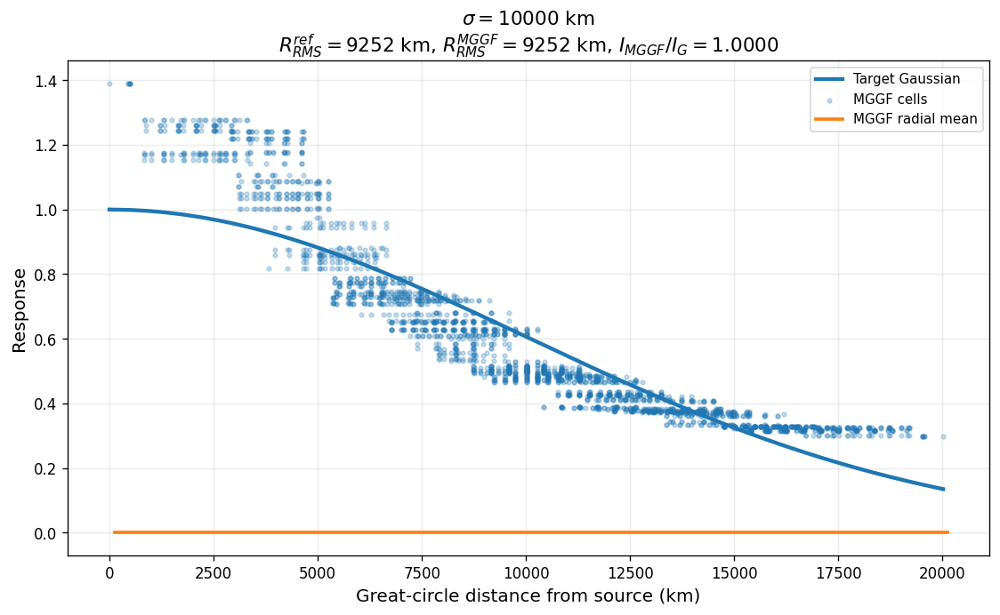

Saved: calibration_orthographic_sigma_02000km


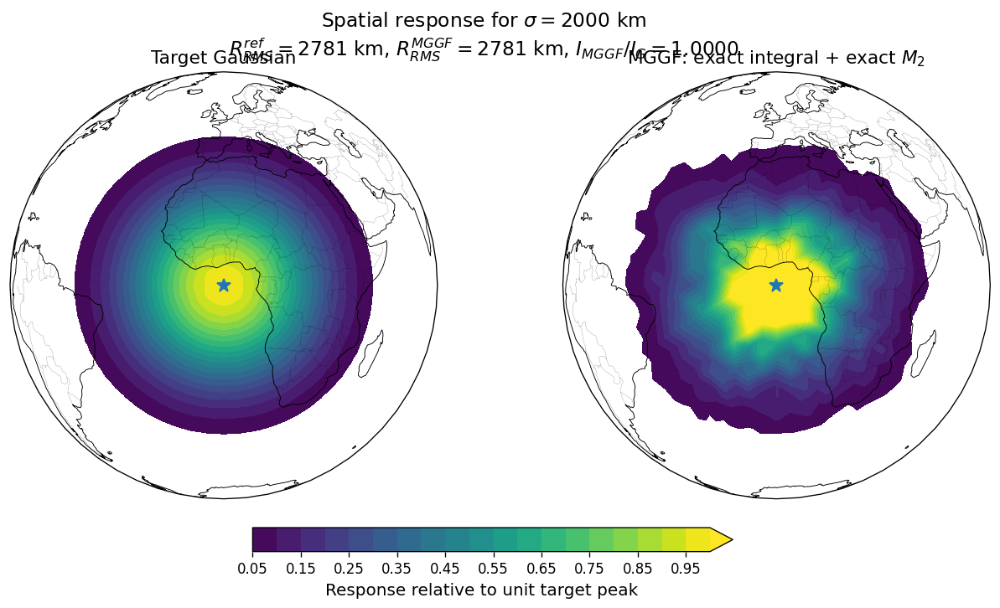

Saved: calibration_orthographic_sigma_05000km


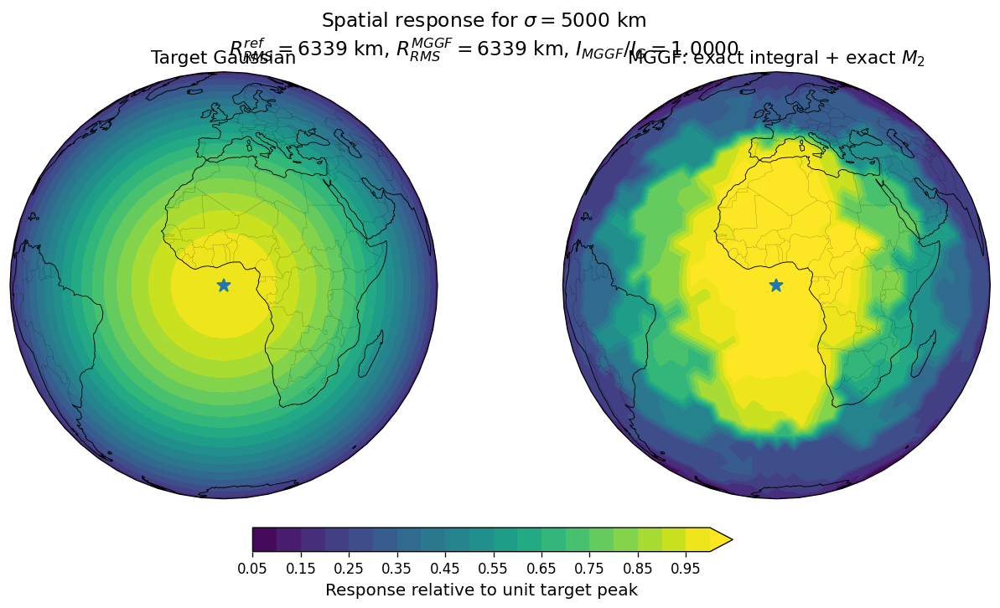

Saved: calibration_orthographic_sigma_10000km


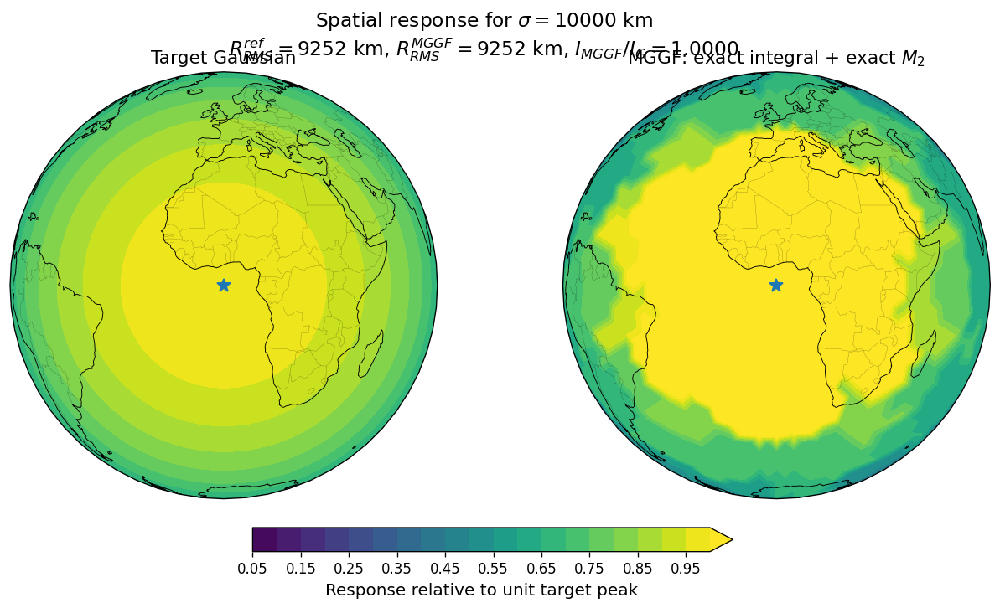



SELF-CONTAINED MGGF CALIBRATION / DIAGNOSTIC RUN COMPLETE

Fixed parameters:
  Gamma = 14.0
  p     = 5
  source G0 cell = 38

Generation RMS radii:
  G0   :  1823.786 km
  G0.5 :  2558.172 km
  G1   :  3610.107 km
  G1.5 :  4737.235 km
  G2   :  6522.172 km
  G3   : 10056.917 km

Important figures:
  generation_six_panel_orthographic
  generation_annular_anisotropy
  native_vs_prolongated_G0/G1/G2/G3
  calibration_RMS
  calibration_L2_error
  calibration_generation_weights
  calibration_radial_sigma_*
  calibration_orthographic_sigma_*

Operational calibration table:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_selfcontained_calibration/mggf_offline_scale_weights_exact_integral_M2.npz

All output:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_selfcontained_calibration


In [ ]:
# ======================================================================
# SELF-CONTAINED ICOSAHEDRAL MGGF CALIBRATION + GENERATION DIAGNOSTICS
#
# Purpose
# -------
# 1. Reconstruct the complete 6-generation MGGF from saved files:
#
#       G0, G0.5, G1, G1.5, G2, G3
#
# 2. Use fixed filter parameters:
#
#       Gamma = 14
#       p     = 5
#
# 3. Generate and diagnose EVERY individual generation response.
#
# 4. Determine whether anisotropy originates in:
#       - graph filtering,
#       - coarse resolution,
#       - or prolongation/restriction.
#
# 5. Perform offline Gaussian-scale calibration using:
#
#       exact integral
#       exact second radial moment M2
#       minimum area-weighted L2 shape error
#
# 6. Save operational scale weights and all figures.
#
# This script is designed to run in a NEW Colab runtime.
# It does NOT require variables from earlier notebook cells.
# ======================================================================


# ======================================================================
# 0. IMPORTS / GOOGLE DRIVE
# ======================================================================

from pathlib import Path
import sys
import subprocess

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from scipy.optimize import minimize

import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# Mount Google Drive
# ----------------------------------------------------------------------

from google.colab import drive

drive.mount(
    "/content/drive"
)


# ----------------------------------------------------------------------
# Cartopy
# ----------------------------------------------------------------------

try:

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    print("Cartopy already installed.")

except ImportError:

    print("Installing Cartopy...")

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "cartopy"
        ]
    )

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    print("Cartopy installed.")


# ======================================================================
# 1. PATHS AND FIXED PARAMETERS
# ======================================================================

ROOT = Path(
    "/content/drive/MyDrive/GLOBAL_SW_FV"
)

GRID = (
    ROOT / "grid"
)

INT = (
    ROOT / "intermediate_generations"
)


G0_FILE = (
    GRID
    / "global_hex_ico_grid_nsub4.npz"
)

G1_FILE = (
    GRID
    / "global_hex_ico_grid_nsub3.npz"
)

G2_FILE = (
    GRID
    / "global_hex_ico_grid_nsub2.npz"
)

G3_FILE = (
    GRID
    / "global_hex_ico_grid_nsub1.npz"
)

COMM_FILE = (
    GRID
    / "global_hex_ico_geometric_communication_v0.npz"
)

G05_FILE = (
    INT
    / "mggf_G0p5_pair_hierarchy_v0.npz"
)

G15_FILE = (
    INT
    / "mggf_G1p5_pair_hierarchy_v1.npz"
)


OUTDIR = (
    ROOT
    / "mggf_selfcontained_calibration"
)

OUTDIR.mkdir(
    parents=True,
    exist_ok=True
)


# ----------------------------------------------------------------------
# Fixed filter parameters
# ----------------------------------------------------------------------

GAMMA = 14.0

P_ORDER = 5

SOURCE_G0 = 38


# IMPORTANT:
#
# Keep the historical value used in the calibration baseline.
#
EARTH_RADIUS_M = 6371000.0


SINKHORN_TOL = 1.0e-13

SINKHORN_MAXITER = 20000


# ----------------------------------------------------------------------
# Gaussian scales for offline calibration
# ----------------------------------------------------------------------

SIGMA_LIST_KM = np.array(
    [
        250.,
        500.,
        750.,
        1000.,
        1250.,
        1500.,
        1750.,
        2000.,
        2500.,
        3000.,
        3500.,
        4000.,
        5000.,
        6000.,
        7500.,
        10000.
    ],
    dtype=np.float64
)


# Representative calibration plots

RADIAL_SIGMA_KM = [
    1500.,
    2000.,
    3000.,
    5000.,
    7500.,
    10000.
]


ORTHO_SIGMA_KM = [
    2000.,
    5000.,
    10000.
]


print("\nOutput directory:")
print(OUTDIR)


# ======================================================================
# 2. BASIC UTILITIES
# ======================================================================

def load_npz(path):

    if not path.exists():

        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )

    return np.load(
        path,
        allow_pickle=True
    )


def first_key(
    z,
    names
):

    for name in names:

        if name in z.files:

            return name

    raise KeyError(
        f"None of {names} found.\n"
        f"Available keys:\n{z.files}"
    )


def normalize_xyz(xyz):

    xyz = np.asarray(
        xyz,
        dtype=np.float64
    )

    return (
        xyz
        /
        np.linalg.norm(
            xyz,
            axis=1,
            keepdims=True
        )
    )


def xyz_to_lonlat(xyz):

    q = normalize_xyz(
        xyz
    )

    lon = np.degrees(
        np.arctan2(
            q[:, 1],
            q[:, 0]
        )
    )

    lat = np.degrees(
        np.arcsin(
            np.clip(
                q[:, 2],
                -1.0,
                1.0
            )
        )
    )

    return lon, lat


def great_circle_from_point(
    xyz,
    source_xyz
):

    q = normalize_xyz(
        xyz
    )

    s = np.asarray(
        source_xyz,
        dtype=np.float64
    )

    s = (
        s
        /
        np.linalg.norm(s)
    )

    cosine = np.clip(
        q @ s,
        -1.0,
        1.0
    )

    return (
        EARTH_RADIUS_M
        * np.arccos(cosine)
    )


# ======================================================================
# 3. CONSERVATIVE HARD-PARENT TRANSFER
# ======================================================================

def build_PR(
    parent,
    area_f,
    nc
):

    parent = np.asarray(
        parent,
        dtype=np.int64
    ).ravel()

    area_f = np.asarray(
        area_f,
        dtype=np.float64
    )

    nf = len(
        area_f
    )

    if len(parent) != nf:

        raise ValueError(
            "Parent-map length mismatch."
        )

    if (
        np.min(parent) < 0
        or
        np.max(parent) >= nc
    ):

        raise ValueError(
            "Invalid parent indices."
        )


    # ----------------------------------------------------------
    # Piecewise-constant prolongation
    # ----------------------------------------------------------

    P = sp.coo_matrix(
        (
            np.ones(nf),
            (
                np.arange(nf),
                parent
            )
        ),
        shape=(
            nf,
            nc
        )
    ).tocsr()


    # ----------------------------------------------------------
    # Hierarchy coarse areas
    #
    # IMPORTANT:
    # derived from child areas, not independently generated
    # geometric coarse areas.
    # ----------------------------------------------------------

    area_c = np.asarray(
        P.T @ area_f
    ).ravel()


    if np.any(
        area_c <= 0.0
    ):

        raise ValueError(
            "Nonpositive coarse-cell area."
        )


    # ----------------------------------------------------------
    # Conservative area-weighted restriction
    # ----------------------------------------------------------

    R = (
        sp.diags(
            1.0 / area_c
        )
        @ P.T
        @ sp.diags(
            area_f
        )
    ).tocsr()


    return (
        P,
        R,
        area_c
    )


# ======================================================================
# 4. GRAPH ADJACENCY
# ======================================================================

def adjacency_from_edges(
    n,
    edges
):

    edges = np.asarray(
        edges,
        dtype=np.int64
    )


    if edges.ndim != 2:

        raise ValueError(
            "Invalid edge array."
        )


    if (
        edges.shape[0] == 2
        and
        edges.shape[1] != 2
    ):

        edges = (
            edges.T
        )


    edges = (
        edges[:, :2]
    )


    edges = edges[
        edges[:, 0]
        !=
        edges[:, 1]
    ]


    if (
        np.any(edges < 0)
        or
        np.any(edges >= n)
    ):

        raise ValueError(
            "Invalid graph edge indices."
        )


    edges = np.unique(
        np.sort(
            edges,
            axis=1
        ),
        axis=0
    )


    ii = np.concatenate(
        [
            edges[:, 0],
            edges[:, 1]
        ]
    )

    jj = np.concatenate(
        [
            edges[:, 1],
            edges[:, 0]
        ]
    )


    adjacency = sp.coo_matrix(
        (
            np.ones(
                len(ii)
            ),
            (
                ii,
                jj
            )
        ),
        shape=(
            n,
            n
        )
    ).tocsr()


    adjacency.setdiag(
        0.0
    )

    adjacency.eliminate_zeros()


    adjacency = (
        0.5
        * (
            adjacency
            +
            adjacency.T
        )
    ).tocsr()


    adjacency.eliminate_zeros()


    return adjacency


def adjacency_from_dual_cells(
    dual_cells
):

    edge_to_cells = {}


    for ci, poly in enumerate(
        dual_cells
    ):

        poly = np.asarray(
            poly,
            dtype=np.int64
        ).ravel()


        for k in range(
            len(poly)
        ):

            a = int(
                poly[k]
            )

            b = int(
                poly[
                    (k + 1)
                    % len(poly)
                ]
            )


            edge = tuple(
                sorted(
                    (
                        a,
                        b
                    )
                )
            )


            edge_to_cells.setdefault(
                edge,
                []
            ).append(
                ci
            )


    neighbors = [
        set()
        for _ in range(
            len(dual_cells)
        )
    ]


    for cells in (
        edge_to_cells.values()
    ):

        if len(cells) == 2:

            i, j = cells

            if i != j:

                neighbors[i].add(j)

                neighbors[j].add(i)


    edges = [
        (
            i,
            j
        )
        for i, nbrs
        in enumerate(neighbors)
        for j in nbrs
        if i < j
    ]


    return adjacency_from_edges(
        len(dual_cells),
        np.asarray(
            edges,
            dtype=np.int64
        )
    )


def edges_from_adjacency(
    adjacency
):

    A = sp.triu(
        adjacency,
        k=1
    ).tocoo()

    return np.column_stack(
        [
            A.row,
            A.col
        ]
    ).astype(
        np.int64
    )


# ======================================================================
# 5. AREA-COMPATIBLE GRAPH LAPLACIAN
# ======================================================================

def build_area_compatible_laplacian(
    adjacency,
    area,
    name
):

    adjacency = (
        adjacency
        .tocsr()
        .astype(
            np.float64
        )
    )

    area = np.asarray(
        area,
        dtype=np.float64
    )

    n = len(
        area
    )


    if (
        adjacency.shape
        !=
        (n, n)
    ):

        raise ValueError(
            f"{name}: adjacency mismatch."
        )


    if np.any(
        area <= 0.0
    ):

        raise ValueError(
            f"{name}: invalid areas."
        )


    # ----------------------------------------------------------
    # Dimensionless hierarchy areas
    # ----------------------------------------------------------

    ahat = (
        area
        /
        np.mean(area)
    )


    # ----------------------------------------------------------
    # Symmetric graph-edge balancing
    # ----------------------------------------------------------

    s = np.ones(
        n,
        dtype=np.float64
    )

    converged = False


    for iteration in range(
        SINKHORN_MAXITER
    ):

        adjacency_s = (
            adjacency @ s
        )


        if np.any(
            adjacency_s <= 0.0
        ):

            raise RuntimeError(
                f"{name}: invalid adjacency."
            )


        s_new = np.sqrt(
            s
            * ahat
            / adjacency_s
        )


        row_sum_new = (
            s_new
            * (
                adjacency @ s_new
            )
        )


        rel_error = np.max(
            np.abs(
                row_sum_new
                - ahat
            )
            /
            np.maximum(
                ahat,
                1.0e-300
            )
        )


        s = s_new


        if (
            rel_error
            <
            SINKHORN_TOL
        ):

            converged = True

            break


    if not converged:

        raise RuntimeError(
            f"{name}: balancing failed. "
            f"error={rel_error:.3e}"
        )


    Wedge = (
        sp.diags(s)
        @ adjacency
        @ sp.diags(s)
    ).tocsr()


    Wedge = (
        0.5
        * (
            Wedge
            +
            Wedge.T
        )
    ).tocsr()


    Wedge.eliminate_zeros()


    row_sum = np.asarray(
        Wedge
        @ np.ones(n)
    ).ravel()


    Q = (
        sp.diags(
            row_sum
        )
        -
        Wedge
    ).tocsr()


    L_A = (
        sp.diags(
            1.0 / ahat
        )
        @ Q
    ).tocsr()


    # ----------------------------------------------------------
    # Diagnostics
    # ----------------------------------------------------------

    balance_error = np.max(
        np.abs(
            row_sum
            - ahat
        )
        /
        np.maximum(
            ahat,
            1.0e-300
        )
    )


    constant_error = np.max(
        np.abs(
            L_A
            @ np.ones(n)
        )
    )


    Ahat = sp.diags(
        ahat
    )


    adjoint_error = (
        spla.norm(
            Ahat @ L_A
            -
            L_A.T @ Ahat
        )
        /
        max(
            spla.norm(
                Ahat @ L_A
            ),
            1.0e-300
        )
    )


    print(
        f"{name:5s}: "
        f"N={n:4d} "
        f"iterations={iteration + 1:5d} "
        f"balance={balance_error:.3e} "
        f"constant={constant_error:.3e} "
        f"adjoint={adjoint_error:.3e}"
    )


    return L_A


# ======================================================================
# 6. REPEATED RESOLVENT
# ======================================================================

def repeated_resolvent(
    L_A,
    Gamma,
    x,
    p=P_ORDER
):

    system = (
        sp.eye(
            L_A.shape[0],
            format="csc"
        )
        +
        (
            Gamma
            /
            float(p)
        )
        *
        L_A.tocsc()
    )


    lu = spla.splu(
        system
    )


    y = np.asarray(
        x,
        dtype=np.float64
    ).copy()


    for _ in range(p):

        y = lu.solve(
            y
        )


    return y


# ======================================================================
# 7. LOAD ALL FOUR STANDARD ICOSAHEDRAL GRIDS
# ======================================================================

print("\n")
print("=" * 80)
print("LOADING STANDARD GRIDS")
print("=" * 80)


g0 = load_npz(
    G0_FILE
)

g1 = load_npz(
    G1_FILE
)

g2 = load_npz(
    G2_FILE
)

g3 = load_npz(
    G3_FILE
)


xyz0 = normalize_xyz(
    g0["cell_center_xyz"]
)

xyz1 = normalize_xyz(
    g1["cell_center_xyz"]
)

xyz2 = normalize_xyz(
    g2["cell_center_xyz"]
)

xyz3 = normalize_xyz(
    g3["cell_center_xyz"]
)


area0 = np.asarray(
    g0["cell_area"],
    dtype=np.float64
)


area1_geom = np.asarray(
    g1["cell_area"],
    dtype=np.float64
)

area2_geom = np.asarray(
    g2["cell_area"],
    dtype=np.float64
)

area3_geom = np.asarray(
    g3["cell_area"],
    dtype=np.float64
)


dual0 = g0["dual_cells"]

dual1 = g1["dual_cells"]

dual2 = g2["dual_cells"]

dual3 = g3["dual_cells"]


n0 = len(
    area0
)

n1 = len(
    area1_geom
)

n2 = len(
    area2_geom
)

n3 = len(
    area3_geom
)


print(
    "Grid sizes:",
    n0,
    n1,
    n2,
    n3
)


if (
    n0 != 2562
    or
    n1 != 642
    or
    n2 != 162
    or
    n3 != 42
):

    raise RuntimeError(
        "Unexpected standard-grid sizes."
    )


# ======================================================================
# 8. ORIGINAL G0 -> G1 -> G2 HIERARCHY
# ======================================================================

print("\n")
print("=" * 80)
print("RECONSTRUCTING ORIGINAL HARD-PARENT HIERARCHY")
print("=" * 80)


comm = load_npz(
    COMM_FILE
)


parent01 = np.asarray(
    comm[
        first_key(
            comm,
            [
                "parent01",
                "parent_of_G0",
                "parent_G0_to_G1",
                "parent0_to_1",
                "parent_G0_G1"
            ]
        )
    ],
    dtype=np.int64
).ravel()


parent12 = np.asarray(
    comm[
        first_key(
            comm,
            [
                "parent12",
                "parent_of_G1",
                "parent_G1_to_G2",
                "parent1_to_2",
                "parent_G1_G2"
            ]
        )
    ],
    dtype=np.int64
).ravel()


P01, R10, area1 = build_PR(
    parent01,
    area0,
    n1
)


P12, R21, area2 = build_PR(
    parent12,
    area1,
    n2
)


P02 = (
    P01 @ P12
).tocsr()


R20 = (
    R21 @ R10
).tocsr()


print(
    "G1 hierarchy/geometric area RMS rel difference =",
    np.sqrt(
        np.mean(
            (
                (
                    area1
                    -
                    area1_geom
                )
                /
                area1_geom
            )**2
        )
    )
)


print(
    "G2 hierarchy/geometric area RMS rel difference =",
    np.sqrt(
        np.mean(
            (
                (
                    area2
                    -
                    area2_geom
                )
                /
                area2_geom
            )**2
        )
    )
)


# ======================================================================
# 9. INTERMEDIATE GENERATION G0.5
# ======================================================================

z05 = load_npz(
    G05_FILE
)


parent005 = np.asarray(
    z05[
        "parent_of_G0"
    ],
    dtype=np.int64
).ravel()


edges05 = np.asarray(
    z05[
        "edges_G0p5"
    ],
    dtype=np.int64
)


n05 = len(
    np.asarray(
        z05[
            "cell_area_G0p5"
        ]
    )
)


P005, R050, area05 = build_PR(
    parent005,
    area0,
    n05
)


# ======================================================================
# 10. INTERMEDIATE GENERATION G1.5
# ======================================================================

z15 = load_npz(
    G15_FILE
)


parent115 = np.asarray(
    z15[
        first_key(
            z15,
            [
                "parent_of_G1",
                "parent_G1_to_G1p5",
                "parent_G1_G1p5"
            ]
        )
    ],
    dtype=np.int64
).ravel()


edges15 = np.asarray(
    z15[
        first_key(
            z15,
            [
                "edges_G1p5",
                "edges_G1_5"
            ]
        )
    ],
    dtype=np.int64
)


n15 = len(
    np.asarray(
        z15[
            first_key(
                z15,
                [
                    "cell_area_G1p5",
                    "cell_area_G1_5"
                ]
            )
        ]
    )
)


P115, R151, area15 = build_PR(
    parent115,
    area1,
    n15
)


P015 = (
    P01 @ P115
).tocsr()


R150 = (
    R151 @ R10
).tocsr()


# ======================================================================
# 11. CONSTRUCT G2 -> G3 HARD-PARENT MAP
#
# G3 vertices are an exact subset of G2 vertices.
#
# Each remaining G2 vertex is an edge midpoint of two G3 vertices.
#
# The midpoint is assigned to one endpoint using deterministic
# area-load balancing.
# ======================================================================

print("\n")
print("=" * 80)
print("CONSTRUCTING DETERMINISTIC G2 -> G3 HARD-PARENT MAP")
print("=" * 80)


# ----------------------------------------------------------------------
# Find exact inherited G3 vertices in G2
# ----------------------------------------------------------------------

dot23 = (
    xyz2 @ xyz3.T
)


nearest3 = np.argmax(
    dot23,
    axis=1
)


nearest_cos = np.max(
    dot23,
    axis=1
)


nearest_angle = np.arccos(
    np.clip(
        nearest_cos,
        -1.0,
        1.0
    )
)


# Very tight geometric tolerance.

INHERIT_TOL = 1.0e-10


inherited = (
    nearest_angle
    <
    INHERIT_TOL
)


print(
    "Inherited G3 vertices found:",
    np.sum(inherited)
)


if np.sum(
    inherited
) != 42:

    raise RuntimeError(
        "Expected exactly 42 inherited G3 vertices."
    )


parent23 = np.full(
    n2,
    -1,
    dtype=np.int64
)


parent23[
    inherited
] = nearest3[
    inherited
]


# ----------------------------------------------------------------------
# G3 adjacency
# ----------------------------------------------------------------------

Adj3_geom = adjacency_from_dual_cells(
    dual3
)


edges3 = edges_from_adjacency(
    Adj3_geom
)


print(
    "G3 edges:",
    len(edges3)
)


if len(
    edges3
) != 120:

    raise RuntimeError(
        "Expected 120 G3 edges."
    )


# ----------------------------------------------------------------------
# Match each non-inherited G2 vertex to a G3 edge midpoint
# ----------------------------------------------------------------------

midpoint_xyz = (
    xyz3[
        edges3[:, 0]
    ]
    +
    xyz3[
        edges3[:, 1]
    ]
)


midpoint_xyz = normalize_xyz(
    midpoint_xyz
)


non_inherited_idx = np.where(
    ~inherited
)[0]


if len(
    non_inherited_idx
) != 120:

    raise RuntimeError(
        "Expected 120 G2 midpoint vertices."
    )


dot_mid = (
    xyz2[
        non_inherited_idx
    ]
    @ midpoint_xyz.T
)


best_edge = np.argmax(
    dot_mid,
    axis=1
)


best_cos = np.max(
    dot_mid,
    axis=1
)


best_angle = np.arccos(
    np.clip(
        best_cos,
        -1.0,
        1.0
    )
)


print(
    "Maximum midpoint matching angle =",
    np.max(best_angle)
)

MIDPOINT_TOL = 1.0e-7

if np.max(
    best_angle
) > MIDPOINT_TOL:

    raise RuntimeError(
        "G2 midpoint -> G3 edge matching failed."
    )


# ----------------------------------------------------------------------
# Deterministic area-load balancing
# ----------------------------------------------------------------------

load = np.zeros(
    n3,
    dtype=np.float64
)


# First add inherited-cell loads.

for i in np.where(
    inherited
)[0]:

    J = parent23[i]

    load[J] += area2[i]


# Process midpoint cells from largest hierarchy area downward.

order_mid = np.argsort(
    -area2[
        non_inherited_idx
    ]
)


for qq in order_mid:

    i = (
        non_inherited_idx[qq]
    )

    e = (
        best_edge[qq]
    )

    J1 = int(
        edges3[e, 0]
    )

    J2 = int(
        edges3[e, 1]
    )


    score1 = (
        load[J1]
        /
        area3_geom[J1]
    )

    score2 = (
        load[J2]
        /
        area3_geom[J2]
    )


    if score1 < score2:

        J = J1

    elif score2 < score1:

        J = J2

    else:

        J = min(
            J1,
            J2
        )


    parent23[i] = J

    load[J] += area2[i]


if np.any(
    parent23 < 0
):

    raise RuntimeError(
        "Incomplete G2 -> G3 parent map."
    )


P23, R32, area3 = build_PR(
    parent23,
    area2,
    n3
)


P03 = (
    P02 @ P23
).tocsr()


R30 = (
    R32 @ R20
).tocsr()


counts23 = np.bincount(
    parent23,
    minlength=n3
)


print(
    "G2 -> G3 child counts:"
)

print(
    "  min  =",
    counts23.min()
)

print(
    "  mean =",
    counts23.mean()
)

print(
    "  max  =",
    counts23.max()
)


print(
    "G3 hierarchy/geometric area RMS rel difference =",
    np.sqrt(
        np.mean(
            (
                (
                    area3
                    -
                    area3_geom
                )
                /
                area3_geom
            )**2
        )
    )
)


# ======================================================================
# 12. GRAPH ADJACENCIES
# ======================================================================

print("\n")
print("=" * 80)
print("CONSTRUCTING GRAPH ADJACENCIES")
print("=" * 80)


Adj0 = adjacency_from_dual_cells(
    dual0
)

Adj05 = adjacency_from_edges(
    n05,
    edges05
)

Adj1 = adjacency_from_dual_cells(
    dual1
)

Adj15 = adjacency_from_edges(
    n15,
    edges15
)

Adj2 = adjacency_from_dual_cells(
    dual2
)

Adj3 = adjacency_from_dual_cells(
    dual3
)


generation_structure = [
    (
        "G0",
        area0,
        Adj0
    ),
    (
        "G0.5",
        area05,
        Adj05
    ),
    (
        "G1",
        area1,
        Adj1
    ),
    (
        "G1.5",
        area15,
        Adj15
    ),
    (
        "G2",
        area2,
        Adj2
    ),
    (
        "G3",
        area3,
        Adj3
    )
]


for (
    name,
    area,
    adjacency
) in generation_structure:

    degree = np.asarray(
        adjacency.sum(
            axis=1
        )
    ).ravel()


    print(
        f"{name:5s}: "
        f"N={len(area):4d} "
        f"edges={adjacency.nnz//2:5d} "
        f"degree=[{degree.min():.0f},"
        f"{degree.max():.0f}] "
        f"area={np.sum(area):.12e}"
    )


# ======================================================================
# 13. TRANSFER CHECKS
# ======================================================================

def check_transfer(
    name,
    P,
    R,
    area_f,
    area_c
):

    area_error = np.max(
        np.abs(
            np.asarray(
                P.T @ area_f
            ).ravel()
            -
            area_c
        )
    ) / np.max(
        area_c
    )


    r_error = np.max(
        np.abs(
            R
            @ np.ones(
                len(area_f)
            )
            -
            1.0
        )
    )


    p_error = np.max(
        np.abs(
            P
            @ np.ones(
                len(area_c)
            )
            -
            1.0
        )
    )


    weighted_adjoint = (
        spla.norm(
            sp.diags(area_c)
            @ R
            -
            P.T
            @ sp.diags(area_f)
        )
        /
        max(
            spla.norm(
                sp.diags(area_c)
                @ R
            ),
            1.0e-300
        )
    )


    print(
        f"{name:12s}: "
        f"area={area_error:.3e} "
        f"R1={r_error:.3e} "
        f"P1={p_error:.3e} "
        f"adj={weighted_adjoint:.3e}"
    )


print("\n")
print("=" * 80)
print("TRANSFER CHECKS")
print("=" * 80)


check_transfer(
    "G0 -> G0.5",
    P005,
    R050,
    area0,
    area05
)

check_transfer(
    "G0 -> G1",
    P01,
    R10,
    area0,
    area1
)

check_transfer(
    "G1 -> G1.5",
    P115,
    R151,
    area1,
    area15
)

check_transfer(
    "G1 -> G2",
    P12,
    R21,
    area1,
    area2
)

check_transfer(
    "G2 -> G3",
    P23,
    R32,
    area2,
    area3
)


# ======================================================================
# 14. BUILD SIX AREA-COMPATIBLE GRAPH OPERATORS
# ======================================================================

print("\n")
print("=" * 80)
print("AREA-COMPATIBLE GRAPH OPERATORS")
print("=" * 80)


L0 = build_area_compatible_laplacian(
    Adj0,
    area0,
    "G0"
)

L05 = build_area_compatible_laplacian(
    Adj05,
    area05,
    "G0.5"
)

L1 = build_area_compatible_laplacian(
    Adj1,
    area1,
    "G1"
)

L15 = build_area_compatible_laplacian(
    Adj15,
    area15,
    "G1.5"
)

L2 = build_area_compatible_laplacian(
    Adj2,
    area2,
    "G2"
)

L3 = build_area_compatible_laplacian(
    Adj3,
    area3,
    "G3"
)


# ======================================================================
# 15. UNIT-INTEGRAL G0 IMPULSE
# ======================================================================

delta0 = np.zeros(
    n0,
    dtype=np.float64
)


delta0[
    SOURCE_G0
] = (
    1.0
    /
    area0[
        SOURCE_G0
    ]
)


input_integral = float(
    area0
    @ delta0
)


source_xyz = (
    xyz0[
        SOURCE_G0
    ]
)


distance0_m = great_circle_from_point(
    xyz0,
    source_xyz
)


distance0_km = (
    distance0_m
    /
    1000.0
)


lon0, lat0 = xyz_to_lonlat(
    xyz0
)


source_lon = float(
    lon0[
        SOURCE_G0
    ]
)

source_lat = float(
    lat0[
        SOURCE_G0
    ]
)


print("\nSource:")
print(
    "  G0 index =",
    SOURCE_G0
)
print(
    "  lon      =",
    source_lon
)
print(
    "  lat      =",
    source_lat
)
print(
    "  integral =",
    input_integral
)


# ======================================================================
# 16. NATIVE INPUTS TO EACH GENERATION
# ======================================================================

x0 = (
    delta0
)

x05 = (
    R050
    @ delta0
)

x1 = (
    R10
    @ delta0
)

x15 = (
    R150
    @ delta0
)

x2 = (
    R20
    @ delta0
)

x3 = (
    R30
    @ delta0
)


# ======================================================================
# 17. NATIVE FILTERED RESPONSES
# ======================================================================

print("\n")
print("=" * 80)
print("CONSTRUCTING SIX NATIVE FILTER RESPONSES")
print("=" * 80)


native0 = repeated_resolvent(
    L0,
    GAMMA,
    x0
)

print(
    "G0 completed."
)


native05 = repeated_resolvent(
    L05,
    GAMMA,
    x05
)

print(
    "G0.5 completed."
)


native1 = repeated_resolvent(
    L1,
    GAMMA,
    x1
)

print(
    "G1 completed."
)


native15 = repeated_resolvent(
    L15,
    GAMMA,
    x15
)

print(
    "G1.5 completed."
)


native2 = repeated_resolvent(
    L2,
    GAMMA,
    x2
)

print(
    "G2 completed."
)


native3 = repeated_resolvent(
    L3,
    GAMMA,
    x3
)

print(
    "G3 completed."
)


# ======================================================================
# 18. PROLONG ALL RESPONSES TO G0
# ======================================================================

b0 = (
    native0
)

b05 = (
    P005
    @ native05
)

b1 = (
    P01
    @ native1
)

b15 = (
    P015
    @ native15
)

b2 = (
    P02
    @ native2
)

b3 = (
    P03
    @ native3
)


labels6 = [
    "G0",
    "G0.5",
    "G1",
    "G1.5",
    "G2",
    "G3"
]


B6 = np.column_stack(
    [
        b0,
        b05,
        b1,
        b15,
        b2,
        b3
    ]
)


# ======================================================================
# 19. GENERATION CONSERVATION / RMS DIAGNOSTICS
# ======================================================================

def field_moments(
    field,
    area,
    distance_m
):

    field = np.asarray(
        field,
        dtype=np.float64
    )


    mass = float(
        area
        @ field
    )


    M1 = float(
        area
        @ (
            distance_m
            * field
        )
    ) / mass


    M2 = float(
        area
        @ (
            distance_m**2
            * field
        )
    ) / mass


    RMS = (
        np.sqrt(
            max(
                M2,
                0.0
            )
        )
        /
        1000.0
    )


    return (
        mass,
        M1,
        M2,
        RMS
    )


M2_gen = np.zeros(
    6
)

RMS_gen_km = np.zeros(
    6
)


print("\n")
print("=" * 96)
print("INDIVIDUAL GENERATION DIAGNOSTICS ON G0")
print("=" * 96)


for k, name in enumerate(
    labels6
):

    field = (
        B6[:, k]
    )


    (
        mass,
        M1,
        M2,
        RMS
    ) = field_moments(
        field,
        area0,
        distance0_m
    )


    M2_gen[k] = (
        M2
    )

    RMS_gen_km[k] = (
        RMS
    )


    print(
        f"{name:5s}: "
        f"integral={mass:.12e} "
        f"RMS={RMS:9.3f} km "
        f"source={field[SOURCE_G0]:.12e} "
        f"min={np.min(field):.4e} "
        f"max={np.max(field):.4e}"
    )


# ======================================================================
# 20. PLOT UTILITIES
# ======================================================================

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 120,
        "savefig.dpi": 300
    }
)


def save_figure(
    fig,
    basename
):

    pdf = (
        OUTDIR
        /
        (
            basename
            +
            ".pdf"
        )
    )


    png = (
        OUTDIR
        /
        (
            basename
            +
            ".png"
        )
    )


    fig.savefig(
        pdf,
        bbox_inches="tight"
    )

    fig.savefig(
        png,
        dpi=300,
        bbox_inches="tight"
    )


    print(
        "Saved:",
        basename
    )


# ======================================================================
# 21. INDIVIDUAL GENERATION RADIAL PLOTS
# ======================================================================

print("\n")
print("=" * 80)
print("PLOTTING INDIVIDUAL GENERATION RADIAL RESPONSES")
print("=" * 80)


BIN_WIDTH_KM = 250.0


bins = np.arange(
    0.0,
    np.max(
        distance0_km
    )
    +
    BIN_WIDTH_KM,
    BIN_WIDTH_KM
)


bin_center = (
    0.5
    *
    (
        bins[:-1]
        +
        bins[1:]
    )
)


def radial_statistics(
    field
):

    radial_mean = np.full(
        len(
            bin_center
        ),
        np.nan
    )

    radial_std = np.full(
        len(
            bin_center
        ),
        np.nan
    )


    for ib in range(
        len(
            bin_center
        )
    ):

        mask = (
            (
                distance0_km
                >=
                bins[ib]
            )
            &
            (
                distance0_km
                <
                bins[ib + 1]
            )
        )


        if np.any(
            mask
        ):

            aa = (
                area0[
                    mask
                ]
            )

            ff = (
                field[
                    mask
                ]
            )


            mean_value = (
                np.sum(
                    aa * ff
                )
                /
                np.sum(aa)
            )


            radial_mean[
                ib
            ] = (
                mean_value
            )


            radial_std[
                ib
            ] = np.sqrt(
                np.sum(
                    aa
                    *
                    (
                        ff
                        -
                        mean_value
                    )**2
                )
                /
                np.sum(aa)
            )


    return (
        radial_mean,
        radial_std
    )


sort0 = np.argsort(
    distance0_km
)


for k, name in enumerate(
    labels6
):

    field = (
        B6[:, k]
    )


    mean, std = radial_statistics(field)


    peak = np.max(
        field
    )


    # Visualization normalization only.

    fplot = (
        field
        /
        peak
    )


    mplot = (
        mean
        /
        peak
    )


    splot = (
        std
        /
        peak
    )


    good = np.isfinite(
        mplot
    )


    fig, ax = plt.subplots(
        figsize=(
            9.2,
            5.7
        )
    )


    ax.scatter(
        distance0_km[
            sort0
        ],
        fplot[
            sort0
        ],
        s=8,
        alpha=0.25,
        label="Individual G0 cells"
    )


    ax.plot(
        bin_center[
            good
        ],
        mplot[
            good
        ],
        linewidth=2.4,
        label="Area-weighted radial mean"
    )


    ax.fill_between(
        bin_center[
            good
        ],
        (
            mplot[
                good
            ]
            -
            splot[
                good
            ]
        ),
        (
            mplot[
                good
            ]
            +
            splot[
                good
            ]
        ),
        alpha=0.15,
        label=r"Radial mean $\pm$ 1 std."
    )


    ax.set_xlabel(
        "Great-circle distance from source (km)"
    )

    ax.set_ylabel(
        "Response / generation peak"
    )


    ax.set_title(
        f"{name} individual generation response"
        "\n"
        f"RMS radius = {RMS_gen_km[k]:.0f} km"
    )


    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend()


    fig.tight_layout()


    save_figure(
        fig,
        "generation_radial_"
        +
        name.replace(
            ".",
            "p"
        )
    )


    plt.show()


# ======================================================================
# 22. INDIVIDUAL GENERATION ORTHOGRAPHIC MAPS
#
# Each generation is independently normalized by its own peak.
#
# This normalization is ONLY for diagnosis of spatial shape/isotropy.
# ======================================================================

print("\n")
print("=" * 80)
print("PLOTTING INDIVIDUAL GENERATION ORTHOGRAPHIC RESPONSES")
print("=" * 80)


projection = ccrs.Orthographic(
    central_longitude=source_lon,
    central_latitude=source_lat
)


levels_gen = np.linspace(
    0.05,
    1.0,
    20
)


for k, name in enumerate(
    labels6
):

    field = (
        B6[:, k]
    )


    display = (
        field
        /
        np.max(field)
    )


    fig = plt.figure(
        figsize=(
            7.0,
            6.5
        )
    )


    ax = fig.add_subplot(
        1,
        1,
        1,
        projection=projection
    )


    ax.set_global()


    ax.coastlines(
        linewidth=0.55
    )


    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.20,
        alpha=0.45
    )


    cf = ax.tricontourf(
        lon0,
        lat0,
        display,
        levels=levels_gen,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax.tricontour(
        lon0,
        lat0,
        display,
        levels=levels_gen[::2],
        linewidths=0.40,
        transform=ccrs.PlateCarree()
    )


    ax.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )


    ax.set_title(
        f"{name} MGGF generation"
        "\n"
        f"RMS radius = {RMS_gen_km[k]:.0f} km"
    )


    cbar = fig.colorbar(
        cf,
        ax=ax,
        orientation="horizontal",
        fraction=0.05,
        pad=0.05,
        shrink=0.75
    )


    cbar.set_label(
        "Response normalized by generation peak"
    )


    save_figure(
        fig,
        "generation_orthographic_"
        +
        name.replace(
            ".",
            "p"
        )
    )


    plt.show()


# ======================================================================
# 23. SIX-PANEL GENERATION MAP
# ======================================================================

fig = plt.figure(
    figsize=(
        15.0,
        9.6
    )
)


for k, name in enumerate(
    labels6
):

    field = (
        B6[:, k]
    )


    display = (
        field
        /
        np.max(field)
    )


    ax = fig.add_subplot(
        2,
        3,
        k + 1,
        projection=projection
    )


    ax.set_global()


    ax.coastlines(
        linewidth=0.4
    )


    cf = ax.tricontourf(
        lon0,
        lat0,
        display,
        levels=levels_gen,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=7,
        transform=ccrs.PlateCarree()
    )


    ax.set_title(
        f"{name}"
        "\n"
        f"RMS={RMS_gen_km[k]:.0f} km"
    )


fig.suptitle(
    "Individual MGGF generation responses"
    "\n"
    r"Fixed $\Gamma=14$, $p=5$; each panel normalized by its own peak",
    fontsize=15
)


cbar = fig.colorbar(
    cf,
    ax=fig.axes,
    orientation="horizontal",
    fraction=0.025,
    pad=0.04,
    shrink=0.65
)


cbar.set_label(
    "Response normalized by generation peak"
)


save_figure(
    fig,
    "generation_six_panel_orthographic"
)


plt.show()


# ======================================================================
# 24. QUANTITATIVE ANNULAR ANISOTROPY
#
# A(r) = area-weighted standard deviation / radial mean
#
# Ideal radial Gaussian -> A(r) = 0
#
# Ignore bins where mean is below 5% of generation peak because the
# relative ratio becomes uninformative in the far tail.
# ======================================================================

fig, ax = plt.subplots(
    figsize=(
        9.5,
        6.0
    )
)

for k, name in enumerate(labels6):

    field = B6[:, k]

    radial_mean, radial_std = radial_statistics(field)

    peak = np.max(field)

    anis = np.full(
        radial_mean.shape,
        np.nan,
        dtype=np.float64
    )

    good = (
        np.isfinite(radial_mean)
        &
        np.isfinite(radial_std)
        &
        (radial_mean > 0.05 * peak)
    )

    anis[good] = (
        radial_std[good]
        /
        radial_mean[good]
    )

    ax.plot(
        bin_center[good],
        anis[good],
        linewidth=2.0,
        label=name
    )


    anis[
        good
    ] = (
        std[
            good
        ]
        /
        mean[
            good
        ]
    )


    ax.plot(
        bin_center[
            good
        ],
        anis[
            good
        ],
        linewidth=2.0,
        label=name
    )


ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0
)


ax.set_xlabel(
    "Great-circle distance from source (km)"
)

ax.set_ylabel(
    "Annular coefficient of variation"
)


ax.set_title(
    "MGGF angular anisotropy by generation"
)


ax.grid(
    True,
    alpha=0.25
)


ax.legend(
    ncol=2
)


fig.tight_layout()


save_figure(
    fig,
    "generation_annular_anisotropy"
)


plt.show()


# ======================================================================
# 25. NATIVE-GRID DIAGNOSTICS
#
# These are especially important:
#
# if native response is smooth but prolonged G0 response is anisotropic,
# the transfer is implicated.
# ======================================================================

native_specs = [
    (
        "G0",
        xyz0,
        area0,
        native0,
        b0
    ),
    (
        "G1",
        xyz1,
        area1,
        native1,
        b1
    ),
    (
        "G2",
        xyz2,
        area2,
        native2,
        b2
    ),
    (
        "G3",
        xyz3,
        area3,
        native3,
        b3
    )
]


for (
    name,
    xyz_native,
    area_native,
    native_field,
    prolonged_field
) in native_specs:

    lon_native, lat_native = xyz_to_lonlat(
        xyz_native
    )


    native_display = (
        native_field
        /
        np.max(
            native_field
        )
    )


    prolonged_display = (
        prolonged_field
        /
        np.max(
            prolonged_field
        )
    )


    fig = plt.figure(
        figsize=(
            12.5,
            5.8
        )
    )


    # ----------------------------------------------------------
    # Native grid
    # ----------------------------------------------------------

    ax1 = fig.add_subplot(
        1,
        2,
        1,
        projection=projection
    )


    ax1.set_global()


    ax1.coastlines(
        linewidth=0.45
    )


    cf1 = ax1.tricontourf(
        lon_native,
        lat_native,
        native_display,
        levels=levels_gen,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax1.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=8,
        transform=ccrs.PlateCarree()
    )


    ax1.set_title(
        f"{name}: native filtered response"
    )


    # ----------------------------------------------------------
    # Prolongated to G0
    # ----------------------------------------------------------

    ax2 = fig.add_subplot(
        1,
        2,
        2,
        projection=projection
    )


    ax2.set_global()


    ax2.coastlines(
        linewidth=0.45
    )


    cf2 = ax2.tricontourf(
        lon0,
        lat0,
        prolonged_display,
        levels=levels_gen,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax2.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=8,
        transform=ccrs.PlateCarree()
    )


    ax2.set_title(
        f"{name}: response on G0"
    )


    cbar = fig.colorbar(
        cf2,
        ax=[
            ax1,
            ax2
        ],
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        shrink=0.75
    )


    cbar.set_label(
        "Response normalized by own peak"
    )


    fig.suptitle(
        f"{name}: native filtering versus prolongation",
        fontsize=14
    )


    save_figure(
        fig,
        "native_vs_prolongated_"
        +
        name.replace(
            ".",
            "p"
        )
    )


    plt.show()


# ======================================================================
# 26. OFFLINE CALIBRATION:
# EXACT GAUSSIAN INTEGRAL + EXACT M2 + LSE
# ======================================================================

print("\n")
print("=" * 100)
print("OFFLINE GAUSSIAN-SCALE CALIBRATION")
print("=" * 100)


nsigma = len(
    SIGMA_LIST_KM
)


weights = np.full(
    (
        nsigma,
        6
    ),
    np.nan
)


success = np.zeros(
    nsigma,
    dtype=bool
)


L2_error = np.full(
    nsigma,
    np.nan
)


RMS_ref = np.full(
    nsigma,
    np.nan
)


RMS_fit = np.full(
    nsigma,
    np.nan
)


integral_ref = np.full(
    nsigma,
    np.nan
)


integral_fit = np.full(
    nsigma,
    np.nan
)


source_ratio = np.full(
    nsigma,
    np.nan
)


M2_min = np.min(
    M2_gen
)


M2_max = np.max(
    M2_gen
)


for j, sigma_km in enumerate(
    SIGMA_LIST_KM
):

    sigma_m = (
        sigma_km
        *
        1000.0
    )


    target = np.exp(
        -0.5
        *
        (
            distance0_m
            /
            sigma_m
        )**2
    )


    (
        IG,
        _,
        M2_target,
        RMS_target
    ) = field_moments(
        target,
        area0,
        distance0_m
    )


    RMS_ref[
        j
    ] = RMS_target


    integral_ref[
        j
    ] = IG


    # ----------------------------------------------------------
    # Exact M2 must lie inside convex hull of generation M2.
    # ----------------------------------------------------------

    tol = (
        1.0e-10
        *
        max(
            M2_max,
            1.0
        )
    )


    if (
        M2_target
        <
        M2_min - tol
        or
        M2_target
        >
        M2_max + tol
    ):

        print(
            f"sigma={sigma_km:7.0f} km : "
            "M2 NOT REPRESENTABLE"
        )

        continue


    # ----------------------------------------------------------
    # Guaranteed feasible initial condition:
    # interpolate between two generations bracketing M2.
    # ----------------------------------------------------------

    order = np.argsort(
        M2_gen
    )


    m_sorted = (
        M2_gen[
            order
        ]
    )


    w0 = np.zeros(
        6
    )


    if (
        abs(
            M2_target
            -
            m_sorted[0]
        )
        <= tol
    ):

        w0[
            order[0]
        ] = 1.0


    elif (
        abs(
            M2_target
            -
            m_sorted[-1]
        )
        <= tol
    ):

        w0[
            order[-1]
        ] = 1.0


    else:

        found = False


        for q in range(
            5
        ):

            lo = (
                m_sorted[q]
            )

            hi = (
                m_sorted[
                    q + 1
                ]
            )


            if (
                M2_target >= lo
                and
                M2_target <= hi
            ):

                alpha = (
                    M2_target
                    -
                    lo
                ) / (
                    hi
                    -
                    lo
                )


                w0[
                    order[q]
                ] = (
                    1.0
                    -
                    alpha
                )


                w0[
                    order[
                        q + 1
                    ]
                ] = (
                    alpha
                )


                found = True

                break


        if not found:

            raise RuntimeError(
                "Could not construct feasible initial weights."
            )


    target_norm2 = float(
        area0
        @ (
            target**2
        )
    )


    # ----------------------------------------------------------
    # Because B6 @ w has integral 1 when sum(w)=1,
    #
    # calibrated = IG * B6 @ w
    #
    # has EXACTLY the Gaussian integral IG.
    # ----------------------------------------------------------

    def objective(
        w
    ):

        calibrated = (
            IG
            *
            (
                B6 @ w
            )
        )


        residual = (
            calibrated
            -
            target
        )


        return (
            float(
                area0
                @ (
                    residual**2
                )
            )
            /
            target_norm2
        )


    constraints = [
        {
            "type": "eq",
            "fun": lambda w:
                np.sum(w)
                -
                1.0
        },
        {
            "type": "eq",
            "fun": lambda w,
            M2_target=M2_target:
                (
                    np.dot(
                        M2_gen,
                        w
                    )
                    -
                    M2_target
                )
                /
                M2_target
        }
    ]


    result = minimize(
        objective,
        w0,
        method="SLSQP",
        bounds=[
            (
                0.0,
                1.0
            )
            for _ in range(
                6
            )
        ],
        constraints=constraints,
        options={
            "ftol": 1.0e-13,
            "maxiter": 3000,
            "disp": False
        }
    )


    if not result.success:

        print(
            f"sigma={sigma_km:7.0f} km : "
            f"FAILED: {result.message}"
        )

        continue


    w = np.asarray(
        result.x,
        dtype=np.float64
    )


    w[
        np.abs(w)
        <
        1.0e-12
    ] = 0.0


    w = (
        w
        /
        np.sum(w)
    )


    operational = (
        B6 @ w
    )


    calibrated = (
        IG
        *
        operational
    )


    (
        IF,
        _,
        M2F,
        RMSF
    ) = field_moments(
        calibrated,
        area0,
        distance0_m
    )


    err = np.sqrt(
        float(
            area0
            @ (
                (
                    calibrated
                    -
                    target
                )**2
            )
        )
        /
        target_norm2
    )


    weights[
        j
    ] = w


    success[
        j
    ] = True


    L2_error[
        j
    ] = err


    RMS_fit[
        j
    ] = RMSF


    integral_fit[
        j
    ] = IF


    source_ratio[
        j
    ] = (
        calibrated[
            SOURCE_G0
        ]
        /
        target[
            SOURCE_G0
        ]
    )


    print(
        f"sigma={sigma_km:7.0f} km  "
        f"w=["
        +
        " ".join(
            f"{x:6.3f}"
            for x in w
        )
        +
        "]  "
        f"L2={err:7.4f}  "
        f"RMS={RMSF:8.1f}/{RMS_target:8.1f}  "
        f"Iratio={IF/IG:.8f}"
    )


# ======================================================================
# 27. SAVE CALIBRATION TABLE
# ======================================================================

CALIBRATION_FILE = (
    OUTDIR
    /
    "mggf_offline_scale_weights_exact_integral_M2.npz"
)


np.savez(
    CALIBRATION_FILE,

    sigma_km=SIGMA_LIST_KM,

    labels=np.asarray(
        labels6
    ),

    weights=weights,

    success=success,

    relative_L2=L2_error,

    RMS_reference_km=RMS_ref,

    RMS_MGGF_km=RMS_fit,

    integral_reference=integral_ref,

    integral_MGGF=integral_fit,

    source_ratio=source_ratio,

    generation_RMS_km=RMS_gen_km,

    generation_M2=M2_gen,

    Gamma=GAMMA,

    p=P_ORDER,

    source_G0=SOURCE_G0
)


print("\nSaved:")
print(
    CALIBRATION_FILE
)


# ======================================================================
# 28. CALIBRATION SUMMARY FIGURES
# ======================================================================

valid = (
    success
)


# ----------------------------------------------------------------------
# RMS
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(
        9.2,
        5.8
    )
)


ax.plot(
    SIGMA_LIST_KM[
        valid
    ],
    RMS_ref[
        valid
    ],
    marker="o",
    linewidth=2.4,
    label="Reference Gaussian"
)


ax.plot(
    SIGMA_LIST_KM[
        valid
    ],
    RMS_fit[
        valid
    ],
    marker="s",
    linestyle="--",
    linewidth=2.2,
    label="Calibrated MGGF"
)


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "RMS radius (km)"
)

ax.set_title(
    "Prescribed MGGF spatial spread"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()


fig.tight_layout()


save_figure(
    fig,
    "calibration_RMS"
)


plt.show()


# ----------------------------------------------------------------------
# L2 error
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(
        9.2,
        5.6
    )
)


ax.plot(
    SIGMA_LIST_KM[
        valid
    ],
    L2_error[
        valid
    ],
    marker="o",
    linewidth=2.2
)


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "Relative area-weighted L2 error"
)

ax.set_title(
    "Gaussian-shape calibration error"
)

ax.grid(
    True,
    alpha=0.25
)


fig.tight_layout()


save_figure(
    fig,
    "calibration_L2_error"
)


plt.show()


# ----------------------------------------------------------------------
# Generation weights
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(
        9.5,
        6.0
    )
)


markers = [
    "o",
    "s",
    "^",
    "D",
    "v",
    "P"
]


for k, name in enumerate(
    labels6
):

    ax.plot(
        SIGMA_LIST_KM[
            valid
        ],
        weights[
            valid,
            k
        ],
        marker=markers[k],
        linewidth=2.0,
        label=name
    )


ax.set_xlabel(
    r"Target Gaussian scale $\sigma$ (km)"
)

ax.set_ylabel(
    "Operational generation weight"
)

ax.set_ylim(
    -0.03,
    1.03
)

ax.set_title(
    "Offline MGGF scale calibration"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    ncol=2
)


fig.tight_layout()


save_figure(
    fig,
    "calibration_generation_weights"
)


plt.show()


# ======================================================================
# 29. FINAL RADIAL GAUSSIAN / MGGF COMPARISONS
# ======================================================================

for requested_sigma in (
    RADIAL_SIGMA_KM
):

    j = int(
        np.argmin(
            np.abs(
                SIGMA_LIST_KM
                -
                requested_sigma
            )
        )
    )


    if not success[j]:

        continue


    sigma_km = (
        SIGMA_LIST_KM[j]
    )


    target = np.exp(
        -0.5
        *
        (
            distance0_m
            /
            (
                sigma_km
                *
                1000.0
            )
        )**2
    )


    calibrated = (
        integral_ref[j]
        *
        (
            B6
            @ weights[j]
        )
    )


    mean,
    std = radial_statistics(field)


    good = np.isfinite(
        mean
    )


    fig, ax = plt.subplots(
        figsize=(
            9.5,
            5.9
        )
    )


    ax.plot(
        distance0_km[
            sort0
        ],
        target[
            sort0
        ],
        linewidth=2.6,
        label="Target Gaussian"
    )


    ax.scatter(
        distance0_km[
            sort0
        ],
        calibrated[
            sort0
        ],
        s=8,
        alpha=0.25,
        label="MGGF cells"
    )


    ax.plot(
        bin_center[
            good
        ],
        mean[
            good
        ],
        linewidth=2.2,
        label="MGGF radial mean"
    )


    ax.set_xlabel(
        "Great-circle distance from source (km)"
    )

    ax.set_ylabel(
        "Response"
    )


    ax.set_title(
        rf"$\sigma={sigma_km:.0f}$ km"
        "\n"
        rf"$R_{{RMS}}^{{ref}}={RMS_ref[j]:.0f}$ km, "
        rf"$R_{{RMS}}^{{MGGF}}={RMS_fit[j]:.0f}$ km, "
        rf"$I_{{MGGF}}/I_G={integral_fit[j]/integral_ref[j]:.4f}$"
    )


    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend()


    fig.tight_layout()


    save_figure(
        fig,
        "calibration_radial_sigma_"
        +
        f"{int(sigma_km):05d}km"
    )


    plt.show()


# ======================================================================
# 30. FINAL ORTHOGRAPHIC GAUSSIAN / MGGF COMPARISONS
# ======================================================================

levels_cal = np.linspace(
    0.05,
    1.0,
    20
)


for requested_sigma in (
    ORTHO_SIGMA_KM
):

    j = int(
        np.argmin(
            np.abs(
                SIGMA_LIST_KM
                -
                requested_sigma
            )
        )
    )


    if not success[j]:

        continue


    sigma_km = (
        SIGMA_LIST_KM[j]
    )


    target = np.exp(
        -0.5
        *
        (
            distance0_m
            /
            (
                sigma_km
                *
                1000.0
            )
        )**2
    )


    calibrated = (
        integral_ref[j]
        *
        (
            B6
            @ weights[j]
        )
    )


    fig = plt.figure(
        figsize=(
            13.0,
            6.2
        )
    )


    # ----------------------------------------------------------
    # Gaussian
    # ----------------------------------------------------------

    ax1 = fig.add_subplot(
        1,
        2,
        1,
        projection=projection
    )


    ax1.set_global()


    ax1.coastlines(
        linewidth=0.55
    )


    ax1.add_feature(
        cfeature.BORDERS,
        linewidth=0.2,
        alpha=0.45
    )


    cf1 = ax1.tricontourf(
        lon0,
        lat0,
        target,
        levels=levels_cal,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax1.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )


    ax1.set_title(
        "Target Gaussian"
    )


    # ----------------------------------------------------------
    # MGGF
    # ----------------------------------------------------------

    ax2 = fig.add_subplot(
        1,
        2,
        2,
        projection=projection
    )


    ax2.set_global()


    ax2.coastlines(
        linewidth=0.55
    )


    ax2.add_feature(
        cfeature.BORDERS,
        linewidth=0.2,
        alpha=0.45
    )


    cf2 = ax2.tricontourf(
        lon0,
        lat0,
        calibrated,
        levels=levels_cal,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax2.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )


    ax2.set_title(
        r"MGGF: exact integral + exact $M_2$"
    )


    cbar = fig.colorbar(
        cf2,
        ax=[
            ax1,
            ax2
        ],
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        shrink=0.78
    )


    cbar.set_label(
        "Response relative to unit target peak"
    )


    fig.suptitle(
        rf"Spatial response for $\sigma={sigma_km:.0f}$ km"
        "\n"
        rf"$R_{{RMS}}^{{ref}}={RMS_ref[j]:.0f}$ km, "
        rf"$R_{{RMS}}^{{MGGF}}={RMS_fit[j]:.0f}$ km, "
        rf"$I_{{MGGF}}/I_G={integral_fit[j]/integral_ref[j]:.4f}$",
        fontsize=14
    )


    save_figure(
        fig,
        "calibration_orthographic_sigma_"
        +
        f"{int(sigma_km):05d}km"
    )


    plt.show()


# ======================================================================
# 31. FINAL CHECKPOINT
# ======================================================================

print("\n")
print("=" * 90)
print("SELF-CONTAINED MGGF CALIBRATION / DIAGNOSTIC RUN COMPLETE")
print("=" * 90)


print(
    "\nFixed parameters:"
)

print(
    f"  Gamma = {GAMMA}"
)

print(
    f"  p     = {P_ORDER}"
)

print(
    f"  source G0 cell = {SOURCE_G0}"
)


print(
    "\nGeneration RMS radii:"
)


for name, rms in zip(
    labels6,
    RMS_gen_km
):

    print(
        f"  {name:5s}: "
        f"{rms:9.3f} km"
    )


print(
    "\nImportant figures:"
)

print(
    "  generation_six_panel_orthographic"
)

print(
    "  generation_annular_anisotropy"
)

print(
    "  native_vs_prolongated_G0/G1/G2/G3"
)

print(
    "  calibration_RMS"
)

print(
    "  calibration_L2_error"
)

print(
    "  calibration_generation_weights"
)

print(
    "  calibration_radial_sigma_*"
)

print(
    "  calibration_orthographic_sigma_*"
)


print(
    "\nOperational calibration table:"
)

print(
    CALIBRATION_FILE
)


print(
    "\nAll output:"
)

print(
    OUTDIR
)

# Smooth and Hard geometric prolongation

HARD vs SMOOTH PROLONGATION EXPERIMENT

Previous MGGF variables found successfully.

Constructing smooth G1 -> G0 response...
Constructing smooth G2 -> G0 response...
Constructing smooth G3 -> G0 response...
Smooth responses completed.


HARD vs SMOOTH NUMERICAL COMPARISON

G1
  HARD   integral   = 1.000000000000
  SMOOTH integral   = 1.000000000000
  HARD   RMS radius =  3610.107 km
  SMOOTH RMS radius =  3639.866 km
  HARD   anisotropy = 0.220732
  SMOOTH anisotropy = 0.132455
  anisotropy change = +39.99% improvement

G2
  HARD   integral   = 1.000000000000
  SMOOTH integral   = 1.000000000000
  HARD   RMS radius =  6522.172 km
  SMOOTH RMS radius =  6572.492 km
  HARD   anisotropy = 0.182090
  SMOOTH anisotropy = 0.087138
  anisotropy change = +52.15% improvement

G3
  HARD   integral   = 1.000000000000
  SMOOTH integral   = 1.000000000000
  HARD   RMS radius = 10056.917 km
  SMOOTH RMS radius = 10050.685 km
  HARD   anisotropy = 0.052863
  SMOOTH anisotropy = 0.014087
  anisotropy

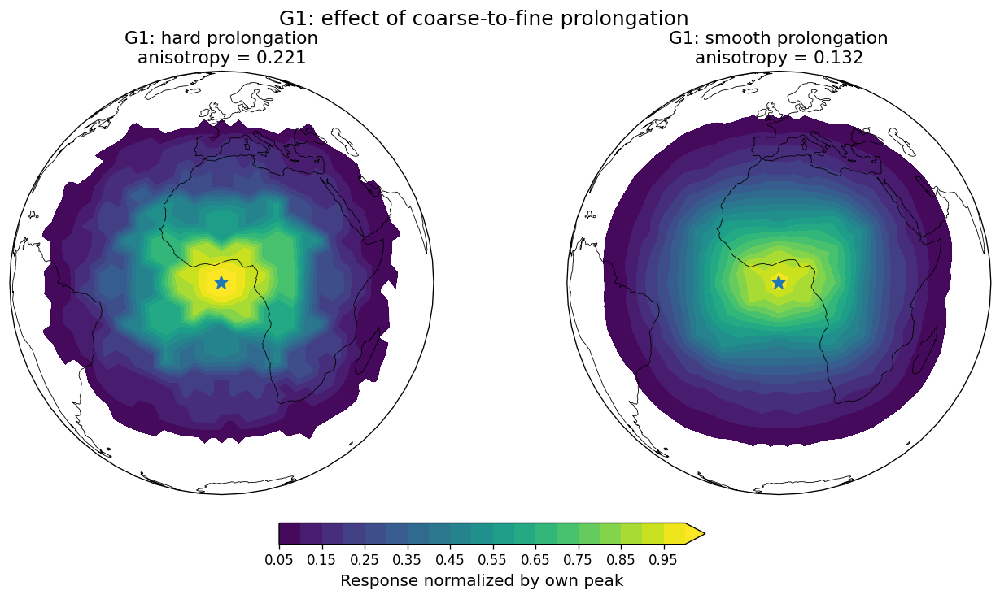

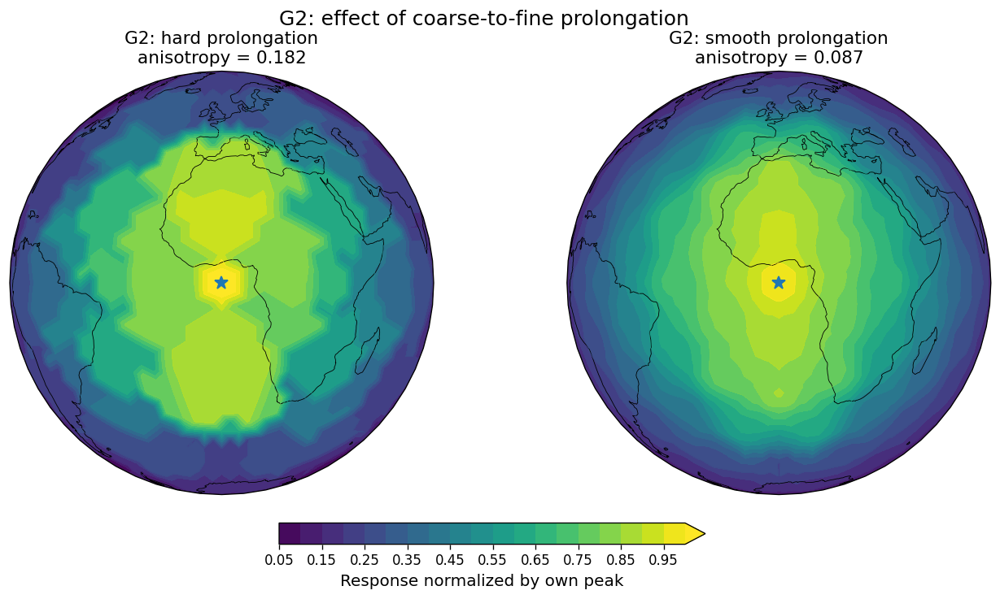

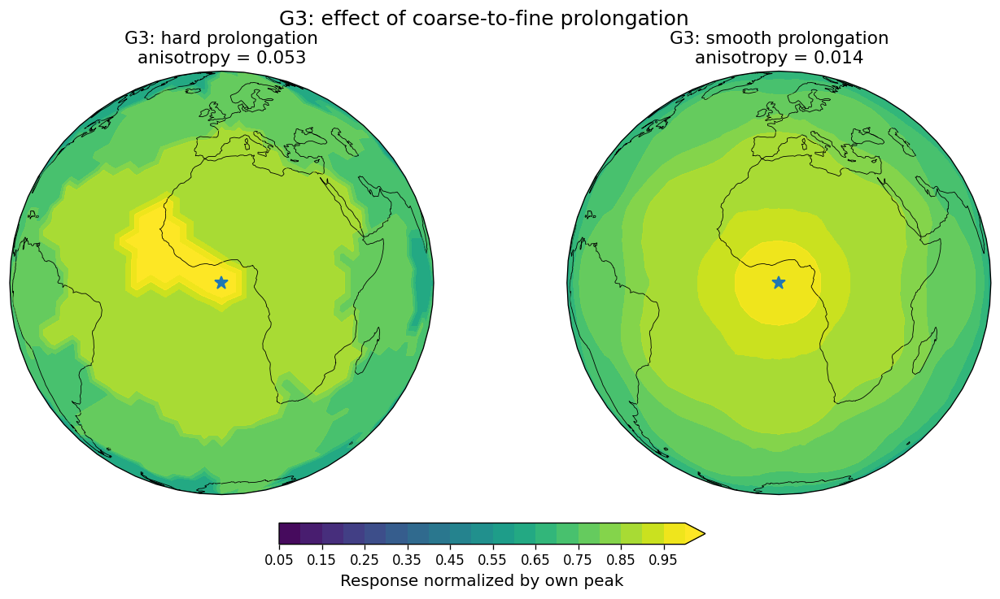

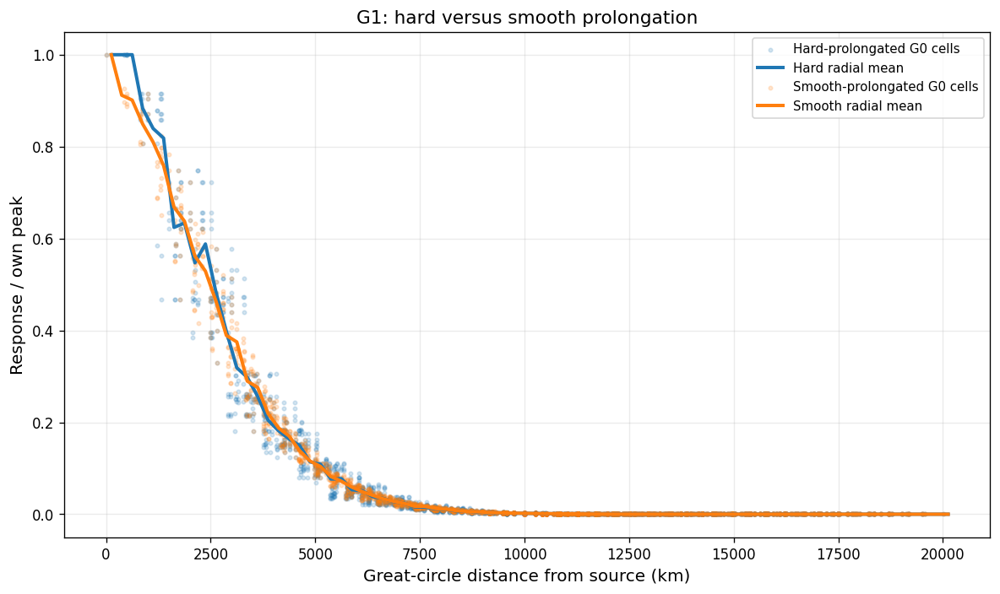

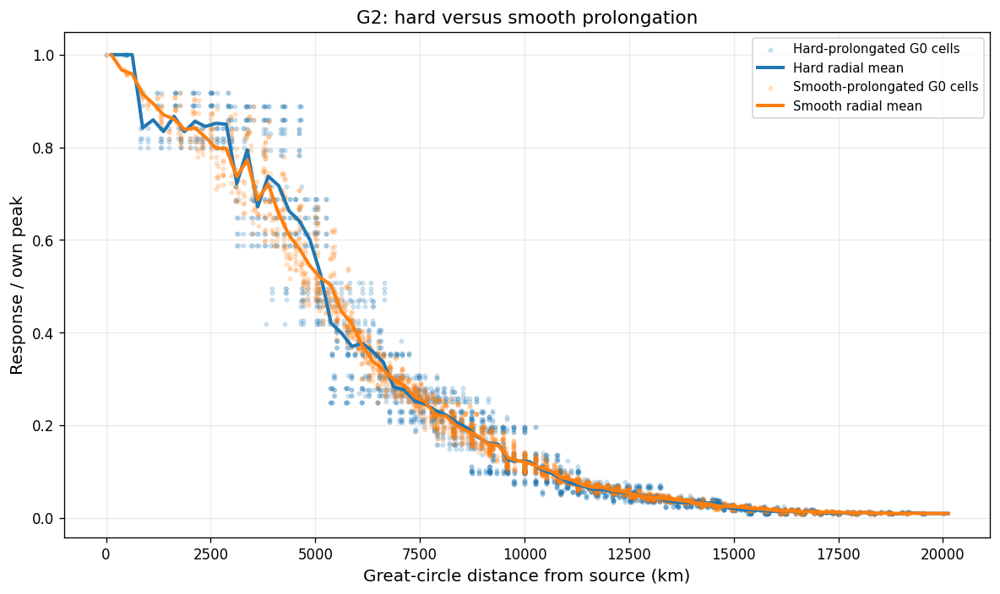

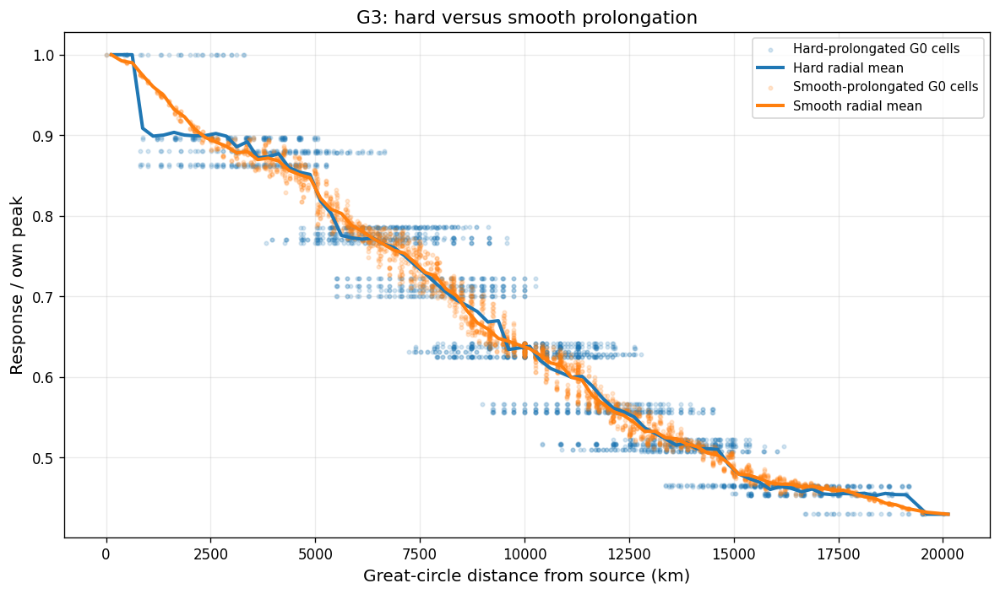

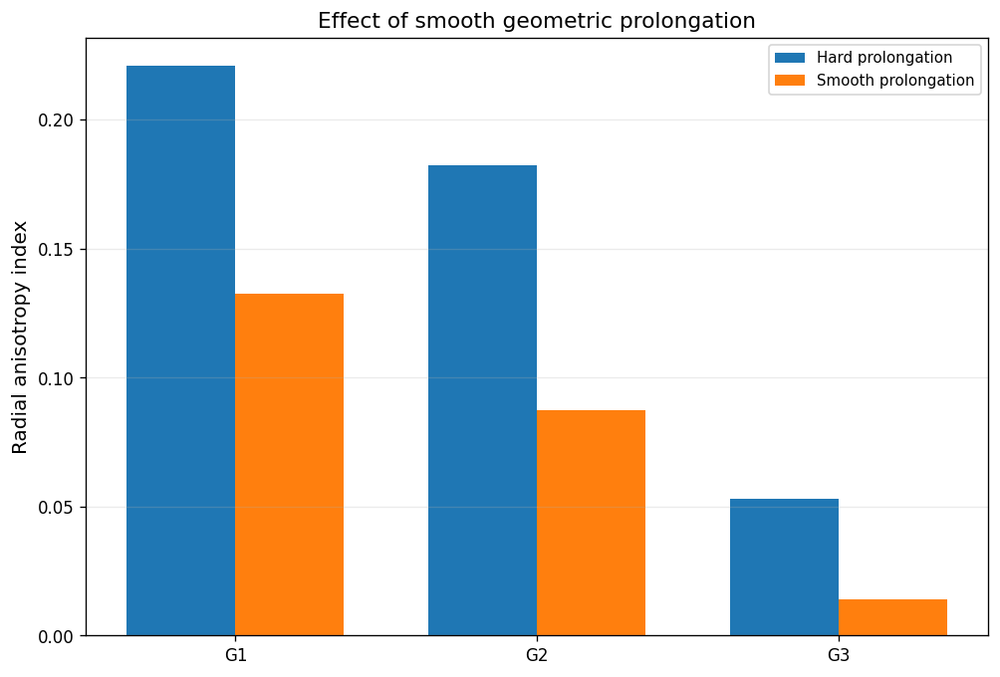



EXPERIMENT COMPLETE

Saved diagnostic data:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_selfcontained_calibration/hard_vs_smooth_prolongation_diagnostic.npz

Most important plots:
  hard_vs_smooth_G1
  hard_vs_smooth_G2
  hard_vs_smooth_G3
  hard_vs_smooth_anisotropy_summary

Interpretation:
If smooth prolongation substantially lowers the anisotropy index and removes the polygonal/banded structure, hard prolongation is a major source of the problem.
If strong anisotropy remains after smooth prolongation, the native coarse-grid filtering/operator must also be examined.


In [ ]:
# ======================================================================
# EXPERIMENT:
# HARD vs SMOOTH GEOMETRIC PROLONGATION
#
# Uses variables already created by the successful self-contained run.
#
# Compares:
#     G1 -> G0
#     G2 -> G0
#     G3 -> G0
#
# Native coarse-grid GGF responses are NOT changed.
#
# Existing hard prolongation:
#     b1 = P01 @ native1
#     b2 = P02 @ native2
#     b3 = P03 @ native3
#
# New smooth prolongation:
#     inverse-distance interpolation from nearby coarse-grid centers
#     on the sphere.
#
# Diagnostics:
#   1. Hard vs smooth orthographic maps
#   2. Hard vs smooth radial scatter
#   3. RMS radius
#   4. Integral conservation
#   5. Quantitative radial anisotropy
#
# IMPORTANT:
# Smooth interpolation is normalized to preserve constants.
# After interpolation, a single global scaling restores the exact
# area integral. This scaling does NOT alter spatial shape.
# ======================================================================


import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree


# ======================================================================
# 1. CHECK THAT THE PREVIOUS RUN IS STILL IN MEMORY
# ======================================================================

required_variables = [
    "xyz0",
    "xyz1",
    "xyz2",
    "xyz3",
    "area0",
    "native1",
    "native2",
    "native3",
    "b1",
    "b2",
    "b3",
    "distance0_m",
    "distance0_km",
    "lon0",
    "lat0",
    "source_lon",
    "source_lat",
    "projection",
    "OUTDIR"
]


missing = [
    name
    for name in required_variables
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "The previous MGGF run is no longer in memory.\n"
        "Missing variables:\n"
        + "\n".join(missing)
        + "\n\nRun the main self-contained MGGF script first."
    )


print("=" * 78)
print("HARD vs SMOOTH PROLONGATION EXPERIMENT")
print("=" * 78)

print("\nPrevious MGGF variables found successfully.")


# ======================================================================
# 2. NORMALIZE SPHERICAL COORDINATES
# ======================================================================

def unit_xyz(xyz):

    xyz = np.asarray(
        xyz,
        dtype=np.float64
    )

    return (
        xyz
        /
        np.linalg.norm(
            xyz,
            axis=1,
            keepdims=True
        )
    )


X0 = unit_xyz(xyz0)

X1 = unit_xyz(xyz1)

X2 = unit_xyz(xyz2)

X3 = unit_xyz(xyz3)


# ======================================================================
# 3. SMOOTH SPHERICAL INTERPOLATION
#
# For each G0 point:
#
#   - find K nearest coarse-grid centers
#   - calculate great-circle angular distances
#   - interpolate with inverse-distance weights
#
# This is NOT proposed yet as the final MGGF prolongation.
# It is a controlled diagnostic:
#
# "Does replacing hard parent injection by smooth geometric
#  interpolation substantially improve isotropy?"
# ======================================================================

def smooth_spherical_prolongation(
    xyz_coarse,
    field_coarse,
    xyz_fine,
    k_neighbors=6,
    power=2.0
):

    Xc = unit_xyz(
        xyz_coarse
    )

    Xf = unit_xyz(
        xyz_fine
    )

    field_coarse = np.asarray(
        field_coarse,
        dtype=np.float64
    )


    # ----------------------------------------------------------
    # Nearest-neighbor search in 3-D Cartesian coordinates.
    #
    # On the unit sphere, Euclidean chord distance is monotonic
    # with great-circle distance.
    # ----------------------------------------------------------

    tree = cKDTree(
        Xc
    )


    k_use = min(
        k_neighbors,
        len(Xc)
    )


    chord_distance, index = tree.query(
        Xf,
        k=k_use
    )


    if k_use == 1:

        chord_distance = (
            chord_distance[:, None]
        )

        index = (
            index[:, None]
        )


    # ----------------------------------------------------------
    # Convert chord distance to angular distance.
    #
    # chord = 2 sin(theta/2)
    # ----------------------------------------------------------

    angular_distance = (
        2.0
        *
        np.arcsin(
            np.clip(
                0.5
                *
                chord_distance,
                0.0,
                1.0
            )
        )
    )


    result = np.zeros(
        len(Xf),
        dtype=np.float64
    )


    exact_tolerance = 1.0e-12


    for i in range(
        len(Xf)
    ):

        d = (
            angular_distance[i]
        )

        ind = (
            index[i]
        )


        # ------------------------------------------------------
        # Fine point coincides with a coarse point.
        # Preserve that value exactly.
        # ------------------------------------------------------

        exact = np.where(
            d < exact_tolerance
        )[0]


        if len(exact) > 0:

            result[i] = (
                field_coarse[
                    ind[
                        exact[0]
                    ]
                ]
            )

            continue


        # ------------------------------------------------------
        # Inverse angular-distance interpolation
        # ------------------------------------------------------

        w = (
            1.0
            /
            np.maximum(
                d,
                1.0e-12
            )**power
        )


        w = (
            w
            /
            np.sum(w)
        )


        result[i] = np.dot(
            w,
            field_coarse[ind]
        )


    return result


# ======================================================================
# 4. EXACT-INTEGRAL RESCALING
#
# Smooth interpolation preserves constants because interpolation weights
# sum to one, but it does not automatically preserve the area integral.
#
# For this diagnostic we restore the exact integral with ONE scalar.
#
# This does not change the shape or anisotropy.
# ======================================================================

def restore_integral(
    field,
    area,
    target_integral=1.0
):

    current_integral = float(
        np.dot(
            area,
            field
        )
    )


    if current_integral <= 0.0:

        raise RuntimeError(
            "Interpolated field has nonpositive integral."
        )


    return (
        field
        *
        (
            target_integral
            /
            current_integral
        )
    )


# ======================================================================
# 5. CONSTRUCT SMOOTH G1/G2/G3 RESPONSES ON G0
# ======================================================================

print("\nConstructing smooth G1 -> G0 response...")

b1_smooth_raw = smooth_spherical_prolongation(
    X1,
    native1,
    X0,
    k_neighbors=6,
    power=2.0
)

b1_smooth = restore_integral(
    b1_smooth_raw,
    area0
)


print("Constructing smooth G2 -> G0 response...")

b2_smooth_raw = smooth_spherical_prolongation(
    X2,
    native2,
    X0,
    k_neighbors=6,
    power=2.0
)

b2_smooth = restore_integral(
    b2_smooth_raw,
    area0
)


print("Constructing smooth G3 -> G0 response...")

b3_smooth_raw = smooth_spherical_prolongation(
    X3,
    native3,
    X0,
    k_neighbors=6,
    power=2.0
)

b3_smooth = restore_integral(
    b3_smooth_raw,
    area0
)


print("Smooth responses completed.")


# ======================================================================
# 6. BASIC MOMENTS
# ======================================================================

def response_diagnostics(
    field
):

    field = np.asarray(
        field,
        dtype=np.float64
    )


    integral = float(
        area0
        @ field
    )


    M2 = float(
        area0
        @ (
            distance0_m**2
            *
            field
        )
    ) / integral


    rms_km = (
        np.sqrt(
            max(
                M2,
                0.0
            )
        )
        /
        1000.0
    )


    return (
        integral,
        rms_km
    )


# ======================================================================
# 7. RADIAL ANISOTROPY DIAGNOSTIC
#
# We measure scatter of cell values around the area-weighted radial mean.
#
# Smaller = more radially symmetric.
# ======================================================================

BIN_WIDTH_KM_TEST = 250.0


bins_test = np.arange(
    0.0,
    np.max(distance0_km)
    +
    BIN_WIDTH_KM_TEST,
    BIN_WIDTH_KM_TEST
)


bin_center_test = (
    0.5
    *
    (
        bins_test[:-1]
        +
        bins_test[1:]
    )
)


def radial_profile_and_anisotropy(
    field
):

    field = np.asarray(
        field,
        dtype=np.float64
    )


    radial_mean = np.full(
        len(bin_center_test),
        np.nan
    )


    radial_std = np.full(
        len(bin_center_test),
        np.nan
    )


    for ib in range(
        len(bin_center_test)
    ):

        mask = (
            (
                distance0_km
                >=
                bins_test[ib]
            )
            &
            (
                distance0_km
                <
                bins_test[ib + 1]
            )
        )


        if np.any(mask):

            a = (
                area0[mask]
            )

            f = (
                field[mask]
            )


            abar = (
                np.sum(
                    a * f
                )
                /
                np.sum(a)
            )


            radial_mean[ib] = (
                abar
            )


            radial_std[ib] = np.sqrt(
                np.sum(
                    a
                    *
                    (
                        f - abar
                    )**2
                )
                /
                np.sum(a)
            )


    # ----------------------------------------------------------
    # Scalar anisotropy index
    #
    # Only use region where radial mean exceeds 5% of peak.
    # ----------------------------------------------------------

    peak = np.max(
        field
    )


    good = (
        np.isfinite(radial_mean)
        &
        np.isfinite(radial_std)
        &
        (
            radial_mean
            >
            0.05 * peak
        )
    )


    if not np.any(good):

        scalar_anisotropy = np.nan

    else:

        scalar_anisotropy = np.sqrt(
            np.mean(
                (
                    radial_std[good]
                    /
                    radial_mean[good]
                )**2
            )
        )


    return (
        radial_mean,
        radial_std,
        scalar_anisotropy
    )


# ======================================================================
# 8. PRINT HARD vs SMOOTH NUMERICAL COMPARISON
# ======================================================================

cases = [
    (
        "G1",
        b1,
        b1_smooth
    ),
    (
        "G2",
        b2,
        b2_smooth
    ),
    (
        "G3",
        b3,
        b3_smooth
    )
]


print("\n")
print("=" * 90)
print("HARD vs SMOOTH NUMERICAL COMPARISON")
print("=" * 90)


summary_results = {}


for (
    name,
    hard_field,
    smooth_field
) in cases:

    I_hard, RMS_hard = response_diagnostics(
        hard_field
    )

    I_smooth, RMS_smooth = response_diagnostics(
        smooth_field
    )


    (
        mean_hard,
        std_hard,
        anis_hard
    ) = radial_profile_and_anisotropy(
        hard_field
    )


    (
        mean_smooth,
        std_smooth,
        anis_smooth
    ) = radial_profile_and_anisotropy(
        smooth_field
    )


    improvement = (
        100.0
        *
        (
            anis_hard
            -
            anis_smooth
        )
        /
        anis_hard
    )


    summary_results[name] = {
        "I_hard": I_hard,
        "I_smooth": I_smooth,
        "RMS_hard": RMS_hard,
        "RMS_smooth": RMS_smooth,
        "anis_hard": anis_hard,
        "anis_smooth": anis_smooth,
        "improvement_percent": improvement
    }


    print(
        f"\n{name}"
    )

    print(
        f"  HARD   integral   = {I_hard:.12f}"
    )

    print(
        f"  SMOOTH integral   = {I_smooth:.12f}"
    )

    print(
        f"  HARD   RMS radius = {RMS_hard:9.3f} km"
    )

    print(
        f"  SMOOTH RMS radius = {RMS_smooth:9.3f} km"
    )

    print(
        f"  HARD   anisotropy = {anis_hard:.6f}"
    )

    print(
        f"  SMOOTH anisotropy = {anis_smooth:.6f}"
    )

    print(
        f"  anisotropy change = {improvement:+.2f}% improvement"
    )


# ======================================================================
# 9. HARD vs SMOOTH ORTHOGRAPHIC MAPS
#
# Each hard/smooth pair uses its own peak normalization.
# This is a SHAPE diagnostic only.
# ======================================================================

levels_compare = np.linspace(
    0.05,
    1.0,
    20
)


for (
    name,
    hard_field,
    smooth_field
) in cases:

    hard_plot = (
        hard_field
        /
        np.max(hard_field)
    )


    smooth_plot = (
        smooth_field
        /
        np.max(smooth_field)
    )


    fig = plt.figure(
        figsize=(
            13.5,
            6.3
        )
    )


    # ----------------------------------------------------------
    # Hard prolongation
    # ----------------------------------------------------------

    ax1 = fig.add_subplot(
        1,
        2,
        1,
        projection=projection
    )


    ax1.set_global()

    ax1.coastlines(
        linewidth=0.5
    )


    cf1 = ax1.tricontourf(
        lon0,
        lat0,
        hard_plot,
        levels=levels_compare,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax1.tricontour(
        lon0,
        lat0,
        hard_plot,
        levels=levels_compare[::2],
        linewidths=0.35,
        transform=ccrs.PlateCarree()
    )


    ax1.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )


    ax1.set_title(
        f"{name}: hard prolongation"
        "\n"
        f"anisotropy = "
        f"{summary_results[name]['anis_hard']:.3f}"
    )


    # ----------------------------------------------------------
    # Smooth prolongation
    # ----------------------------------------------------------

    ax2 = fig.add_subplot(
        1,
        2,
        2,
        projection=projection
    )


    ax2.set_global()

    ax2.coastlines(
        linewidth=0.5
    )


    cf2 = ax2.tricontourf(
        lon0,
        lat0,
        smooth_plot,
        levels=levels_compare,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax2.tricontour(
        lon0,
        lat0,
        smooth_plot,
        levels=levels_compare[::2],
        linewidths=0.35,
        transform=ccrs.PlateCarree()
    )


    ax2.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )


    ax2.set_title(
        f"{name}: smooth prolongation"
        "\n"
        f"anisotropy = "
        f"{summary_results[name]['anis_smooth']:.3f}"
    )


    cbar = fig.colorbar(
        cf2,
        ax=[
            ax1,
            ax2
        ],
        orientation="horizontal",
        fraction=0.045,
        pad=0.06,
        shrink=0.75
    )


    cbar.set_label(
        "Response normalized by own peak"
    )


    fig.suptitle(
        f"{name}: effect of coarse-to-fine prolongation",
        fontsize=15
    )


    fig.savefig(
        OUTDIR
        /
        f"hard_vs_smooth_{name}.pdf",
        bbox_inches="tight"
    )


    fig.savefig(
        OUTDIR
        /
        f"hard_vs_smooth_{name}.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# ======================================================================
# 10. HARD vs SMOOTH RADIAL SCATTER
# ======================================================================

sort_index = np.argsort(
    distance0_km
)


for (
    name,
    hard_field,
    smooth_field
) in cases:

    hard_peak = np.max(
        hard_field
    )

    smooth_peak = np.max(
        smooth_field
    )


    hard_norm = (
        hard_field
        /
        hard_peak
    )


    smooth_norm = (
        smooth_field
        /
        smooth_peak
    )


    (
        mean_hard,
        std_hard,
        _
    ) = radial_profile_and_anisotropy(
        hard_norm
    )


    (
        mean_smooth,
        std_smooth,
        _
    ) = radial_profile_and_anisotropy(
        smooth_norm
    )


    good_hard = np.isfinite(
        mean_hard
    )


    good_smooth = np.isfinite(
        mean_smooth
    )


    # ----------------------------------------------------------
    # Hard
    # ----------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            10.0,
            6.0
        )
    )


    ax.scatter(
        distance0_km,
        hard_norm,
        s=7,
        alpha=0.18,
        label="Hard-prolongated G0 cells"
    )


    ax.plot(
        bin_center_test[
            good_hard
        ],
        mean_hard[
            good_hard
        ],
        linewidth=2.4,
        label="Hard radial mean"
    )


    ax.scatter(
        distance0_km,
        smooth_norm,
        s=7,
        alpha=0.18,
        label="Smooth-prolongated G0 cells"
    )


    ax.plot(
        bin_center_test[
            good_smooth
        ],
        mean_smooth[
            good_smooth
        ],
        linewidth=2.4,
        label="Smooth radial mean"
    )


    ax.set_xlabel(
        "Great-circle distance from source (km)"
    )


    ax.set_ylabel(
        "Response / own peak"
    )


    ax.set_title(
        f"{name}: hard versus smooth prolongation"
    )


    ax.grid(
        True,
        alpha=0.25
    )


    ax.legend()


    fig.tight_layout()


    fig.savefig(
        OUTDIR
        /
        f"hard_vs_smooth_radial_{name}.pdf",
        bbox_inches="tight"
    )


    fig.savefig(
        OUTDIR
        /
        f"hard_vs_smooth_radial_{name}.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# ======================================================================
# 11. ANISOTROPY SUMMARY PLOT
# ======================================================================

generation_names = [
    "G1",
    "G2",
    "G3"
]


hard_anis = np.array(
    [
        summary_results[name][
            "anis_hard"
        ]
        for name in generation_names
    ]
)


smooth_anis = np.array(
    [
        summary_results[name][
            "anis_smooth"
        ]
        for name in generation_names
    ]
)


x = np.arange(
    len(
        generation_names
    )
)


width = 0.36


fig, ax = plt.subplots(
    figsize=(
        8.5,
        5.8
    )
)


ax.bar(
    x - width/2,
    hard_anis,
    width,
    label="Hard prolongation"
)


ax.bar(
    x + width/2,
    smooth_anis,
    width,
    label="Smooth prolongation"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    generation_names
)


ax.set_ylabel(
    "Radial anisotropy index"
)


ax.set_title(
    "Effect of smooth geometric prolongation"
)


ax.grid(
    axis="y",
    alpha=0.25
)


ax.legend()


fig.tight_layout()


fig.savefig(
    OUTDIR
    /
    "hard_vs_smooth_anisotropy_summary.pdf",
    bbox_inches="tight"
)


fig.savefig(
    OUTDIR
    /
    "hard_vs_smooth_anisotropy_summary.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 12. SAVE RESPONSES
# ======================================================================

save_file = (
    OUTDIR
    /
    "hard_vs_smooth_prolongation_diagnostic.npz"
)


np.savez(
    save_file,

    b1_hard=b1,
    b1_smooth=b1_smooth,

    b2_hard=b2,
    b2_smooth=b2_smooth,

    b3_hard=b3,
    b3_smooth=b3_smooth,

    anis_G1_hard=
        summary_results["G1"]["anis_hard"],

    anis_G1_smooth=
        summary_results["G1"]["anis_smooth"],

    anis_G2_hard=
        summary_results["G2"]["anis_hard"],

    anis_G2_smooth=
        summary_results["G2"]["anis_smooth"],

    anis_G3_hard=
        summary_results["G3"]["anis_hard"],

    anis_G3_smooth=
        summary_results["G3"]["anis_smooth"]
)


print("\n")
print("=" * 78)
print("EXPERIMENT COMPLETE")
print("=" * 78)


print(
    "\nSaved diagnostic data:"
)

print(
    save_file
)


print(
    "\nMost important plots:"
)

print(
    "  hard_vs_smooth_G1"
)

print(
    "  hard_vs_smooth_G2"
)

print(
    "  hard_vs_smooth_G3"
)

print(
    "  hard_vs_smooth_anisotropy_summary"
)


print(
    "\nInterpretation:"
)

print(
    "If smooth prolongation substantially lowers the anisotropy index "
    "and removes the polygonal/banded structure, hard prolongation is "
    "a major source of the problem."
)

print(
    "If strong anisotropy remains after smooth prolongation, the native "
    "coarse-grid filtering/operator must also be examined."
)

# Up/Down sending - Test1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 37.1 MB/s eta 0:00:00
G0 <-> G1 IMPULSE TRANSFER DIAGNOSTIC

Output directory:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_transfer_diagnostics/G0_G1_impulse_test

Grid sizes:
  G0 = 2562
  G1 = 642

G1 graph:
  edges = 1920
  degree min/max = 5 6

G1 hierarchy/geometric area RMS relative difference = 0.4719896174952472

TRANSFER IDENTITIES
  P 1 error       = 0.000e+00
  R 1 error       = 3.331e-16
  area error      = 0.000e+00
  adjoint error   = 3.277e-15

SOURCE
  G0 index = 38
  longitude = 0.0
  latitude  = 0.0
  area integral = 1.0

UP-SENDING G0 -> G1
  parent G1 cell = 38
  G0 integral = 1.0
  G1 integral = 0.9999999999999999
  nonzero G1 cells = 1

ROUND TRIP WITHOUT FILTERING
  integral = 0.9999999999999998
  number of nonzero G0 cells = 7
  child cells receiving parent value = [  38 2120 2122 2165 2167 2483 2513]

FILTERED ROUND TRIP
  Gamma = 14.0
  p = 5
  G1 integral after filtering = 0.5669302711338275
  G0 integral af

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


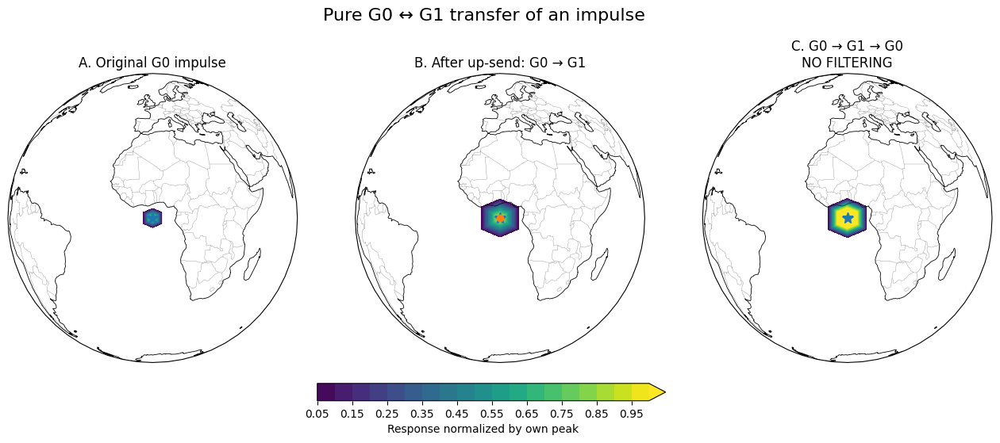

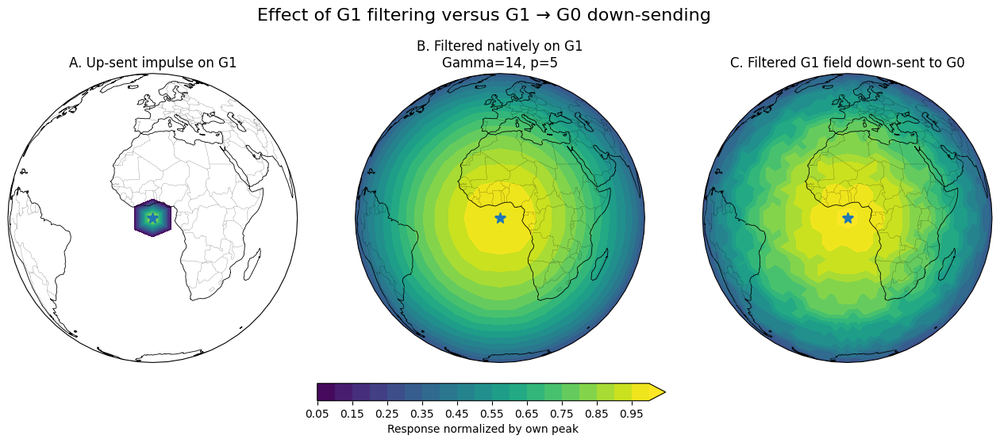


SOURCE-PARENT CHILDREN
  G1 parent = 38
  number of G0 children = 7
  G0 children = [  38 2120 2122 2165 2167 2483 2513]


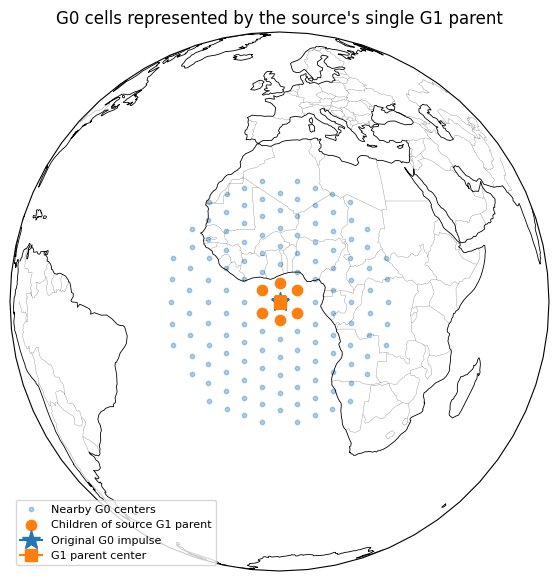

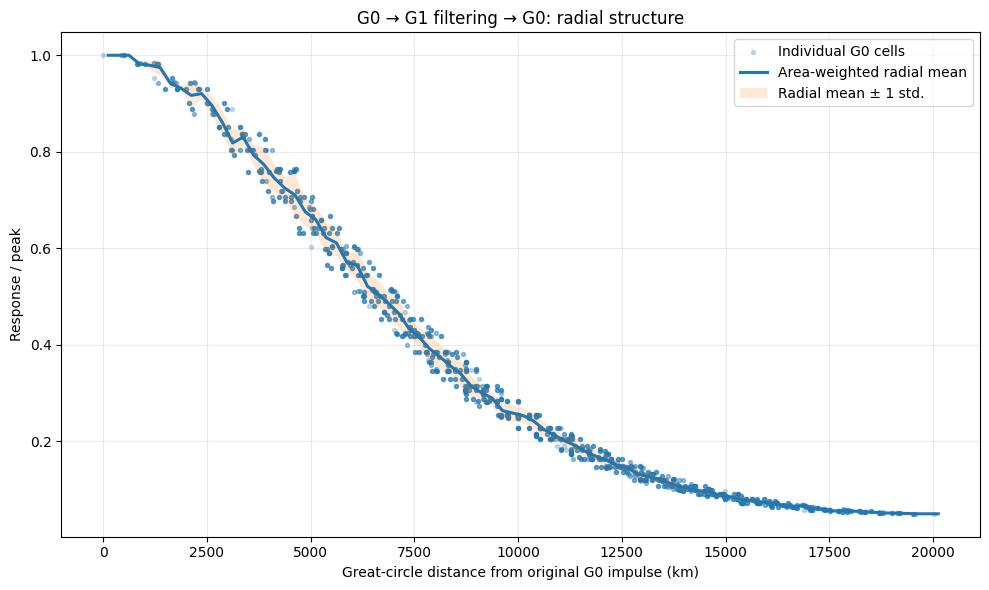



G0 <-> G1 TRANSFER TEST COMPLETE

No-filter experiment:
  delta0 -> R10 -> delta1 -> P01 -> delta0_roundtrip

Filtered experiment:
  delta0 -> R10 -> G1 filter -> P01 -> delta0_filtered_roundtrip

Important outputs:
  G0_G1_roundtrip_NO_FILTER
  G0_G1_roundtrip_WITH_FILTER
  source_G1_parent_children
  G0_G1_filtered_roundtrip_radial

Output directory:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_transfer_diagnostics/G0_G1_impulse_test


In [ ]:
# ======================================================================
# G0 <-> G1 IMPULSE TRANSFER TEST
#
# Purpose:
#   Diagnose ONLY multigrid communication between the genuine
#   icosahedral generations G0 and G1.
#
# Experiments:
#
#   A. Original impulse on G0
#
#          delta0
#
#   B. Up-send G0 -> G1
#
#          delta1 = R10 delta0
#
#   C. Up-send and immediately down-send, NO FILTERING
#
#          back0 = P01 R10 delta0
#
#   D. Up-send, filter on G1, then down-send
#
#          filtered0 = P01 B1 R10 delta0
#
# where
#
#          B1 = [ I + (Gamma/p) L1 ]^(-p)
#
# This test does NOT involve:
#   - Gaussian calibration
#   - G0.5
#   - G1.5
#   - G2
#   - G3
#
# ======================================================================


from pathlib import Path

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

import matplotlib.pyplot as plt

# --------------------------------------------------------------
# Cartopy
# --------------------------------------------------------------

try:

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

except ImportError:

    !pip -q install cartopy

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature


# ======================================================================
# 1. SETTINGS
# ======================================================================

ROOT = Path(
    "/content/drive/MyDrive/GLOBAL_SW_FV"
)

GRID = ROOT / "grid"

OUT = (
    ROOT
    /
    "mggf_transfer_diagnostics"
    /
    "G0_G1_impulse_test"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)


G0_FILE = (
    GRID
    /
    "global_hex_ico_grid_nsub4.npz"
)

G1_FILE = (
    GRID
    /
    "global_hex_ico_grid_nsub3.npz"
)

COMM_FILE = (
    GRID
    /
    "global_hex_ico_geometric_communication_v0.npz"
)


# --------------------------------------------------------------
# Same source we have been using
# --------------------------------------------------------------

SOURCE_G0 = 38


# --------------------------------------------------------------
# Filtering parameters
#
# First use exactly our present values.
# --------------------------------------------------------------

GAMMA = 14.0

P_ORDER = 5


EARTH_RADIUS_M = 6_371_220.0


print("=" * 88)
print("G0 <-> G1 IMPULSE TRANSFER DIAGNOSTIC")
print("=" * 88)

print("\nOutput directory:")
print(OUT)


# ======================================================================
# 2. LOAD GRID
# ======================================================================

def load_grid(path):

    z = np.load(
        path,
        allow_pickle=True
    )

    xyz = np.asarray(
        z["cell_center_xyz"],
        dtype=np.float64
    )

    xyz /= np.linalg.norm(
        xyz,
        axis=1
    )[:, None]


    area = np.asarray(
        z["cell_area"],
        dtype=np.float64
    )


    dual_cells = z["dual_cells"]


    # ----------------------------------------------------------
    # Longitude / latitude derived directly from xyz.
    # This avoids dependence on exact NPZ coordinate-key names.
    # ----------------------------------------------------------

    lon = np.degrees(
        np.arctan2(
            xyz[:, 1],
            xyz[:, 0]
        )
    )

    lat = np.degrees(
        np.arcsin(
            np.clip(
                xyz[:, 2],
                -1.0,
                1.0
            )
        )
    )


    return (
        xyz,
        area,
        dual_cells,
        lon,
        lat
    )


(
    xyz0,
    area0,
    dual0,
    lon0,
    lat0
) = load_grid(
    G0_FILE
)


(
    xyz1,
    area1_geom,
    dual1,
    lon1,
    lat1
) = load_grid(
    G1_FILE
)


N0 = len(
    area0
)

N1 = len(
    area1_geom
)


print("\nGrid sizes:")

print(
    "  G0 =",
    N0
)

print(
    "  G1 =",
    N1
)


# ======================================================================
# 3. CONSTRUCT G1 GRAPH
# ======================================================================

def edges_from_dual_cells(
    dual_cells
):

    edge_to_cells = {}


    for ci, poly in enumerate(
        dual_cells
    ):

        poly = np.asarray(
            poly,
            dtype=int
        )


        for k in range(
            len(poly)
        ):

            e = tuple(
                sorted(
                    (
                        int(
                            poly[k]
                        ),
                        int(
                            poly[
                                (k + 1)
                                %
                                len(poly)
                            ]
                        )
                    )
                )
            )


            edge_to_cells.setdefault(
                e,
                []
            ).append(
                ci
            )


    edges = []


    for cells in edge_to_cells.values():

        if len(cells) == 2:

            i, j = cells

            if i != j:

                edges.append(
                    (
                        min(i, j),
                        max(i, j)
                    )
                )


    return np.unique(
        np.asarray(
            edges,
            dtype=int
        ),
        axis=0
    )


def laplacian_from_edges(
    n,
    edges
):

    edges = np.asarray(
        edges,
        dtype=int
    )


    edges = edges[
        edges[:, 0]
        !=
        edges[:, 1]
    ]


    edges = np.unique(
        np.sort(
            edges,
            axis=1
        ),
        axis=0
    )


    i = edges[:, 0]

    j = edges[:, 1]


    degree = np.bincount(
        np.r_[
            i,
            j
        ],
        minlength=n
    )


    rows = np.r_[
        np.arange(n),
        i,
        j
    ]


    cols = np.r_[
        np.arange(n),
        j,
        i
    ]


    values = np.r_[
        degree.astype(float),
        -np.ones(len(i)),
        -np.ones(len(i))
    ]


    return sp.coo_matrix(
        (
            values,
            (
                rows,
                cols
            )
        ),
        shape=(
            n,
            n
        )
    ).tocsr()


edges1 = edges_from_dual_cells(
    dual1
)


L1 = laplacian_from_edges(
    N1,
    edges1
)


degree1 = np.asarray(
    (
        L1.diagonal()
    ),
    dtype=int
)


print("\nG1 graph:")

print(
    "  edges =",
    len(edges1)
)

print(
    "  degree min/max =",
    degree1.min(),
    degree1.max()
)


# ======================================================================
# 4. LOAD HISTORICAL G0 -> G1 PARENT MAP
# ======================================================================

comm = np.load(
    COMM_FILE,
    allow_pickle=True
)


parent01 = np.asarray(
    comm["parent01"],
    dtype=int
)


if len(parent01) != N0:

    raise RuntimeError(
        "parent01 has incorrect length."
    )


if (
    parent01.min() < 0
    or
    parent01.max() >= N1
):

    raise RuntimeError(
        "Invalid G0 -> G1 parent indices."
    )


# ======================================================================
# 5. IMPORTANT:
#    RECONSTRUCT HIERARCHY AREA EXACTLY FROM PARENT MAP
#
# For the transfer pair
#
#       R10 = A1^(-1) P01^T A0
#
# the consistent coarse area is
#
#       A1 = P01^T A0
#
# We calculate it explicitly here.
# ======================================================================

area1_hier = np.bincount(
    parent01,
    weights=area0,
    minlength=N1
)


# Compare against geometric G1 area.

area_difference = np.sqrt(
    np.mean(
        (
            (
                area1_hier
                -
                area1_geom
            )
            /
            area1_geom
        )**2
    )
)


print(
    "\nG1 hierarchy/geometric area RMS relative difference =",
    area_difference
)


# ======================================================================
# 6. BUILD HISTORICAL HARD P AND AREA-WEIGHTED R
# ======================================================================

P01 = sp.coo_matrix(
    (
        np.ones(N0),
        (
            np.arange(N0),
            parent01
        )
    ),
    shape=(
        N0,
        N1
    )
).tocsr()


R10 = (
    sp.diags(
        1.0
        /
        area1_hier
    )
    @
    P01.T
    @
    sp.diags(
        area0
    )
).tocsr()


# ======================================================================
# 7. VERIFY TRANSFER IDENTITIES
# ======================================================================

one0 = np.ones(
    N0
)

one1 = np.ones(
    N1
)


P_constant_error = np.max(
    np.abs(
        P01
        @
        one1
        -
        one0
    )
)


R_constant_error = np.max(
    np.abs(
        R10
        @
        one0
        -
        one1
    )
)


area_error = (
    np.linalg.norm(
        area1_hier
        -
        np.asarray(
            P01.T
            @
            area0
        ).ravel()
    )
    /
    np.linalg.norm(
        area1_hier
    )
)


# Weighted adjoint test

rng = np.random.default_rng(
    12345
)


x0_test = rng.normal(
    size=N0
)

x1_test = rng.normal(
    size=N1
)


lhs = np.dot(
    area0 * x0_test,
    P01 @ x1_test
)


rhs = np.dot(
    area1_hier * (R10 @ x0_test),
    x1_test
)


adjoint_error = (
    abs(
        lhs
        -
        rhs
    )
    /
    max(
        abs(lhs),
        abs(rhs),
        1.0e-30
    )
)


print("\nTRANSFER IDENTITIES")

print(
    "  P 1 error       =",
    f"{P_constant_error:.3e}"
)

print(
    "  R 1 error       =",
    f"{R_constant_error:.3e}"
)

print(
    "  area error      =",
    f"{area_error:.3e}"
)

print(
    "  adjoint error   =",
    f"{adjoint_error:.3e}"
)


# ======================================================================
# 8. CONSTRUCT AREA-UNIT IMPULSE ON G0
# ======================================================================

delta0 = np.zeros(
    N0,
    dtype=np.float64
)


delta0[
    SOURCE_G0
] = (
    1.0
    /
    area0[
        SOURCE_G0
    ]
)


source_xyz = xyz0[
    SOURCE_G0
]


source_lon = lon0[
    SOURCE_G0
]


source_lat = lat0[
    SOURCE_G0
]


print("\nSOURCE")

print(
    "  G0 index =",
    SOURCE_G0
)

print(
    "  longitude =",
    source_lon
)

print(
    "  latitude  =",
    source_lat
)

print(
    "  area integral =",
    np.dot(
        area0,
        delta0
    )
)


# ======================================================================
# 9. UP-SEND IMPULSE G0 -> G1
# ======================================================================

delta1 = (
    R10
    @
    delta0
)


integral_delta1 = np.dot(
    area1_hier,
    delta1
)


source_parent_G1 = int(
    parent01[
        SOURCE_G0
    ]
)


print("\nUP-SENDING G0 -> G1")

print(
    "  parent G1 cell =",
    source_parent_G1
)

print(
    "  G0 integral =",
    np.dot(
        area0,
        delta0
    )
)

print(
    "  G1 integral =",
    integral_delta1
)

print(
    "  nonzero G1 cells =",
    np.count_nonzero(
        np.abs(delta1)
        >
        1.0e-30
    )
)


# ======================================================================
# 10. DOWN-SEND WITHOUT FILTERING
#
#     delta0_roundtrip = P01 R10 delta0
# ======================================================================

delta0_roundtrip = (
    P01
    @
    delta1
)


integral_roundtrip = np.dot(
    area0,
    delta0_roundtrip
)


roundtrip_nonzero = np.where(
    np.abs(
        delta0_roundtrip
    )
    >
    1.0e-30
)[0]


print("\nROUND TRIP WITHOUT FILTERING")

print(
    "  integral =",
    integral_roundtrip
)

print(
    "  number of nonzero G0 cells =",
    len(
        roundtrip_nonzero
    )
)

print(
    "  child cells receiving parent value =",
    roundtrip_nonzero
)


# ======================================================================
# 11. FILTER ON G1
#
#     B1 = [I + (Gamma/p)L1]^(-p)
# ======================================================================

def apply_repeated(
    L,
    Gamma,
    p,
    x
):

    A = (
        sp.eye(
            L.shape[0],
            format="csr"
        )
        +
        (
            Gamma
            /
            float(p)
        )
        *
        L
    )


    solve = spla.factorized(
        A.tocsc()
    )


    y = np.asarray(
        x,
        dtype=np.float64
    ).copy()


    for _ in range(
        p
    ):

        y = solve(
            y
        )


    return y


delta1_filtered = apply_repeated(
    L1,
    GAMMA,
    P_ORDER,
    delta1
)


# ======================================================================
# 12. DOWN-SEND FILTERED G1 FIELD
# ======================================================================

delta0_filtered_roundtrip = (
    P01
    @
    delta1_filtered
)


# --------------------------------------------------------------
# IMPORTANT:
#
# The simple combinatorial L1 is constant-preserving, but with
# hierarchy areas it is not automatically conservative in the
# area-weighted sense.
#
# We therefore REPORT the integral rather than silently rescaling.
# This test is intended to expose the transfer/filter behavior.
# --------------------------------------------------------------

integral_filtered_G1 = np.dot(
    area1_hier,
    delta1_filtered
)


integral_filtered_G0 = np.dot(
    area0,
    delta0_filtered_roundtrip
)


print("\nFILTERED ROUND TRIP")

print(
    "  Gamma =",
    GAMMA
)

print(
    "  p =",
    P_ORDER
)

print(
    "  G1 integral after filtering =",
    integral_filtered_G1
)

print(
    "  G0 integral after down-send =",
    integral_filtered_G0
)


# ======================================================================
# 13. GREAT-CIRCLE DISTANCES
# ======================================================================

distance0_km = (
    EARTH_RADIUS_M
    *
    np.arccos(
        np.clip(
            xyz0
            @
            source_xyz,
            -1.0,
            1.0
        )
    )
    /
    1000.0
)


distance1_km = (
    EARTH_RADIUS_M
    *
    np.arccos(
        np.clip(
            xyz1
            @
            source_xyz,
            -1.0,
            1.0
        )
    )
    /
    1000.0
)


# ======================================================================
# 14. RMS RADIUS
# ======================================================================

def rms_radius_km(
    field,
    area,
    distance_km
):

    integral = np.dot(
        area,
        field
    )


    if integral <= 0.0:

        return np.nan


    m2 = (
        np.dot(
            area,
            field
            *
            distance_km**2
        )
        /
        integral
    )


    return np.sqrt(
        max(
            m2,
            0.0
        )
    )


rms_original = rms_radius_km(
    delta0,
    area0,
    distance0_km
)


rms_roundtrip = rms_radius_km(
    delta0_roundtrip,
    area0,
    distance0_km
)


rms_G1_filtered = rms_radius_km(
    delta1_filtered,
    area1_hier,
    distance1_km
)


rms_filtered_roundtrip = rms_radius_km(
    delta0_filtered_roundtrip,
    area0,
    distance0_km
)


print("\nRMS RADII")

print(
    f"  original G0 impulse          = {rms_original:10.3f} km"
)

print(
    f"  G0 -> G1 -> G0 no filter    = {rms_roundtrip:10.3f} km"
)

print(
    f"  filtered native G1          = {rms_G1_filtered:10.3f} km"
)

print(
    f"  filtered G1 -> G0           = {rms_filtered_roundtrip:10.3f} km"
)


# ======================================================================
# 15. NORMALIZATION FOR PLOTTING ONLY
#
# Each panel is divided by its OWN maximum.
#
# This is only to diagnose spatial shape.
# The actual fields above remain untouched.
# ======================================================================

def own_peak(
    field
):

    m = np.max(
        np.abs(
            field
        )
    )


    if m == 0.0:

        return field.copy()


    return (
        field
        /
        m
    )


plot_delta0 = own_peak(
    delta0
)


plot_delta1 = own_peak(
    delta1
)


plot_roundtrip = own_peak(
    delta0_roundtrip
)


plot_G1_filtered = own_peak(
    delta1_filtered
)


plot_filtered_roundtrip = own_peak(
    delta0_filtered_roundtrip
)


# ======================================================================
# 16. MAP HELPER
# ======================================================================

projection = ccrs.Orthographic(
    central_longitude=float(
        source_lon
    ),
    central_latitude=float(
        source_lat
    )
)


plot_levels = np.linspace(
    0.05,
    1.0,
    20
)


def setup_map(
    ax
):

    ax.set_global()


    ax.add_feature(
        cfeature.LAND,
        facecolor="none",
        edgecolor="none"
    )


    ax.coastlines(
        linewidth=0.6
    )


    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.25,
        alpha=0.5
    )


def contour_field(
    ax,
    lon,
    lat,
    field,
    title
):

    setup_map(
        ax
    )


    cf = ax.tricontourf(
        lon,
        lat,
        field,
        levels=plot_levels,
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax.tricontour(
        lon,
        lat,
        field,
        levels=plot_levels[::2],
        linewidths=0.35,
        transform=ccrs.PlateCarree()
    )


    ax.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )


    ax.set_title(
        title,
        fontsize=12
    )


    return cf


# ======================================================================
# 17. FIGURE 1:
#     PURE UP/DOWN TRANSFER — NO FILTERING
# ======================================================================

fig = plt.figure(
    figsize=(
        16,
        5.7
    )
)


ax1 = fig.add_subplot(
    1,
    3,
    1,
    projection=projection
)


cf = contour_field(
    ax1,
    lon0,
    lat0,
    plot_delta0,
    "A. Original G0 impulse"
)


ax2 = fig.add_subplot(
    1,
    3,
    2,
    projection=projection
)


cf = contour_field(
    ax2,
    lon1,
    lat1,
    plot_delta1,
    "B. After up-send: G0 → G1"
)


ax2.plot(
    lon1[
        source_parent_G1
    ],
    lat1[
        source_parent_G1
    ],
    marker="o",
    markersize=6,
    transform=ccrs.PlateCarree()
)


ax3 = fig.add_subplot(
    1,
    3,
    3,
    projection=projection
)


cf = contour_field(
    ax3,
    lon0,
    lat0,
    plot_roundtrip,
    "C. G0 → G1 → G0\nNO FILTERING"
)


cbar = fig.colorbar(
    cf,
    ax=[
        ax1,
        ax2,
        ax3
    ],
    orientation="horizontal",
    fraction=0.05,
    pad=0.06,
    shrink=0.72
)


cbar.set_label(
    "Response normalized by own peak"
)


fig.suptitle(
    "Pure G0 ↔ G1 transfer of an impulse",
    fontsize=16
)


fig.savefig(
    OUT
    /
    "G0_G1_roundtrip_NO_FILTER.pdf",
    bbox_inches="tight"
)


fig.savefig(
    OUT
    /
    "G0_G1_roundtrip_NO_FILTER.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 18. FIGURE 2:
#     G1 FILTERING AND DOWN-SENDING
# ======================================================================

fig = plt.figure(
    figsize=(
        16,
        5.7
    )
)


ax1 = fig.add_subplot(
    1,
    3,
    1,
    projection=projection
)


cf = contour_field(
    ax1,
    lon1,
    lat1,
    plot_delta1,
    "A. Up-sent impulse on G1"
)


ax2 = fig.add_subplot(
    1,
    3,
    2,
    projection=projection
)


cf = contour_field(
    ax2,
    lon1,
    lat1,
    plot_G1_filtered,
    (
        "B. Filtered natively on G1\n"
        f"Gamma={GAMMA:g}, p={P_ORDER}"
    )
)


ax3 = fig.add_subplot(
    1,
    3,
    3,
    projection=projection
)


cf = contour_field(
    ax3,
    lon0,
    lat0,
    plot_filtered_roundtrip,
    "C. Filtered G1 field down-sent to G0"
)


cbar = fig.colorbar(
    cf,
    ax=[
        ax1,
        ax2,
        ax3
    ],
    orientation="horizontal",
    fraction=0.05,
    pad=0.06,
    shrink=0.72
)


cbar.set_label(
    "Response normalized by own peak"
)


fig.suptitle(
    "Effect of G1 filtering versus G1 → G0 down-sending",
    fontsize=16
)


fig.savefig(
    OUT
    /
    "G0_G1_roundtrip_WITH_FILTER.pdf",
    bbox_inches="tight"
)


fig.savefig(
    OUT
    /
    "G0_G1_roundtrip_WITH_FILTER.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 19. FIGURE 3:
#     CHILDREN OF THE SOURCE'S G1 PARENT
#
# This is particularly important for understanding hard prolongation.
# ======================================================================

children = np.where(
    parent01
    ==
    source_parent_G1
)[0]


print("\nSOURCE-PARENT CHILDREN")

print(
    "  G1 parent =",
    source_parent_G1
)

print(
    "  number of G0 children =",
    len(children)
)

print(
    "  G0 children =",
    children
)


fig = plt.figure(
    figsize=(
        7.2,
        7.0
    )
)


ax = fig.add_subplot(
    1,
    1,
    1,
    projection=projection
)


setup_map(
    ax
)


# All nearby G0 centers

near = (
    distance0_km
    <
    3000.0
)


ax.scatter(
    lon0[
        near
    ],
    lat0[
        near
    ],
    s=10,
    alpha=0.35,
    transform=ccrs.PlateCarree(),
    label="Nearby G0 centers"
)


# Children of source parent

ax.scatter(
    lon0[
        children
    ],
    lat0[
        children
    ],
    s=55,
    marker="o",
    transform=ccrs.PlateCarree(),
    label="Children of source G1 parent"
)


# Original source

ax.plot(
    source_lon,
    source_lat,
    marker="*",
    markersize=14,
    transform=ccrs.PlateCarree(),
    label="Original G0 impulse"
)


# G1 parent

ax.plot(
    lon1[
        source_parent_G1
    ],
    lat1[
        source_parent_G1
    ],
    marker="s",
    markersize=9,
    transform=ccrs.PlateCarree(),
    label="G1 parent center"
)


ax.set_title(
    "G0 cells represented by the source's single G1 parent"
)


ax.legend(
    loc="lower left",
    fontsize=8
)


fig.savefig(
    OUT
    /
    "source_G1_parent_children.pdf",
    bbox_inches="tight"
)


fig.savefig(
    OUT
    /
    "source_G1_parent_children.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 20. RADIAL COMPARISON AFTER FILTERING
# ======================================================================

BIN_WIDTH_KM = 250.0


radial_edges = np.arange(
    0.0,
    np.max(
        distance0_km
    )
    +
    BIN_WIDTH_KM,
    BIN_WIDTH_KM
)


radial_center = (
    0.5
    *
    (
        radial_edges[:-1]
        +
        radial_edges[1:]
    )
)


def radial_stats(
    field
):

    field = own_peak(
        field
    )


    radial_mean = np.full(
        len(radial_center),
        np.nan
    )


    radial_std = np.full(
        len(radial_center),
        np.nan
    )


    for k in range(
        len(radial_center)
    ):

        mask = (
            (
                distance0_km
                >=
                radial_edges[k]
            )
            &
            (
                distance0_km
                <
                radial_edges[k + 1]
            )
        )


        if np.any(
            mask
        ):

            a = area0[
                mask
            ]

            f = field[
                mask
            ]


            fm = (
                np.sum(
                    a * f
                )
                /
                np.sum(a)
            )


            radial_mean[
                k
            ] = fm


            radial_std[
                k
            ] = np.sqrt(
                np.sum(
                    a
                    *
                    (
                        f - fm
                    )**2
                )
                /
                np.sum(a)
            )


    return (
        radial_mean,
        radial_std
    )


mean_filtered, std_filtered = radial_stats(
    delta0_filtered_roundtrip
)


good = np.isfinite(
    mean_filtered
)


fig, ax = plt.subplots(
    figsize=(
        10,
        6
    )
)


ax.scatter(
    distance0_km,
    own_peak(
        delta0_filtered_roundtrip
    ),
    s=8,
    alpha=0.25,
    label="Individual G0 cells"
)


ax.plot(
    radial_center[
        good
    ],
    mean_filtered[
        good
    ],
    linewidth=2.2,
    label="Area-weighted radial mean"
)


ax.fill_between(
    radial_center[
        good
    ],
    (
        mean_filtered[
            good
        ]
        -
        std_filtered[
            good
        ]
    ),
    (
        mean_filtered[
            good
        ]
        +
        std_filtered[
            good
        ]
    ),
    alpha=0.18,
    label="Radial mean ± 1 std."
)


ax.set_xlabel(
    "Great-circle distance from original G0 impulse (km)"
)


ax.set_ylabel(
    "Response / peak"
)


ax.set_title(
    "G0 → G1 filtering → G0: radial structure"
)


ax.grid(
    True,
    alpha=0.25
)


ax.legend()


fig.tight_layout()


fig.savefig(
    OUT
    /
    "G0_G1_filtered_roundtrip_radial.pdf",
    bbox_inches="tight"
)


fig.savefig(
    OUT
    /
    "G0_G1_filtered_roundtrip_radial.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 21. SAVE NUMERICAL RESULTS
# ======================================================================

np.savez(
    OUT
    /
    "G0_G1_impulse_transfer_diagnostic.npz",

    source_G0=np.array(
        SOURCE_G0
    ),

    source_parent_G1=np.array(
        source_parent_G1
    ),

    parent01=parent01,

    area0=area0,

    area1_hier=area1_hier,

    area1_geom=area1_geom,

    delta0=delta0,

    delta1=delta1,

    delta0_roundtrip=delta0_roundtrip,

    delta1_filtered=delta1_filtered,

    delta0_filtered_roundtrip=
        delta0_filtered_roundtrip,

    distance0_km=distance0_km,

    distance1_km=distance1_km,

    Gamma=np.array(
        GAMMA
    ),

    p=np.array(
        P_ORDER
    )
)


# ======================================================================
# 22. FINAL SUMMARY
# ======================================================================

print("\n")
print("=" * 88)
print("G0 <-> G1 TRANSFER TEST COMPLETE")
print("=" * 88)


print("\nNo-filter experiment:")

print(
    "  delta0"
    " -> R10 -> delta1"
    " -> P01 -> delta0_roundtrip"
)


print("\nFiltered experiment:")

print(
    "  delta0"
    " -> R10"
    " -> G1 filter"
    " -> P01"
    " -> delta0_filtered_roundtrip"
)


print("\nImportant outputs:")

print(
    "  G0_G1_roundtrip_NO_FILTER"
)

print(
    "  G0_G1_roundtrip_WITH_FILTER"
)

print(
    "  source_G1_parent_children"
)

print(
    "  G0_G1_filtered_roundtrip_radial"
)


print("\nOutput directory:")

print(
    OUT
)

# Up/Down sending - Test2

G0 -> G1 -> AREA-COMPATIBLE MGGF FILTER -> G0

Output directory:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_transfer_diagnostics/G0_G1_area_compatible_filter

Grid sizes:
  G0 = 2562
  G1 = 642

G1 hierarchy/geometric area RMS relative difference = 0.4719896174952472

G1 graph:
  edges = 1920
  degree min/max = 5.0 6.0

AREA-COMPATIBLE G1 OPERATOR
  Sinkhorn iterations = 223
  balance error       = 9.128e-14
  constant error      = 4.441e-16
  weighted adjoint    = 5.407e-17
  area^T L error      = 1.534e-16


INTEGRAL THROUGH THE COMPLETE PATH
G0 impulse                 : 1.000000000000000
after G0 -> G1 restriction : 1.000000000000000
after native G1 filtering  : 1.000000000000000
after G1 -> G0 prolongation: 1.000000000000000

Relative errors:
  restriction = 1.110e-16
  G1 filtering = 3.331e-16
  prolongation = 0.000e+00

RMS radius:
  native filtered G1 = 3592.001 km
  after down-send G0 = 3610.107 km


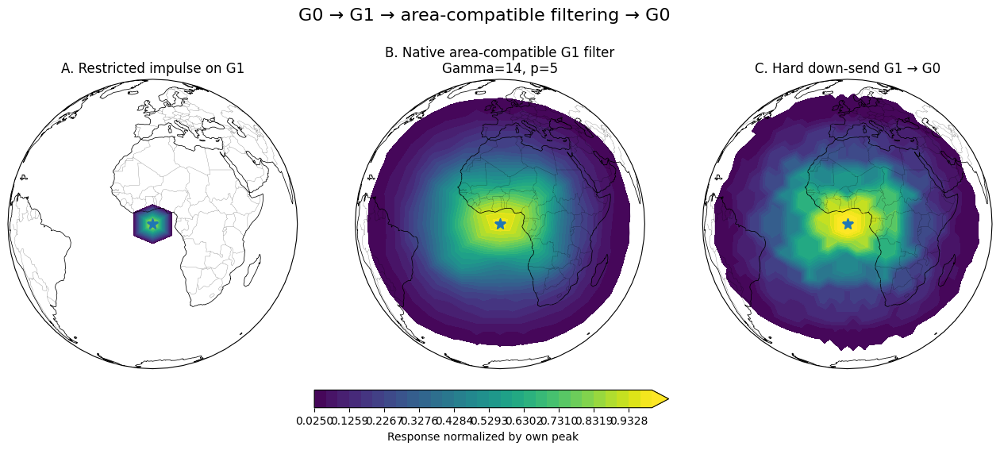

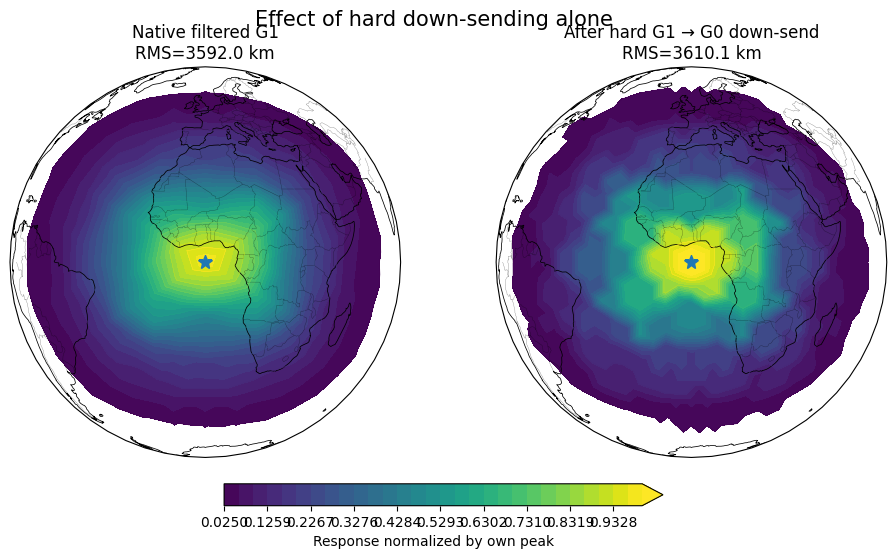

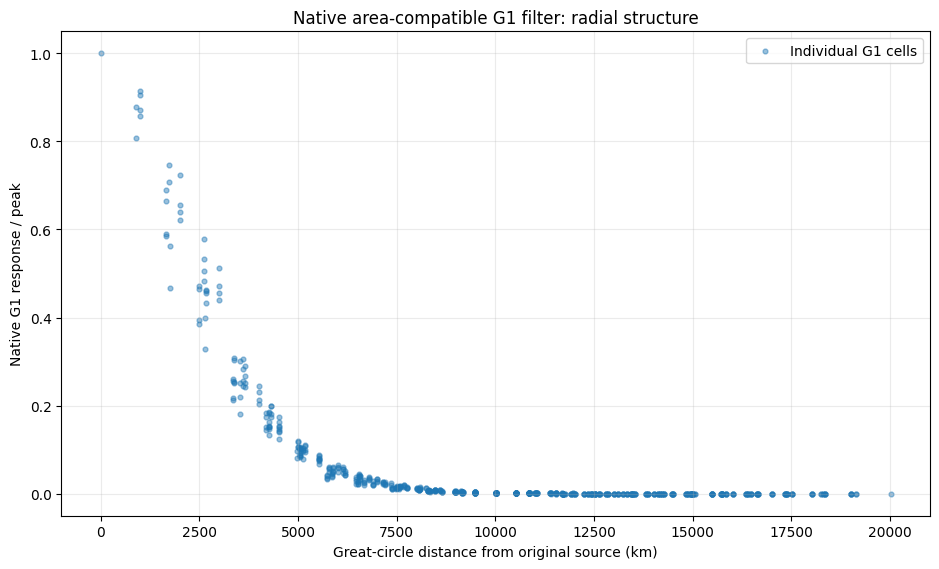



AREA-COMPATIBLE G0/G1 TEST COMPLETE

Path:
G0 impulse -> R10 -> area-compatible G1 filter -> P01 -> G0

Integral:
  initial G0        = 1.000000000000
  restricted G1    = 1.000000000000
  filtered G1      = 1.000000000000
  down-sent G0     = 1.000000000000

RMS radius:
  native G1        = 3592.001 km
  down-sent G0     = 3610.107 km

Most important figures:
  G0_G1_area_compatible_three_stage
  G1_native_vs_hard_downsend
  native_G1_area_compatible_radial

Output:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_transfer_diagnostics/G0_G1_area_compatible_filter


In [ ]:
# ================================================================
# G0 -> G1 -> AREA-COMPATIBLE FILTER -> G0
#
# PURPOSE
# ------
# Isolate three operations:
#
#   1. Up-send:
#          x1 = R10 delta0
#
#   2. Native G1 filtering with the ACTUAL MGGF operator:
#          y1 = [I + (Gamma/p)L1]^(-p) x1
#
#   3. Hard down-send:
#          y0 = P01 y1
#
# No calibration.
# No G0.5/G1.5.
# No G2/G3.
#
# ================================================================

from pathlib import Path
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# ------------------------------------------------
# Cartopy
# ------------------------------------------------
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    !pip -q install cartopy
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature


# ================================================================
# 1. SETTINGS
# ================================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

OUT = (
    ROOT
    / "mggf_transfer_diagnostics"
    / "G0_G1_area_compatible_filter"
)
OUT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"

COMM_FILE = (
    GRID
    / "global_hex_ico_geometric_communication_v0.npz"
)

SOURCE_G0 = 38

GAMMA = 14.0
P_ORDER = 5

EARTH_RADIUS_M = 6371000.0

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 20000


print("=" * 84)
print("G0 -> G1 -> AREA-COMPATIBLE MGGF FILTER -> G0")
print("=" * 84)

print("\nOutput directory:")
print(OUT)


# ================================================================
# 2. LOAD GRIDS
# ================================================================

g0 = np.load(G0_FILE, allow_pickle=True)
g1 = np.load(G1_FILE, allow_pickle=True)

xyz0 = np.asarray(
    g0["cell_center_xyz"],
    dtype=np.float64
)

xyz1 = np.asarray(
    g1["cell_center_xyz"],
    dtype=np.float64
)

xyz0 /= np.linalg.norm(
    xyz0,
    axis=1,
    keepdims=True
)

xyz1 /= np.linalg.norm(
    xyz1,
    axis=1,
    keepdims=True
)

area0 = np.asarray(
    g0["cell_area"],
    dtype=np.float64
)

area1_geom = np.asarray(
    g1["cell_area"],
    dtype=np.float64
)

dual1 = g1["dual_cells"]

n0 = len(area0)
n1 = len(area1_geom)

lon0 = np.degrees(
    np.arctan2(
        xyz0[:, 1],
        xyz0[:, 0]
    )
)

lat0 = np.degrees(
    np.arcsin(
        np.clip(
            xyz0[:, 2],
            -1.0,
            1.0
        )
    )
)

lon1 = np.degrees(
    np.arctan2(
        xyz1[:, 1],
        xyz1[:, 0]
    )
)

lat1 = np.degrees(
    np.arcsin(
        np.clip(
            xyz1[:, 2],
            -1.0,
            1.0
        )
    )
)

print("\nGrid sizes:")
print("  G0 =", n0)
print("  G1 =", n1)


# ================================================================
# 3. LOAD ORIGINAL G0 -> G1 PARENT MAP
# ================================================================

comm = np.load(
    COMM_FILE,
    allow_pickle=True
)

parent01 = np.asarray(
    comm["parent01"],
    dtype=np.int64
).ravel()

if len(parent01) != n0:
    raise RuntimeError(
        "parent01 length does not equal G0 size."
    )

if (
    np.min(parent01) < 0
    or
    np.max(parent01) >= n1
):
    raise RuntimeError(
        "Invalid parent01 indices."
    )


# ================================================================
# 4. BUILD ORIGINAL HARD P01 AND CONSERVATIVE R10
#
# area1 = P01^T area0
#
# R10 = A1^(-1) P01^T A0
# ================================================================

P01 = sp.coo_matrix(
    (
        np.ones(n0),
        (
            np.arange(n0),
            parent01
        )
    ),
    shape=(n0, n1)
).tocsr()

area1 = np.asarray(
    P01.T @ area0
).ravel()

R10 = (
    sp.diags(1.0 / area1)
    @ P01.T
    @ sp.diags(area0)
).tocsr()


area_difference = np.sqrt(
    np.mean(
        (
            (
                area1
                -
                area1_geom
            )
            /
            area1_geom
        )**2
    )
)

print(
    "\nG1 hierarchy/geometric area RMS relative difference =",
    area_difference
)


# ================================================================
# 5. CONSTRUCT G1 ADJACENCY
# ================================================================

def adjacency_from_dual_cells(dual_cells):

    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):

        poly = np.asarray(
            poly,
            dtype=np.int64
        ).ravel()

        for k in range(len(poly)):

            a = int(poly[k])
            b = int(
                poly[
                    (k + 1) % len(poly)
                ]
            )

            edge = tuple(
                sorted((a, b))
            )

            edge_to_cells.setdefault(
                edge,
                []
            ).append(ci)

    neighbors = [
        set()
        for _ in range(len(dual_cells))
    ]

    for cells in edge_to_cells.values():

        if len(cells) == 2:

            i, j = cells

            if i != j:

                neighbors[i].add(j)
                neighbors[j].add(i)

    edges = [
        (i, j)
        for i, nbrs in enumerate(neighbors)
        for j in nbrs
        if i < j
    ]

    edges = np.asarray(
        edges,
        dtype=np.int64
    )

    ii = np.concatenate(
        [
            edges[:, 0],
            edges[:, 1]
        ]
    )

    jj = np.concatenate(
        [
            edges[:, 1],
            edges[:, 0]
        ]
    )

    adjacency = sp.coo_matrix(
        (
            np.ones(len(ii)),
            (ii, jj)
        ),
        shape=(
            len(dual_cells),
            len(dual_cells)
        )
    ).tocsr()

    adjacency.setdiag(0.0)
    adjacency.eliminate_zeros()

    adjacency = (
        0.5
        *
        (
            adjacency
            +
            adjacency.T
        )
    ).tocsr()

    adjacency.eliminate_zeros()

    return adjacency


Adj1 = adjacency_from_dual_cells(
    dual1
)

degree1 = np.asarray(
    Adj1.sum(axis=1)
).ravel()

print("\nG1 graph:")
print(
    "  edges =",
    Adj1.nnz // 2
)
print(
    "  degree min/max =",
    degree1.min(),
    degree1.max()
)


# ================================================================
# 6. ACTUAL AREA-COMPATIBLE MGGF LAPLACIAN
#
# ahat = area / mean(area)
#
# W = diag(s) Adj diag(s)
#
# W 1 = ahat
#
# Q = diag(W1) - W
#
# L_A = diag(1/ahat) Q
#
# This is the operator used in our MGGF code.
# ================================================================

def build_area_compatible_laplacian(
    adjacency,
    area,
    name="G1"
):

    adjacency = (
        adjacency
        .tocsr()
        .astype(np.float64)
    )

    area = np.asarray(
        area,
        dtype=np.float64
    )

    n = len(area)

    ahat = (
        area
        /
        np.mean(area)
    )

    s = np.ones(
        n,
        dtype=np.float64
    )

    converged = False

    for iteration in range(
        SINKHORN_MAXITER
    ):

        adjacency_s = (
            adjacency @ s
        )

        if np.any(
            adjacency_s <= 0.0
        ):

            raise RuntimeError(
                f"{name}: invalid adjacency."
            )

        s_new = np.sqrt(
            s
            *
            ahat
            /
            adjacency_s
        )

        row_sum_new = (
            s_new
            *
            (
                adjacency
                @
                s_new
            )
        )

        rel_error = np.max(
            np.abs(
                row_sum_new
                -
                ahat
            )
            /
            np.maximum(
                ahat,
                1.0e-300
            )
        )

        s = s_new

        if rel_error < SINKHORN_TOL:

            converged = True
            break

    if not converged:

        raise RuntimeError(
            "G1 balancing did not converge."
        )

    Wedge = (
        sp.diags(s)
        @
        adjacency
        @
        sp.diags(s)
    ).tocsr()

    Wedge = (
        0.5
        *
        (
            Wedge
            +
            Wedge.T
        )
    ).tocsr()

    Wedge.eliminate_zeros()

    row_sum = np.asarray(
        Wedge
        @
        np.ones(n)
    ).ravel()

    Q = (
        sp.diags(row_sum)
        -
        Wedge
    ).tocsr()

    L_A = (
        sp.diags(
            1.0 / ahat
        )
        @
        Q
    ).tocsr()

    # ----------------------------------------------------------
    # Diagnostics
    # ----------------------------------------------------------

    balance_error = np.max(
        np.abs(
            row_sum
            -
            ahat
        )
        /
        np.maximum(
            ahat,
            1.0e-300
        )
    )

    constant_error = np.max(
        np.abs(
            L_A
            @
            np.ones(n)
        )
    )

    Ahat = sp.diags(
        ahat
    )

    adjoint_error = (
        spla.norm(
            Ahat @ L_A
            -
            L_A.T @ Ahat
        )
        /
        max(
            spla.norm(
                Ahat @ L_A
            ),
            1.0e-300
        )
    )

    # ----------------------------------------------------------
    # Conservation condition:
    #
    #      area^T L = 0
    # ----------------------------------------------------------

    conservation_vector = np.asarray(
        area
        @
        L_A
    ).ravel()

    conservation_error = (
        np.linalg.norm(
            conservation_vector
        )
        /
        max(
            np.linalg.norm(area),
            1.0e-300
        )
    )

    print(
        "\nAREA-COMPATIBLE G1 OPERATOR"
    )

    print(
        "  Sinkhorn iterations =",
        iteration + 1
    )

    print(
        "  balance error       =",
        f"{balance_error:.3e}"
    )

    print(
        "  constant error      =",
        f"{constant_error:.3e}"
    )

    print(
        "  weighted adjoint    =",
        f"{adjoint_error:.3e}"
    )

    print(
        "  area^T L error      =",
        f"{conservation_error:.3e}"
    )

    return L_A


L1 = build_area_compatible_laplacian(
    Adj1,
    area1,
    name="G1"
)


# ================================================================
# 7. REPEATED-RESOLVENT FILTER
#
# B1 = [ I + (Gamma/p)L1 ]^(-p)
# ================================================================

def repeated_resolvent(
    L_A,
    Gamma,
    x,
    p=P_ORDER
):

    system = (
        sp.eye(
            L_A.shape[0],
            format="csc"
        )
        +
        (
            Gamma
            /
            float(p)
        )
        *
        L_A.tocsc()
    )

    lu = spla.splu(
        system
    )

    y = np.asarray(
        x,
        dtype=np.float64
    ).copy()

    for _ in range(p):

        y = lu.solve(y)

    return y


# ================================================================
# 8. INITIAL G0 IMPULSE
# ================================================================

delta0 = np.zeros(
    n0,
    dtype=np.float64
)

delta0[SOURCE_G0] = (
    1.0
    /
    area0[SOURCE_G0]
)

source_xyz = xyz0[
    SOURCE_G0
]

source_lon = lon0[
    SOURCE_G0
]

source_lat = lat0[
    SOURCE_G0
]

I0 = float(
    area0 @ delta0
)


# ================================================================
# 9. UP-SEND TO G1
# ================================================================

x1 = (
    R10 @ delta0
)

I1_before = float(
    area1 @ x1
)

parent_source = int(
    parent01[SOURCE_G0]
)


# ================================================================
# 10. FILTER NATIVELY ON G1
# ================================================================

y1 = repeated_resolvent(
    L1,
    GAMMA,
    x1,
    P_ORDER
)

I1_after = float(
    area1 @ y1
)


# ================================================================
# 11. HARD DOWN-SEND TO G0
# ================================================================

y0 = (
    P01 @ y1
)

I0_after = float(
    area0 @ y0
)


# ================================================================
# 12. CONSERVATION SUMMARY
# ================================================================

print("\n")
print("=" * 84)
print("INTEGRAL THROUGH THE COMPLETE PATH")
print("=" * 84)

print(
    f"G0 impulse                 : {I0:.15f}"
)

print(
    f"after G0 -> G1 restriction : {I1_before:.15f}"
)

print(
    f"after native G1 filtering  : {I1_after:.15f}"
)

print(
    f"after G1 -> G0 prolongation: {I0_after:.15f}"
)

print("\nRelative errors:")

print(
    "  restriction =",
    f"{abs(I1_before-I0)/abs(I0):.3e}"
)

print(
    "  G1 filtering =",
    f"{abs(I1_after-I1_before)/abs(I1_before):.3e}"
)

print(
    "  prolongation =",
    f"{abs(I0_after-I1_after)/abs(I1_after):.3e}"
)


# ================================================================
# 13. GREAT-CIRCLE DISTANCES
# ================================================================

distance0_km = (
    EARTH_RADIUS_M
    *
    np.arccos(
        np.clip(
            xyz0 @ source_xyz,
            -1.0,
            1.0
        )
    )
    /
    1000.0
)

distance1_km = (
    EARTH_RADIUS_M
    *
    np.arccos(
        np.clip(
            xyz1 @ source_xyz,
            -1.0,
            1.0
        )
    )
    /
    1000.0
)


# ================================================================
# 14. RMS RADIUS
# ================================================================

def rms_radius(
    field,
    area,
    distance_km
):

    integral = float(
        area @ field
    )

    m2 = float(
        area
        @
        (
            field
            *
            distance_km**2
        )
    ) / integral

    return np.sqrt(
        max(
            m2,
            0.0
        )
    )


rms_native_G1 = rms_radius(
    y1,
    area1,
    distance1_km
)

rms_downsent_G0 = rms_radius(
    y0,
    area0,
    distance0_km
)

print("\nRMS radius:")

print(
    f"  native filtered G1 = "
    f"{rms_native_G1:.3f} km"
)

print(
    f"  after down-send G0 = "
    f"{rms_downsent_G0:.3f} km"
)


# ================================================================
# 15. PLOTTING NORMALIZATION
#
# SHAPE DIAGNOSTIC ONLY.
# Each field is divided by its own maximum.
# ================================================================

def peak_normalize(x):

    m = np.max(
        np.abs(x)
    )

    if m == 0.0:
        return x.copy()

    return x / m


x1_plot = peak_normalize(
    x1
)

y1_plot = peak_normalize(
    y1
)

y0_plot = peak_normalize(
    y0
)


# ================================================================
# 16. ORTHOGRAPHIC PROJECTION
# ================================================================

projection = ccrs.Orthographic(
    central_longitude=float(
        source_lon
    ),
    central_latitude=float(
        source_lat
    )
)

levels = np.linspace(
    0.025,
    1.0,
    30
)


def setup_map(ax):

    ax.set_global()

    ax.coastlines(
        linewidth=0.55
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.25,
        alpha=0.5
    )


def plot_field(
    ax,
    lon,
    lat,
    field,
    title
):

    setup_map(ax)

    cf = ax.tricontourf(
        lon,
        lat,
        field,
        levels=levels,
        extend="max",
        transform=ccrs.PlateCarree()
    )

    ax.tricontour(
        lon,
        lat,
        field,
        levels=levels[::3],
        linewidths=0.4,
        transform=ccrs.PlateCarree()
    )

    ax.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(
        title,
        fontsize=12
    )

    return cf


# ================================================================
# 17. MAIN THREE-PANEL FIGURE
#
# THIS IS THE MOST IMPORTANT FIGURE.
# ================================================================

fig = plt.figure(
    figsize=(16, 5.8)
)

ax1 = fig.add_subplot(
    1,
    3,
    1,
    projection=projection
)

cf = plot_field(
    ax1,
    lon1,
    lat1,
    x1_plot,
    "A. Restricted impulse on G1"
)


ax2 = fig.add_subplot(
    1,
    3,
    2,
    projection=projection
)

cf = plot_field(
    ax2,
    lon1,
    lat1,
    y1_plot,
    (
        "B. Native area-compatible G1 filter\n"
        f"Gamma={GAMMA:g}, p={P_ORDER}"
    )
)


ax3 = fig.add_subplot(
    1,
    3,
    3,
    projection=projection
)

cf = plot_field(
    ax3,
    lon0,
    lat0,
    y0_plot,
    "C. Hard down-send G1 → G0"
)


cbar = fig.colorbar(
    cf,
    ax=[ax1, ax2, ax3],
    orientation="horizontal",
    fraction=0.05,
    pad=0.06,
    shrink=0.72
)

cbar.set_label(
    "Response normalized by own peak"
)

fig.suptitle(
    "G0 → G1 → area-compatible filtering → G0",
    fontsize=16
)

fig.savefig(
    OUT
    / "G0_G1_area_compatible_three_stage.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT
    / "G0_G1_area_compatible_three_stage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 18. DIRECT NATIVE-vs-DOWN-SENT COMPARISON
#
# Two panels make the effect of P01 especially easy to see.
# ================================================================

fig = plt.figure(
    figsize=(11.5, 5.7)
)

ax1 = fig.add_subplot(
    1,
    2,
    1,
    projection=projection
)

cf = plot_field(
    ax1,
    lon1,
    lat1,
    y1_plot,
    (
        "Native filtered G1\n"
        f"RMS={rms_native_G1:.1f} km"
    )
)


ax2 = fig.add_subplot(
    1,
    2,
    2,
    projection=projection
)

cf = plot_field(
    ax2,
    lon0,
    lat0,
    y0_plot,
    (
        "After hard G1 → G0 down-send\n"
        f"RMS={rms_downsent_G0:.1f} km"
    )
)


cbar = fig.colorbar(
    cf,
    ax=[ax1, ax2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.06,
    shrink=0.72
)

cbar.set_label(
    "Response normalized by own peak"
)

fig.suptitle(
    "Effect of hard down-sending alone",
    fontsize=15
)

fig.savefig(
    OUT
    / "G1_native_vs_hard_downsend.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT
    / "G1_native_vs_hard_downsend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 19. RADIAL DIAGNOSTIC ON NATIVE G1
# ================================================================

fig, ax = plt.subplots(
    figsize=(9.5, 5.8)
)

ax.scatter(
    distance1_km,
    y1_plot,
    s=12,
    alpha=0.45,
    label="Individual G1 cells"
)

ax.set_xlabel(
    "Great-circle distance from original source (km)"
)

ax.set_ylabel(
    "Native G1 response / peak"
)

ax.set_title(
    "Native area-compatible G1 filter: radial structure"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()

fig.tight_layout()

fig.savefig(
    OUT
    / "native_G1_area_compatible_radial.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT
    / "native_G1_area_compatible_radial.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 20. SAVE FIELDS
# ================================================================

np.savez(
    OUT
    / "G0_G1_area_compatible_diagnostic.npz",

    delta0=delta0,

    x1_restricted=x1,

    y1_filtered=y1,

    y0_downsent=y0,

    parent01=parent01,

    area0=area0,

    area1_hierarchy=area1,

    area1_geometric=area1_geom,

    distance0_km=distance0_km,

    distance1_km=distance1_km,

    source_G0=np.array(
        SOURCE_G0
    ),

    source_parent_G1=np.array(
        parent_source
    ),

    Gamma=np.array(
        GAMMA
    ),

    p=np.array(
        P_ORDER
    )
)


# ================================================================
# 21. FINAL SUMMARY
# ================================================================

print("\n")
print("=" * 84)
print("AREA-COMPATIBLE G0/G1 TEST COMPLETE")
print("=" * 84)

print("\nPath:")
print(
    "G0 impulse -> R10 -> "
    "area-compatible G1 filter -> P01 -> G0"
)

print("\nIntegral:")
print(
    f"  initial G0        = {I0:.12f}"
)
print(
    f"  restricted G1    = {I1_before:.12f}"
)
print(
    f"  filtered G1      = {I1_after:.12f}"
)
print(
    f"  down-sent G0     = {I0_after:.12f}"
)

print("\nRMS radius:")
print(
    f"  native G1        = {rms_native_G1:.3f} km"
)
print(
    f"  down-sent G0     = {rms_downsent_G0:.3f} km"
)

print("\nMost important figures:")
print(
    "  G0_G1_area_compatible_three_stage"
)
print(
    "  G1_native_vs_hard_downsend"
)
print(
    "  native_G1_area_compatible_radial"
)

print("\nOutput:")
print(OUT)

# Up/Down sending - Test3

G0 <-> G1 SMOOTH RADIAL FIELD TRANSFER TEST
NO FILTERING

Output directory:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_transfer_diagnostics/G0_G1_smooth_field_NO_FILTER


SMOOTH RADIAL PROBE: sigma = 2000 km

AREA INTEGRALS
  original G0       = 2.432875529048e+13
  restricted G1     = 2.432875529048e+13
  reconstructed G0  = 2.432875529048e+13
  restriction relative error = 1.606e-16
  round-trip relative error   = 1.606e-16

SHAPE ERRORS
  G0 -> G1 restriction vs ideal G1 = 5.095536e-02
  complete G0 -> G1 -> G0 round trip = 1.379207e-01
  best amplitude factor on G1 = 0.98888896
  best amplitude factor round trip = 0.98133296

CENTROID SHIFT FROM SOURCE
  original G0      = 0.000 km
  restricted G1    = 14.232 km
  round-trip G0    = 0.694 km


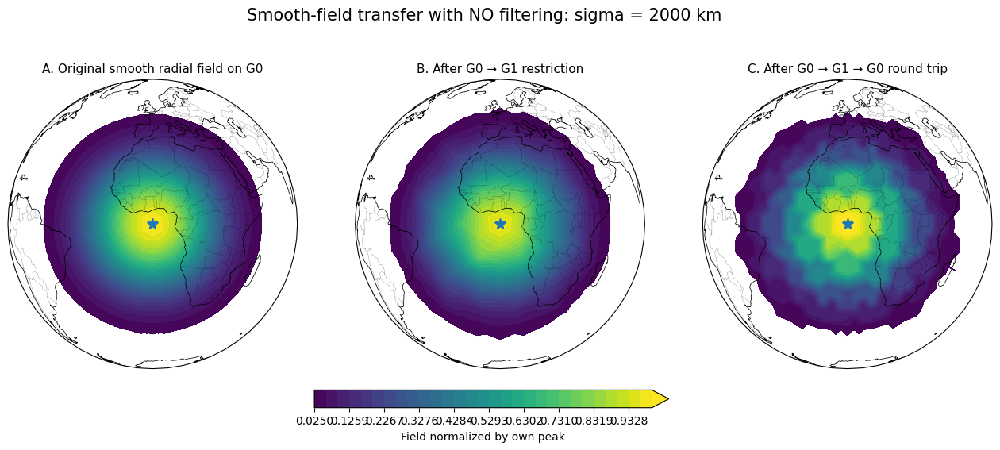

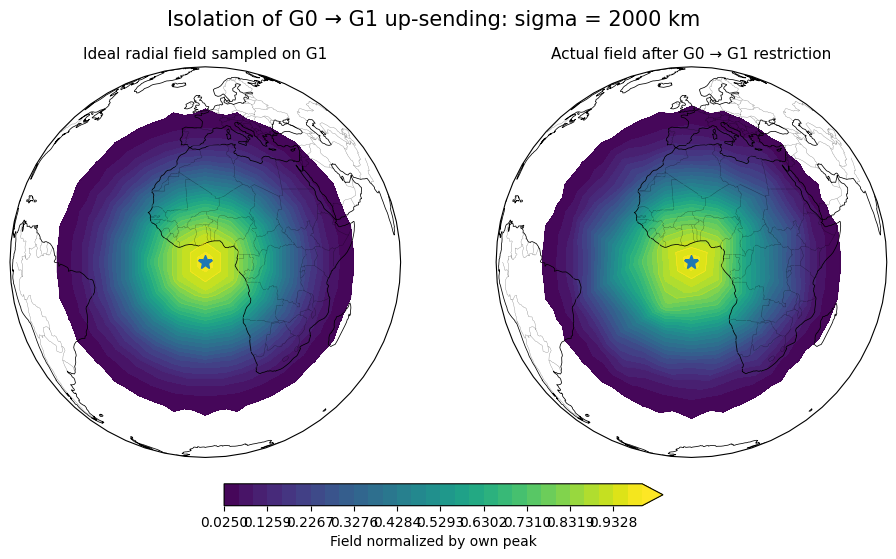

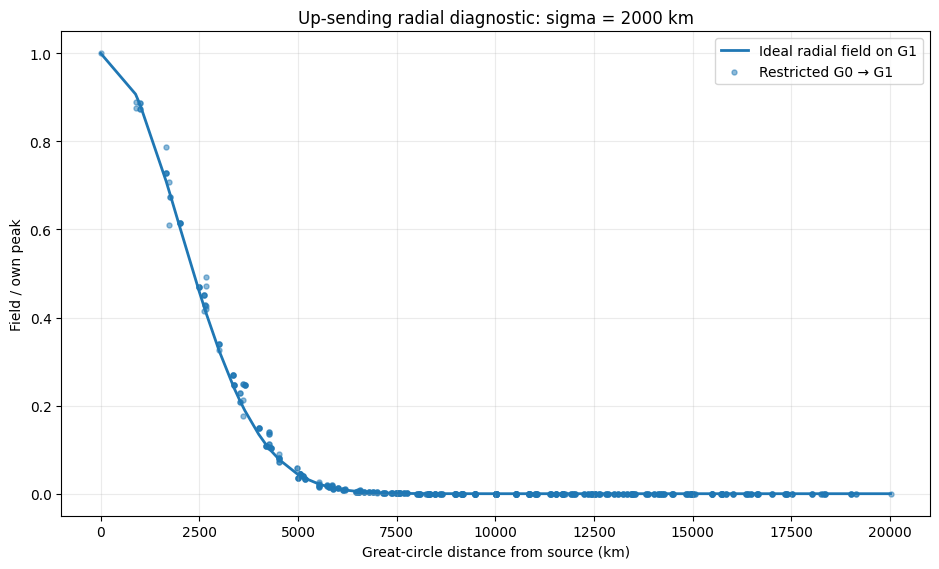



SMOOTH RADIAL PROBE: sigma = 4000 km

AREA INTEGRALS
  original G0       = 8.831293782617e+13
  restricted G1     = 8.831293782617e+13
  reconstructed G0  = 8.831293782617e+13
  restriction relative error = 0.000e+00
  round-trip relative error   = 0.000e+00

SHAPE ERRORS
  G0 -> G1 restriction vs ideal G1 = 2.612951e-02
  complete G0 -> G1 -> G0 round trip = 6.700313e-02
  best amplitude factor on G1 = 0.99893718
  best amplitude factor round trip = 0.99553065

CENTROID SHIFT FROM SOURCE
  original G0      = 0.000 km
  restricted G1    = 5.147 km
  round-trip G0    = 0.176 km


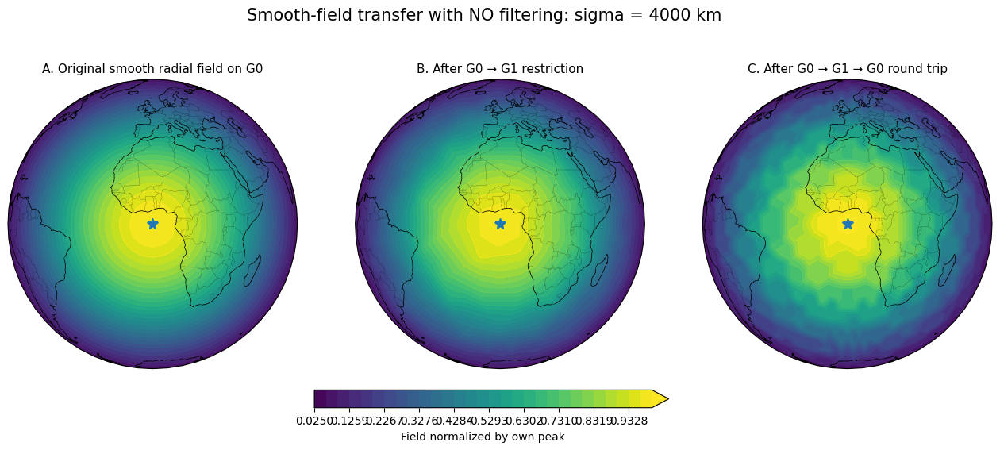

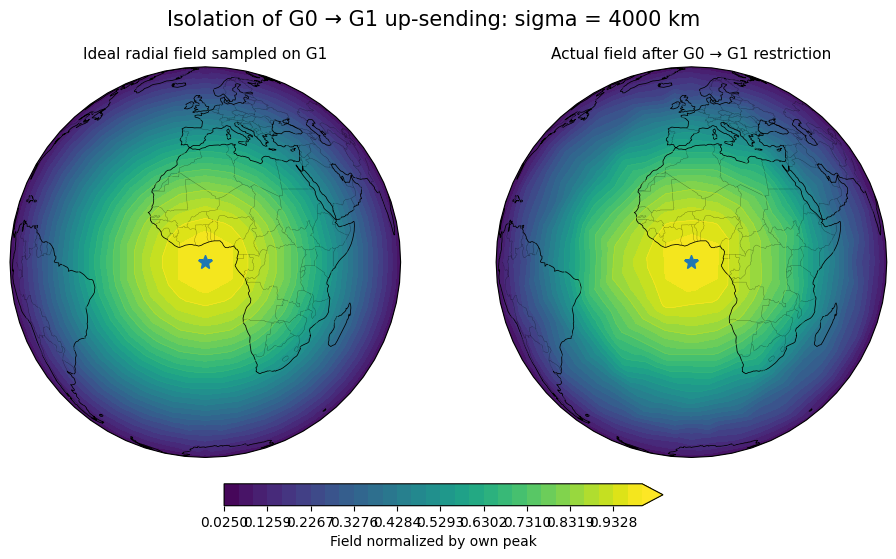

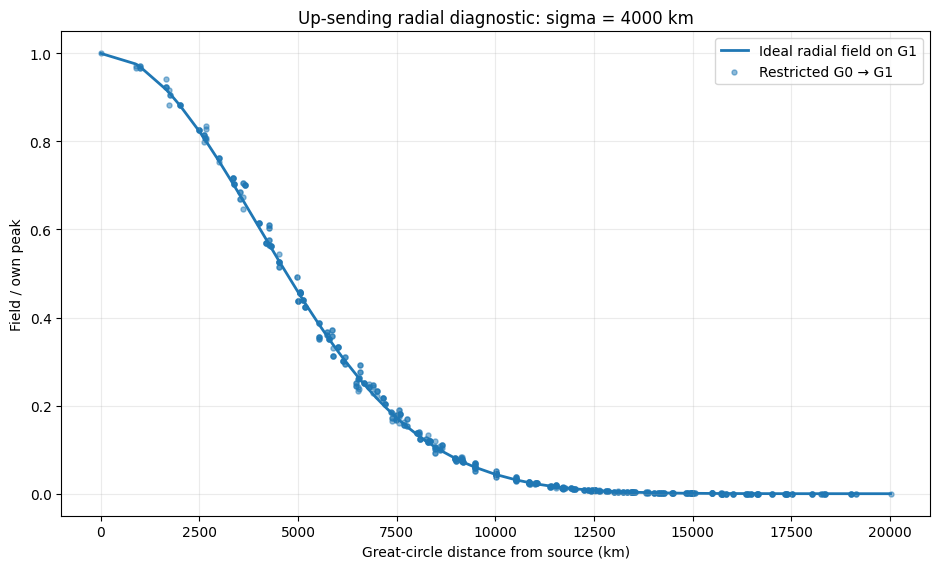



SMOOTH-FIELD TRANSFER TEST COMPLETE

sigma = 2000 km
  restriction shape error = 5.095536e-02
  round-trip shape error  = 1.379207e-01
  G1 centroid shift       = 14.232 km
  round-trip shift        = 0.694 km

sigma = 4000 km
  restriction shape error = 2.612951e-02
  round-trip shape error  = 6.700313e-02
  G1 centroid shift       = 5.147 km
  round-trip shift        = 0.176 km

Output:
/content/drive/MyDrive/GLOBAL_SW_FV/mggf_transfer_diagnostics/G0_G1_smooth_field_NO_FILTER

NO FILTER WAS USED IN THIS EXPERIMENT.


In [ ]:
# ================================================================
# SMOOTH-FIELD G0 <-> G1 TRANSFER DIAGNOSTIC
#
# NO FILTERING.
#
# Purpose:
#
#   Separate distortion caused by
#
#       G0 --R10--> G1
#
#   from distortion caused by
#
#       G1 --P01--> G0
#
# We start with a perfectly radial smooth field on G0.
#
# Two radial test scales:
#       sigma = 2000 km
#       sigma = 4000 km
#
# IMPORTANT:
# These Gaussian-shaped fields are ONLY diagnostic probes.
# This is NOT Gaussian covariance calibration.
# ================================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ================================================================
# 1. CHECK THAT PREVIOUS G0/G1 CELL HAS BEEN RUN
# ================================================================

required = [
    "xyz0", "xyz1",
    "lon0", "lat0",
    "lon1", "lat1",
    "area0", "area1",
    "R10", "P01",
    "SOURCE_G0",
    "EARTH_RADIUS_M"
]

missing = [
    name for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Please run the previous G0/G1 "
        "area-compatible diagnostic cell first.\n"
        f"Missing variables: {missing}"
    )


# ================================================================
# 2. OUTPUT DIRECTORY
# ================================================================

OUT_SMOOTH = (
    Path("/content/drive/MyDrive/GLOBAL_SW_FV")
    / "mggf_transfer_diagnostics"
    / "G0_G1_smooth_field_NO_FILTER"
)

OUT_SMOOTH.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 84)
print("G0 <-> G1 SMOOTH RADIAL FIELD TRANSFER TEST")
print("NO FILTERING")
print("=" * 84)

print("\nOutput directory:")
print(OUT_SMOOTH)


# ================================================================
# 3. SOURCE LOCATION AND GREAT-CIRCLE DISTANCES
# ================================================================

source_xyz = xyz0[SOURCE_G0]

source_lon = lon0[SOURCE_G0]
source_lat = lat0[SOURCE_G0]


def great_circle_distance_km(
    xyz,
    source_xyz
):

    cosine = np.clip(
        xyz @ source_xyz,
        -1.0,
        1.0
    )

    return (
        EARTH_RADIUS_M
        *
        np.arccos(cosine)
        /
        1000.0
    )


r0_km = great_circle_distance_km(
    xyz0,
    source_xyz
)

r1_km = great_circle_distance_km(
    xyz1,
    source_xyz
)


# ================================================================
# 4. TEST SCALES
# ================================================================

TEST_SIGMAS_KM = [
    2000.0,
    4000.0
]


# ================================================================
# 5. DIAGNOSTIC RADIAL FIELD
#
# f(r) = exp[-0.5 (r/sigma)^2]
#
# Again: this is ONLY a smooth test signal.
# ================================================================

def radial_probe(
    r_km,
    sigma_km
):

    return np.exp(
        -0.5
        *
        (
            r_km / sigma_km
        )**2
    )


# ================================================================
# 6. BEST-AMPLITUDE SHAPE ERROR
#
# Compare x with reference q after allowing one scalar alpha:
#
#       min_alpha ||x - alpha q||_A
#
# This removes trivial amplitude differences and measures SHAPE.
# ================================================================

def weighted_shape_error(
    x,
    q,
    area
):

    x = np.asarray(x)
    q = np.asarray(q)
    area = np.asarray(area)

    denominator = np.sum(
        area * q * q
    )

    alpha = (
        np.sum(
            area * x * q
        )
        /
        denominator
    )

    residual = (
        x
        -
        alpha * q
    )

    numerator = np.sum(
        area
        *
        residual**2
    )

    reference = np.sum(
        area
        *
        (alpha * q)**2
    )

    error = np.sqrt(
        numerator
        /
        reference
    )

    return error, alpha


# ================================================================
# 7. CENTROID-DIRECTION SHIFT
#
# Measures whether the transferred smooth field has shifted
# directionally away from the original source.
# ================================================================

def centroid_shift_km(
    field,
    area,
    xyz,
    source_xyz
):

    vector = np.sum(
        (
            area * field
        )[:, None]
        *
        xyz,
        axis=0
    )

    norm = np.linalg.norm(
        vector
    )

    if norm == 0.0:
        return np.nan

    vector /= norm

    angle = np.arccos(
        np.clip(
            np.dot(
                vector,
                source_xyz
            ),
            -1.0,
            1.0
        )
    )

    return (
        EARTH_RADIUS_M
        *
        angle
        /
        1000.0
    )


# ================================================================
# 8. PEAK NORMALIZATION FOR PLOTS ONLY
# ================================================================

def peak_normalize(x):

    m = np.max(
        np.abs(x)
    )

    if m == 0.0:
        return x.copy()

    return x / m


# ================================================================
# 9. MAP UTILITIES
# ================================================================

projection = ccrs.Orthographic(
    central_longitude=float(
        source_lon
    ),
    central_latitude=float(
        source_lat
    )
)


def setup_map(ax):

    ax.set_global()

    ax.coastlines(
        linewidth=0.55
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.25,
        alpha=0.5
    )


levels = np.linspace(
    0.025,
    1.0,
    30
)


def plot_field(
    ax,
    lon,
    lat,
    field,
    title
):

    setup_map(ax)

    cf = ax.tricontourf(
        lon,
        lat,
        field,
        levels=levels,
        extend="max",
        transform=ccrs.PlateCarree()
    )

    ax.tricontour(
        lon,
        lat,
        field,
        levels=levels[::3],
        linewidths=0.4,
        transform=ccrs.PlateCarree()
    )

    ax.plot(
        source_lon,
        source_lat,
        marker="*",
        markersize=10,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(
        title,
        fontsize=11
    )

    return cf


# ================================================================
# 10. STORAGE
# ================================================================

results = {}


# ================================================================
# 11. RUN BOTH SMOOTH-FIELD TESTS
# ================================================================

for sigma_km in TEST_SIGMAS_KM:

    print("\n")
    print("=" * 84)
    print(
        f"SMOOTH RADIAL PROBE: sigma = {sigma_km:.0f} km"
    )
    print("=" * 84)

    # ------------------------------------------------------------
    # Original perfectly radial G0 field
    # ------------------------------------------------------------

    f0 = radial_probe(
        r0_km,
        sigma_km
    )

    # ------------------------------------------------------------
    # Ideal radial field sampled directly at G1 centers
    #
    # This is our reference for what a geometrically perfect
    # representation on G1 would look like.
    # ------------------------------------------------------------

    f1_ideal = radial_probe(
        r1_km,
        sigma_km
    )

    # ------------------------------------------------------------
    # Actual hard/area-weighted restriction
    # ------------------------------------------------------------

    f1_restricted = (
        R10 @ f0
    )

    # ------------------------------------------------------------
    # Round trip using historical hard prolongation
    # ------------------------------------------------------------

    f0_roundtrip = (
        P01 @ f1_restricted
    )

    # ------------------------------------------------------------
    # Integrals
    # ------------------------------------------------------------

    I0 = float(
        area0 @ f0
    )

    I1 = float(
        area1 @ f1_restricted
    )

    Irt = float(
        area0 @ f0_roundtrip
    )

    print("\nAREA INTEGRALS")

    print(
        f"  original G0       = {I0:.12e}"
    )

    print(
        f"  restricted G1     = {I1:.12e}"
    )

    print(
        f"  reconstructed G0  = {Irt:.12e}"
    )

    print(
        "  restriction relative error = "
        f"{abs(I1-I0)/abs(I0):.3e}"
    )

    print(
        "  round-trip relative error   = "
        f"{abs(Irt-I0)/abs(I0):.3e}"
    )

    # ------------------------------------------------------------
    # Shape errors
    # ------------------------------------------------------------

    err_R, alpha_R = weighted_shape_error(
        f1_restricted,
        f1_ideal,
        area1
    )

    err_RT, alpha_RT = weighted_shape_error(
        f0_roundtrip,
        f0,
        area0
    )

    print("\nSHAPE ERRORS")

    print(
        "  G0 -> G1 restriction vs ideal G1 = "
        f"{err_R:.6e}"
    )

    print(
        "  complete G0 -> G1 -> G0 round trip = "
        f"{err_RT:.6e}"
    )

    print(
        f"  best amplitude factor on G1 = {alpha_R:.8f}"
    )

    print(
        f"  best amplitude factor round trip = {alpha_RT:.8f}"
    )

    # ------------------------------------------------------------
    # Centroid shifts
    # ------------------------------------------------------------

    shift_original = centroid_shift_km(
        f0,
        area0,
        xyz0,
        source_xyz
    )

    shift_restricted = centroid_shift_km(
        f1_restricted,
        area1,
        xyz1,
        source_xyz
    )

    shift_roundtrip = centroid_shift_km(
        f0_roundtrip,
        area0,
        xyz0,
        source_xyz
    )

    print("\nCENTROID SHIFT FROM SOURCE")

    print(
        f"  original G0      = {shift_original:.3f} km"
    )

    print(
        f"  restricted G1    = {shift_restricted:.3f} km"
    )

    print(
        f"  round-trip G0    = {shift_roundtrip:.3f} km"
    )

    # ------------------------------------------------------------
    # Normalize ONLY for visual shape comparison
    # ------------------------------------------------------------

    f0_plot = peak_normalize(
        f0
    )

    f1_ideal_plot = peak_normalize(
        f1_ideal
    )

    f1_R_plot = peak_normalize(
        f1_restricted
    )

    f0_RT_plot = peak_normalize(
        f0_roundtrip
    )

    # ============================================================
    # FIGURE 1
    #
    # Most important transfer figure:
    #
    # original G0 -> actual restricted G1 -> reconstructed G0
    # ============================================================

    fig = plt.figure(
        figsize=(16, 5.8)
    )

    ax1 = fig.add_subplot(
        1, 3, 1,
        projection=projection
    )

    cf = plot_field(
        ax1,
        lon0,
        lat0,
        f0_plot,
        "A. Original smooth radial field on G0"
    )

    ax2 = fig.add_subplot(
        1, 3, 2,
        projection=projection
    )

    cf = plot_field(
        ax2,
        lon1,
        lat1,
        f1_R_plot,
        "B. After G0 → G1 restriction"
    )

    ax3 = fig.add_subplot(
        1, 3, 3,
        projection=projection
    )

    cf = plot_field(
        ax3,
        lon0,
        lat0,
        f0_RT_plot,
        "C. After G0 → G1 → G0 round trip"
    )

    cbar = fig.colorbar(
        cf,
        ax=[ax1, ax2, ax3],
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        shrink=0.72
    )

    cbar.set_label(
        "Field normalized by own peak"
    )

    fig.suptitle(
        (
            "Smooth-field transfer with NO filtering: "
            f"sigma = {sigma_km:.0f} km"
        ),
        fontsize=15
    )

    tag = int(sigma_km)

    fig.savefig(
        OUT_SMOOTH
        /
        f"smooth_transfer_sigma_{tag}km.pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        OUT_SMOOTH
        /
        f"smooth_transfer_sigma_{tag}km.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ============================================================
    # FIGURE 2
    #
    # This isolates UP-SENDING:
    #
    # ideal G1 radial field vs actual restricted G1 field
    # ============================================================

    fig = plt.figure(
        figsize=(11.5, 5.7)
    )

    ax1 = fig.add_subplot(
        1, 2, 1,
        projection=projection
    )

    cf = plot_field(
        ax1,
        lon1,
        lat1,
        f1_ideal_plot,
        "Ideal radial field sampled on G1"
    )

    ax2 = fig.add_subplot(
        1, 2, 2,
        projection=projection
    )

    cf = plot_field(
        ax2,
        lon1,
        lat1,
        f1_R_plot,
        "Actual field after G0 → G1 restriction"
    )

    cbar = fig.colorbar(
        cf,
        ax=[ax1, ax2],
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        shrink=0.72
    )

    cbar.set_label(
        "Field normalized by own peak"
    )

    fig.suptitle(
        (
            "Isolation of G0 → G1 up-sending: "
            f"sigma = {sigma_km:.0f} km"
        ),
        fontsize=15
    )

    fig.savefig(
        OUT_SMOOTH
        /
        f"restriction_only_sigma_{tag}km.pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        OUT_SMOOTH
        /
        f"restriction_only_sigma_{tag}km.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ============================================================
    # FIGURE 3
    #
    # Radial comparison on G1
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(9.5, 5.8)
    )

    order = np.argsort(
        r1_km
    )

    ax.plot(
        r1_km[order],
        f1_ideal_plot[order],
        linewidth=2.0,
        label="Ideal radial field on G1"
    )

    ax.scatter(
        r1_km,
        f1_R_plot,
        s=13,
        alpha=0.5,
        label="Restricted G0 → G1"
    )

    ax.set_xlabel(
        "Great-circle distance from source (km)"
    )

    ax.set_ylabel(
        "Field / own peak"
    )

    ax.set_title(
        (
            "Up-sending radial diagnostic: "
            f"sigma = {sigma_km:.0f} km"
        )
    )

    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend()

    fig.tight_layout()

    fig.savefig(
        OUT_SMOOTH
        /
        f"restriction_radial_sigma_{tag}km.pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        OUT_SMOOTH
        /
        f"restriction_radial_sigma_{tag}km.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ------------------------------------------------------------
    # Store results
    # ------------------------------------------------------------

    results[tag] = dict(
        f0=f0,
        f1_ideal=f1_ideal,
        f1_restricted=f1_restricted,
        f0_roundtrip=f0_roundtrip,
        restriction_shape_error=err_R,
        roundtrip_shape_error=err_RT,
        restriction_centroid_shift_km=shift_restricted,
        roundtrip_centroid_shift_km=shift_roundtrip
    )


# ================================================================
# 12. SAVE ALL NUMERICAL RESULTS
# ================================================================

save_dict = {
    "r0_km": r0_km,
    "r1_km": r1_km,
    "source_G0": np.array(SOURCE_G0)
}

for tag, d in results.items():

    save_dict[
        f"f0_sigma_{tag}"
    ] = d["f0"]

    save_dict[
        f"f1_ideal_sigma_{tag}"
    ] = d["f1_ideal"]

    save_dict[
        f"f1_restricted_sigma_{tag}"
    ] = d["f1_restricted"]

    save_dict[
        f"f0_roundtrip_sigma_{tag}"
    ] = d["f0_roundtrip"]

    save_dict[
        f"restriction_shape_error_sigma_{tag}"
    ] = np.array(
        d["restriction_shape_error"]
    )

    save_dict[
        f"roundtrip_shape_error_sigma_{tag}"
    ] = np.array(
        d["roundtrip_shape_error"]
    )

np.savez(
    OUT_SMOOTH
    /
    "G0_G1_smooth_transfer_diagnostic.npz",
    **save_dict
)


# ================================================================
# 13. FINAL COMPACT SUMMARY
# ================================================================

print("\n")
print("=" * 84)
print("SMOOTH-FIELD TRANSFER TEST COMPLETE")
print("=" * 84)

for tag, d in results.items():

    print(
        f"\nsigma = {tag} km"
    )

    print(
        "  restriction shape error = "
        f"{d['restriction_shape_error']:.6e}"
    )

    print(
        "  round-trip shape error  = "
        f"{d['roundtrip_shape_error']:.6e}"
    )

    print(
        "  G1 centroid shift       = "
        f"{d['restriction_centroid_shift_km']:.3f} km"
    )

    print(
        "  round-trip shift        = "
        f"{d['roundtrip_centroid_shift_km']:.3f} km"
    )

print("\nOutput:")
print(OUT_SMOOTH)

print("\nNO FILTER WAS USED IN THIS EXPERIMENT.")